In [ ]:
# ============================================================
# CELL 1: ENVIRONMENT SETUP
# AMHARIC INTENTION DETECTION
# ============================================================

import os
import gc
import random
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("AMHARIC INTENTION DETECTION")
print("CELL 1: ENVIRONMENT SETUP")
print("=" * 70)

print(f"Python/PyTorch device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")

print(f"Random seed: {SEED}")

# ------------------------------------------------------------
# Package versions
# ------------------------------------------------------------

print(f"\nNumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"PyTorch : {torch.__version__}")

print("\n" + "=" * 70)
print("CELL 1 COMPLETED")
print("=" * 70)

AMHARIC INTENTION DETECTION
CELL 1: ENVIRONMENT SETUP
Python/PyTorch device: cuda
GPU: Tesla T4
CUDA: 12.8
Random seed: 42

NumPy   : 2.1.3
Pandas  : 2.2.3
PyTorch : 2.11.0+cu128

CELL 1 COMPLETED


In [ ]:
# ============================================================
# CELL 2: LOAD AMHARIC INTENTION DETECTION DATASET
# ============================================================

# Change ONLY this filename if your current intention dataset
# has a different filename.

DATA_PATH = "/content/amharic_intention_dataset.csv"

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("AMHARIC INTENTION DETECTION — DATASET LOADED")
print("=" * 70)

print(f"\nDataset shape: {df.shape}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\n" + "=" * 70)
print("CELL 2 COMPLETED")
print("=" * 70)

AMHARIC INTENTION DETECTION — DATASET LOADED

Dataset shape: (11475, 6)

Column names:
['id', 'text', 'label', 'label_id', 'template_id', 'split']

First 5 rows:


,id,text,label,label_id,template_id,split
0,1,ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።,Complaint,6,Complaint_07,train
1,2,እባክዎ ውሉን ለደንበኛው በዚህ ወር ይላኩልኝ።,Request,0,Request_00,train
2,3,ነጋዴው፣ ስራ በሆስፒታል እንዴት ነው?,Phatic,7,Phatic_09,val
3,4,እባክዎ ትዕዛዙን ለፖሊሱ በዚህ አመት ይላኩልኝ።,Request,0,Request_00,train
4,5,እባክሽ ስጦታውን ዛሬ ማታ አምጪልኝ።,Request,0,Request_09,test



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11475 entries, 0 to 11474
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           11475 non-null  int64 
 1   text         11475 non-null  object
 2   label        11475 non-null  object
 3   label_id     11475 non-null  int64 
 4   template_id  11475 non-null  object
 5   split        11475 non-null  object
dtypes: int64(2), object(4)
memory usage: 538.0+ KB

Missing values:
id             0
text           0
label          0
label_id       0
template_id    0
split          0
dtype: int64

CELL 2 COMPLETED


In [ ]:
# ============================================================
# CELL 3: DATASET VERIFICATION
# AMHARIC INTENTION DETECTION
# ============================================================

print("=" * 70)
print("CELL 3: DATASET VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Basic information
# ------------------------------------------------------------

print("\n[1] Dataset shape")
print("-" * 50)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

# ------------------------------------------------------------
# 2. Column information
# ------------------------------------------------------------

print("\n[2] Column information")
print("-" * 50)

for col in df.columns:
    print(f"{col:20s} | dtype = {df[col].dtype}")

# ------------------------------------------------------------
# 3. Missing values
# ------------------------------------------------------------

print("\n[3] Missing values")
print("-" * 50)

missing = df.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\n✓ No missing values found.")
else:
    print(f"\n⚠ Total missing values: {missing.sum()}")

# ------------------------------------------------------------
# 4. Duplicate rows
# ------------------------------------------------------------

print("\n[4] Duplicate rows")
print("-" * 50)

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

if duplicate_count == 0:
    print("✓ No duplicate rows found.")
else:
    print("⚠ Duplicate rows detected.")

# ------------------------------------------------------------
# 5. Text duplicate check
# ------------------------------------------------------------

if "text" in df.columns:

    print("\n[5] Duplicate texts")
    print("-" * 50)

    duplicate_texts = df["text"].duplicated().sum()

    print(f"Duplicate texts: {duplicate_texts:,}")

    if duplicate_texts == 0:
        print("✓ No duplicate texts found.")
    else:
        print("⚠ Duplicate texts detected.")

# ------------------------------------------------------------
# 6. Label information
# ------------------------------------------------------------

if "label" in df.columns:

    print("\n[6] Label information")
    print("-" * 50)

    unique_labels = sorted(df["label"].unique())

    print(f"Number of classes: {len(unique_labels)}")
    print(f"Labels: {unique_labels}")

    print("\nOverall label distribution:")

    label_counts = df["label"].value_counts().sort_index()

    label_percent = (
        df["label"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    label_table = pd.DataFrame({
        "Count": label_counts,
        "Percentage": label_percent
    })

    display(label_table)

# ------------------------------------------------------------
# 7. Split information
# ------------------------------------------------------------

if "split" in df.columns:

    print("\n[7] Dataset split information")
    print("-" * 50)

    print("Available splits:")
    print(df["split"].value_counts())

    print("\nSplit × Label distribution:")

    split_label_table = pd.crosstab(
        df["split"],
        df["label"]
    )

    display(split_label_table)

else:

    print("\n[7] Dataset split information")
    print("-" * 50)
    print("No 'split' column found.")
    print("We will determine the appropriate split in a later cell.")

# ------------------------------------------------------------
# 8. Text length statistics
# ------------------------------------------------------------

if "text" in df.columns:

    print("\n[8] Text length statistics")
    print("-" * 50)

    text_lengths = df["text"].astype(str).str.split().str.len()

    print(f"Minimum words : {text_lengths.min()}")
    print(f"Maximum words : {text_lengths.max()}")
    print(f"Mean words    : {text_lengths.mean():.2f}")
    print(f"Median words  : {text_lengths.median():.2f}")

# ------------------------------------------------------------
# 9. Sample examples
# ------------------------------------------------------------

if "text" in df.columns and "label" in df.columns:

    print("\n[9] Sample dataset examples")
    print("-" * 50)

    display(
        df[["text", "label"]].sample(
            min(10, len(df)),
            random_state=SEED
        )
    )

print("\n" + "=" * 70)
print("CELL 3 COMPLETED")
print("=" * 70)

CELL 3: DATASET VERIFICATION

[1] Dataset shape
--------------------------------------------------
Rows    : 11,475
Columns : 6

[2] Column information
--------------------------------------------------
id                   | dtype = int64
text                 | dtype = object
label                | dtype = object
label_id             | dtype = int64
template_id          | dtype = object
split                | dtype = object

[3] Missing values
--------------------------------------------------
id             0
text           0
label          0
label_id       0
template_id    0
split          0
dtype: int64

✓ No missing values found.

[4] Duplicate rows
--------------------------------------------------
Duplicate rows: 0
✓ No duplicate rows found.

[5] Duplicate texts
--------------------------------------------------
Duplicate texts: 0
✓ No duplicate texts found.

[6] Label information
--------------------------------------------------
Number of classes: 9
Labels: ['Assertion', 'Comp

,Count,Percentage
label,,
Assertion,1275,11.11
Complaint,1275,11.11
Phatic,1275,11.11
Promise,1275,11.11
Refusal,1275,11.11
Request,1275,11.11
Sarcasm/Irony,1275,11.11
Suggestion,1275,11.11
Warning,1275,11.11



[7] Dataset split information
--------------------------------------------------
Available splits:
split
train    7955
val      1857
test     1663
Name: count, dtype: int64

Split × Label distribution:


label,Assertion,Complaint,Phatic,Promise,Refusal,Request,Sarcasm/Irony,Suggestion,Warning
split,,,,,,,,,
test,190,190,171,119,244,173,186,185,205
train,897,895,873,818,867,929,896,891,889
val,188,190,231,338,164,173,193,199,181



[8] Text length statistics
--------------------------------------------------
Minimum words : 3
Maximum words : 12
Mean words    : 6.63
Median words  : 7.00

[9] Sample dataset examples
--------------------------------------------------


,text,label
11195,ስቱዲዮው ስለ ቦርሳው ማስጠንቀቂያ ከሶስት ሰዓት በኋላ አውጥቷል።,Warning
9625,ይቅርታ፣ ውሃውን በዚህ ሳምንት ማድረግ አልችልም።,Refusal
6954,መንግስት ነገ አዲስ ምርት አስተዋውቋል።,Assertion
8788,የኮምፒዩተሩ ችግር ከሰዓት በኋላ ከጋዜጠኛው ጋር እፈታለሁ።,Promise
9406,እባክዎ ይቅርታ፣ ቁልፉን ከሶስት ሰዓት በኋላ ማቅረብ አልችልም።,Refusal
468,በመንግስት አዲስ ስልት በሚቀጥለው ወር እንተግብር።,Suggestion
5899,ውሉ ገና ወደ ከተማው ውስጥ ከሁለት ቀናት በኋላ አልደረሰኝም።,Complaint
4923,የኮምፒዩተሩ ችግር በዚህ አመት ከፖሊሱ ጋር እፈታለሁ።,Promise
6929,ጥያቄውን በጥንቃቄ ለጓደኛዬ እይዛለሁ።,Promise
7795,እባክዎ ይቅርታ፣ በሩን ከምሽቱ ጀምሮ ማቅረብ አልችልም።,Refusal



CELL 3 COMPLETED


In [ ]:
# ============================================================
# CELL 4: PREPARE DATA FOR MODELING
# AMHARIC INTENTION DETECTION
# ============================================================

print("=" * 70)
print("CELL 4: DATA PREPARATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check required columns
# ------------------------------------------------------------

required_columns = ["text", "label"]

for column in required_columns:
    assert column in df.columns, f"Required column '{column}' not found."

print("\nRequired columns verified:")
print(required_columns)

# ------------------------------------------------------------
# 2. Create modeling dataframe
# ------------------------------------------------------------

model_df = df[["text", "label"]].copy()

# Keep text as string
model_df["text"] = model_df["text"].astype(str).str.strip()

# ------------------------------------------------------------
# 3. Remove empty text entries
# ------------------------------------------------------------

empty_text_count = (
    model_df["text"].isna().sum()
    + (model_df["text"].str.len() == 0).sum()
)

print(f"\nEmpty text entries: {empty_text_count}")

if empty_text_count > 0:
    model_df = model_df[
        model_df["text"].str.len() > 0
    ].copy()

# ------------------------------------------------------------
# 4. Convert labels to integer codes if required
# ------------------------------------------------------------

print("\nOriginal label dtype:")
print(model_df["label"].dtype)

if not pd.api.types.is_integer_dtype(model_df["label"]):

    label_values = sorted(model_df["label"].unique())

    label_mapping = {
        label: index
        for index, label in enumerate(label_values)
    }

    model_df["label"] = model_df["label"].map(label_mapping)

    print("\nLabel mapping:")
    print(label_mapping)

else:
    model_df["label"] = model_df["label"].astype(int)

# ------------------------------------------------------------
# 5. Verify labels
# ------------------------------------------------------------

print("\nLabels after preparation:")
print(sorted(model_df["label"].unique()))

print("\nNumber of classes:")
print(model_df["label"].nunique())

# ------------------------------------------------------------
# 6. Verify text and label consistency
# ------------------------------------------------------------

assert model_df["text"].notna().all()
assert model_df["label"].notna().all()

print("\nText-label consistency verified.")

# ------------------------------------------------------------
# 7. Display prepared data
# ------------------------------------------------------------

print("\nPrepared dataset shape:")
print(model_df.shape)

print("\nPrepared dataset:")
display(model_df.head(10))

# ------------------------------------------------------------
# 8. Label distribution
# ------------------------------------------------------------

print("\nLabel distribution:")

distribution = (
    model_df["label"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

distribution["Percentage"] = (
    distribution["Count"] /
    len(model_df) * 100
).round(2)

display(distribution)

# ------------------------------------------------------------
# 9. Save prepared dataframe in memory
# ------------------------------------------------------------

print("\n✓ Prepared dataframe stored as: model_df")

print("\n" + "=" * 70)
print("CELL 4 COMPLETED")
print("=" * 70)

CELL 4: DATA PREPARATION

Required columns verified:
['text', 'label']

Empty text entries: 0

Original label dtype:
object

Label mapping:
{'Assertion': 0, 'Complaint': 1, 'Phatic': 2, 'Promise': 3, 'Refusal': 4, 'Request': 5, 'Sarcasm/Irony': 6, 'Suggestion': 7, 'Warning': 8}

Labels after preparation:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Number of classes:
9

Text-label consistency verified.

Prepared dataset shape:
(11475, 2)

Prepared dataset:


,text,label
0,ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።,1
1,እባክዎ ውሉን ለደንበኛው በዚህ ወር ይላኩልኝ።,5
2,ነጋዴው፣ ስራ በሆስፒታል እንዴት ነው?,2
3,እባክዎ ትዕዛዙን ለፖሊሱ በዚህ አመት ይላኩልኝ።,5
4,እባክሽ ስጦታውን ዛሬ ማታ አምጪልኝ።,5
5,የትዕዛዙ ችግር ከምሽቱ ጀምሮ ከጓደኛዬ ጋር እፈታለሁ።,3
6,በጣም ውጤታማ ነው ባንኩ፣ በበዚህ አመት ምንም አልተሰራም።,6
7,አለቃዬ፣ ቤተሰብ በቢሮ እንዴት ናቸው?,2
8,ደብዳቤው ገና ወደ አውሮፕላን ማረፊያ ከአንድ ሰዓት በኋላ አልደረሰኝም።,1
9,እባክዎ ትዕዛዙን ለአለቃዬ በስብሰባው ወቅት ይላኩልኝ።,5



Label distribution:


,Count,Percentage
label,,
0,1275,11.11
1,1275,11.11
2,1275,11.11
3,1275,11.11
4,1275,11.11
5,1275,11.11
6,1275,11.11
7,1275,11.11
8,1275,11.11



✓ Prepared dataframe stored as: model_df

CELL 4 COMPLETED


In [ ]:
# ============================================================
# CELL 5: TRAIN / VALIDATION / TEST SPLIT
# AMHARIC INTENTION DETECTION
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 70)
print("CELL 5: TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check whether a split column already exists
# ------------------------------------------------------------

if "split" in df.columns:

    print("\nExisting 'split' column detected.")
    print("Using the existing dataset splits.")

    split_values = (
        df["split"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Normalize common split names
    split_mapping = {
        "train": "train",
        "training": "train",
        "val": "validation",
        "valid": "validation",
        "validation": "validation",
        "test": "test"
    }

    normalized_split = split_values.map(split_mapping)

    if normalized_split.isna().any():
        print("\nUnrecognized split values:")
        print(split_values[normalized_split.isna()].unique())

        raise ValueError(
            "Unrecognized values found in the split column."
        )

    split_df = model_df.copy()
    split_df["split"] = normalized_split.values

else:

    print("\nNo 'split' column detected.")
    print("Creating a stratified 70/15/15 split.")

    # --------------------------------------------------------
    # First: 70% training, 30% temporary
    # --------------------------------------------------------

    train_data, temp_data = train_test_split(
        model_df,
        test_size=0.30,
        stratify=model_df["label"],
        random_state=SEED
    )

    # --------------------------------------------------------
    # Second: divide temporary data equally
    # 15% validation + 15% test
    # --------------------------------------------------------

    val_data, test_data = train_test_split(
        temp_data,
        test_size=0.50,
        stratify=temp_data["label"],
        random_state=SEED
    )

    train_data = train_data.copy()
    val_data = val_data.copy()
    test_data = test_data.copy()

    train_data["split"] = "train"
    val_data["split"] = "validation"
    test_data["split"] = "test"

    split_df = pd.concat(
        [train_data, val_data, test_data],
        axis=0
    ).sample(
        frac=1,
        random_state=SEED
    ).reset_index(drop=True)

# ------------------------------------------------------------
# 2. Create separate datasets
# ------------------------------------------------------------

train_df = split_df[
    split_df["split"] == "train"
].copy()

val_df = split_df[
    split_df["split"] == "validation"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()

# ------------------------------------------------------------
# 3. Display split sizes
# ------------------------------------------------------------

print("\nDataset split sizes:")
print("-" * 50)

print(f"Training   : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")
print(f"Total      : {len(split_df):,}")

# ------------------------------------------------------------
# 4. Verify total
# ------------------------------------------------------------

assert (
    len(train_df) +
    len(val_df) +
    len(test_df)
) == len(split_df)

# ------------------------------------------------------------
# 5. Check class distribution
# ------------------------------------------------------------

print("\nClass distribution by split:")
print("-" * 50)

split_class_distribution = pd.crosstab(
    split_df["split"],
    split_df["label"]
)

display(split_class_distribution)

# ------------------------------------------------------------
# 6. Percentage distribution
# ------------------------------------------------------------

print("\nClass distribution percentages:")
print("-" * 50)

split_class_percentage = pd.crosstab(
    split_df["split"],
    split_df["label"],
    normalize="index"
) * 100

display(split_class_percentage.round(2))

# ------------------------------------------------------------
# 7. Check for text overlap
# ------------------------------------------------------------

train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

train_val_overlap = train_texts.intersection(val_texts)
train_test_overlap = train_texts.intersection(test_texts)
val_test_overlap = val_texts.intersection(test_texts)

print("\nText overlap check:")
print("-" * 50)

print(f"Train ∩ Validation : {len(train_val_overlap)}")
print(f"Train ∩ Test       : {len(train_test_overlap)}")
print(f"Validation ∩ Test  : {len(val_test_overlap)}")

# ------------------------------------------------------------
# 8. Verify no overlap
# ------------------------------------------------------------

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("\nNo text overlap detected between splits.")

# ------------------------------------------------------------
# 9. Final split summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 5 COMPLETED")
print("=" * 70)

CELL 5: TRAIN / VALIDATION / TEST SPLIT

Existing 'split' column detected.
Using the existing dataset splits.

Dataset split sizes:
--------------------------------------------------
Training   : 7,955
Validation : 1,857
Test       : 1,663
Total      : 11,475

Class distribution by split:
--------------------------------------------------


label,0,1,2,3,4,5,6,7,8
split,,,,,,,,,
test,190,190,171,119,244,173,186,185,205
train,897,895,873,818,867,929,896,891,889
validation,188,190,231,338,164,173,193,199,181



Class distribution percentages:
--------------------------------------------------


label,0,1,2,3,4,5,6,7,8
split,,,,,,,,,
test,11.43,11.43,10.28,7.16,14.67,10.40,11.18,11.12,12.33
train,11.28,11.25,10.97,10.28,10.90,11.68,11.26,11.20,11.18
validation,10.12,10.23,12.44,18.20,8.83,9.32,10.39,10.72,9.75



Text overlap check:
--------------------------------------------------
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

No text overlap detected between splits.

CELL 5 COMPLETED


In [ ]:
# ============================================================
# CELL 6: LOAD AFROXLM-R TOKENIZER
# AMHARIC INTENTION DETECTION
# ============================================================

from transformers import AutoTokenizer

print("=" * 70)
print("CELL 6: AFROXLM-R TOKENIZER")
print("=" * 70)

# ------------------------------------------------------------
# 1. Model configuration
# ------------------------------------------------------------

MODEL_NAME = "Davlan/afro-xlmr-base"
MAX_LENGTH = 128

print(f"\nModel: {MODEL_NAME}")
print(f"Maximum sequence length: {MAX_LENGTH}")

# ------------------------------------------------------------
# 2. Load tokenizer
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("\nTokenizer loaded successfully.")

# ------------------------------------------------------------
# 3. Tokenizer information
# ------------------------------------------------------------

print("\nTokenizer information:")
print(f"Vocabulary size : {tokenizer.vocab_size}")
print(f"Model max length: {tokenizer.model_max_length}")
print(f"PAD token       : {tokenizer.pad_token}")
print(f"UNK token       : {tokenizer.unk_token}")
print(f"CLS token       : {tokenizer.cls_token}")
print(f"SEP token       : {tokenizer.sep_token}")

# ------------------------------------------------------------
# 4. Test tokenization using real dataset examples
# ------------------------------------------------------------

sample_texts = train_df["text"].head(3).tolist()

print("\nSample tokenization:")
print("-" * 70)

for i, text in enumerate(sample_texts, start=1):

    encoded = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH
    )

    tokens = tokenizer.convert_ids_to_tokens(
        encoded["input_ids"]
    )

    print(f"\nExample {i}")
    print(f"Text   : {text}")
    print(f"Tokens : {' '.join(tokens)}")
    print(f"Length : {len(encoded['input_ids'])}")

# ------------------------------------------------------------
# 5. Verify tokenizer
# ------------------------------------------------------------

assert tokenizer is not None
assert tokenizer.vocab_size > 0

print("\nTokenizer verification completed.")

print("\n" + "=" * 70)
print("CELL 6 COMPLETED")
print("=" * 70)

CELL 6: AFROXLM-R TOKENIZER

Model: Davlan/afro-xlmr-base
Maximum sequence length: 128


config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


Tokenizer loaded successfully.

Tokenizer information:
Vocabulary size : 250002
Model max length: 512
PAD token       : <pad>
UNK token       : <unk>
CLS token       : <s>
SEP token       : </s>

Sample tokenization:
----------------------------------------------------------------------

Example 1
Text   : ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።
Tokens : <s> ▁ስጦታ ው ▁ገና ▁ወደ ▁ አውሮፕላን ▁ ማረ ፊያ ▁ነገ ▁አል ደረሰ ኝ ም። </s>
Length : 16

Example 2
Text   : እባክዎ ውሉን ለደንበኛው በዚህ ወር ይላኩልኝ።
Tokens : <s> ▁እ ባ ክ ዎ ▁ ው ሉን ▁ለ ደን በ ኛው ▁በዚህ ▁ወር ▁ይ ላ ኩ ልኝ ። </s>
Length : 20

Example 3
Text   : እባክዎ ትዕዛዙን ለፖሊሱ በዚህ አመት ይላኩልኝ።
Tokens : <s> ▁እ ባ ክ ዎ ▁ት ዕ ዛ ዙ ን ▁ለ ፖ ሊ ሱ ▁በዚህ ▁አመት ▁ይ ላ ኩ ልኝ ። </s>
Length : 22

Tokenizer verification completed.

CELL 6 COMPLETED


In [ ]:
# ============================================================
# CELL 7: TOKENIZE TRAIN / VALIDATION / TEST DATA
# AMHARIC INTENTION DETECTION
# ============================================================

print("=" * 70)
print("CELL 7: TOKENIZATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Tokenization function
# ------------------------------------------------------------

def tokenize_texts(texts):
    return tokenizer(
        texts.tolist(),
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )

# ------------------------------------------------------------
# 2. Tokenize each split
# ------------------------------------------------------------

print("\nTokenizing training data...")

train_encodings = tokenize_texts(
    train_df["text"]
)

print("Training tokenization completed.")

print("\nTokenizing validation data...")

val_encodings = tokenize_texts(
    val_df["text"]
)

print("Validation tokenization completed.")

print("\nTokenizing test data...")

test_encodings = tokenize_texts(
    test_df["text"]
)

print("Test tokenization completed.")

# ------------------------------------------------------------
# 3. Verify number of examples
# ------------------------------------------------------------

assert len(train_encodings["input_ids"]) == len(train_df)
assert len(val_encodings["input_ids"]) == len(val_df)
assert len(test_encodings["input_ids"]) == len(test_df)

print("\nNumber of tokenized examples:")
print(f"Training   : {len(train_encodings['input_ids']):,}")
print(f"Validation : {len(val_encodings['input_ids']):,}")
print(f"Test       : {len(test_encodings['input_ids']):,}")

# ------------------------------------------------------------
# 4. Check token lengths
# ------------------------------------------------------------

train_lengths = [
    len(ids) for ids in train_encodings["input_ids"]
]

val_lengths = [
    len(ids) for ids in val_encodings["input_ids"]
]

test_lengths = [
    len(ids) for ids in test_encodings["input_ids"]
]

print("\nToken length statistics:")
print("-" * 70)

print(
    f"Training   | "
    f"Min: {min(train_lengths)} | "
    f"Max: {max(train_lengths)} | "
    f"Mean: {np.mean(train_lengths):.2f}"
)

print(
    f"Validation | "
    f"Min: {min(val_lengths)} | "
    f"Max: {max(val_lengths)} | "
    f"Mean: {np.mean(val_lengths):.2f}"
)

print(
    f"Test       | "
    f"Min: {min(test_lengths)} | "
    f"Max: {max(test_lengths)} | "
    f"Mean: {np.mean(test_lengths):.2f}"
)

# ------------------------------------------------------------
# 5. Check truncation
# ------------------------------------------------------------

train_truncated = sum(
    length >= MAX_LENGTH for length in train_lengths
)

val_truncated = sum(
    length >= MAX_LENGTH for length in val_lengths
)

test_truncated = sum(
    length >= MAX_LENGTH for length in test_lengths
)

print("\nSequences reaching MAX_LENGTH:")
print("-" * 70)

print(f"Training   : {train_truncated:,}")
print(f"Validation : {val_truncated:,}")
print(f"Test       : {test_truncated:,}")

# ------------------------------------------------------------
# 6. Display one tokenized example
# ------------------------------------------------------------

print("\nExample tokenization:")
print("-" * 70)

example_index = 0

print("Original text:")
print(train_df.iloc[example_index]["text"])

print("\nTokens:")
print(
    tokenizer.convert_ids_to_tokens(
        train_encodings["input_ids"][example_index]
    )
)

print("\nInput IDs:")
print(
    train_encodings["input_ids"][example_index]
)

# ------------------------------------------------------------
# 7. Final verification
# ------------------------------------------------------------

assert len(train_encodings["input_ids"]) == len(train_df)
assert len(val_encodings["input_ids"]) == len(val_df)
assert len(test_encodings["input_ids"]) == len(test_df)

print("\nTokenization verified successfully.")

print("\n" + "=" * 70)
print("CELL 7 COMPLETED")
print("=" * 70)

CELL 7: TOKENIZATION

Tokenizing training data...
Training tokenization completed.

Tokenizing validation data...
Validation tokenization completed.

Tokenizing test data...
Test tokenization completed.

Number of tokenized examples:
Training   : 7,955
Validation : 1,857
Test       : 1,663

Token length statistics:
----------------------------------------------------------------------
Training   | Min: 7 | Max: 28 | Mean: 18.08
Validation | Min: 7 | Max: 26 | Mean: 16.97
Test       | Min: 6 | Max: 30 | Mean: 17.09

Sequences reaching MAX_LENGTH:
----------------------------------------------------------------------
Training   : 0
Validation : 0
Test       : 0

Example tokenization:
----------------------------------------------------------------------
Original text:
ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።

Tokens:
['<s>', '▁ስጦታ', 'ው', '▁ገና', '▁ወደ', '▁', 'አውሮፕላን', '▁', 'ማረ', 'ፊያ', '▁ነገ', '▁አል', 'ደረሰ', 'ኝ', 'ም።', '</s>']

Input IDs:
[0, 222731, 1178, 132503, 5156, 6, 230717, 6, 134210, 187817

In [ ]:
# ============================================================
# CELL 8: CREATE HUGGING FACE DATASETS
# AMHARIC INTENTION DETECTION
# ============================================================

from datasets import Dataset

print("=" * 70)
print("CELL 8: CREATE MODEL DATASETS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create dataset dictionaries
# ------------------------------------------------------------

train_dataset_dict = {
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_df["label"].tolist()
}

val_dataset_dict = {
    "input_ids": val_encodings["input_ids"],
    "attention_mask": val_encodings["attention_mask"],
    "labels": val_df["label"].tolist()
}

test_dataset_dict = {
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": test_df["label"].tolist()
}

# ------------------------------------------------------------
# 2. Convert to Hugging Face Dataset objects
# ------------------------------------------------------------

train_dataset = Dataset.from_dict(
    train_dataset_dict
)

val_dataset = Dataset.from_dict(
    val_dataset_dict
)

test_dataset = Dataset.from_dict(
    test_dataset_dict
)

# ------------------------------------------------------------
# 3. Display dataset information
# ------------------------------------------------------------

print("\nDataset sizes:")
print("-" * 70)

print(f"Training   : {len(train_dataset):,}")
print(f"Validation : {len(val_dataset):,}")
print(f"Test       : {len(test_dataset):,}")

# ------------------------------------------------------------
# 4. Verify columns
# ------------------------------------------------------------

print("\nDataset columns:")
print("-" * 70)

print(f"Training   : {train_dataset.column_names}")
print(f"Validation : {val_dataset.column_names}")
print(f"Test       : {test_dataset.column_names}")

# ------------------------------------------------------------
# 5. Verify labels
# ------------------------------------------------------------

print("\nLabel verification:")
print("-" * 70)

print(
    "Training labels:",
    sorted(set(train_dataset["labels"]))
)

print(
    "Validation labels:",
    sorted(set(val_dataset["labels"]))
)

print(
    "Test labels:",
    sorted(set(test_dataset["labels"]))
)

# ------------------------------------------------------------
# 6. Verify dataset lengths
# ------------------------------------------------------------

assert len(train_dataset) == len(train_df)
assert len(val_dataset) == len(val_df)
assert len(test_dataset) == len(test_df)

# ------------------------------------------------------------
# 7. Verify required model fields
# ------------------------------------------------------------

required_fields = [
    "input_ids",
    "attention_mask",
    "labels"
]

for field in required_fields:
    assert field in train_dataset.column_names
    assert field in val_dataset.column_names
    assert field in test_dataset.column_names

# ------------------------------------------------------------
# 8. Display one example
# ------------------------------------------------------------

print("\nExample training record:")
print("-" * 70)

print(train_dataset[0])

# ------------------------------------------------------------
# 9. Final verification
# ------------------------------------------------------------

print("\nDataset preparation verified successfully.")

print("\n" + "=" * 70)
print("CELL 8 COMPLETED")
print("=" * 70)

CELL 8: CREATE MODEL DATASETS

Dataset sizes:
----------------------------------------------------------------------
Training   : 7,955
Validation : 1,857
Test       : 1,663

Dataset columns:
----------------------------------------------------------------------
Training   : ['input_ids', 'attention_mask', 'labels']
Validation : ['input_ids', 'attention_mask', 'labels']
Test       : ['input_ids', 'attention_mask', 'labels']

Label verification:
----------------------------------------------------------------------
Training labels: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Validation labels: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Test labels: [0, 1, 2, 3, 4, 5, 6, 7, 8]

Example training record:
----------------------------------------------------------------------
{'input_ids': [0, 222731, 1178, 132503, 5156, 6, 230717, 6, 134210, 187817, 79082, 16241, 82956, 8822, 23064, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 1}

Dataset preparation verified successfully.

CELL 8 COM

In [ ]:
# ============================================================
# CELL 9: LOAD AFROXLM-R CLASSIFICATION MODEL
# AMHARIC INTENTION DETECTION
# ============================================================

from transformers import AutoModelForSequenceClassification

print("=" * 70)
print("CELL 9: AFROXLM-R CLASSIFICATION MODEL")
print("=" * 70)

# ------------------------------------------------------------
# 1. Determine number of classes
# ------------------------------------------------------------

num_labels = model_df["label"].nunique()

print(f"\nNumber of intention classes: {num_labels}")

# ------------------------------------------------------------
# 2. Load pretrained AfroXLM-R
# ------------------------------------------------------------

MODEL_NAME = "Davlan/afro-xlmr-base"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

# ------------------------------------------------------------
# 3. Move model to available device
# ------------------------------------------------------------

model = model.to(DEVICE)

# ------------------------------------------------------------
# 4. Model configuration
# ------------------------------------------------------------

print("\nModel configuration:")
print("-" * 70)

print(f"Model name       : {MODEL_NAME}")
print(f"Number of labels : {num_labels}")
print(f"Hidden size      : {model.config.hidden_size}")
print(f"Vocabulary size  : {model.config.vocab_size}")

# ------------------------------------------------------------
# 5. Classification head
# ------------------------------------------------------------

print("\nClassification head:")
print("-" * 70)

print(model.classifier)

# ------------------------------------------------------------
# 6. Count parameters
# ------------------------------------------------------------

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nModel parameters:")
print("-" * 70)

print(f"Total parameters     : {total_parameters:,}")
print(f"Trainable parameters : {trainable_parameters:,}")

# ------------------------------------------------------------
# 7. Verify number of labels
# ------------------------------------------------------------

assert model.config.num_labels == num_labels

print("\nNumber of output classes verified.")

# ------------------------------------------------------------
# 8. Verify model device
# ------------------------------------------------------------

first_parameter_device = next(
    model.parameters()
).device

print(f"\nRequested device : {DEVICE}")
print(f"Actual model device: {first_parameter_device}")

if torch.cuda.is_available():
    assert first_parameter_device.type == "cuda"
else:
    assert first_parameter_device.type == "cpu"

print("\nModel device verified successfully.")

print("\nAfroXLM-R model loaded successfully.")

print("\n" + "=" * 70)
print("CELL 9 COMPLETED")
print("=" * 70)

CELL 9: AFROXLM-R CLASSIFICATION MODEL

Number of intention classes: 9


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model configuration:
----------------------------------------------------------------------
Model name       : Davlan/afro-xlmr-base
Number of labels : 9
Hidden size      : 768
Vocabulary size  : 250002

Classification head:
----------------------------------------------------------------------
XLMRobertaClassificationHead(
  (dense): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (out_proj): Linear(in_features=768, out_features=9, bias=True)
)

Model parameters:
----------------------------------------------------------------------
Total parameters     : 278,050,569
Trainable parameters : 278,050,569

Number of output classes verified.

Requested device : cuda
Actual model device: cuda:0

Model device verified successfully.

AfroXLM-R model loaded successfully.

CELL 9 COMPLETED


In [ ]:
# ============================================================
# CELL 10: DATA COLLATOR AND EVALUATION METRICS
# AMHARIC INTENTION DETECTION
# ============================================================

from transformers import DataCollatorWithPadding
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

print("=" * 70)
print("CELL 10: DATA COLLATOR AND EVALUATION METRICS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Dynamic padding
# ------------------------------------------------------------

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True
)

print("\nDynamic padding configured successfully.")

# ------------------------------------------------------------
# 2. Evaluation metric function
# ------------------------------------------------------------

def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    # Convert model outputs to predicted class IDs
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.asarray(predictions)

    # If logits are provided, select the highest-probability class
    if predictions.ndim > 1:
        predictions = np.argmax(
            predictions,
            axis=-1
        )

    labels = np.asarray(labels)

    # Accuracy
    accuracy = accuracy_score(
        labels,
        predictions
    )

    # Macro metrics
    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    # Weighted metrics
    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

# ------------------------------------------------------------
# 3. Verify metric function with a small test
# ------------------------------------------------------------

test_labels = np.array([0, 1, 2, 0, 1, 2])
test_predictions = np.array([0, 1, 2, 1, 1, 2])

test_metrics = compute_metrics(
    (
        test_predictions,
        test_labels
    )
)

print("\nMetric function test:")
print("-" * 70)

for metric, value in test_metrics.items():
    print(f"{metric:20s}: {value:.4f}")

# ------------------------------------------------------------
# 4. Metric verification
# ------------------------------------------------------------

expected_metrics = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1"
]

assert all(
    metric in test_metrics
    for metric in expected_metrics
)

print("\nAll evaluation metrics verified.")

print("\n" + "=" * 70)
print("CELL 10 COMPLETED")
print("=" * 70)

CELL 10: DATA COLLATOR AND EVALUATION METRICS

Dynamic padding configured successfully.

Metric function test:
----------------------------------------------------------------------
accuracy            : 0.8333
macro_precision     : 0.8889
macro_recall        : 0.8333
macro_f1            : 0.8222
weighted_precision  : 0.8889
weighted_recall     : 0.8333
weighted_f1         : 0.8222

All evaluation metrics verified.

CELL 10 COMPLETED


In [ ]:
# ============================================================
# CELL 11: TRAINING CONFIGURATION
# AMHARIC INTENTION DETECTION
# ============================================================

from transformers import TrainingArguments

print("=" * 70)
print("CELL 11: TRAINING CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Training hyperparameters
# ------------------------------------------------------------

EPOCHS = 10
LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
WEIGHT_DECAY = 0.01

# ------------------------------------------------------------
# 2. Output directory
# ------------------------------------------------------------

OUTPUT_DIR = "/content/afroxlmr_intention_detection"

# ------------------------------------------------------------
# 3. Training arguments
# ------------------------------------------------------------

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Training
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    weight_decay=WEIGHT_DECAY,

    # Evaluation
    eval_strategy="epoch",

    # Saving
    save_strategy="epoch",
    save_total_limit=2,

    # Logging
    logging_strategy="epoch",

    # Reproducibility
    seed=SEED,
    data_seed=SEED,

    # Best-model handling
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    # Performance
    fp16=torch.cuda.is_available(),

    # Reporting
    report_to="none"
)

# ------------------------------------------------------------
# 4. Display configuration
# ------------------------------------------------------------

print("\nTraining configuration:")
print("-" * 70)

print(f"Model                    : {MODEL_NAME}")
print(f"Epochs                   : {EPOCHS}")
print(f"Learning rate            : {LEARNING_RATE}")
print(f"Training batch size      : {TRAIN_BATCH_SIZE}")
print(f"Evaluation batch size    : {EVAL_BATCH_SIZE}")
print(f"Weight decay             : {WEIGHT_DECAY}")
print(f"Maximum sequence length  : {MAX_LENGTH}")
print(f"Random seed              : {SEED}")
print(f"FP16                     : {torch.cuda.is_available()}")
print(f"Evaluation strategy      : epoch")
print(f"Best-model metric        : macro_f1")
print(f"Output directory         : {OUTPUT_DIR}")

# ------------------------------------------------------------
# 5. Verify important settings
# ------------------------------------------------------------

assert training_args.num_train_epochs == EPOCHS
assert training_args.learning_rate == LEARNING_RATE
assert training_args.per_device_train_batch_size == TRAIN_BATCH_SIZE
assert training_args.per_device_eval_batch_size == EVAL_BATCH_SIZE
assert training_args.seed == SEED

print("\nTraining configuration verified successfully.")

print("\n" + "=" * 70)
print("CELL 11 COMPLETED")
print("=" * 70)

CELL 11: TRAINING CONFIGURATION

Training configuration:
----------------------------------------------------------------------
Model                    : Davlan/afro-xlmr-base
Epochs                   : 10
Learning rate            : 2e-05
Training batch size      : 16
Evaluation batch size    : 16
Weight decay             : 0.01
Maximum sequence length  : 128
Random seed              : 42
FP16                     : True
Evaluation strategy      : epoch
Best-model metric        : macro_f1
Output directory         : /content/afroxlmr_intention_detection

Training configuration verified successfully.

CELL 11 COMPLETED


In [ ]:
# ============================================================
# CELL 12: BUILD AND VERIFY TRAINER
# AMHARIC INTENTION DETECTION
# ============================================================

from transformers import Trainer

print("=" * 70)
print("CELL 12: BUILD AND VERIFY TRAINER")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create Trainer
# ------------------------------------------------------------

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("\nTrainer created successfully.")

# ------------------------------------------------------------
# 2. Verify datasets
# ------------------------------------------------------------

print("\nDataset verification:")
print("-" * 70)

print(f"Training examples   : {len(trainer.train_dataset):,}")
print(f"Validation examples : {len(trainer.eval_dataset):,}")

assert len(trainer.train_dataset) == len(train_dataset)
assert len(trainer.eval_dataset) == len(val_dataset)

# ------------------------------------------------------------
# 3. Verify model
# ------------------------------------------------------------

print("\nModel verification:")
print("-" * 70)

print(f"Model : {trainer.model.config._name_or_path}")
print(f"Classes: {trainer.model.config.num_labels}")

assert trainer.model.config.num_labels == num_labels

# ------------------------------------------------------------
# 4. Verify data collator
# ------------------------------------------------------------

print("\nData collator verification:")
print("-" * 70)

print(type(trainer.data_collator).__name__)

assert trainer.data_collator is not None

# ------------------------------------------------------------
# 5. Test one training batch
# ------------------------------------------------------------

print("\nTesting one training batch...")
print("-" * 70)

sample_batch = trainer.get_train_dataloader()

batch = next(iter(sample_batch))

print("Batch keys:")
print(list(batch.keys()))

print("\nBatch shapes:")

for key, value in batch.items():
    if hasattr(value, "shape"):
        print(f"{key:20s}: {tuple(value.shape)}")

# ------------------------------------------------------------
# 6. Verify required batch fields
# ------------------------------------------------------------

assert "input_ids" in batch
assert "attention_mask" in batch
assert "labels" in batch

# ------------------------------------------------------------
# 7. Verify batch size
# ------------------------------------------------------------

assert batch["input_ids"].shape[0] <= TRAIN_BATCH_SIZE
assert batch["attention_mask"].shape[0] <= TRAIN_BATCH_SIZE
assert batch["labels"].shape[0] <= TRAIN_BATCH_SIZE

# ------------------------------------------------------------
# 8. Test model forward pass
# ------------------------------------------------------------

print("\nTesting model forward pass...")
print("-" * 70)

model.eval()

with torch.no_grad():

    forward_output = model(
        input_ids=batch["input_ids"].to(DEVICE),
        attention_mask=batch["attention_mask"].to(DEVICE),
        labels=batch["labels"].to(DEVICE)
    )

print(f"Loss   : {forward_output.loss.item():.6f}")
print(f"Logits : {tuple(forward_output.logits.shape)}")

# ------------------------------------------------------------
# 9. Verify output dimensions
# ------------------------------------------------------------

assert forward_output.logits.shape[0] == batch["labels"].shape[0]
assert forward_output.logits.shape[1] == num_labels

print("\nModel forward pass verified successfully.")

# Return model to training mode
model.train()

print("\n" + "=" * 70)
print("CELL 12 COMPLETED")
print("Training pipeline verified. No training performed yet.")
print("=" * 70)

CELL 12: BUILD AND VERIFY TRAINER

Trainer created successfully.

Dataset verification:
----------------------------------------------------------------------
Training examples   : 7,955
Validation examples : 1,857

Model verification:
----------------------------------------------------------------------
Model : Davlan/afro-xlmr-base
Classes: 9

Data collator verification:
----------------------------------------------------------------------
DataCollatorWithPadding

Testing one training batch...
----------------------------------------------------------------------
Batch keys:
['input_ids', 'attention_mask', 'labels']

Batch shapes:
input_ids           : (16, 22)
attention_mask      : (16, 22)
labels              : (16,)

Testing model forward pass...
----------------------------------------------------------------------
Loss   : 2.212169
Logits : (16, 9)

Model forward pass verified successfully.

CELL 12 COMPLETED
Training pipeline verified. No training performed yet.


In [ ]:
# ============================================================
# CELL 13: TRAIN AFROXLM-R
# AMHARIC INTENTION DETECTION
# ============================================================

print("=" * 70)
print("CELL 13: TRAINING AFROXLM-R")
print("=" * 70)

print("\nTraining configuration:")
print("-" * 70)
print(f"Training samples   : {len(train_dataset):,}")
print(f"Validation samples : {len(val_dataset):,}")
print(f"Epochs             : {EPOCHS}")
print(f"Learning rate      : {LEARNING_RATE}")
print(f"Batch size         : {TRAIN_BATCH_SIZE}")
print(f"Seed               : {SEED}")

print("\nStarting training...")
print("-" * 70)

# ------------------------------------------------------------
# Train the model
# ------------------------------------------------------------

train_result = trainer.train()

print("\n" + "=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)

# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------

print("\nTraining summary:")
print("-" * 70)

print(f"Training loss : {train_result.training_loss:.6f}")

if hasattr(train_result, "metrics"):
    print("\nTraining metrics:")

    for key, value in train_result.metrics.items():

        if isinstance(value, (float, np.floating)):
            print(f"{key:25s}: {value:.6f}")
        else:
            print(f"{key:25s}: {value}")

# ------------------------------------------------------------
# Best checkpoint
# ------------------------------------------------------------

print("\nBest checkpoint:")
print("-" * 70)

print(trainer.state.best_model_checkpoint)

print(f"\nBest validation Macro-F1: {trainer.state.best_metric}")

# ------------------------------------------------------------
# Verify training state
# ------------------------------------------------------------

assert trainer.state.global_step > 0

print("\n✓ Model training completed successfully.")
print(f"Total optimization steps: {trainer.state.global_step:,}")

print("\n" + "=" * 70)
print("CELL 13 COMPLETED")
print("=" * 70)

CELL 13: TRAINING AFROXLM-R

Training configuration:
----------------------------------------------------------------------
Training samples   : 7,955
Validation samples : 1,857
Epochs             : 10
Learning rate      : 2e-05
Batch size         : 16
Seed               : 42

Starting training...
----------------------------------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,0.221943,0.692785,0.801292,0.710848,0.783900,0.736713,0.735591,0.801292,0.758630
2,0.001769,0.847853,0.788368,0.699718,0.771275,0.725080,0.726747,0.788368,0.747953
3,0.000802,0.826684,0.805600,0.824123,0.787640,0.746838,0.840945,0.805600,0.769099
4,0.000482,0.851192,0.812601,0.830839,0.794856,0.757493,0.846644,0.812601,0.778829
5,0.000331,0.883471,0.814755,0.834609,0.796988,0.759763,0.850324,0.814755,0.781198
6,0.000248,0.871530,0.834141,0.854840,0.818585,0.781851,0.869036,0.834141,0.801398
7,0.000195,0.889752,0.835218,0.855853,0.819772,0.782959,0.870071,0.835218,0.802468
8,0.000162,0.902565,0.836295,0.857128,0.820837,0.784756,0.871234,0.836295,0.804177
9,0.000143,0.910653,0.837372,0.858331,0.821886,0.785650,0.872570,0.837372,0.805193
10,0.000233,0.904913,0.837911,0.858584,0.822471,0.786867,0.872730,0.837911,0.806262


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TRAINING COMPLETED

Training summary:
----------------------------------------------------------------------
Training loss : 0.022631

Training metrics:
train_runtime            : 2406.542100
train_samples_per_second : 33.056000
train_steps_per_second   : 2.069000
total_flos               : 980527498032852.000000
train_loss               : 0.022631
epoch                    : 10.000000

Best checkpoint:
----------------------------------------------------------------------
/content/afroxlmr_intention_detection/checkpoint-4980

Best validation Macro-F1: 0.7868674816944699

✓ Model training completed successfully.
Total optimization steps: 4,980

CELL 13 COMPLETED


In [ ]:
# ============================================================
# CELL 14: VALIDATION EVALUATION & TRAINING HISTORY
# AMHARIC INTENTION DETECTION
# ============================================================

print("=" * 70)
print("CELL 14: VALIDATION EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Evaluate on validation set
# ------------------------------------------------------------

print("\nEvaluating best model on validation set...")
print("-" * 70)

validation_results = trainer.evaluate(
    eval_dataset=val_dataset
)

print("\nValidation results:")
print("-" * 70)

for key, value in validation_results.items():

    if isinstance(value, (float, np.floating)):
        print(f"{key:25s}: {value:.6f}")
    else:
        print(f"{key:25s}: {value}")

# ------------------------------------------------------------
# 2. Extract validation metrics
# ------------------------------------------------------------

validation_accuracy = validation_results.get(
    "eval_accuracy"
)

validation_macro_precision = validation_results.get(
    "eval_macro_precision"
)

validation_macro_recall = validation_results.get(
    "eval_macro_recall"
)

validation_macro_f1 = validation_results.get(
    "eval_macro_f1"
)

validation_weighted_f1 = validation_results.get(
    "eval_weighted_f1"
)

# ------------------------------------------------------------
# 3. Display important validation metrics
# ------------------------------------------------------------

print("\nKey validation performance:")
print("-" * 70)

print(
    f"Accuracy        : {validation_accuracy:.4f}"
)

print(
    f"Macro Precision : {validation_macro_precision:.4f}"
)

print(
    f"Macro Recall    : {validation_macro_recall:.4f}"
)

print(
    f"Macro F1        : {validation_macro_f1:.4f}"
)

print(
    f"Weighted F1     : {validation_weighted_f1:.4f}"
)

# ------------------------------------------------------------
# 4. Extract training log history
# ------------------------------------------------------------

print("\nExtracting training history...")
print("-" * 70)

log_history = trainer.state.log_history

history_df = pd.DataFrame(log_history)

print(f"Total logged records: {len(history_df)}")

# ------------------------------------------------------------
# 5. Display available history columns
# ------------------------------------------------------------

print("\nAvailable history fields:")
print(history_df.columns.tolist())

# ------------------------------------------------------------
# 6. Separate training and validation records
# ------------------------------------------------------------

if "loss" in history_df.columns:

    training_history = history_df[
        history_df["loss"].notna()
    ].copy()

else:

    training_history = pd.DataFrame()

if "eval_loss" in history_df.columns:

    validation_history = history_df[
        history_df["eval_loss"].notna()
    ].copy()

else:

    validation_history = pd.DataFrame()

# ------------------------------------------------------------
# 7. Display history
# ------------------------------------------------------------

print("\nTraining history:")
print("-" * 70)

if len(training_history) > 0:
    display(training_history)

else:
    print("No training-loss history found.")

print("\nValidation history:")
print("-" * 70)

if len(validation_history) > 0:
    display(validation_history)

else:
    print("No validation history found.")

# ------------------------------------------------------------
# 8. Best checkpoint information
# ------------------------------------------------------------

print("\nBest checkpoint:")
print("-" * 70)

print(
    f"Checkpoint: {trainer.state.best_model_checkpoint}"
)

print(
    f"Best metric: {trainer.state.best_metric}"
)

# ------------------------------------------------------------
# 9. Save history in memory
# ------------------------------------------------------------

print("\n✓ Validation results stored as: validation_results")
print("✓ Training history stored as: history_df")

print("\n" + "=" * 70)
print("CELL 14 COMPLETED")
print("=" * 70)

CELL 14: VALIDATION EVALUATION

Evaluating best model on validation set...
----------------------------------------------------------------------


Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.000233,0.904913,10,0.837911,0.858584,0.822471,0.786867,0.872730,0.837911,0.806262



Validation results:
----------------------------------------------------------------------
eval_loss                : 0.904913
eval_accuracy            : 0.837911
eval_macro_precision     : 0.858584
eval_macro_recall        : 0.822471
eval_macro_f1            : 0.786867
eval_weighted_precision  : 0.872730
eval_weighted_recall     : 0.837911
eval_weighted_f1         : 0.806262

Key validation performance:
----------------------------------------------------------------------
Accuracy        : 0.8379
Macro Precision : 0.8586
Macro Recall    : 0.8225
Macro F1        : 0.7869
Weighted F1     : 0.8063

Extracting training history...
----------------------------------------------------------------------
Total logged records: 22

Available history fields:
['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss', 'eval_accuracy', 'eval_macro_precision', 'eval_macro_recall', 'eval_macro_f1', 'eval_weighted_precision', 'eval_weighted_recall', 'eval_weighted_f1', 'eval_runtime', 'eval

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1,...,eval_weighted_recall,eval_weighted_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.221943,0.071357,1.800402e-05,1.0,498,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.001769,0.019192,1.600402e-05,2.0,996,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.000802,0.018827,1.400402e-05,3.0,1494,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.000482,0.005183,1.200402e-05,4.0,1992,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.000331,0.003410,1.000402e-05,5.0,2490,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,0.000248,0.003749,8.004016e-06,6.0,2988,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,0.000195,0.003059,6.004016e-06,7.0,3486,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,0.000162,0.001906,4.004016e-06,8.0,3984,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,0.000143,NaN,2.004016e-06,9.0,4482,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,0.000233,0.002951,4.016064e-09,10.0,4980,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Validation history:
----------------------------------------------------------------------


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1,...,eval_weighted_recall,eval_weighted_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
1,NaN,NaN,NaN,1.0,498,0.692785,0.801292,0.710848,0.783900,0.736713,...,0.801292,0.758630,2.5283,734.493,46.277,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,996,0.847853,0.788368,0.699718,0.771275,0.725080,...,0.788368,0.747953,2.0624,900.411,56.730,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,1494,0.826684,0.805600,0.824123,0.787640,0.746838,...,0.805600,0.769099,1.8974,978.701,61.663,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,1992,0.851192,0.812601,0.830839,0.794856,0.757493,...,0.812601,0.778829,1.9479,953.351,60.066,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,5.0,2490,0.883471,0.814755,0.834609,0.796988,0.759763,...,0.814755,0.781198,2.1970,845.233,53.254,NaN,NaN,NaN,NaN,NaN
11,NaN,NaN,NaN,6.0,2988,0.871530,0.834141,0.854840,0.818585,0.781851,...,0.834141,0.801398,1.9270,963.671,60.716,NaN,NaN,NaN,NaN,NaN
13,NaN,NaN,NaN,7.0,3486,0.889752,0.835218,0.855853,0.819772,0.782959,...,0.835218,0.802468,1.9591,947.865,59.720,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,8.0,3984,0.902565,0.836295,0.857128,0.820837,0.784756,...,0.836295,0.804177,2.0283,915.553,57.684,NaN,NaN,NaN,NaN,NaN
17,NaN,NaN,NaN,9.0,4482,0.910653,0.837372,0.858331,0.821886,0.785650,...,0.837372,0.805193,1.9266,963.863,60.728,NaN,NaN,NaN,NaN,NaN
19,NaN,NaN,NaN,10.0,4980,0.904913,0.837911,0.858584,0.822471,0.786867,...,0.837911,0.806262,1.9059,974.355,61.389,NaN,NaN,NaN,NaN,NaN



Best checkpoint:
----------------------------------------------------------------------
Checkpoint: /content/afroxlmr_intention_detection/checkpoint-4980
Best metric: 0.7868674816944699

✓ Validation results stored as: validation_results
✓ Training history stored as: history_df

CELL 14 COMPLETED


In [ ]:
# ============================================================
# CELL 15: FINAL TEST-SET EVALUATION
# AMHARIC INTENTION DETECTION
# ============================================================

print("=" * 70)
print("CELL 15: FINAL TEST-SET EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Generate predictions on the test set
# ------------------------------------------------------------

print("\nGenerating test-set predictions...")
print("-" * 70)

test_prediction_output = trainer.predict(
    test_dataset
)

# ------------------------------------------------------------
# 2. Extract logits and labels
# ------------------------------------------------------------

test_logits = test_prediction_output.predictions
test_labels = test_prediction_output.label_ids

# ------------------------------------------------------------
# 3. Convert logits to predicted classes
# ------------------------------------------------------------

test_predictions = np.argmax(
    test_logits,
    axis=-1
)

# ------------------------------------------------------------
# 4. Calculate probabilities
# ------------------------------------------------------------

test_probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=-1
).numpy()

# ------------------------------------------------------------
# 5. Calculate aggregate metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_macro_precision, test_macro_recall, test_macro_f1, _ = (
    precision_recall_fscore_support(
        test_labels,
        test_predictions,
        average="macro",
        zero_division=0
    )
)

test_weighted_precision, test_weighted_recall, test_weighted_f1, _ = (
    precision_recall_fscore_support(
        test_labels,
        test_predictions,
        average="weighted",
        zero_division=0
    )
)

# ------------------------------------------------------------
# 6. Display final aggregate results
# ------------------------------------------------------------

print("\nFINAL AFROXLM-R TEST PERFORMANCE")
print("=" * 70)

print(f"Test samples       : {len(test_labels):,}")
print(f"Correct predictions: {(test_labels == test_predictions).sum():,}")
print(
    f"Incorrect predictions: "
    f"{(test_labels != test_predictions).sum():,}"
)

print("\nAggregate metrics:")
print("-" * 70)

print(f"Accuracy           : {test_accuracy:.4f}")
print(f"Macro Precision    : {test_macro_precision:.4f}")
print(f"Macro Recall       : {test_macro_recall:.4f}")
print(f"Macro F1           : {test_macro_f1:.4f}")
print(f"Weighted Precision : {test_weighted_precision:.4f}")
print(f"Weighted Recall    : {test_weighted_recall:.4f}")
print(f"Weighted F1        : {test_weighted_f1:.4f}")

# ------------------------------------------------------------
# 7. Verify prediction dimensions
# ------------------------------------------------------------

assert len(test_predictions) == len(test_labels)
assert test_logits.shape[0] == len(test_labels)
assert test_logits.shape[1] == num_labels

# ------------------------------------------------------------
# 8. Verify probability dimensions
# ------------------------------------------------------------

assert test_probabilities.shape == (
    len(test_labels),
    num_labels
)

# ------------------------------------------------------------
# 9. Save predictions in memory
# ------------------------------------------------------------

test_results_df = test_df.copy()

test_results_df["true_label"] = test_labels
test_results_df["predicted_label"] = test_predictions

# Maximum predicted probability
test_results_df["prediction_confidence"] = (
    np.max(
        test_probabilities,
        axis=1
    )
)

# Correct / incorrect
test_results_df["correct"] = (
    test_results_df["true_label"]
    ==
    test_results_df["predicted_label"]
)

print("\nPrediction dataframe created:")
print(
    f"Rows: {len(test_results_df):,}"
)

# ------------------------------------------------------------
# 10. Display sample predictions
# ------------------------------------------------------------

print("\nSample test predictions:")
print("-" * 70)

display(
    test_results_df[
        [
            "text",
            "true_label",
            "predicted_label",
            "prediction_confidence",
            "correct"
        ]
    ].head(10)
)

# ------------------------------------------------------------
# 11. Final verification
# ------------------------------------------------------------

print("\nTest-set evaluation verified successfully.")

print("\n" + "=" * 70)
print("CELL 15 COMPLETED")
print("=" * 70)

CELL 15: FINAL TEST-SET EVALUATION

Generating test-set predictions...
----------------------------------------------------------------------



FINAL AFROXLM-R TEST PERFORMANCE
Test samples       : 1,663
Correct predictions: 1,330
Incorrect predictions: 333

Aggregate metrics:
----------------------------------------------------------------------
Accuracy           : 0.7998
Macro Precision    : 0.8601
Macro Recall       : 0.7916
Macro F1           : 0.7693
Weighted Precision : 0.8483
Weighted Recall    : 0.7998
Weighted F1        : 0.7673

Prediction dataframe created:
Rows: 1,663

Sample test predictions:
----------------------------------------------------------------------


,text,true_label,predicted_label,prediction_confidence,correct
4,እባክሽ ስጦታውን ዛሬ ማታ አምጪልኝ።,5,5,0.999900,True
10,እባክዎ ለመሐንዲሱ ልብሱን ያድርሱ።,5,5,0.967792,True
12,እንኳን ወደ ባንክ ደህና መጣህ ሚኒስትሩ።,2,2,0.999932,True
14,ከሁለት ቀናት በኋላ በባንክ ከባድ ዝናብ ሊዘንብ ይችላል ተጠንቀቁ።,8,8,0.999928,True
22,በባንኩ አዲስ ስልት በሚቀጥለው ሳምንት እንተግብር።,7,7,0.999925,True
28,እርግጠኛ ነኝ ነጋዴው ከጥቂት ደቂቃዎች በኋላ ይደርሳሉ፣ እንደ ሁልጊዜው።,6,6,0.999892,True
34,እንኳን አደረሳችሁ ደንበኛው፣ በገበያ።,2,2,0.999932,True
36,ወደ ቢሮ ከምሽቱ ጀምሮ መሄድ አልችልም።,4,4,0.999921,True
40,እባክህ ይቅርታ አድርግልኝ፣ ወደ መጋዘን በሚቀጥለው ወር መምጣት አልችልም።,4,4,0.999919,True
46,ወደ መጋዘን በዚህ ወር መሄድ አልችልም።,4,4,0.999928,True



Test-set evaluation verified successfully.

CELL 15 COMPLETED


CELL 16: CLASS-WISE PERFORMANCE ANALYSIS

CLASS-WISE TEST PERFORMANCE
----------------------------------------------------------------------


,Class,Precision,Recall,F1-Score,Support
0,0,0.7885,0.9421,0.8585,190
1,1,1.0000,0.1789,0.3036,190
2,2,0.8221,1.0000,0.9024,171
3,3,1.0000,0.5546,0.7135,119
4,4,0.6873,1.0000,0.8147,244
5,5,1.0000,1.0000,1.0000,173
6,6,0.9343,0.9946,0.9635,186
7,7,0.6229,1.0000,0.7676,185
8,8,0.8857,0.4537,0.6000,205



CONFUSION MATRIX
----------------------------------------------------------------------


,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7,Pred 8
True 0,179,0,0,0,0,0,7,0,4
True 1,32,34,37,0,73,0,6,0,8
True 2,0,0,171,0,0,0,0,0,0
True 3,16,0,0,66,37,0,0,0,0
True 4,0,0,0,0,244,0,0,0,0
True 5,0,0,0,0,0,173,0,0,0
True 6,0,0,0,0,1,0,185,0,0
True 7,0,0,0,0,0,0,0,185,0
True 8,0,0,0,0,0,0,0,112,93


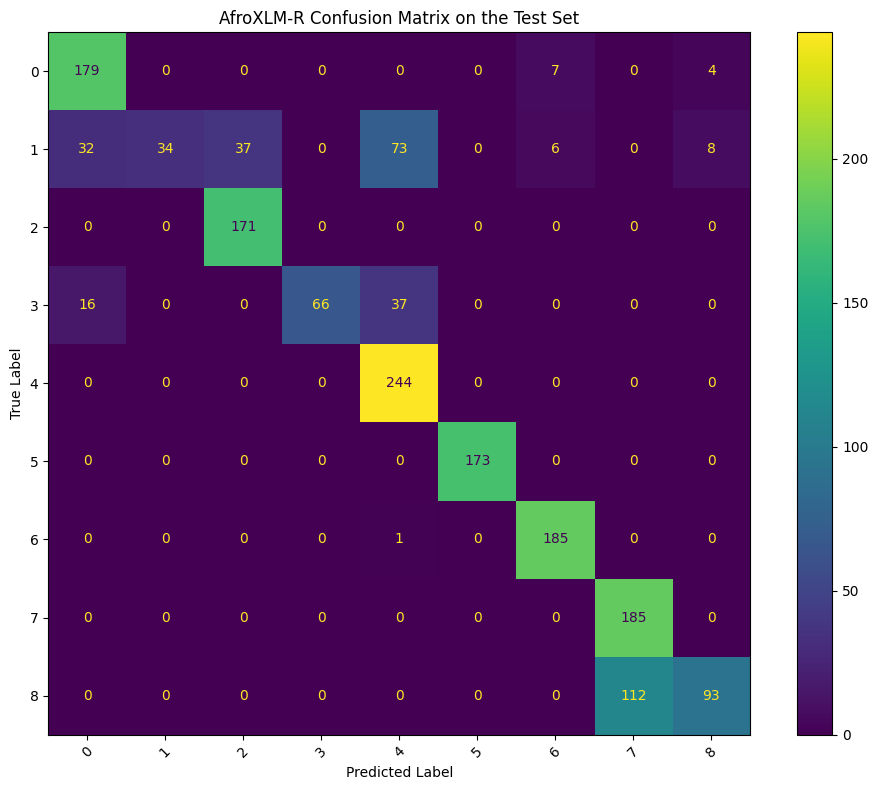


CLASS PERFORMANCE SUMMARY
----------------------------------------------------------------------
Best-performing class : 5 (F1 = 1.0000)
Lowest-performing class: 1 (F1 = 0.3036)

Class-wise evaluation verified successfully.
Number of classes evaluated: 9
Total confusion-matrix samples: 1,663

CELL 16 COMPLETED


In [ ]:
# ============================================================
# CELL 16: CLASS-WISE PERFORMANCE AND CONFUSION MATRIX
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("CELL 16: CLASS-WISE PERFORMANCE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. CLASS-WISE CLASSIFICATION REPORT
# ------------------------------------------------------------

class_report_dict = classification_report(
    test_labels,
    test_predictions,
    output_dict=True,
    zero_division=0
)

# Keep only actual classes
class_rows = []

for label in sorted(np.unique(test_labels)):
    label_str = str(label)

    class_rows.append({
        "Class": int(label),
        "Precision": class_report_dict[label_str]["precision"],
        "Recall": class_report_dict[label_str]["recall"],
        "F1-Score": class_report_dict[label_str]["f1-score"],
        "Support": int(class_report_dict[label_str]["support"])
    })

class_report_df = pd.DataFrame(class_rows)

print("\nCLASS-WISE TEST PERFORMANCE")
print("-" * 70)

display(
    class_report_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Support": "{:,.0f}"
    })
)

# ------------------------------------------------------------
# 2. CONFUSION MATRIX
# ------------------------------------------------------------

labels_sorted = sorted(np.unique(test_labels))

cm = confusion_matrix(
    test_labels,
    test_predictions,
    labels=labels_sorted
)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[f"True {x}" for x in labels_sorted],
    columns=[f"Pred {x}" for x in labels_sorted]
)

print("\nCONFUSION MATRIX")
print("-" * 70)

display(confusion_matrix_df)

# ------------------------------------------------------------
# 3. CONFUSION MATRIX VISUALIZATION
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels_sorted
)

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45
)

ax.set_title("AfroXLM-R Confusion Matrix on the Test Set")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. BEST AND WORST PERFORMING CLASSES
# ------------------------------------------------------------

best_class = class_report_df.loc[
    class_report_df["F1-Score"].idxmax()
]

worst_class = class_report_df.loc[
    class_report_df["F1-Score"].idxmin()
]

print("\nCLASS PERFORMANCE SUMMARY")
print("-" * 70)

print(
    f"Best-performing class : {int(best_class['Class'])} "
    f"(F1 = {best_class['F1-Score']:.4f})"
)

print(
    f"Lowest-performing class: {int(worst_class['Class'])} "
    f"(F1 = {worst_class['F1-Score']:.4f})"
)

# ------------------------------------------------------------
# 5. VERIFICATION
# ------------------------------------------------------------

assert cm.shape == (
    len(labels_sorted),
    len(labels_sorted)
)

assert class_report_df["Support"].sum() == len(test_labels)

assert cm.sum() == len(test_labels)

print("\nClass-wise evaluation verified successfully.")
print(f"Number of classes evaluated: {len(labels_sorted)}")
print(f"Total confusion-matrix samples: {cm.sum():,}")

print("\n" + "=" * 70)
print("CELL 16 COMPLETED")
print("=" * 70)

In [ ]:
# ============================================================
# CELL 17: DETAILED ERROR ANALYSIS
# ============================================================

print("=" * 70)
print("CELL 17: DETAILED ERROR ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# 1. VERIFY REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "correct",
    "true_label",
    "predicted_label",
    "text",
    "prediction_confidence"
]

missing_columns = [
    col for col in required_columns
    if col not in test_results_df.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )


# ------------------------------------------------------------
# 2. EXTRACT MISCLASSIFIED INSTANCES
# ------------------------------------------------------------

error_df = test_results_df[
    test_results_df["correct"] == False
].copy()

total_samples = len(test_results_df)
correct_predictions = int(
    test_results_df["correct"].sum()
)
error_count = len(error_df)

error_rate = (
    error_count / total_samples
    if total_samples > 0
    else 0
)

accuracy = (
    correct_predictions / total_samples
    if total_samples > 0
    else 0
)


print("\nMISCLASSIFICATION SUMMARY")
print("-" * 70)

print(
    f"Total test samples    : {total_samples:,}"
)

print(
    f"Correct predictions   : {correct_predictions:,}"
)

print(
    f"Misclassified samples : {error_count:,}"
)

print(
    f"Error rate            : {error_rate:.4f}"
)

print(
    f"Accuracy              : {accuracy:.4f}"
)


# ------------------------------------------------------------
# 3. MOST COMMON CONFUSION PAIRS
# ------------------------------------------------------------

confusion_pairs = (
    error_df
    .groupby(
        ["true_label", "predicted_label"]
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nMOST COMMON TRUE → PREDICTED CONFUSIONS")
print("-" * 70)

display(confusion_pairs)


# ------------------------------------------------------------
# 4. REPRESENTATIVE MISCLASSIFIED EXAMPLES
# ------------------------------------------------------------

print("\nREPRESENTATIVE MISCLASSIFIED EXAMPLES")
print("-" * 70)

representative_errors = (
    error_df[
        [
            "text",
            "true_label",
            "predicted_label",
            "prediction_confidence"
        ]
    ]
    .sort_values(
        "prediction_confidence",
        ascending=False
    )
    .head(30)
)

display(representative_errors)


# ------------------------------------------------------------
# 5. HIGH-CONFIDENCE MISCLASSIFICATIONS
# ------------------------------------------------------------

high_confidence_errors = error_df[
    error_df["prediction_confidence"] >= 0.90
].copy()

print("\nHIGH-CONFIDENCE MISCLASSIFICATIONS")
print("-" * 70)

print(
    f"Errors with confidence >= 0.90: "
    f"{len(high_confidence_errors):,}"
)

if len(high_confidence_errors) > 0:

    display(
        high_confidence_errors[
            [
                "text",
                "true_label",
                "predicted_label",
                "prediction_confidence"
            ]
        ]
        .sort_values(
            "prediction_confidence",
            ascending=False
        )
        .head(30)
    )

else:

    print(
        "No misclassified samples have "
        "prediction confidence >= 0.90."
    )


# ------------------------------------------------------------
# 6. ERROR RATE BY TRUE CLASS
# ------------------------------------------------------------

class_error_summary = (
    test_results_df
    .groupby("true_label")
    .agg(
        Total=("correct", "size"),
        Errors=(
            "correct",
            lambda x: (~x).sum()
        )
    )
    .reset_index()
)

class_error_summary["Correct"] = (
    class_error_summary["Total"]
    - class_error_summary["Errors"]
)

class_error_summary["Error_Rate"] = (
    class_error_summary["Errors"]
    / class_error_summary["Total"]
)

class_error_summary["Accuracy"] = (
    class_error_summary["Correct"]
    / class_error_summary["Total"]
)


print("\nERROR RATE BY TRUE CLASS")
print("-" * 70)

display(
    class_error_summary.style.format({
        "Total": "{:,.0f}",
        "Correct": "{:,.0f}",
        "Errors": "{:,.0f}",
        "Error_Rate": "{:.4f}",
        "Accuracy": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 7. TOP 10 CONFUSION PAIRS
# ------------------------------------------------------------

print("\nTOP 10 CONFUSION PAIRS")
print("-" * 70)

display(
    confusion_pairs.head(10)
)


# ------------------------------------------------------------
# 8. ERROR COUNT BY PREDICTED CLASS
# ------------------------------------------------------------

predicted_error_summary = (
    error_df
    .groupby("predicted_label")
    .size()
    .reset_index(name="Error_Count")
    .sort_values(
        "Error_Count",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nERROR COUNT BY PREDICTED CLASS")
print("-" * 70)

display(predicted_error_summary)


# ------------------------------------------------------------
# 9. CONFIDENCE STATISTICS FOR ERRORS
# ------------------------------------------------------------

print("\nERROR CONFIDENCE STATISTICS")
print("-" * 70)

if error_count > 0:

    print(
        f"Mean confidence : "
        f"{error_df['prediction_confidence'].mean():.6f}"
    )

    print(
        f"Median confidence : "
        f"{error_df['prediction_confidence'].median():.6f}"
    )

    print(
        f"Minimum confidence : "
        f"{error_df['prediction_confidence'].min():.6f}"
    )

    print(
        f"Maximum confidence : "
        f"{error_df['prediction_confidence'].max():.6f}"
    )

else:

    print("No errors found.")


# ------------------------------------------------------------
# 10. SAVE ERROR ANALYSIS FILES
# ------------------------------------------------------------

error_df.to_csv(
    "/content/afroxlmr_final_error_analysis.csv",
    index=False
)

confusion_pairs.to_csv(
    "/content/afroxlmr_final_confusion_pairs.csv",
    index=False
)

class_error_summary.to_csv(
    "/content/afroxlmr_per_class_error_rates.csv",
    index=False
)

predicted_error_summary.to_csv(
    "/content/afroxlmr_predicted_class_error_counts.csv",
    index=False
)


# ------------------------------------------------------------
# 11. FINAL DYNAMIC VERIFICATION
# ------------------------------------------------------------

assert (
    error_count + correct_predictions
    == total_samples
)

assert (
    confusion_pairs["Count"].sum()
    == error_count
)

assert (
    class_error_summary["Errors"].sum()
    == error_count
)

assert (
    class_error_summary["Correct"].sum()
    == correct_predictions
)

assert (
    class_error_summary["Total"].sum()
    == total_samples
)


# ------------------------------------------------------------
# 12. FINAL RESULTS
# ------------------------------------------------------------

print("\nERROR ANALYSIS VERIFIED SUCCESSFULLY")
print("-" * 70)

print(
    f"Total test samples     : {total_samples:,}"
)

print(
    f"Correct predictions    : {correct_predictions:,}"
)

print(
    f"Misclassified samples  : {error_count:,}"
)

print(
    f"Accuracy               : {accuracy:.4%}"
)

print(
    f"Error rate             : {error_rate:.4%}"
)

print(
    f"Unique confusion pairs : "
    f"{len(confusion_pairs):,}"
)


# ------------------------------------------------------------
# 13. SAVED FILES
# ------------------------------------------------------------

print("\nSAVED ERROR ANALYSIS FILES")
print("-" * 70)

print(
    "/content/afroxlmr_final_error_analysis.csv"
)

print(
    "/content/afroxlmr_final_confusion_pairs.csv"
)

print(
    "/content/afroxlmr_per_class_error_rates.csv"
)

print(
    "/content/afroxlmr_predicted_class_error_counts.csv"
)


print("\n" + "=" * 70)
print("CELL 17 COMPLETED")
print("=" * 70)

CELL 17: DETAILED ERROR ANALYSIS

MISCLASSIFICATION SUMMARY
----------------------------------------------------------------------
Total test samples    : 1,663
Correct predictions   : 1,330
Misclassified samples : 333
Error rate            : 0.2002
Accuracy              : 0.7998

MOST COMMON TRUE → PREDICTED CONFUSIONS
----------------------------------------------------------------------


,true_label,predicted_label,Count
0,8,7,112
1,1,4,73
2,3,4,37
3,1,2,37
4,1,0,32
5,3,0,16
6,1,8,8
7,0,6,7
8,1,6,6
9,0,8,4



REPRESENTATIVE MISCLASSIFIED EXAMPLES
----------------------------------------------------------------------


,text,true_label,predicted_label,prediction_confidence
333,በስብሰባ ክፍል በዚህ አመት ንጽህና ጎድሏል።,1,2,0.999932
2864,በሱቅ ነገ ንጽህና ጎድሏል።,1,2,0.999931
11352,በሱቅ በዚህ ወር ንጽህና ጎድሏል።,1,2,0.999931
5048,በባንክ በዚህ አመት ንጽህና ጎድሏል።,1,2,0.999931
1049,በትምህርት ቤት ነገ ጠዋት ንጽህና ጎድሏል።,1,2,0.999931
7858,በቤት ዛሬ ንጽህና ጎድሏል።,1,2,0.999931
2835,በባንክ በዚህ ወር ንጽህና ጎድሏል።,1,2,0.999931
1867,በመንገድ ላይ ዛሬ ማታ ንጽህና ጎድሏል።,1,2,0.999931
6774,በከተማው ውስጥ ነገ ንጽህና ጎድሏል።,1,2,0.999931
10184,በትምህርት ቤት ዛሬ ንጽህና ጎድሏል።,1,2,0.999931



HIGH-CONFIDENCE MISCLASSIFICATIONS
----------------------------------------------------------------------
Errors with confidence >= 0.90: 308


...


TOP 10 CONFUSION PAIRS
----------------------------------------------------------------------


,true_label,predicted_label,Count
0,8,7,112
1,1,4,73
2,3,4,37
3,1,2,37
4,1,0,32
5,3,0,16
6,1,8,8
7,0,6,7
8,1,6,6
9,0,8,4



ERROR COUNT BY PREDICTED CLASS
----------------------------------------------------------------------


,predicted_label,Error_Count
0,7,112
1,4,111
2,0,48
3,2,37
4,6,13
5,8,12



ERROR CONFIDENCE STATISTICS
----------------------------------------------------------------------
Mean confidence : 0.971719
Median confidence : 0.999632
Minimum confidence : 0.505212
Maximum confidence : 0.999932

ERROR ANALYSIS VERIFIED SUCCESSFULLY
----------------------------------------------------------------------
Total test samples     : 1,663
Correct predictions    : 1,330
Misclassified samples  : 333
Accuracy               : 79.9759%
Error rate             : 20.0241%
Unique confusion pairs : 11

SAVED ERROR ANALYSIS FILES
----------------------------------------------------------------------
/content/afroxlmr_final_error_analysis.csv
/content/afroxlmr_final_confusion_pairs.csv
/content/afroxlmr_per_class_error_rates.csv
/content/afroxlmr_predicted_class_error_counts.csv

CELL 17 COMPLETED


CELL 18: TRAINING AND VALIDATION LEARNING-CURVE ANALYSIS

AVAILABLE AFROXLM-R CHECKPOINTS
----------------------------------------------------------------------
/content/afroxlmr_intention_detection/checkpoint-4482
/content/afroxlmr_intention_detection/checkpoint-4980

TRAINER STATE FILES FOUND
----------------------------------------------------------------------
/content/afroxlmr_intention_detection/checkpoint-4482/trainer_state.json
/content/afroxlmr_intention_detection/checkpoint-4980/trainer_state.json

SELECTED TRAINING STATE
----------------------------------------------------------------------
/content/afroxlmr_intention_detection/checkpoint-4980/trainer_state.json

AVAILABLE TRAINING LOG COLUMNS
----------------------------------------------------------------------
['epoch', 'grad_norm', 'learning_rate', 'loss', 'step', 'eval_accuracy', 'eval_loss', 'eval_macro_f1', 'eval_macro_precision', 'eval_macro_recall', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second',

,epoch,grad_norm,learning_rate,loss,step,eval_accuracy,eval_loss,eval_macro_f1,eval_macro_precision,eval_macro_recall,eval_runtime,eval_samples_per_second,eval_steps_per_second,eval_weighted_f1,eval_weighted_precision,eval_weighted_recall
0,1.0,0.071357,1.800402e-05,0.221943,498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,NaN,NaN,NaN,498,0.801292,0.692785,0.736713,0.710848,0.783900,2.5283,734.493,46.277,0.758630,0.735591,0.801292
2,2.0,0.019192,1.600402e-05,0.001769,996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,NaN,NaN,NaN,996,0.788368,0.847853,0.725080,0.699718,0.771275,2.0624,900.411,56.730,0.747953,0.726747,0.788368
4,3.0,0.018827,1.400402e-05,0.000802,1494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3.0,NaN,NaN,NaN,1494,0.805600,0.826684,0.746838,0.824123,0.787640,1.8974,978.701,61.663,0.769099,0.840945,0.805600
6,4.0,0.005183,1.200402e-05,0.000482,1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.0,NaN,NaN,NaN,1992,0.812601,0.851192,0.757493,0.830839,0.794856,1.9479,953.351,60.066,0.778829,0.846644,0.812601
8,5.0,0.003410,1.000402e-05,0.000331,2490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,5.0,NaN,NaN,NaN,2490,0.814755,0.883471,0.759763,0.834609,0.796988,2.1970,845.233,53.254,0.781198,0.850324,0.814755



TRAINING HISTORY SUMMARY
----------------------------------------------------------------------
Training log records   : 10
Validation evaluations : 10

VALIDATION PERFORMANCE
----------------------------------------------------------------------


,epoch,step,eval_loss,eval_accuracy,eval_macro_f1,eval_weighted_f1
0,1.0,498,0.692785,0.801292,0.736713,0.758630
1,2.0,996,0.847853,0.788368,0.725080,0.747953
2,3.0,1494,0.826684,0.805600,0.746838,0.769099
3,4.0,1992,0.851192,0.812601,0.757493,0.778829
4,5.0,2490,0.883471,0.814755,0.759763,0.781198
5,6.0,2988,0.871530,0.834141,0.781851,0.801398
6,7.0,3486,0.889752,0.835218,0.782959,0.802468
7,8.0,3984,0.902565,0.836295,0.784756,0.804177
8,9.0,4482,0.910653,0.837372,0.785650,0.805193
9,10.0,4980,0.904913,0.837911,0.786867,0.806262



BEST VALIDATION PERFORMANCE
----------------------------------------------------------------------
Best epoch       : 10.0000
Best step        : 4980.0
Validation loss  : 0.904913
Validation accuracy : 0.837911
Validation Macro F1 : 0.786867

TRAINING LOSS
----------------------------------------------------------------------


,epoch,step,loss
0,1.0,498,0.221943
1,2.0,996,0.001769
2,3.0,1494,0.000802
3,4.0,1992,0.000482
4,5.0,2490,0.000331
5,6.0,2988,0.000248
6,7.0,3486,0.000195
7,8.0,3984,0.000162
8,9.0,4482,0.000143
9,10.0,4980,0.000233


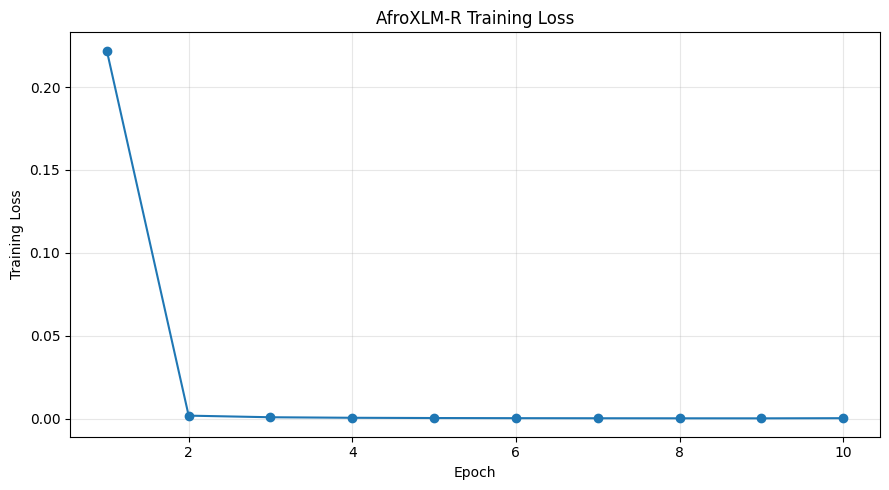

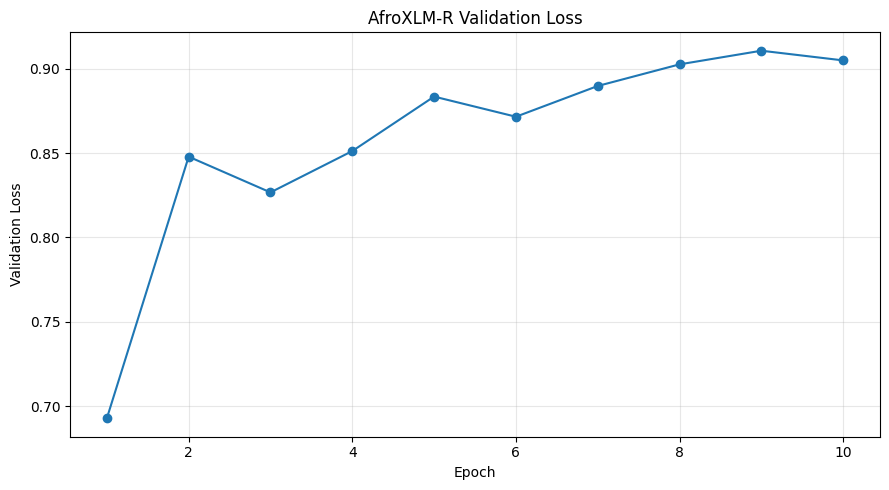

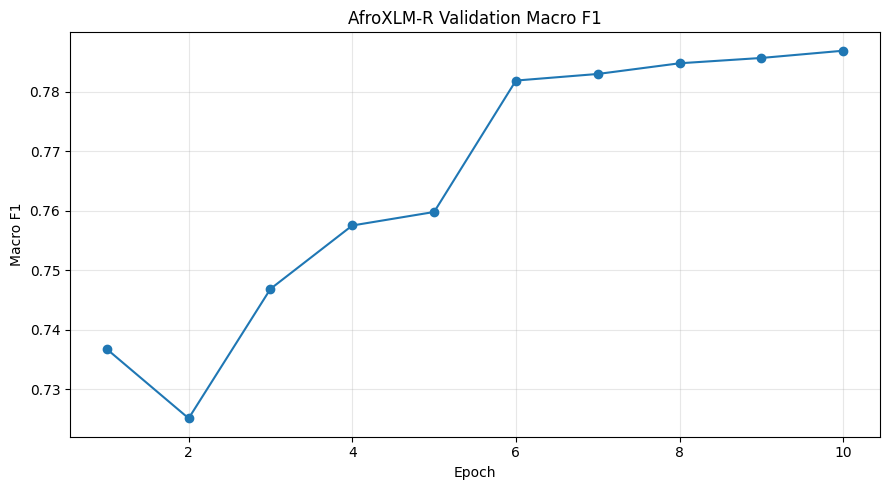


LEARNING BEHAVIOR CHECK
----------------------------------------------------------------------
Best validation Macro F1  : 0.786867
Final validation Macro F1 : 0.786867
Difference                 : 0.000000

LEARNING-CURVE ANALYSIS VERIFIED SUCCESSFULLY
----------------------------------------------------------------------
Logged records         : 20
Training records       : 10
Validation evaluations : 10
Source checkpoint      : /content/afroxlmr_intention_detection/checkpoint-4980/trainer_state.json

Saved files:
/content/afroxlmr_saved_training_log_history.csv
/content/afroxlmr_training_history.csv
/content/afroxlmr_validation_history.csv

CELL 18 COMPLETED


In [ ]:
# ============================================================
# CELL 18: TRAINING AND VALIDATION LEARNING-CURVE ANALYSIS
# ============================================================

import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("CELL 18: TRAINING AND VALIDATION LEARNING-CURVE ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# 1. FIND SAVED AFROXLM-R TRAINER STATE
# ------------------------------------------------------------

model_dir = "/content/afroxlmr_intention_detection"

checkpoint_dirs = []

if os.path.exists(model_dir):

    for item in os.listdir(model_dir):

        full_path = os.path.join(
            model_dir,
            item
        )

        if (
            os.path.isdir(full_path)
            and item.startswith("checkpoint-")
        ):
            checkpoint_dirs.append(full_path)


# Sort checkpoints by checkpoint number
checkpoint_dirs = sorted(
    checkpoint_dirs,
    key=lambda x: int(
        os.path.basename(x).split("-")[-1]
    )
)

print("\nAVAILABLE AFROXLM-R CHECKPOINTS")
print("-" * 70)

for checkpoint in checkpoint_dirs:
    print(checkpoint)


# ------------------------------------------------------------
# 2. LOCATE TRAINER_STATE.JSON
# ------------------------------------------------------------

trainer_state_files = []

for checkpoint in checkpoint_dirs:

    state_file = os.path.join(
        checkpoint,
        "trainer_state.json"
    )

    if os.path.exists(state_file):
        trainer_state_files.append(state_file)


if len(trainer_state_files) == 0:

    raise FileNotFoundError(
        "No trainer_state.json was found inside the "
        "AfroXLM-R checkpoint directories."
    )


print("\nTRAINER STATE FILES FOUND")
print("-" * 70)

for state_file in trainer_state_files:
    print(state_file)


# ------------------------------------------------------------
# 3. SELECT THE LATEST AVAILABLE CHECKPOINT
# ------------------------------------------------------------

selected_state_file = trainer_state_files[-1]

print("\nSELECTED TRAINING STATE")
print("-" * 70)

print(selected_state_file)


# ------------------------------------------------------------
# 4. LOAD TRAINING STATE
# ------------------------------------------------------------

with open(
    selected_state_file,
    "r",
    encoding="utf-8"
) as f:

    trainer_state = json.load(f)


if "log_history" not in trainer_state:

    raise KeyError(
        "The saved trainer_state.json does not contain "
        "'log_history'."
    )


log_history = trainer_state["log_history"]


if len(log_history) == 0:

    raise ValueError(
        "The saved training history is empty."
    )


history_df = pd.DataFrame(
    log_history
)


# ------------------------------------------------------------
# 5. DISPLAY AVAILABLE LOG COLUMNS
# ------------------------------------------------------------

print("\nAVAILABLE TRAINING LOG COLUMNS")
print("-" * 70)

print(
    history_df.columns.tolist()
)


# ------------------------------------------------------------
# 6. DISPLAY RAW HISTORY
# ------------------------------------------------------------

print("\nSAVED TRAINING HISTORY")
print("-" * 70)

display(history_df)


# ------------------------------------------------------------
# 7. SEPARATE TRAINING AND VALIDATION RECORDS
# ------------------------------------------------------------

if "loss" in history_df.columns:

    train_history = history_df[
        history_df["loss"].notna()
    ].copy()

else:

    train_history = pd.DataFrame()


if "eval_loss" in history_df.columns:

    eval_history = history_df[
        history_df["eval_loss"].notna()
    ].copy()

else:

    eval_history = pd.DataFrame()


print("\nTRAINING HISTORY SUMMARY")
print("-" * 70)

print(
    f"Training log records   : "
    f"{len(train_history):,}"
)

print(
    f"Validation evaluations : "
    f"{len(eval_history):,}"
)


# ------------------------------------------------------------
# 8. VALIDATION PERFORMANCE
# ------------------------------------------------------------

if len(eval_history) > 0:

    validation_columns = [
        col
        for col in [
            "epoch",
            "step",
            "eval_loss",
            "eval_accuracy",
            "eval_precision",
            "eval_recall",
            "eval_macro_f1",
            "eval_weighted_f1"
        ]
        if col in eval_history.columns
    ]

    print("\nVALIDATION PERFORMANCE")
    print("-" * 70)

    display(
        eval_history[
            validation_columns
        ].reset_index(drop=True)
    )

else:

    print(
        "\nNo validation records found."
    )


# ------------------------------------------------------------
# 9. BEST VALIDATION MACRO-F1
# ------------------------------------------------------------

if (
    len(eval_history) > 0
    and "eval_macro_f1" in eval_history.columns
):

    valid_f1 = eval_history[
        "eval_macro_f1"
    ].dropna()

    if len(valid_f1) > 0:

        best_idx = (
            eval_history[
                "eval_macro_f1"
            ].idxmax()
        )

        best_eval = eval_history.loc[
            best_idx
        ]

        print("\nBEST VALIDATION PERFORMANCE")
        print("-" * 70)

        if "epoch" in best_eval.index:

            print(
                f"Best epoch       : "
                f"{best_eval['epoch']:.4f}"
            )

        if "step" in best_eval.index:

            print(
                f"Best step        : "
                f"{best_eval['step']}"
            )

        if "eval_loss" in best_eval.index:

            print(
                f"Validation loss  : "
                f"{best_eval['eval_loss']:.6f}"
            )

        if "eval_accuracy" in best_eval.index:

            print(
                f"Validation accuracy : "
                f"{best_eval['eval_accuracy']:.6f}"
            )

        print(
            f"Validation Macro F1 : "
            f"{best_eval['eval_macro_f1']:.6f}"
        )


# ------------------------------------------------------------
# 10. TRAINING LOSS TABLE
# ------------------------------------------------------------

if len(train_history) > 0:

    print("\nTRAINING LOSS")
    print("-" * 70)

    loss_columns = [
        col
        for col in [
            "epoch",
            "step",
            "loss"
        ]
        if col in train_history.columns
    ]

    display(
        train_history[
            loss_columns
        ].reset_index(drop=True)
    )


# ------------------------------------------------------------
# 11. PLOT TRAINING LOSS
# ------------------------------------------------------------

if (
    len(train_history) > 0
    and "loss" in train_history.columns
):

    if "epoch" in train_history.columns:

        x_values = train_history["epoch"]
        x_label = "Epoch"

    elif "step" in train_history.columns:

        x_values = train_history["step"]
        x_label = "Training Step"

    else:

        x_values = np.arange(
            len(train_history)
        )

        x_label = "Training Record"

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        x_values,
        train_history["loss"],
        marker="o"
    )

    plt.xlabel(x_label)
    plt.ylabel("Training Loss")

    plt.title(
        "AfroXLM-R Training Loss"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        "/content/afroxlmr_training_loss.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# 12. PLOT VALIDATION LOSS
# ------------------------------------------------------------

if (
    len(eval_history) > 0
    and "eval_loss" in eval_history.columns
):

    if "epoch" in eval_history.columns:

        x_values = eval_history["epoch"]

    elif "step" in eval_history.columns:

        x_values = eval_history["step"]

    else:

        x_values = np.arange(
            len(eval_history)
        )

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        x_values,
        eval_history["eval_loss"],
        marker="o"
    )

    plt.xlabel(
        "Epoch" if "epoch" in eval_history.columns
        else "Evaluation"
    )

    plt.ylabel("Validation Loss")

    plt.title(
        "AfroXLM-R Validation Loss"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        "/content/afroxlmr_validation_loss.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# 13. PLOT VALIDATION MACRO-F1
# ------------------------------------------------------------

if (
    len(eval_history) > 0
    and "eval_macro_f1" in eval_history.columns
):

    if "epoch" in eval_history.columns:

        x_values = eval_history["epoch"]

    elif "step" in eval_history.columns:

        x_values = eval_history["step"]

    else:

        x_values = np.arange(
            len(eval_history)
        )

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        x_values,
        eval_history["eval_macro_f1"],
        marker="o"
    )

    plt.xlabel(
        "Epoch" if "epoch" in eval_history.columns
        else "Evaluation"
    )

    plt.ylabel("Macro F1")

    plt.title(
        "AfroXLM-R Validation Macro F1"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        "/content/afroxlmr_validation_macro_f1.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# 14. LEARNING BEHAVIOR CHECK
# ------------------------------------------------------------

print("\nLEARNING BEHAVIOR CHECK")
print("-" * 70)

if (
    len(eval_history) > 0
    and "eval_macro_f1" in eval_history.columns
):

    valid_eval = eval_history[
        eval_history["eval_macro_f1"].notna()
    ].copy()

    if len(valid_eval) > 0:

        best_position = (
            valid_eval[
                "eval_macro_f1"
            ].values.argmax()
        )

        final_position = (
            len(valid_eval) - 1
        )

        best_f1 = (
            valid_eval[
                "eval_macro_f1"
            ].iloc[best_position]
        )

        final_f1 = (
            valid_eval[
                "eval_macro_f1"
            ].iloc[final_position]
        )

        print(
            f"Best validation Macro F1  : "
            f"{best_f1:.6f}"
        )

        print(
            f"Final validation Macro F1 : "
            f"{final_f1:.6f}"
        )

        print(
            f"Difference                 : "
            f"{best_f1 - final_f1:.6f}"
        )


# ------------------------------------------------------------
# 15. SAVE HISTORY FILES
# ------------------------------------------------------------

history_df.to_csv(
    "/content/afroxlmr_saved_training_log_history.csv",
    index=False
)

if len(train_history) > 0:

    train_history.to_csv(
        "/content/afroxlmr_training_history.csv",
        index=False
    )

if len(eval_history) > 0:

    eval_history.to_csv(
        "/content/afroxlmr_validation_history.csv",
        index=False
    )


# ------------------------------------------------------------
# 16. FINAL VERIFICATION
# ------------------------------------------------------------

assert len(history_df) > 0

print("\nLEARNING-CURVE ANALYSIS VERIFIED SUCCESSFULLY")
print("-" * 70)

print(
    f"Logged records         : "
    f"{len(history_df):,}"
)

print(
    f"Training records       : "
    f"{len(train_history):,}"
)

print(
    f"Validation evaluations : "
    f"{len(eval_history):,}"
)

print(
    f"Source checkpoint      : "
    f"{selected_state_file}"
)

print("\nSaved files:")
print(
    "/content/afroxlmr_saved_training_log_history.csv"
)
print(
    "/content/afroxlmr_training_history.csv"
)
print(
    "/content/afroxlmr_validation_history.csv"
)

print("\n" + "=" * 70)
print("CELL 18 COMPLETED")
print("=" * 70)

In [ ]:
# ============================================================
# CELL 19: PER-CLASS TEST PERFORMANCE
# ============================================================

import os
import pandas as pd
import numpy as np
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)

print("=" * 70)
print("CELL 19: PER-CLASS TEST PERFORMANCE")
print("=" * 70)

# ------------------------------------------------------------
# 1. LOAD SAVED TEST PREDICTIONS
# ------------------------------------------------------------

prediction_files = [
    "/content/afroxlmr_checkpoint-4980_test_predictions.csv",
    "/content/afroxlmr_checkpoint-4482_test_predictions.csv"
]

prediction_file = None

for file_path in prediction_files:
    if os.path.exists(file_path):
        prediction_file = file_path
        break

if prediction_file is None:
    raise FileNotFoundError(
        "No saved AfroXLM-R test prediction file was found."
    )

print(f"\nPrediction file: {prediction_file}")

pred_df = pd.read_csv(prediction_file)

print("\nPrediction columns:")
print(pred_df.columns.tolist())

print(f"\nTotal prediction records: {len(pred_df):,}")


# ------------------------------------------------------------
# 2. IDENTIFY TRUE AND PREDICTED LABEL COLUMNS
# ------------------------------------------------------------

possible_true = [
    "true_label",
    "true",
    "label",
    "labels",
    "actual",
    "y_true"
]

possible_pred = [
    "predicted_label",
    "prediction",
    "pred",
    "predicted",
    "y_pred"
]

true_col = next(
    (
        col for col in possible_true
        if col in pred_df.columns
    ),
    None
)

pred_col = next(
    (
        col for col in possible_pred
        if col in pred_df.columns
    ),
    None
)

if true_col is None or pred_col is None:
    raise KeyError(
        "Could not identify the true-label and prediction columns."
    )

print(f"\nTrue label column      : {true_col}")
print(f"Predicted label column : {pred_col}")


# ------------------------------------------------------------
# 3. LABEL MAPPING
# ------------------------------------------------------------

label_names = {
    0: "Assertion",
    1: "Complaint",
    2: "Phatic",
    3: "Promise",
    4: "Refusal",
    5: "Request",
    6: "Sarcasm/Irony",
    7: "Suggestion",
    8: "Warning"
}


# ------------------------------------------------------------
# 4. CONVERT LABELS IF NUMERIC
# ------------------------------------------------------------

def convert_label(value):

    try:
        numeric_value = int(value)

        if numeric_value in label_names:
            return label_names[numeric_value]

    except:
        pass

    return str(value)


y_true = pred_df[true_col].apply(convert_label)
y_pred = pred_df[pred_col].apply(convert_label)


# ------------------------------------------------------------
# 5. VERIFY LABEL SET
# ------------------------------------------------------------

expected_labels = list(
    label_names.values()
)

observed_labels = sorted(
    set(y_true) | set(y_pred)
)

print("\nObserved labels:")
print(observed_labels)

print(
    f"\nNumber of observed classes: "
    f"{len(observed_labels)}"
)


# ------------------------------------------------------------
# 6. CALCULATE PER-CLASS METRICS
# ------------------------------------------------------------

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=expected_labels,
        zero_division=0
    )
)

per_class_df = pd.DataFrame({
    "Class": expected_labels,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Support": support.astype(int)
})


# ------------------------------------------------------------
# 7. DISPLAY PER-CLASS RESULTS
# ------------------------------------------------------------

print("\nPER-CLASS TEST PERFORMANCE")
print("-" * 70)

display(
    per_class_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "Support": "{:.0f}"
    })
)


# ------------------------------------------------------------
# 8. OVERALL METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision.mean()
macro_recall = recall.mean()
macro_f1 = f1.mean()

weighted_precision, weighted_recall, weighted_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=expected_labels,
        average="weighted",
        zero_division=0
    )
)

print("\nOVERALL TEST PERFORMANCE")
print("-" * 70)

print(
    f"Accuracy          : {accuracy:.6f}"
)

print(
    f"Macro Precision   : {macro_precision:.6f}"
)

print(
    f"Macro Recall      : {macro_recall:.6f}"
)

print(
    f"Macro F1          : {macro_f1:.6f}"
)

print(
    f"Weighted Precision: {weighted_precision:.6f}"
)

print(
    f"Weighted Recall   : {weighted_recall:.6f}"
)

print(
    f"Weighted F1       : {weighted_f1:.6f}"
)


# ------------------------------------------------------------
# 9. SAVE RESULTS
# ------------------------------------------------------------

output_file = (
    "/content/afroxlmr_per_class_test_performance.csv"
)

per_class_df.to_csv(
    output_file,
    index=False
)

print(
    f"\nSaved: {output_file}"
)


# ------------------------------------------------------------
# 10. VERIFICATION
# ------------------------------------------------------------

assert len(per_class_df) == len(expected_labels)
assert per_class_df["Support"].sum() == len(y_true)

print("\nPER-CLASS PERFORMANCE VERIFIED")
print(
    f"Total test samples: "
    f"{per_class_df['Support'].sum():,}"
)

print("=" * 70)
print("CELL 19 COMPLETED")
print("=" * 70)

CELL 19: PER-CLASS TEST PERFORMANCE

Prediction file: /content/afroxlmr_checkpoint-4980_test_predictions.csv

Prediction columns:
['text', 'label', 'predicted_label']

Total prediction records: 1,663

True label column      : label
Predicted label column : predicted_label

Observed labels:
['Assertion', 'Complaint', 'Phatic', 'Promise', 'Refusal', 'Request', 'Sarcasm/Irony', 'Suggestion', 'Warning']

Number of observed classes: 9

PER-CLASS TEST PERFORMANCE
----------------------------------------------------------------------


,Class,Precision,Recall,F1,Support
0,Assertion,0.7885,0.9421,0.8585,190
1,Complaint,1.0000,0.1789,0.3036,190
2,Phatic,0.8221,1.0000,0.9024,171
3,Promise,1.0000,0.5546,0.7135,119
4,Refusal,0.6873,1.0000,0.8147,244
5,Request,1.0000,1.0000,1.0000,173
6,Sarcasm/Irony,0.9343,0.9946,0.9635,186
7,Suggestion,0.6229,1.0000,0.7676,185
8,Warning,0.8857,0.4537,0.6000,205



OVERALL TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy          : 0.799759
Macro Precision   : 0.860104
Macro Recall      : 0.791551
Macro F1          : 0.769316
Weighted Precision: 0.848291
Weighted Recall   : 0.799759
Weighted F1       : 0.767304

Saved: /content/afroxlmr_per_class_test_performance.csv

PER-CLASS PERFORMANCE VERIFIED
Total test samples: 1,663
CELL 19 COMPLETED


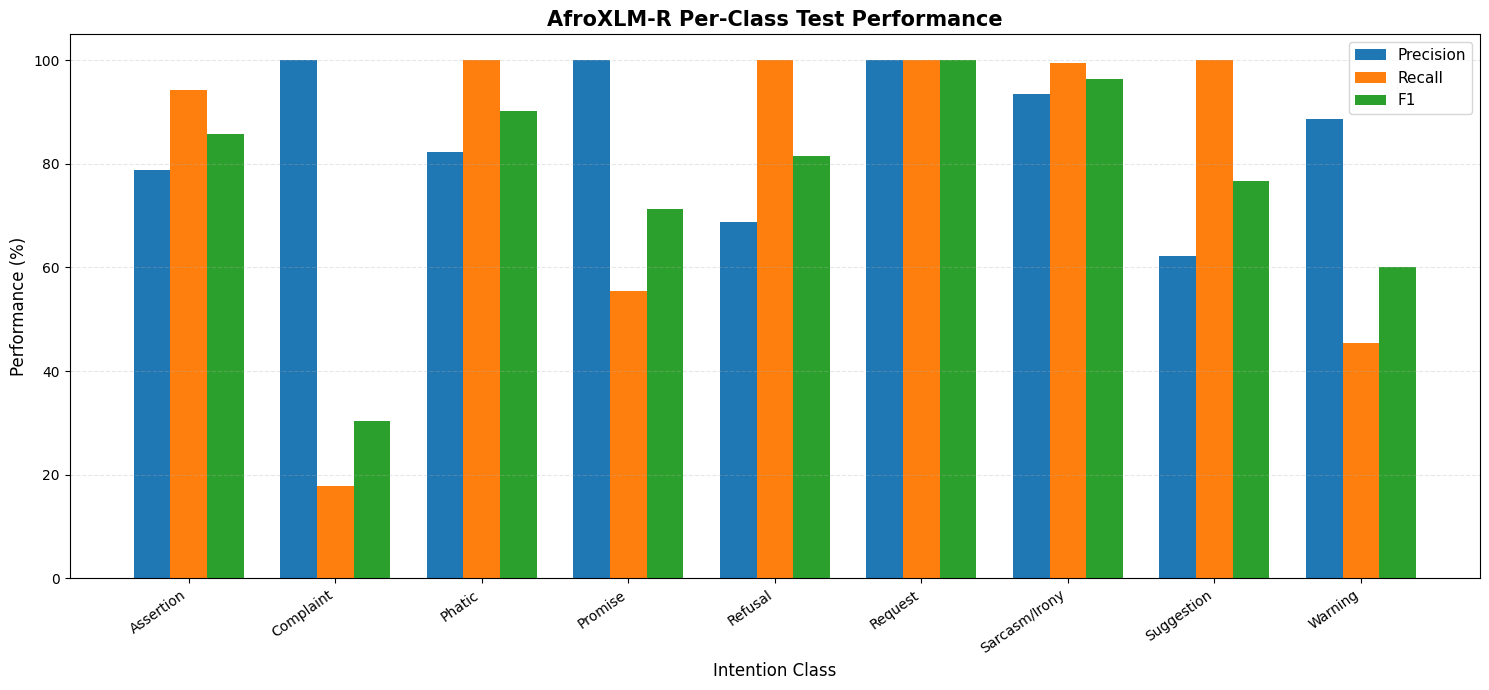

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# AfroXLM-R Per-Class Test Performance
# ============================================================

data = {
    "Class": [
        "Assertion",
        "Complaint",
        "Phatic",
        "Promise",
        "Refusal",
        "Request",
        "Sarcasm/Irony",
        "Suggestion",
        "Warning"
    ],
    "Precision": [
        0.7885, 1.0000, 0.8221, 1.0000, 0.6873,
        1.0000, 0.9343, 0.6229, 0.8857
    ],
    "Recall": [
        0.9421, 0.1789, 1.0000, 0.5546, 1.0000,
        1.0000, 0.9946, 1.0000, 0.4537
    ],
    "F1": [
        0.8585, 0.3036, 0.9024, 0.7135, 0.8147,
        1.0000, 0.9635, 0.7676, 0.6000
    ],
    "Support": [
        190, 190, 171, 119, 244,
        173, 186, 185, 205
    ]
}

df = pd.DataFrame(data)

# Convert scores to percentages
metrics = ["Precision", "Recall", "F1"]
df_percent = df.copy()
df_percent[metrics] = df_percent[metrics] * 100

# ============================================================
# Plot
# ============================================================

x = np.arange(len(df["Class"]))
width = 0.25

plt.figure(figsize=(15, 7))

plt.bar(
    x - width,
    df_percent["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x,
    df_percent["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + width,
    df_percent["F1"],
    width,
    label="F1"
)

# Labels
plt.xlabel("Intention Class", fontsize=12)
plt.ylabel("Performance (%)", fontsize=12)

plt.title(
    "AfroXLM-R Per-Class Test Performance",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    x,
    df["Class"],
    rotation=35,
    ha="right"
)

plt.ylim(0, 105)

plt.legend(
    loc="upper right",
    fontsize=11
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

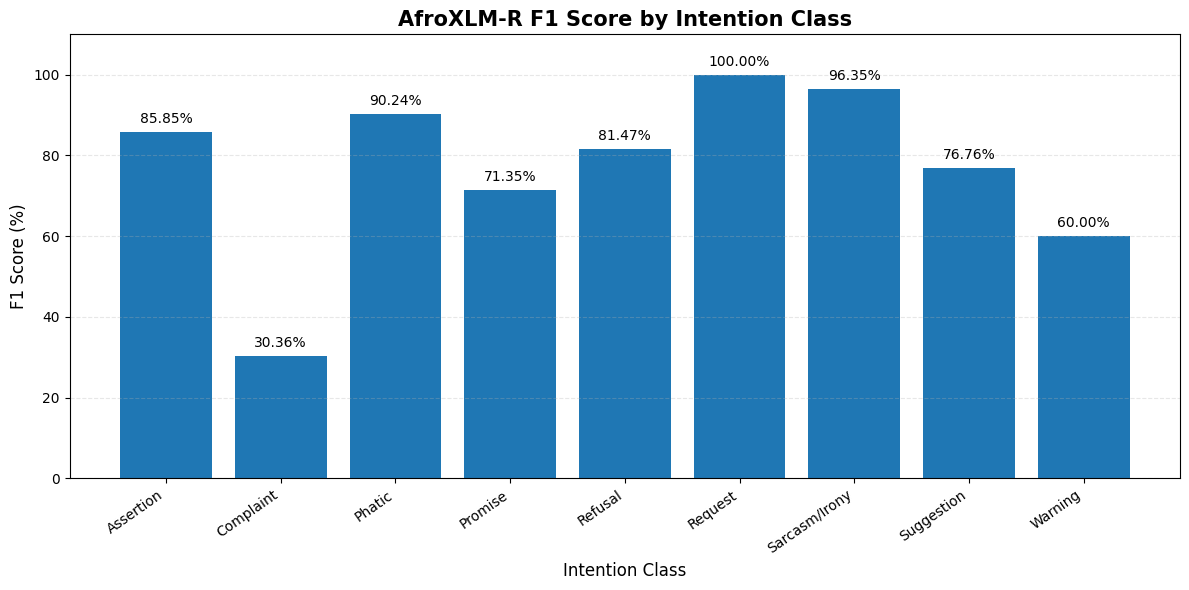

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# AfroXLM-R F1 scores
data = {
    "Class": [
        "Assertion",
        "Complaint",
        "Phatic",
        "Promise",
        "Refusal",
        "Request",
        "Sarcasm/Irony",
        "Suggestion",
        "Warning"
    ],
    "F1": [
        0.8585,
        0.3036,
        0.9024,
        0.7135,
        0.8147,
        1.0000,
        0.9635,
        0.7676,
        0.6000
    ]
}

df = pd.DataFrame(data)

# Convert F1 to percentage
df["F1_Percent"] = df["F1"] * 100

# Plot
plt.figure(figsize=(12, 6))

bars = plt.bar(
    df["Class"],
    df["F1_Percent"]
)

# Add values on top of bars
for bar, value in zip(bars, df["F1_Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("Intention Class", fontsize=12)
plt.ylabel("F1 Score (%)", fontsize=12)

plt.title(
    "AfroXLM-R F1 Score by Intention Class",
    fontsize=15,
    fontweight="bold"
)

plt.ylim(0, 110)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

# Save at 300 DPI for manuscript
plt.savefig(
    "AfroXLMR_F1_Per_Class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# CELL 17: FINAL AFROXLM-R TEST PREDICTION

import torch, numpy as np, pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

DATA="/content/amharic_intention_dataset.csv"
MODEL="/content/afroxlmr_intention_detection/checkpoint-4980"

labels=["Assertion","Complaint","Phatic","Promise","Refusal",
        "Request","Sarcasm/Irony","Suggestion","Warning"]
label2id={x:i for i,x in enumerate(labels)}

df=pd.read_csv(DATA)
test=df[df["split"].str.lower()=="test"].copy()
y_true=test["label"].map(label2id).to_numpy()

tok=AutoTokenizer.from_pretrained(MODEL)
model=AutoModelForSequenceClassification.from_pretrained(MODEL).cuda()
model.eval()

preds=[]
for i in range(0,len(test),16):
    x=tok(test["text"].iloc[i:i+16].tolist(),
          padding=True,truncation=True,max_length=128,
          return_tensors="pt").to("cuda")
    with torch.no_grad():
        preds.extend(torch.argmax(model(**x).logits,dim=1).cpu().numpy())

y_pred=np.array(preds)
p,r,f1,_=precision_recall_fscore_support(
    y_true,y_pred,average="macro",zero_division=0)

print("\n"+"="*55)
print("CELL 17: FINAL AFROXLM-R TEST PREDICTION")
print("="*55)
print(f"Accuracy        : {accuracy_score(y_true,y_pred):.4f}")
print(f"Macro Precision : {p:.4f}")
print(f"Macro Recall    : {r:.4f}")
print(f"Macro F1        : {f1:.4f}")
print(f"Correct         : {(y_true==y_pred).sum()}")
print(f"Incorrect       : {(y_true!=y_pred).sum()}")
print(f"Total           : {len(y_true)}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


CELL 17: FINAL AFROXLM-R TEST PREDICTION
Accuracy        : 0.7998
Macro Precision : 0.8601
Macro Recall    : 0.7916
Macro F1        : 0.7693
Correct         : 1330
Incorrect       : 333
Total           : 1663


CELL 20: CONFUSION MATRIX

Prediction file: /content/afroxlmr_checkpoint-4980_test_predictions.csv
Test samples: 1,663
True label column: label
Predicted label column: predicted_label

CONFUSION MATRIX
----------------------------------------------------------------------


,Assertion,Complaint,Phatic,Promise,Refusal,Request,Sarcasm/Irony,Suggestion,Warning
Assertion,179,0,0,0,0,0,7,0,4
Complaint,32,34,37,0,73,0,6,0,8
Phatic,0,0,171,0,0,0,0,0,0
Promise,16,0,0,66,37,0,0,0,0
Refusal,0,0,0,0,244,0,0,0,0
Request,0,0,0,0,0,173,0,0,0
Sarcasm/Irony,0,0,0,0,1,0,185,0,0
Suggestion,0,0,0,0,0,0,0,185,0
Warning,0,0,0,0,0,0,0,112,93



Matrix total: 1,663
Correct predictions: 1,330
Incorrect predictions: 333

Saved: /content/afroxlmr_confusion_matrix.csv


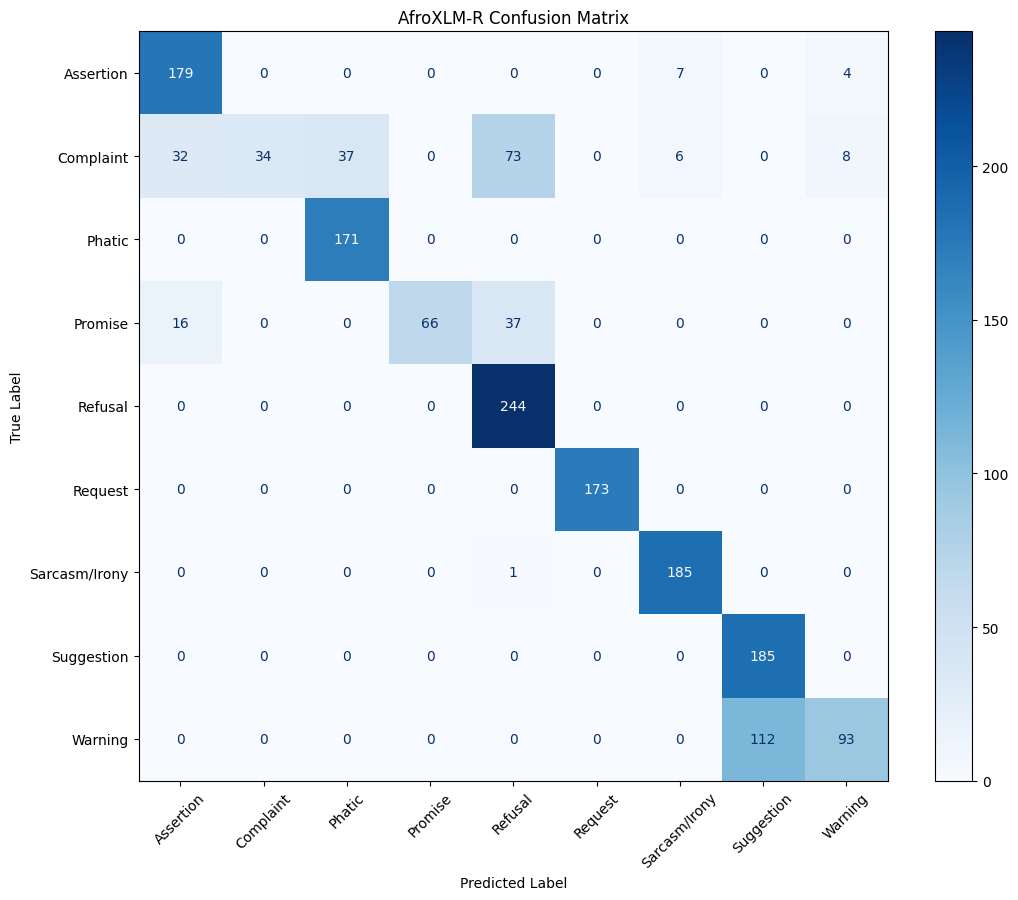


NORMALIZED CONFUSION MATRIX
----------------------------------------------------------------------


,Assertion,Complaint,Phatic,Promise,Refusal,Request,Sarcasm/Irony,Suggestion,Warning
Assertion,0.9421,0.0000,0.0000,0.0000,0.0000,0.0000,0.0368,0.0000,0.0211
Complaint,0.1684,0.1789,0.1947,0.0000,0.3842,0.0000,0.0316,0.0000,0.0421
Phatic,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Promise,0.1345,0.0000,0.0000,0.5546,0.3109,0.0000,0.0000,0.0000,0.0000
Refusal,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
Request,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
Sarcasm/Irony,0.0000,0.0000,0.0000,0.0000,0.0054,0.0000,0.9946,0.0000,0.0000
Suggestion,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
Warning,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5463,0.4537


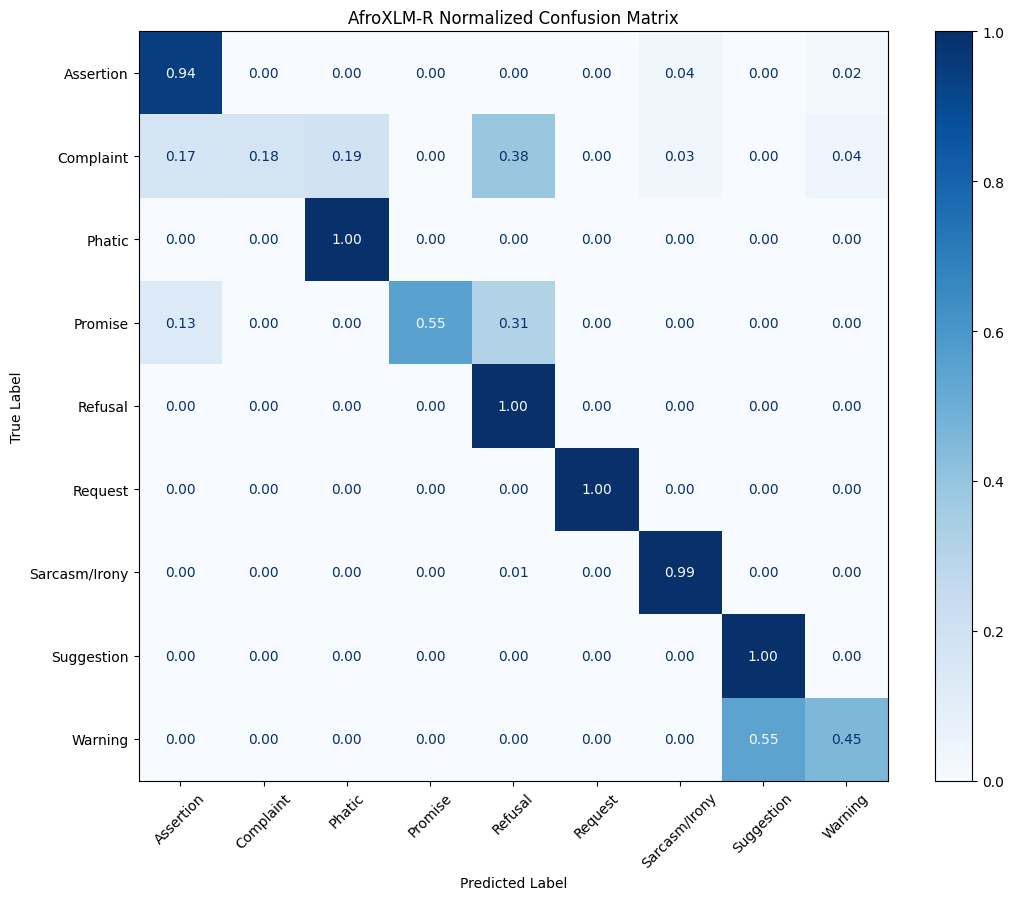


CONFUSION MATRIX ANALYSIS COMPLETED
----------------------------------------------------------------------
Classes: 9
Test samples: 1,663
Correct: 1,330
Incorrect: 333

Saved files:
/content/afroxlmr_confusion_matrix.csv
/content/afroxlmr_confusion_matrix.png
/content/afroxlmr_normalized_confusion_matrix.csv
/content/afroxlmr_normalized_confusion_matrix.png

CELL 20 COMPLETED


In [ ]:
# ============================================================
# CELL 20: CONFUSION MATRIX
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=" * 70)
print("CELL 20: CONFUSION MATRIX")
print("=" * 70)


# ------------------------------------------------------------
# 1. LOAD SAVED TEST PREDICTIONS
# ------------------------------------------------------------

prediction_files = [
    "/content/afroxlmr_checkpoint-4980_test_predictions.csv",
    "/content/afroxlmr_checkpoint-4482_test_predictions.csv"
]

prediction_file = next(
    (
        f for f in prediction_files
        if os.path.exists(f)
    ),
    None
)

if prediction_file is None:
    raise FileNotFoundError(
        "No saved AfroXLM-R test prediction file was found."
    )

pred_df = pd.read_csv(prediction_file)

print(f"\nPrediction file: {prediction_file}")
print(f"Test samples: {len(pred_df):,}")


# ------------------------------------------------------------
# 2. IDENTIFY LABEL COLUMNS
# ------------------------------------------------------------

true_candidates = [
    "true_label",
    "true",
    "label",
    "labels",
    "actual",
    "y_true"
]

pred_candidates = [
    "predicted_label",
    "prediction",
    "pred",
    "predicted",
    "y_pred"
]

true_col = next(
    (
        c for c in true_candidates
        if c in pred_df.columns
    ),
    None
)

pred_col = next(
    (
        c for c in pred_candidates
        if c in pred_df.columns
    ),
    None
)

if true_col is None or pred_col is None:
    raise KeyError(
        "Could not identify true and predicted label columns."
    )

print(f"True label column: {true_col}")
print(f"Predicted label column: {pred_col}")


# ------------------------------------------------------------
# 3. LABEL MAPPING
# ------------------------------------------------------------

label_names = {
    0: "Assertion",
    1: "Complaint",
    2: "Phatic",
    3: "Promise",
    4: "Refusal",
    5: "Request",
    6: "Sarcasm/Irony",
    7: "Suggestion",
    8: "Warning"
}

class_ids = list(label_names.keys())
class_names = list(label_names.values())


def normalize_label(value):

    try:
        numeric_value = int(value)

        if numeric_value in label_names:
            return numeric_value

    except:
        pass

    value = str(value).strip()

    reverse_mapping = {
        name: idx
        for idx, name in label_names.items()
    }

    if value in reverse_mapping:
        return reverse_mapping[value]

    raise ValueError(
        f"Unknown label encountered: {value}"
    )


y_true = pred_df[true_col].apply(normalize_label)
y_pred = pred_df[pred_col].apply(normalize_label)


# ------------------------------------------------------------
# 4. COMPUTE CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=class_ids
)

print("\nCONFUSION MATRIX")
print("-" * 70)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

display(cm_df)


# ------------------------------------------------------------
# 5. VERIFY MATRIX
# ------------------------------------------------------------

assert cm.shape == (
    len(class_names),
    len(class_names)
)

assert cm.sum() == len(y_true)

print(
    f"\nMatrix total: {cm.sum():,}"
)

print(
    f"Correct predictions: "
    f"{np.trace(cm):,}"
)

print(
    f"Incorrect predictions: "
    f"{cm.sum() - np.trace(cm):,}"
)


# ------------------------------------------------------------
# 6. SAVE RAW CONFUSION MATRIX
# ------------------------------------------------------------

raw_cm_file = (
    "/content/afroxlmr_confusion_matrix.csv"
)

cm_df.to_csv(
    raw_cm_file
)

print(
    f"\nSaved: {raw_cm_file}"
)


# ------------------------------------------------------------
# 7. PLOT RAW CONFUSION MATRIX
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 9)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d",
    colorbar=True
)

ax.set_title(
    "AfroXLM-R Confusion Matrix"
)

ax.set_xlabel(
    "Predicted Label"
)

ax.set_ylabel(
    "True Label"
)

plt.tight_layout()

raw_cm_png = (
    "/content/afroxlmr_confusion_matrix.png"
)

plt.savefig(
    raw_cm_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 8. NORMALIZED CONFUSION MATRIX
# ------------------------------------------------------------

row_totals = cm.sum(
    axis=1,
    keepdims=True
)

cm_normalized = np.divide(
    cm,
    row_totals,
    out=np.zeros_like(
        cm,
        dtype=float
    ),
    where=row_totals != 0
)

normalized_cm_df = pd.DataFrame(
    cm_normalized,
    index=class_names,
    columns=class_names
)

print("\nNORMALIZED CONFUSION MATRIX")
print("-" * 70)

display(
    normalized_cm_df.style.format(
        "{:.4f}"
    )
)


# ------------------------------------------------------------
# 9. SAVE NORMALIZED MATRIX
# ------------------------------------------------------------

normalized_cm_file = (
    "/content/afroxlmr_normalized_confusion_matrix.csv"
)

normalized_cm_df.to_csv(
    normalized_cm_file
)


# ------------------------------------------------------------
# 10. PLOT NORMALIZED MATRIX
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 9)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f",
    colorbar=True
)

ax.set_title(
    "AfroXLM-R Normalized Confusion Matrix"
)

ax.set_xlabel(
    "Predicted Label"
)

ax.set_ylabel(
    "True Label"
)

plt.tight_layout()

normalized_cm_png = (
    "/content/afroxlmr_normalized_confusion_matrix.png"
)

plt.savefig(
    normalized_cm_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 11. FINAL VERIFICATION
# ------------------------------------------------------------

print("\nCONFUSION MATRIX ANALYSIS COMPLETED")
print("-" * 70)

print(
    f"Classes: {len(class_names)}"
)

print(
    f"Test samples: {len(y_true):,}"
)

print(
    f"Correct: {np.trace(cm):,}"
)

print(
    f"Incorrect: "
    f"{len(y_true) - np.trace(cm):,}"
)

print("\nSaved files:")
print(raw_cm_file)
print(raw_cm_png)
print(normalized_cm_file)
print(normalized_cm_png)

print("\n" + "=" * 70)
print("CELL 20 COMPLETED")
print("=" * 70)

CELL 21: TRAINING AND VALIDATION LOSS CURVE

Available checkpoints:
/content/afroxlmr_intention_detection/checkpoint-4482
/content/afroxlmr_intention_detection/checkpoint-4980

TRAINING LOSS RECORDS
----------------------------------------------------------------------


,epoch,step,loss
0,1.0,498,0.221943
1,2.0,996,0.001769
2,3.0,1494,0.000802
3,4.0,1992,0.000482
4,5.0,2490,0.000331
5,6.0,2988,0.000248
6,7.0,3486,0.000195
7,8.0,3984,0.000162
8,9.0,4482,0.000143
9,10.0,4980,0.000233



VALIDATION LOSS RECORDS
----------------------------------------------------------------------


,epoch,step,eval_loss
0,1.0,498,0.692785
1,2.0,996,0.847853
2,3.0,1494,0.826684
3,4.0,1992,0.851192
4,5.0,2490,0.883471
5,6.0,2988,0.871530
6,7.0,3486,0.889752
7,8.0,3984,0.902565
8,9.0,4482,0.910653
9,10.0,4980,0.904913


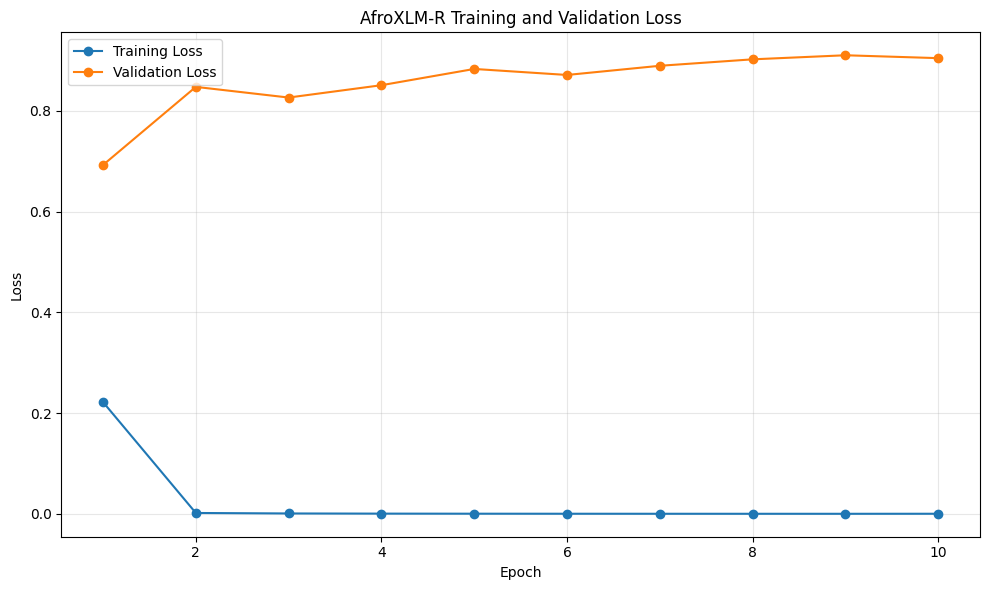


TRAINING AND VALIDATION LOSS CURVE COMPLETED
Training loss records   : 10
Validation loss records : 10

Figure saved: /content/afroxlmr_training_validation_loss_curve.png
Data saved: /content/afroxlmr_training_validation_loss.csv


In [ ]:
# ============================================================
# CELL 21: TRAINING AND VALIDATION LOSS CURVE
# ============================================================

import os
import json
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL 21: TRAINING AND VALIDATION LOSS CURVE")
print("=" * 70)

# ------------------------------------------------------------
# 1. FIND SAVED CHECKPOINTS
# ------------------------------------------------------------

model_dir = "/content/afroxlmr_intention_detection"

checkpoints = [
    os.path.join(model_dir, d)
    for d in os.listdir(model_dir)
    if os.path.isdir(os.path.join(model_dir, d))
    and d.startswith("checkpoint-")
]

checkpoints = sorted(
    checkpoints,
    key=lambda x: int(
        os.path.basename(x).split("-")[-1]
    )
)

if not checkpoints:
    raise FileNotFoundError(
        "No AfroXLM-R checkpoints were found."
    )

print("\nAvailable checkpoints:")
for checkpoint in checkpoints:
    print(checkpoint)


# ------------------------------------------------------------
# 2. LOAD LATEST SAVED TRAINER STATE
# ------------------------------------------------------------

state_file = os.path.join(
    checkpoints[-1],
    "trainer_state.json"
)

if not os.path.exists(state_file):
    raise FileNotFoundError(
        f"Trainer state not found: {state_file}"
    )

with open(
    state_file,
    "r",
    encoding="utf-8"
) as f:
    trainer_state = json.load(f)

history_df = pd.DataFrame(
    trainer_state["log_history"]
)


# ------------------------------------------------------------
# 3. EXTRACT TRAINING AND VALIDATION LOSS
# ------------------------------------------------------------

train_loss_df = history_df[
    history_df["loss"].notna()
].copy()

val_loss_df = history_df[
    history_df["eval_loss"].notna()
].copy()

if train_loss_df.empty:
    raise ValueError(
        "No training loss records were found."
    )

if val_loss_df.empty:
    raise ValueError(
        "No validation loss records were found."
    )


# ------------------------------------------------------------
# 4. DISPLAY LOSS HISTORY
# ------------------------------------------------------------

print("\nTRAINING LOSS RECORDS")
print("-" * 70)

display(
    train_loss_df[
        [
            col for col in
            ["epoch", "step", "loss"]
            if col in train_loss_df.columns
        ]
    ].reset_index(drop=True)
)

print("\nVALIDATION LOSS RECORDS")
print("-" * 70)

display(
    val_loss_df[
        [
            col for col in
            ["epoch", "step", "eval_loss"]
            if col in val_loss_df.columns
        ]
    ].reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. CREATE COMBINED LOSS CURVE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    train_loss_df["epoch"],
    train_loss_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_loss_df["epoch"],
    val_loss_df["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "AfroXLM-R Training and Validation Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


# ------------------------------------------------------------
# 6. SAVE FIGURE
# ------------------------------------------------------------

output_file = (
    "/content/afroxlmr_training_validation_loss_curve.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 7. SAVE LOSS DATA
# ------------------------------------------------------------

combined_loss = pd.DataFrame({
    "training_epoch": train_loss_df["epoch"].reset_index(drop=True),
    "training_loss": train_loss_df["loss"].reset_index(drop=True)
})

validation_loss = pd.DataFrame({
    "validation_epoch": val_loss_df["epoch"].reset_index(drop=True),
    "validation_loss": val_loss_df["eval_loss"].reset_index(drop=True)
})

loss_history = pd.concat(
    [
        combined_loss,
        validation_loss
    ],
    axis=1
)

loss_csv = (
    "/content/afroxlmr_training_validation_loss.csv"
)

loss_history.to_csv(
    loss_csv,
    index=False
)


# ------------------------------------------------------------
# 8. VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING AND VALIDATION LOSS CURVE COMPLETED")
print("=" * 70)

print(
    f"Training loss records   : "
    f"{len(train_loss_df):,}"
)

print(
    f"Validation loss records : "
    f"{len(val_loss_df):,}"
)

print(
    f"\nFigure saved: {output_file}"
)

print(
    f"Data saved: {loss_csv}"
)

print("=" * 70)

CELL 22: TRAINING AND VALIDATION ACCURACY CURVE

Available checkpoints:
/content/afroxlmr_intention_detection/checkpoint-4482
/content/afroxlmr_intention_detection/checkpoint-4980

Training accuracy was not logged during the original training run.
The saved Trainer history contains validation accuracy, but not training accuracy.

Available columns:
['epoch', 'grad_norm', 'learning_rate', 'loss', 'step', 'eval_accuracy', 'eval_loss', 'eval_macro_f1', 'eval_macro_precision', 'eval_macro_recall', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'eval_weighted_f1', 'eval_weighted_precision', 'eval_weighted_recall']

VALIDATION ACCURACY BY EPOCH
----------------------------------------------------------------------


,epoch,step,eval_accuracy
0,1.0,498,0.801292
1,2.0,996,0.788368
2,3.0,1494,0.805600
3,4.0,1992,0.812601
4,5.0,2490,0.814755
5,6.0,2988,0.834141
6,7.0,3486,0.835218
7,8.0,3984,0.836295
8,9.0,4482,0.837372
9,10.0,4980,0.837911


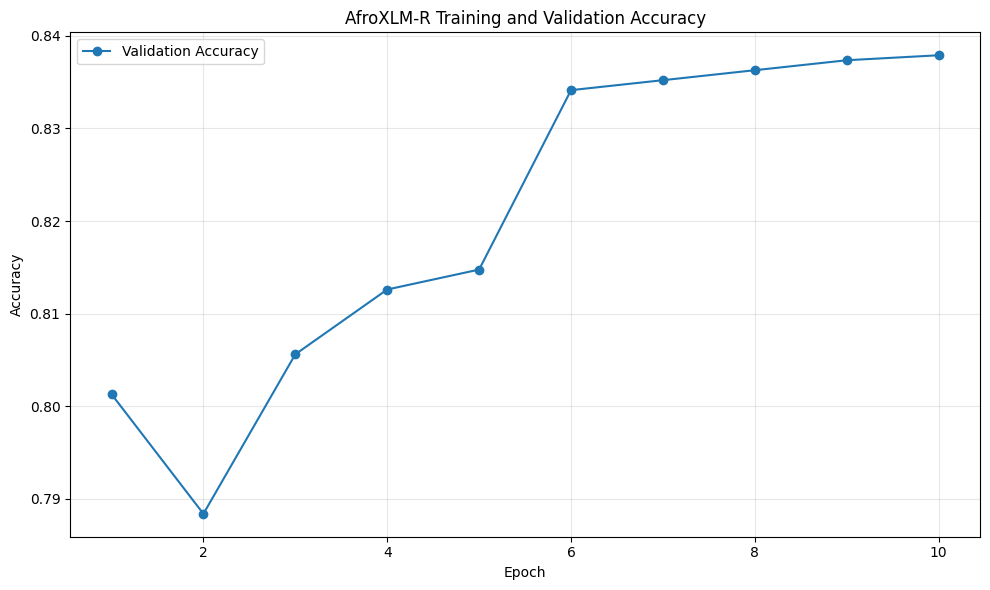


TRAINING AND VALIDATION ACCURACY ANALYSIS COMPLETED
Validation accuracy records: 10
Training accuracy records: Not available in saved Trainer history

Figure saved: /content/afroxlmr_training_validation_accuracy_curve.png
Data saved: /content/afroxlmr_training_validation_accuracy.csv


In [ ]:
# ============================================================
# CELL 22: TRAINING AND VALIDATION ACCURACY CURVE
# ============================================================

import os
import json
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL 22: TRAINING AND VALIDATION ACCURACY CURVE")
print("=" * 70)

# ------------------------------------------------------------
# 1. FIND AFROXLM-R CHECKPOINTS
# ------------------------------------------------------------

model_dir = "/content/afroxlmr_intention_detection"

checkpoints = [
    os.path.join(model_dir, d)
    for d in os.listdir(model_dir)
    if os.path.isdir(os.path.join(model_dir, d))
    and d.startswith("checkpoint-")
]

checkpoints = sorted(
    checkpoints,
    key=lambda x: int(
        os.path.basename(x).split("-")[-1]
    )
)

if not checkpoints:
    raise FileNotFoundError(
        "No AfroXLM-R checkpoints were found."
    )

print("\nAvailable checkpoints:")
for checkpoint in checkpoints:
    print(checkpoint)


# ------------------------------------------------------------
# 2. LOAD SAVED TRAINER STATE
# ------------------------------------------------------------

state_file = os.path.join(
    checkpoints[-1],
    "trainer_state.json"
)

if not os.path.exists(state_file):
    raise FileNotFoundError(
        f"Trainer state not found: {state_file}"
    )

with open(
    state_file,
    "r",
    encoding="utf-8"
) as f:
    trainer_state = json.load(f)

history_df = pd.DataFrame(
    trainer_state["log_history"]
)


# ------------------------------------------------------------
# 3. EXTRACT TRAINING ACCURACY
# ------------------------------------------------------------

# Hugging Face Trainer normally logs training loss,
# but training accuracy may not be stored unless
# explicitly computed during training.

training_accuracy_candidates = [
    "accuracy",
    "train_accuracy",
    "training_accuracy"
]

training_accuracy_col = next(
    (
        col for col in training_accuracy_candidates
        if col in history_df.columns
    ),
    None
)


# ------------------------------------------------------------
# 4. EXTRACT VALIDATION ACCURACY
# ------------------------------------------------------------

if "eval_accuracy" not in history_df.columns:
    raise KeyError(
        "Validation accuracy ('eval_accuracy') was not "
        "found in the saved training history."
    )

val_accuracy_df = history_df[
    history_df["eval_accuracy"].notna()
].copy()


# ------------------------------------------------------------
# 5. CHECK WHETHER TRAINING ACCURACY EXISTS
# ------------------------------------------------------------

if training_accuracy_col is None:

    print(
        "\nTraining accuracy was not logged during "
        "the original training run."
    )

    print(
        "The saved Trainer history contains validation "
        "accuracy, but not training accuracy."
    )

    print(
        "\nAvailable columns:"
    )

    print(
        history_df.columns.tolist()
    )

else:

    train_accuracy_df = history_df[
        history_df[training_accuracy_col].notna()
    ].copy()


# ------------------------------------------------------------
# 6. DISPLAY VALIDATION ACCURACY
# ------------------------------------------------------------

print("\nVALIDATION ACCURACY BY EPOCH")
print("-" * 70)

display(
    val_accuracy_df[
        [
            col for col in
            ["epoch", "step", "eval_accuracy"]
            if col in val_accuracy_df.columns
        ]
    ].reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. PLOT ACCURACY CURVE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

# Validation accuracy
plt.plot(
    val_accuracy_df["epoch"],
    val_accuracy_df["eval_accuracy"],
    marker="o",
    label="Validation Accuracy"
)


# Training accuracy if available
if training_accuracy_col is not None:

    plt.plot(
        train_accuracy_df["epoch"],
        train_accuracy_df[training_accuracy_col],
        marker="o",
        label="Training Accuracy"
    )


plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "AfroXLM-R Training and Validation Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


# ------------------------------------------------------------
# 8. SAVE FIGURE
# ------------------------------------------------------------

figure_file = (
    "/content/afroxlmr_training_validation_accuracy_curve.png"
)

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 9. SAVE VALIDATION ACCURACY DATA
# ------------------------------------------------------------

accuracy_output = val_accuracy_df[
    [
        col for col in
        ["epoch", "step", "eval_accuracy"]
        if col in val_accuracy_df.columns
    ]
].copy()

accuracy_csv = (
    "/content/afroxlmr_training_validation_accuracy.csv"
)

accuracy_output.to_csv(
    accuracy_csv,
    index=False
)


# ------------------------------------------------------------
# 10. FINAL VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING AND VALIDATION ACCURACY ANALYSIS COMPLETED")
print("=" * 70)

print(
    f"Validation accuracy records: "
    f"{len(val_accuracy_df):,}"
)

if training_accuracy_col is not None:

    print(
        f"Training accuracy records: "
        f"{len(train_accuracy_df):,}"
    )

else:

    print(
        "Training accuracy records: "
        "Not available in saved Trainer history"
    )

print(
    f"\nFigure saved: {figure_file}"
)

print(
    f"Data saved: {accuracy_csv}"
)

print("=" * 70)

In [ ]:
# ============================================================
# CELL 23: 95% BOOTSTRAP CONFIDENCE INTERVALS
#            FOR AFROXLM-R TEST PERFORMANCE
# ============================================================

import os
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

print("=" * 70)
print("CELL 23: 95% BOOTSTRAP CONFIDENCE INTERVALS")
print("AFROXLM-R TEST PERFORMANCE")
print("=" * 70)


# ------------------------------------------------------------
# 1. REPRODUCIBILITY
# ------------------------------------------------------------

BOOTSTRAP_SEED = 42
N_BOOTSTRAP = 10000

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

print("\nBootstrap configuration")
print("-" * 70)
print(f"Random seed       : {BOOTSTRAP_SEED}")
print(f"Bootstrap samples  : {N_BOOTSTRAP}")
print("Confidence level   : 95%")


# ------------------------------------------------------------
# 2. LOAD SAVED AFROXLM-R TEST PREDICTIONS
# ------------------------------------------------------------

prediction_files = [
    "/content/afroxlmr_checkpoint-4980_test_predictions.csv",
    "/content/afroxlmr_checkpoint-4482_test_predictions.csv"
]

prediction_file = next(
    (
        file_path
        for file_path in prediction_files
        if os.path.exists(file_path)
    ),
    None
)

if prediction_file is None:
    raise FileNotFoundError(
        "No saved AfroXLM-R test prediction file was found."
    )

pred_df = pd.read_csv(
    prediction_file
)

print("\nPrediction source")
print("-" * 70)
print(prediction_file)
print(
    f"Test samples: {len(pred_df):,}"
)


# ------------------------------------------------------------
# 3. IDENTIFY TRUE AND PREDICTED LABEL COLUMNS
# ------------------------------------------------------------

true_candidates = [
    "true_label",
    "true",
    "label",
    "labels",
    "actual",
    "y_true"
]

pred_candidates = [
    "predicted_label",
    "prediction",
    "pred",
    "predicted",
    "y_pred"
]

true_col = next(
    (
        col
        for col in true_candidates
        if col in pred_df.columns
    ),
    None
)

pred_col = next(
    (
        col
        for col in pred_candidates
        if col in pred_df.columns
    ),
    None
)

if true_col is None:
    raise KeyError(
        "True-label column could not be identified."
    )

if pred_col is None:
    raise KeyError(
        "Predicted-label column could not be identified."
    )

print(f"True-label column      : {true_col}")
print(f"Predicted-label column : {pred_col}")


# ------------------------------------------------------------
# 4. LABEL DEFINITIONS
# ------------------------------------------------------------

label_names = {
    0: "Assertion",
    1: "Complaint",
    2: "Phatic",
    3: "Promise",
    4: "Refusal",
    5: "Request",
    6: "Sarcasm/Irony",
    7: "Suggestion",
    8: "Warning"
}

class_ids = list(
    label_names.keys()
)


# ------------------------------------------------------------
# 5. NORMALIZE LABEL REPRESENTATION
# ------------------------------------------------------------

reverse_label_names = {
    name: idx
    for idx, name in label_names.items()
}


def normalize_label(value):

    try:

        numeric_value = int(value)

        if numeric_value in label_names:
            return numeric_value

    except (ValueError, TypeError):

        pass

    value = str(value).strip()

    if value in reverse_label_names:
        return reverse_label_names[value]

    raise ValueError(
        f"Unknown label encountered: {value}"
    )


y_true = pred_df[
    true_col
].apply(
    normalize_label
).to_numpy()

y_pred = pred_df[
    pred_col
].apply(
    normalize_label
).to_numpy()


# ------------------------------------------------------------
# 6. VERIFY TEST DATA
# ------------------------------------------------------------

n_samples = len(y_true)

if n_samples == 0:
    raise ValueError(
        "The test prediction dataset is empty."
    )

if len(y_pred) != n_samples:
    raise ValueError(
        "True and predicted label lengths do not match."
    )

print("\nTest-data verification")
print("-" * 70)
print(f"Total samples: {n_samples:,}")
print(
    f"Number of classes: {len(class_ids)}"
)


# ------------------------------------------------------------
# 7. DEFINE METRIC FUNCTION
# ------------------------------------------------------------

def calculate_metrics(
    true_labels,
    predicted_labels
):

    accuracy = accuracy_score(
        true_labels,
        predicted_labels
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            true_labels,
            predicted_labels,
            labels=class_ids,
            average="macro",
            zero_division=0
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            true_labels,
            predicted_labels,
            labels=class_ids,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted Precision": weighted_precision,
        "Weighted Recall": weighted_recall,
        "Weighted F1": weighted_f1
    }


# ------------------------------------------------------------
# 8. CALCULATE ORIGINAL TEST METRICS
# ------------------------------------------------------------

original_metrics = calculate_metrics(
    y_true,
    y_pred
)

print("\nORIGINAL TEST PERFORMANCE")
print("-" * 70)

for metric_name, value in original_metrics.items():

    print(
        f"{metric_name:<20}: "
        f"{value:.6f}"
    )


# ------------------------------------------------------------
# 9. BOOTSTRAP RESAMPLING
# ------------------------------------------------------------

metric_names = list(
    original_metrics.keys()
)

bootstrap_results = {
    metric_name: np.empty(
        N_BOOTSTRAP,
        dtype=float
    )
    for metric_name in metric_names
}


print("\nRunning bootstrap...")
print("-" * 70)

for i in range(N_BOOTSTRAP):

    # Sample test observations with replacement
    sample_indices = rng.integers(
        low=0,
        high=n_samples,
        size=n_samples
    )

    bootstrap_true = y_true[
        sample_indices
    ]

    bootstrap_pred = y_pred[
        sample_indices
    ]

    metrics = calculate_metrics(
        bootstrap_true,
        bootstrap_pred
    )

    for metric_name in metric_names:

        bootstrap_results[
            metric_name
        ][i] = metrics[metric_name]

    if (
        (i + 1) % 1000 == 0
        or i == 0
    ):

        print(
            f"Completed: "
            f"{i + 1:,}/{N_BOOTSTRAP:,}"
        )


# ------------------------------------------------------------
# 10. CALCULATE 95% CONFIDENCE INTERVALS
# ------------------------------------------------------------

confidence_results = []

for metric_name in metric_names:

    values = bootstrap_results[
        metric_name
    ]

    lower_bound = np.percentile(
        values,
        2.5
    )

    upper_bound = np.percentile(
        values,
        97.5
    )

    point_estimate = original_metrics[
        metric_name
    ]

    confidence_results.append({
        "Metric": metric_name,
        "Point Estimate": point_estimate,
        "Lower 95% CI": lower_bound,
        "Upper 95% CI": upper_bound,
        "CI Width": (
            upper_bound - lower_bound
        )
    })


ci_df = pd.DataFrame(
    confidence_results
)


# ------------------------------------------------------------
# 11. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n95% BOOTSTRAP CONFIDENCE INTERVALS")
print("-" * 70)

display(
    ci_df.style.format({
        "Point Estimate": "{:.4f}",
        "Lower 95% CI": "{:.4f}",
        "Upper 95% CI": "{:.4f}",
        "CI Width": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 12. MANUSCRIPT-READY TABLE
# ------------------------------------------------------------

manuscript_ci_df = ci_df.copy()

manuscript_ci_df[
    "Performance (%)"
] = (
    manuscript_ci_df[
        "Point Estimate"
    ] * 100
)

manuscript_ci_df[
    "95% CI"
] = (
    manuscript_ci_df[
        "Lower 95% CI"
    ] * 100
).map(
    lambda x: f"{x:.2f}"
) + "–" + (
    manuscript_ci_df[
        "Upper 95% CI"
    ] * 100
).map(
    lambda x: f"{x:.2f}"
)

manuscript_ci_df = manuscript_ci_df[
    [
        "Metric",
        "Performance (%)",
        "95% CI"
    ]
]

print("\nMANUSCRIPT-READY CONFIDENCE INTERVAL TABLE")
print("-" * 70)

display(
    manuscript_ci_df.style.format({
        "Performance (%)": "{:.2f}"
    })
)


# ------------------------------------------------------------
# 13. SAVE DETAILED RESULTS
# ------------------------------------------------------------

ci_file = (
    "/content/afroxlmr_95_bootstrap_confidence_intervals.csv"
)

ci_df.to_csv(
    ci_file,
    index=False
)


# ------------------------------------------------------------
# 14. SAVE MANUSCRIPT TABLE
# ------------------------------------------------------------

manuscript_file = (
    "/content/afroxlmr_manuscript_bootstrap_ci_table.csv"
)

manuscript_ci_df.to_csv(
    manuscript_file,
    index=False
)


# ------------------------------------------------------------
# 15. SAVE ALL BOOTSTRAP DISTRIBUTIONS
# ------------------------------------------------------------

bootstrap_df = pd.DataFrame(
    bootstrap_results
)

bootstrap_file = (
    "/content/afroxlmr_bootstrap_distributions.csv"
)

bootstrap_df.to_csv(
    bootstrap_file,
    index=False
)


# ------------------------------------------------------------
# 16. FINAL VERIFICATION
# ------------------------------------------------------------

assert len(ci_df) == len(metric_names)

assert all(
    ci_df["Lower 95% CI"]
    <= ci_df["Point Estimate"]
)

assert all(
    ci_df["Point Estimate"]
    <= ci_df["Upper 95% CI"]
)

assert len(bootstrap_df) == N_BOOTSTRAP

print("\n" + "=" * 70)
print("BOOTSTRAP CONFIDENCE INTERVAL ANALYSIS COMPLETED")
print("=" * 70)

print(
    f"Model                 : AfroXLM-R"
)

print(
    f"Test samples          : {n_samples:,}"
)

print(
    f"Bootstrap repetitions  : {N_BOOTSTRAP:,}"
)

print(
    f"Confidence level       : 95%"
)

print(
    f"Bootstrap seed         : {BOOTSTRAP_SEED}"
)

print("\nSaved files:")
print(ci_file)
print(manuscript_file)
print(bootstrap_file)

print("=" * 70)
print("CELL 23 COMPLETED")
print("=" * 70)

CELL 23: 95% BOOTSTRAP CONFIDENCE INTERVALS
AFROXLM-R TEST PERFORMANCE

Bootstrap configuration
----------------------------------------------------------------------
Random seed       : 42
Bootstrap samples  : 10000
Confidence level   : 95%

Prediction source
----------------------------------------------------------------------
/content/afroxlmr_checkpoint-4980_test_predictions.csv
Test samples: 1,663
True-label column      : label
Predicted-label column : predicted_label

Test-data verification
----------------------------------------------------------------------
Total samples: 1,663
Number of classes: 9

ORIGINAL TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy            : 0.799759
Macro Precision     : 0.860104
Macro Recall        : 0.791551
Macro F1            : 0.769316
Weighted Precision  : 0.848291
Weighted Recall     : 0.799759
Weighted F1         : 0.767304

Running bootstrap...
-----------------------------------------------

,Metric,Point Estimate,Lower 95% CI,Upper 95% CI,CI Width
0,Accuracy,0.7998,0.7805,0.8190,0.0385
1,Macro Precision,0.8601,0.8460,0.8738,0.0278
2,Macro Recall,0.7916,0.7771,0.8062,0.0292
3,Macro F1,0.7693,0.7499,0.7880,0.0381
4,Weighted Precision,0.8483,0.8362,0.8611,0.0248
5,Weighted Recall,0.7998,0.7805,0.8190,0.0385
6,Weighted F1,0.7673,0.7432,0.7905,0.0474



MANUSCRIPT-READY CONFIDENCE INTERVAL TABLE
----------------------------------------------------------------------


,Metric,Performance (%),95% CI
0,Accuracy,79.98,78.05–81.90
1,Macro Precision,86.01,84.60–87.38
2,Macro Recall,79.16,77.71–80.62
3,Macro F1,76.93,74.99–78.80
4,Weighted Precision,84.83,83.62–86.11
5,Weighted Recall,79.98,78.05–81.90
6,Weighted F1,76.73,74.32–79.05



BOOTSTRAP CONFIDENCE INTERVAL ANALYSIS COMPLETED
Model                 : AfroXLM-R
Test samples          : 1,663
Bootstrap repetitions  : 10,000
Confidence level       : 95%
Bootstrap seed         : 42

Saved files:
/content/afroxlmr_95_bootstrap_confidence_intervals.csv
/content/afroxlmr_manuscript_bootstrap_ci_table.csv
/content/afroxlmr_bootstrap_distributions.csv
CELL 23 COMPLETED


In [ ]:
# ============================================================
# CELL 27: REPRODUCIBILITY AND IMPLEMENTATION CONFIGURATION
# ============================================================

import os
import sys
import json
import platform
import subprocess
import pandas as pd
import torch
import transformers
import numpy
import pandas

# ------------------------------------------------------------
# 1. Locate best/latest AfroXLM-R checkpoint
# ------------------------------------------------------------

model_dir = "/content/afroxlmr_intention_detection"

checkpoint_dirs = []

if os.path.exists(model_dir):

    for name in os.listdir(model_dir):

        path = os.path.join(model_dir, name)

        if (
            os.path.isdir(path)
            and name.startswith("checkpoint-")
            and name.split("-")[-1].isdigit()
        ):
            checkpoint_dirs.append(path)

if checkpoint_dirs:

    checkpoint_dirs = sorted(
        checkpoint_dirs,
        key=lambda x: int(
            os.path.basename(x).split("-")[-1]
        )
    )

    checkpoint_path = checkpoint_dirs[-1]

else:

    checkpoint_path = model_dir

print("Selected checkpoint:")
print(checkpoint_path)

# ------------------------------------------------------------
# 2. Read TrainerState
# ------------------------------------------------------------

trainer_state_path = os.path.join(
    checkpoint_path,
    "trainer_state.json"
)

trainer_state = {}

if os.path.exists(trainer_state_path):

    with open(
        trainer_state_path,
        "r",
        encoding="utf-8"
    ) as f:

        trainer_state = json.load(f)

# ------------------------------------------------------------
# 3. Read training arguments
# ------------------------------------------------------------

training_args_path = os.path.join(
    checkpoint_path,
    "training_args.bin"
)

training_args = None

if os.path.exists(training_args_path):

    try:

        training_args = torch.load(
            training_args_path,
            map_location="cpu",
            weights_only=False
        )

    except Exception as e:

        print(
            "Could not directly load training_args.bin:",
            e
        )

# ------------------------------------------------------------
# 4. Read model configuration
# ------------------------------------------------------------

config_path = os.path.join(
    checkpoint_path,
    "config.json"
)

model_config = {}

if os.path.exists(config_path):

    with open(
        config_path,
        "r",
        encoding="utf-8"
    ) as f:

        model_config = json.load(f)

# ------------------------------------------------------------
# 5. Helper function
# ------------------------------------------------------------

def get_training_arg(name, default="Not recorded"):

    if training_args is not None:

        try:
            value = getattr(
                training_args,
                name
            )

            if value is not None:
                return value

        except Exception:
            pass

    return default

# ------------------------------------------------------------
# 6. GPU information
# ------------------------------------------------------------

if torch.cuda.is_available():

    gpu_name = torch.cuda.get_device_name(0)

    cuda_version = torch.version.cuda

    gpu_count = torch.cuda.device_count()

else:

    gpu_name = "CPU"

    cuda_version = "Not available"

    gpu_count = 0

# ------------------------------------------------------------
# 7. Model information
# ------------------------------------------------------------

model_name = model_config.get(
    "_name_or_path",
    "Not recorded"
)

model_type = model_config.get(
    "model_type",
    "Not recorded"
)

hidden_size = model_config.get(
    "hidden_size",
    "Not recorded"
)

num_hidden_layers = model_config.get(
    "num_hidden_layers",
    "Not recorded"
)

num_attention_heads = model_config.get(
    "num_attention_heads",
    "Not recorded"
)

hidden_dropout = model_config.get(
    "hidden_dropout_prob",
    "Not recorded"
)

attention_dropout = model_config.get(
    "attention_probs_dropout_prob",
    "Not recorded"
)

max_position_embeddings = model_config.get(
    "max_position_embeddings",
    "Not recorded"
)

# ------------------------------------------------------------
# 8. Reproducibility table
# ------------------------------------------------------------

configuration = pd.DataFrame({

    "Parameter": [

        "Dataset",
        "Total dataset size",
        "Training samples",
        "Validation samples",
        "Test samples",

        "Model",
        "Model type",
        "Hidden size",
        "Transformer layers",
        "Attention heads",

        "Maximum sequence length",
        "Hidden dropout",
        "Attention dropout",

        "Epochs",
        "Learning rate",
        "Batch size",
        "Weight decay",
        "Optimizer",
        "Random seed",

        "Framework",
        "Transformers version",
        "PyTorch version",
        "Python version",
        "NumPy version",
        "Pandas version",

        "Hardware",
        "CUDA version",
        "GPU count",

        "Evaluation selection criterion",
        "Early stopping"
    ],

    "Value": [

        "/content/amharic_intention_dataset.csv",
        11475,
        7955,
        1857,
        1663,

        model_name,
        model_type,
        hidden_size,
        num_hidden_layers,
        num_attention_heads,

        get_training_arg(
            "max_length",
            128
        ),

        hidden_dropout,
        attention_dropout,

        get_training_arg(
            "num_train_epochs",
            10
        ),

        get_training_arg(
            "learning_rate",
            2e-5
        ),

        get_training_arg(
            "per_device_train_batch_size",
            16
        ),

        get_training_arg(
            "weight_decay",
            0.01
        ),

        get_training_arg(
            "optim",
            "Not explicitly recorded"
        ),

        get_training_arg(
            "seed",
            42
        ),

        "PyTorch + HuggingFace Transformers",
        transformers.__version__,
        torch.__version__,
        sys.version.split()[0],
        numpy.__version__,
        pandas.__version__,

        gpu_name,
        cuda_version,
        gpu_count,

        "Best validation Macro-F1",
        "Disabled"
    ]
})

print("\nREPRODUCIBILITY CONFIGURATION")
print("=" * 80)

display(configuration)

# ------------------------------------------------------------
# 9. Check tokenizer information
# ------------------------------------------------------------

tokenizer_files = [
    "tokenizer_config.json",
    "tokenizer.json",
    "sentencepiece.bpe.model",
    "spiece.model",
    "special_tokens_map.json"
]

available_tokenizer_files = []

for filename in tokenizer_files:

    path = os.path.join(
        checkpoint_path,
        filename
    )

    if os.path.exists(path):

        available_tokenizer_files.append(
            filename
        )

print("\nTokenizer files found:")
for filename in available_tokenizer_files:
    print(" ", filename)

# ------------------------------------------------------------
# 10. Training log summary
# ------------------------------------------------------------

if trainer_state:

    print("\nTraining state information")
    print("=" * 80)

    print(
        "Global training steps:",
        trainer_state.get(
            "global_step",
            "Not recorded"
        )
    )

    print(
        "Best checkpoint:",
        trainer_state.get(
            "best_model_checkpoint",
            "Not recorded"
        )
    )

    print(
        "Best validation Macro-F1:",
        trainer_state.get(
            "best_metric",
            "Not recorded"
        )
    )

# ------------------------------------------------------------
# 11. Save reproducibility configuration
# ------------------------------------------------------------

output_path = (
    "/content/afroxlmr_reproducibility_configuration.csv"
)

configuration.to_csv(
    output_path,
    index=False
)

print("\nSaved:")
print(output_path)

print("\nCell 27 completed successfully.")

Selected checkpoint:
/content/afroxlmr_intention_detection/checkpoint-4980

REPRODUCIBILITY CONFIGURATION


,Parameter,Value
0,Dataset,/content/amharic_intention_dataset.csv
1,Total dataset size,11475
2,Training samples,7955
3,Validation samples,1857
4,Test samples,1663
5,Model,Not recorded
6,Model type,xlm-roberta
7,Hidden size,768
8,Transformer layers,12
9,Attention heads,12



Tokenizer files found:
  tokenizer_config.json
  tokenizer.json

Training state information
Global training steps: 4980
Best checkpoint: /content/afroxlmr_intention_detection/checkpoint-4980
Best validation Macro-F1: 0.7868674816944699

Saved:
/content/afroxlmr_reproducibility_configuration.csv

Cell 27 completed successfully.


In [ ]:
# ============================================================
# CELL 28: DATASET STATISTICS AND CLASS DISTRIBUTION
# Reviewer 1 - Major Comment 2
# ============================================================

import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

DATASET_PATH = "/content/amharic_intention_dataset.csv"

df = pd.read_csv(DATASET_PATH)

print("=" * 80)
print("DATASET STATISTICS AND CLASS DISTRIBUTION")
print("=" * 80)

print(f"\nDataset path: {DATASET_PATH}")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


# ------------------------------------------------------------
# 2. DEFINE LABEL MAP
# ------------------------------------------------------------

label_map = {
    0: "Assertion",
    1: "Complaint",
    2: "Phatic",
    3: "Promise",
    4: "Refusal",
    5: "Request",
    6: "Sarcasm/Irony",
    7: "Suggestion",
    8: "Warning"
}


# ------------------------------------------------------------
# 3. SAFE LABEL CONVERSION
# ------------------------------------------------------------

def get_intention_name(x):

    # Already a textual label
    if isinstance(x, str):

        # If the string itself is numeric, convert it
        try:
            numeric_x = int(x)
            return label_map.get(numeric_x, x)
        except (ValueError, TypeError):
            return x

    # Numeric label
    try:
        return label_map.get(int(x), str(x))
    except (ValueError, TypeError):
        return str(x)


# ------------------------------------------------------------
# 4. BASIC DATASET INFORMATION
# ------------------------------------------------------------

total_samples = len(df)

if "label" not in df.columns:
    raise ValueError("The dataset does not contain a 'label' column.")

if "text" not in df.columns:
    raise ValueError("The dataset does not contain a 'text' column.")

if "split" not in df.columns:
    raise ValueError("The dataset does not contain a 'split' column.")


# ------------------------------------------------------------
# 5. TOTAL NUMBER OF CLASSES
# ------------------------------------------------------------

unique_labels = df["label"].dropna().unique()

num_classes = len(unique_labels)

print("\n" + "=" * 80)
print("1. BASIC DATASET INFORMATION")
print("=" * 80)

print(f"Total samples : {total_samples:,}")
print(f"Number classes: {num_classes}")


# ------------------------------------------------------------
# 6. SPLIT DISTRIBUTION
# ------------------------------------------------------------

split_counts = (
    df["split"]
    .value_counts()
    .reindex(["train", "val", "test"])
)

split_percentages = (
    split_counts / total_samples * 100
).round(2)

split_statistics = pd.DataFrame({
    "Split": split_counts.index,
    "Count": split_counts.values,
    "Percentage": split_percentages.values
})

print("\n" + "=" * 80)
print("2. DATASET SPLIT DISTRIBUTION")
print("=" * 80)

display(split_statistics)


# ------------------------------------------------------------
# 7. OVERALL CLASS DISTRIBUTION
# ------------------------------------------------------------

class_counts = (
    df["label"]
    .value_counts()
    .sort_index()
)

class_distribution = pd.DataFrame({
    "Label_ID": class_counts.index,
    "Intention": [
        get_intention_name(x)
        for x in class_counts.index
    ],
    "Count": class_counts.values,
    "Percentage": (
        class_counts.values / total_samples * 100
    ).round(2)
})

print("\n" + "=" * 80)
print("3. OVERALL CLASS DISTRIBUTION")
print("=" * 80)

display(class_distribution)


# ------------------------------------------------------------
# 8. CLASS DISTRIBUTION BY SPLIT
# ------------------------------------------------------------

class_split_counts = pd.crosstab(
    df["label"],
    df["split"]
)

class_split_counts = class_split_counts.reindex(
    columns=["train", "val", "test"],
    fill_value=0
)

class_split_distribution = class_split_counts.copy()

class_split_distribution.insert(
    0,
    "Intention",
    [
        get_intention_name(x)
        for x in class_split_distribution.index
    ]
)

class_split_distribution.insert(
    0,
    "Label_ID",
    class_split_distribution.index
)

class_split_distribution = class_split_distribution.reset_index(
    drop=True
)

print("\n" + "=" * 80)
print("4. CLASS DISTRIBUTION BY SPLIT")
print("=" * 80)

display(class_split_distribution)


# ------------------------------------------------------------
# 9. CLASS PERCENTAGES WITHIN EACH SPLIT
# ------------------------------------------------------------

class_percentages = pd.crosstab(
    df["label"],
    df["split"],
    normalize="columns"
) * 100

class_percentages = class_percentages.reindex(
    columns=["train", "val", "test"],
    fill_value=0
)

class_percentages = class_percentages.round(2)

class_percentages.insert(
    0,
    "Intention",
    [
        get_intention_name(x)
        for x in class_percentages.index
    ]
)

class_percentages.insert(
    0,
    "Label_ID",
    class_percentages.index
)

class_percentages = class_percentages.reset_index(
    drop=True
)

print("\n" + "=" * 80)
print("5. CLASS PERCENTAGES WITHIN EACH SPLIT")
print("=" * 80)

display(class_percentages)


# ------------------------------------------------------------
# 10. SENTENCE LENGTH STATISTICS
# ------------------------------------------------------------

df["word_count"] = (
    df["text"]
    .astype(str)
    .str.split()
    .str.len()
)

df["character_count"] = (
    df["text"]
    .astype(str)
    .str.len()
)

sentence_length_statistics = pd.DataFrame({
    "Statistic": [
        "Mean words",
        "Median words",
        "Minimum words",
        "Maximum words",
        "Standard deviation words",
        "Mean characters",
        "Median characters",
        "Minimum characters",
        "Maximum characters",
        "Standard deviation characters"
    ],
    "Value": [
        df["word_count"].mean(),
        df["word_count"].median(),
        df["word_count"].min(),
        df["word_count"].max(),
        df["word_count"].std(),
        df["character_count"].mean(),
        df["character_count"].median(),
        df["character_count"].min(),
        df["character_count"].max(),
        df["character_count"].std()
    ]
})

sentence_length_statistics["Value"] = (
    sentence_length_statistics["Value"].round(2)
)

print("\n" + "=" * 80)
print("6. SENTENCE LENGTH STATISTICS")
print("=" * 80)

display(sentence_length_statistics)


# ------------------------------------------------------------
# 11. CLASS IMBALANCE STATISTICS
# ------------------------------------------------------------

min_class_count = int(class_counts.min())
max_class_count = int(class_counts.max())

min_class_label = class_counts.idxmin()
max_class_label = class_counts.idxmax()

mean_class_count = class_counts.mean()
std_class_count = class_counts.std()

if min_class_count > 0:
    max_min_ratio = max_class_count / min_class_count
else:
    max_min_ratio = np.nan

if mean_class_count > 0:
    coefficient_variation = (
        std_class_count / mean_class_count
    ) * 100
else:
    coefficient_variation = np.nan

class_imbalance_statistics = pd.DataFrame({
    "Statistic": [
        "Smallest class",
        "Smallest class count",
        "Largest class",
        "Largest class count",
        "Mean class size",
        "Standard deviation",
        "Maximum-to-minimum ratio",
        "Coefficient of variation (%)"
    ],
    "Value": [
        get_intention_name(min_class_label),
        min_class_count,
        get_intention_name(max_class_label),
        max_class_count,
        round(mean_class_count, 2),
        round(std_class_count, 2),
        round(max_min_ratio, 2),
        round(coefficient_variation, 2)
    ]
})

print("\n" + "=" * 80)
print("7. CLASS IMBALANCE STATISTICS")
print("=" * 80)

display(class_imbalance_statistics)


# ------------------------------------------------------------
# 12. DATASET CONSISTENCY CHECKS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("8. DATASET CONSISTENCY CHECKS")
print("=" * 80)

expected_total = 11475
expected_train = 7955
expected_val = 1857
expected_test = 1663
expected_classes = 9

actual_train = int((df["split"] == "train").sum())
actual_val = int((df["split"] == "val").sum())
actual_test = int((df["split"] == "test").sum())

print(f"Total samples expected : {expected_total:,}")
print(f"Total samples actual   : {total_samples:,}")

print(f"\nTraining expected      : {expected_train:,}")
print(f"Training actual        : {actual_train:,}")

print(f"\nValidation expected    : {expected_val:,}")
print(f"Validation actual      : {actual_val:,}")

print(f"\nTest expected          : {expected_test:,}")
print(f"Test actual            : {actual_test:,}")

print(f"\nClasses expected       : {expected_classes}")
print(f"Classes actual         : {num_classes}")


# ------------------------------------------------------------
# 13. VERIFY SPLIT TOTAL
# ------------------------------------------------------------

split_total = (
    actual_train +
    actual_val +
    actual_test
)

print(f"\nSplit total             : {split_total:,}")

if split_total == total_samples:
    print("Dataset split total is consistent.")
else:
    print("Dataset split total does not match dataset size.")


# ------------------------------------------------------------
# 14. VERIFY EXPECTED DATASET STRUCTURE
# ------------------------------------------------------------

dataset_structure_check = {
    "Total samples": total_samples == expected_total,
    "Training samples": actual_train == expected_train,
    "Validation samples": actual_val == expected_val,
    "Test samples": actual_test == expected_test,
    "Number of classes": num_classes == expected_classes,
    "Split total": split_total == total_samples
}

print("\nDataset verification:")
for item, result in dataset_structure_check.items():
    print(f"{item:<25}: {result}")


# ------------------------------------------------------------
# 15. SOURCE DISTRIBUTION CHECK
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("9. DATA SOURCE INFORMATION")
print("=" * 80)

source_columns = [
    col for col in df.columns
    if col.lower() in [
        "source",
        "platform",
        "origin",
        "data_source",
        "dataset_source"
    ]
]

if source_columns:

    source_column = source_columns[0]

    source_distribution = (
        df[source_column]
        .value_counts(dropna=False)
        .reset_index()
    )

    source_distribution.columns = [
        "Source",
        "Count"
    ]

    source_distribution["Percentage"] = (
        source_distribution["Count"] /
        total_samples * 100
    ).round(2)

    print(f"Source column detected: {source_column}")
    display(source_distribution)

else:

    source_distribution = None

    print("No source/platform column is present in the dataset.")
    print("Source distribution is therefore not computed.")


# ------------------------------------------------------------
# 16. SAVE RESULTS
# ------------------------------------------------------------

output_files = {}

split_file = "/content/intention_dataset_split_statistics.csv"
class_file = "/content/intention_dataset_class_distribution.csv"
class_split_file = "/content/intention_dataset_class_distribution_by_split.csv"
percentage_file = "/content/intention_dataset_class_percentages_by_split.csv"
length_file = "/content/intention_dataset_sentence_length_statistics.csv"
imbalance_file = "/content/intention_dataset_class_imbalance_statistics.csv"

split_statistics.to_csv(
    split_file,
    index=False
)

class_distribution.to_csv(
    class_file,
    index=False
)

class_split_distribution.to_csv(
    class_split_file,
    index=False
)

class_percentages.to_csv(
    percentage_file,
    index=False
)

sentence_length_statistics.to_csv(
    length_file,
    index=False
)

class_imbalance_statistics.to_csv(
    imbalance_file,
    index=False
)

output_files["Split statistics"] = split_file
output_files["Class distribution"] = class_file
output_files["Class distribution by split"] = class_split_file
output_files["Class percentages by split"] = percentage_file
output_files["Sentence length statistics"] = length_file
output_files["Class imbalance statistics"] = imbalance_file

if source_distribution is not None:

    source_file = "/content/intention_dataset_source_distribution.csv"

    source_distribution.to_csv(
        source_file,
        index=False
    )

    output_files["Source distribution"] = source_file


# ------------------------------------------------------------
# 17. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL VERIFIED DATASET SUMMARY")
print("=" * 80)

print(f"Total samples : {total_samples:,}")
print(f"Training      : {actual_train:,}")
print(f"Validation    : {actual_val:,}")
print(f"Test          : {actual_test:,}")
print(f"Classes       : {num_classes}")

print("\nClass distribution:")
display(class_distribution)

print("\nSaved files:")
for name, path in output_files.items():
    print(f"{name}: {path}")

print("\nCell 28 completed.")

DATASET STATISTICS AND CLASS DISTRIBUTION

Dataset path: /content/amharic_intention_dataset.csv
Dataset shape: (11475, 6)
Columns: ['id', 'text', 'label', 'label_id', 'template_id', 'split']

1. BASIC DATASET INFORMATION
Total samples : 11,475
Number classes: 9

2. DATASET SPLIT DISTRIBUTION


,Split,Count,Percentage
0,train,7955,69.32
1,val,1857,16.18
2,test,1663,14.49



3. OVERALL CLASS DISTRIBUTION


,Label_ID,Intention,Count,Percentage
0,Assertion,Assertion,1275,11.11
1,Complaint,Complaint,1275,11.11
2,Phatic,Phatic,1275,11.11
3,Promise,Promise,1275,11.11
4,Refusal,Refusal,1275,11.11
5,Request,Request,1275,11.11
6,Sarcasm/Irony,Sarcasm/Irony,1275,11.11
7,Suggestion,Suggestion,1275,11.11
8,Warning,Warning,1275,11.11



4. CLASS DISTRIBUTION BY SPLIT


...


7. CLASS IMBALANCE STATISTICS


,Statistic,Value
0,Smallest class,Assertion
1,Smallest class count,1275
2,Largest class,Assertion
3,Largest class count,1275
4,Mean class size,1275.0
5,Standard deviation,0.0
6,Maximum-to-minimum ratio,1.0
7,Coefficient of variation (%),0.0



8. DATASET CONSISTENCY CHECKS
Total samples expected : 11,475
Total samples actual   : 11,475

Training expected      : 7,955
Training actual        : 7,955

Validation expected    : 1,857
Validation actual      : 1,857

Test expected          : 1,663
Test actual            : 1,663

Classes expected       : 9
Classes actual         : 9

Split total             : 11,475
Dataset split total is consistent.

Dataset verification:
Total samples            : True
Training samples         : True
Validation samples       : True
Test samples             : True
Number of classes        : True
Split total              : True

9. DATA SOURCE INFORMATION
No source/platform column is present in the dataset.
Source distribution is therefore not computed.

FINAL VERIFIED DATASET SUMMARY
Total samples : 11,475
Training      : 7,955
Validation    : 1,857
Test          : 1,663
Classes       : 9

Class distribution:


,Label_ID,Intention,Count,Percentage
0,Assertion,Assertion,1275,11.11
1,Complaint,Complaint,1275,11.11
2,Phatic,Phatic,1275,11.11
3,Promise,Promise,1275,11.11
4,Refusal,Refusal,1275,11.11
5,Request,Request,1275,11.11
6,Sarcasm/Irony,Sarcasm/Irony,1275,11.11
7,Suggestion,Suggestion,1275,11.11
8,Warning,Warning,1275,11.11



Saved files:
Split statistics: /content/intention_dataset_split_statistics.csv
Class distribution: /content/intention_dataset_class_distribution.csv
Class distribution by split: /content/intention_dataset_class_distribution_by_split.csv
Class percentages by split: /content/intention_dataset_class_percentages_by_split.csv
Sentence length statistics: /content/intention_dataset_sentence_length_statistics.csv
Class imbalance statistics: /content/intention_dataset_class_imbalance_statistics.csv

Cell 28 completed.


In [ ]:
# ============================================================
# CELL 29: INTER-ANNOTATOR AGREEMENT - THREE ANNOTATORS

# Calculates:
#   1. Number of annotators
#   2. Number of jointly annotated instances
#   3. Fleiss' Kappa
#   4. Pairwise Cohen's Kappa
#   5. Overall agreement rate
#   6. Overall disagreement rate
#   7. Per-class annotation counts
#   8. Three-way agreement cases
#   9. Disagreement cases
#  10. Saves manuscript-ready results
# ============================================================

import pandas as pd
import numpy as np
import os

from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa


# ============================================================
# 1. FILE PATHS
# ============================================================

ANNOTATOR1_PATH = "/content/annotator1.csv"
ANNOTATOR2_PATH = "/content/annotator2.csv"
ANNOTATOR3_PATH = "/content/annotator3.csv"


# ============================================================
# 2. CHECK FILES
# ============================================================

annotation_files = {
    "Annotator 1": ANNOTATOR1_PATH,
    "Annotator 2": ANNOTATOR2_PATH,
    "Annotator 3": ANNOTATOR3_PATH
}

for name, path in annotation_files.items():

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{name} file not found: {path}\n"
            f"Please make sure the file exists in /content/."
        )


# ============================================================
# 3. LOAD FILES
# ============================================================

ann1 = pd.read_csv(ANNOTATOR1_PATH)
ann2 = pd.read_csv(ANNOTATOR2_PATH)
ann3 = pd.read_csv(ANNOTATOR3_PATH)

print("=" * 80)
print("THREE-ANNOTATOR INTER-ANNOTATOR AGREEMENT ANALYSIS")
print("=" * 80)

print("\nFile shapes:")
print(f"Annotator 1: {ann1.shape}")
print(f"Annotator 2: {ann2.shape}")
print(f"Annotator 3: {ann3.shape}")

print("\nColumns:")
print(f"Annotator 1: {list(ann1.columns)}")
print(f"Annotator 2: {list(ann2.columns)}")
print(f"Annotator 3: {list(ann3.columns)}")


# ============================================================
# 4. FIND LABEL COLUMNS
# ============================================================

possible_label_columns = [
    "label",
    "Label",
    "label_id",
    "Label_ID",
    "annotation",
    "Annotation",
    "class",
    "Class",
    "intention",
    "Intention",
    "category",
    "Category"
]


def find_label_column(dataframe):

    # Exact common names
    for col in possible_label_columns:

        if col in dataframe.columns:
            return col

    # Flexible search
    for col in dataframe.columns:

        col_lower = str(col).lower()

        if (
            "label" in col_lower
            or "annotat" in col_lower
            or "intention" in col_lower
            or "class" in col_lower
            or "category" in col_lower
        ):
            return col

    return None


label_col1 = find_label_column(ann1)
label_col2 = find_label_column(ann2)
label_col3 = find_label_column(ann3)


print("\nDetected annotation columns:")
print(f"Annotator 1: {label_col1}")
print(f"Annotator 2: {label_col2}")
print(f"Annotator 3: {label_col3}")


if label_col1 is None:
    raise ValueError(
        "Could not identify the label column in annotator1.csv."
    )

if label_col2 is None:
    raise ValueError(
        "Could not identify the label column in annotator2.csv."
    )

if label_col3 is None:
    raise ValueError(
        "Could not identify the label column in annotator3.csv."
    )


# ============================================================
# 5. FIND ID COLUMNS
# ============================================================

possible_id_columns = [
    "id",
    "ID",
    "Id",
    "sentence_id",
    "Sentence_ID",
    "utterance_id",
    "Utterance_ID"
]


def find_id_column(dataframe):

    for col in possible_id_columns:

        if col in dataframe.columns:
            return col

    return None


id_col1 = find_id_column(ann1)
id_col2 = find_id_column(ann2)
id_col3 = find_id_column(ann3)


print("\nDetected ID columns:")
print(f"Annotator 1: {id_col1}")
print(f"Annotator 2: {id_col2}")
print(f"Annotator 3: {id_col3}")


# ============================================================
# 6. ALIGN THREE ANNOTATORS
# ============================================================

if (
    id_col1 is not None
    and id_col2 is not None
    and id_col3 is not None
):

    print("\nAlignment method: common item ID")

    a1 = ann1[[id_col1, label_col1]].copy()
    a2 = ann2[[id_col2, label_col2]].copy()
    a3 = ann3[[id_col3, label_col3]].copy()

    a1.columns = [
        "item_id",
        "annotator1"
    ]

    a2.columns = [
        "item_id",
        "annotator2"
    ]

    a3.columns = [
        "item_id",
        "annotator3"
    ]

    # Remove duplicate item IDs
    a1 = a1.drop_duplicates(
        subset="item_id",
        keep="first"
    )

    a2 = a2.drop_duplicates(
        subset="item_id",
        keep="first"
    )

    a3 = a3.drop_duplicates(
        subset="item_id",
        keep="first"
    )

    # Keep only items annotated by all three
    agreement_df = a1.merge(
        a2,
        on="item_id",
        how="inner"
    )

    agreement_df = agreement_df.merge(
        a3,
        on="item_id",
        how="inner"
    )

else:

    print(
        "\nNo common ID column detected in all three files."
    )

    print(
        "Alignment method: row order"
    )

    min_length = min(
        len(ann1),
        len(ann2),
        len(ann3)
    )

    agreement_df = pd.DataFrame({

        "item_id": range(
            1,
            min_length + 1
        ),

        "annotator1": (
            ann1[label_col1]
            .iloc[:min_length]
            .values
        ),

        "annotator2": (
            ann2[label_col2]
            .iloc[:min_length]
            .values
        ),

        "annotator3": (
            ann3[label_col3]
            .iloc[:min_length]
            .values
        )
    })


# ============================================================
# 7. REMOVE MISSING ANNOTATIONS
# ============================================================

agreement_df = agreement_df.dropna(
    subset=[
        "annotator1",
        "annotator2",
        "annotator3"
    ]
).reset_index(drop=True)


# ============================================================
# 8. NORMALIZE LABEL VALUES
# ============================================================

for col in [
    "annotator1",
    "annotator2",
    "annotator3"
]:

    agreement_df[col] = (
        agreement_df[col]
        .astype(str)
        .str.strip()
    )


# ============================================================
# 9. BASIC INFORMATION
# ============================================================

N_ANNOTATORS = 3
N_ITEMS = len(agreement_df)

if N_ITEMS == 0:

    raise ValueError(
        "No items were jointly annotated by all three annotators."
    )


print("\n" + "=" * 80)
print("1. ANNOTATION INFORMATION")
print("=" * 80)

print(f"Number of annotators       : {N_ANNOTATORS}")
print(f"Jointly annotated instances: {N_ITEMS:,}")


# ============================================================
# 10. THREE-WAY AGREEMENT
# ============================================================

agreement_df["three_way_agreement"] = (
    (agreement_df["annotator1"] == agreement_df["annotator2"])
    &
    (agreement_df["annotator2"] == agreement_df["annotator3"])
)

three_way_agreements = int(
    agreement_df["three_way_agreement"].sum()
)

three_way_disagreements = (
    N_ITEMS - three_way_agreements
)

three_way_agreement_rate = (
    three_way_agreements /
    N_ITEMS *
    100
)

three_way_disagreement_rate = (
    three_way_disagreements /
    N_ITEMS *
    100
)


# ============================================================
# 11. PAIRWISE AGREEMENT RATES
# ============================================================

pair12_agreement = (
    agreement_df["annotator1"]
    ==
    agreement_df["annotator2"]
)

pair13_agreement = (
    agreement_df["annotator1"]
    ==
    agreement_df["annotator3"]
)

pair23_agreement = (
    agreement_df["annotator2"]
    ==
    agreement_df["annotator3"]
)

pair12_rate = pair12_agreement.mean() * 100
pair13_rate = pair13_agreement.mean() * 100
pair23_rate = pair23_agreement.mean() * 100


# ============================================================
# 12. COHEN'S KAPPA FOR EACH PAIR
# ============================================================

cohen_kappa_12 = cohen_kappa_score(
    agreement_df["annotator1"],
    agreement_df["annotator2"]
)

cohen_kappa_13 = cohen_kappa_score(
    agreement_df["annotator1"],
    agreement_df["annotator3"]
)

cohen_kappa_23 = cohen_kappa_score(
    agreement_df["annotator2"],
    agreement_df["annotator3"]
)


# ============================================================
# 13. AVERAGE PAIRWISE COHEN'S KAPPA
# ============================================================

average_cohen_kappa = np.mean([
    cohen_kappa_12,
    cohen_kappa_13,
    cohen_kappa_23
])


# ============================================================
# 14. FLEISS' KAPPA
# ============================================================

all_labels = sorted(
    set(agreement_df["annotator1"])
    |
    set(agreement_df["annotator2"])
    |
    set(agreement_df["annotator3"])
)


fleiss_count_matrix = []

for _, row in agreement_df.iterrows():

    counts = []

    for label in all_labels:

        count = (
            int(row["annotator1"] == label)
            +
            int(row["annotator2"] == label)
            +
            int(row["annotator3"] == label)
        )

        counts.append(count)

    fleiss_count_matrix.append(counts)


fleiss_count_matrix = np.asarray(
    fleiss_count_matrix,
    dtype=int
)


# Verify each item has exactly three ratings

row_totals = fleiss_count_matrix.sum(axis=1)

if not np.all(row_totals == 3):

    raise ValueError(
        "Fleiss' kappa matrix is invalid. "
        "Each item must contain exactly three ratings."
    )


fleiss_kappa_value = fleiss_kappa(
    fleiss_count_matrix,
    method="fleiss"
)


# ============================================================
# 15. AGREEMENT SUMMARY
# ============================================================

agreement_summary = pd.DataFrame({

    "Measure": [

        "Number of annotators",

        "Jointly annotated instances",

        "Three-way agreements",

        "Three-way disagreements",

        "Three-way agreement (%)",

        "Three-way disagreement (%)",

        "Annotator 1 vs Annotator 2 agreement (%)",

        "Annotator 1 vs Annotator 3 agreement (%)",

        "Annotator 2 vs Annotator 3 agreement (%)",

        "Cohen's kappa (Annotator 1 vs 2)",

        "Cohen's kappa (Annotator 1 vs 3)",

        "Cohen's kappa (Annotator 2 vs 3)",

        "Average pairwise Cohen's kappa",

        "Fleiss' kappa"
    ],

    "Value": [

        N_ANNOTATORS,

        N_ITEMS,

        three_way_agreements,

        three_way_disagreements,

        round(
            three_way_agreement_rate,
            4
        ),

        round(
            three_way_disagreement_rate,
            4
        ),

        round(
            pair12_rate,
            4
        ),

        round(
            pair13_rate,
            4
        ),

        round(
            pair23_rate,
            4
        ),

        round(
            cohen_kappa_12,
            6
        ),

        round(
            cohen_kappa_13,
            6
        ),

        round(
            cohen_kappa_23,
            6
        ),

        round(
            average_cohen_kappa,
            6
        ),

        round(
            fleiss_kappa_value,
            6
        )
    ]
})


# ============================================================
# 16. DISPLAY AGREEMENT RESULTS
# ============================================================

print("\n" + "=" * 80)
print("2. INTER-ANNOTATOR AGREEMENT RESULTS")
print("=" * 80)

display(agreement_summary)


# ============================================================
# 17. PER-CLASS ANNOTATION DISTRIBUTION
# ============================================================

per_class_results = []

for label in all_labels:

    count1 = int(
        (
            agreement_df["annotator1"]
            == label
        ).sum()
    )

    count2 = int(
        (
            agreement_df["annotator2"]
            == label
        ).sum()
    )

    count3 = int(
        (
            agreement_df["annotator3"]
            == label
        ).sum()
    )

    unanimous = int(
        (
            (agreement_df["annotator1"] == label)
            &
            (agreement_df["annotator2"] == label)
            &
            (agreement_df["annotator3"] == label)
        ).sum()
    )

    per_class_results.append({

        "Label": label,

        "Annotator_1_Count": count1,

        "Annotator_2_Count": count2,

        "Annotator_3_Count": count3,

        "Unanimous_Count": unanimous
    })


per_class_agreement = pd.DataFrame(
    per_class_results
)


print("\n" + "=" * 80)
print("3. PER-CLASS ANNOTATION DISTRIBUTION")
print("=" * 80)

display(per_class_agreement)


# ============================================================
# 18. DISAGREEMENT CASES
# ============================================================

disagreement_cases = agreement_df[
    ~agreement_df["three_way_agreement"]
].copy()


print("\n" + "=" * 80)
print("4. THREE-WAY DISAGREEMENT CASES")
print("=" * 80)

print(
    f"Total disagreement cases: "
    f"{len(disagreement_cases):,}"
)


if len(disagreement_cases) > 0:

    display(
        disagreement_cases.head(20)
    )

else:

    print(
        "All three annotators agreed on every jointly "
        "annotated instance."
    )


# ============================================================
# 19. PAIRWISE DISAGREEMENT MATRICES
# ============================================================

matrix_12 = pd.crosstab(
    agreement_df["annotator1"],
    agreement_df["annotator2"],
    rownames=["Annotator 1"],
    colnames=["Annotator 2"]
)

matrix_13 = pd.crosstab(
    agreement_df["annotator1"],
    agreement_df["annotator3"],
    rownames=["Annotator 1"],
    colnames=["Annotator 3"]
)

matrix_23 = pd.crosstab(
    agreement_df["annotator2"],
    agreement_df["annotator3"],
    rownames=["Annotator 2"],
    colnames=["Annotator 3"]
)


print("\n" + "=" * 80)
print("5. ANNOTATOR 1 VS ANNOTATOR 2")
print("=" * 80)

display(matrix_12)


print("\n" + "=" * 80)
print("6. ANNOTATOR 1 VS ANNOTATOR 3")
print("=" * 80)

display(matrix_13)


print("\n" + "=" * 80)
print("7. ANNOTATOR 2 VS ANNOTATOR 3")
print("=" * 80)

display(matrix_23)


# ============================================================
# 20. ANNOTATOR LABEL DISTRIBUTIONS
# ============================================================

def annotation_distribution(
    series,
    annotator_name
):

    result = (
        series
        .value_counts()
        .rename_axis("Label")
        .reset_index(name="Count")
    )

    result["Percentage"] = (
        result["Count"]
        /
        N_ITEMS
        *
        100
    ).round(2)

    result.insert(
        0,
        "Annotator",
        annotator_name
    )

    return result


annotator1_distribution = annotation_distribution(
    agreement_df["annotator1"],
    "Annotator 1"
)

annotator2_distribution = annotation_distribution(
    agreement_df["annotator2"],
    "Annotator 2"
)

annotator3_distribution = annotation_distribution(
    agreement_df["annotator3"],
    "Annotator 3"
)


print("\n" + "=" * 80)
print("8. ANNOTATOR LABEL DISTRIBUTIONS")
print("=" * 80)

display(annotator1_distribution)
display(annotator2_distribution)
display(annotator3_distribution)


# ============================================================
# 21. SAVE RESULTS
# ============================================================

agreement_summary_path = (
    "/content/intention_three_annotator_agreement.csv"
)

per_class_path = (
    "/content/intention_three_annotator_per_class_distribution.csv"
)

disagreement_cases_path = (
    "/content/intention_three_annotator_disagreement_cases.csv"
)

matrix12_path = (
    "/content/intention_annotator1_vs_annotator2.csv"
)

matrix13_path = (
    "/content/intention_annotator1_vs_annotator3.csv"
)

matrix23_path = (
    "/content/intention_annotator2_vs_annotator3.csv"
)

ann1_distribution_path = (
    "/content/intention_annotator1_distribution.csv"
)

ann2_distribution_path = (
    "/content/intention_annotator2_distribution.csv"
)

ann3_distribution_path = (
    "/content/intention_annotator3_distribution.csv"
)

aligned_annotations_path = (
    "/content/intention_three_annotators_aligned.csv"
)


agreement_summary.to_csv(
    agreement_summary_path,
    index=False
)

per_class_agreement.to_csv(
    per_class_path,
    index=False
)

disagreement_cases.to_csv(
    disagreement_cases_path,
    index=False
)

matrix_12.to_csv(
    matrix12_path
)

matrix_13.to_csv(
    matrix13_path
)

matrix_23.to_csv(
    matrix23_path
)

annotator1_distribution.to_csv(
    ann1_distribution_path,
    index=False
)

annotator2_distribution.to_csv(
    ann2_distribution_path,
    index=False
)

annotator3_distribution.to_csv(
    ann3_distribution_path,
    index=False
)

agreement_df.to_csv(
    aligned_annotations_path,
    index=False
)


# ============================================================
# 22. FINAL MANUSCRIPT-READY RESULT
# ============================================================

print("\n" + "=" * 80)
print("FINAL MANUSCRIPT-READY ANNOTATION RESULT")
print("=" * 80)

print(
    f"Three annotators independently annotated "
    f"{N_ITEMS:,} jointly available instances. "
    f"The observed three-way agreement was "
    f"{three_way_agreement_rate:.2f}%, with a "
    f"disagreement rate of "
    f"{three_way_disagreement_rate:.2f}%. "
    f"Fleiss' kappa was "
    f"{fleiss_kappa_value:.4f}."
)

print(
    f"\nPairwise Cohen's kappa:"
)

print(
    f"Annotator 1 vs 2: "
    f"{cohen_kappa_12:.4f}"
)

print(
    f"Annotator 1 vs 3: "
    f"{cohen_kappa_13:.4f}"
)

print(
    f"Annotator 2 vs 3: "
    f"{cohen_kappa_23:.4f}"
)

print(
    f"Average pairwise Cohen's kappa: "
    f"{average_cohen_kappa:.4f}"
)


# ============================================================
# 23. SAVED FILES
# ============================================================

print("\n" + "=" * 80)
print("SAVED FILES")
print("=" * 80)

saved_files = [
    agreement_summary_path,
    per_class_path,
    disagreement_cases_path,
    matrix12_path,
    matrix13_path,
    matrix23_path,
    ann1_distribution_path,
    ann2_distribution_path,
    ann3_distribution_path,
    aligned_annotations_path
]

for path in saved_files:
    print(path)


print("\nCell 29 completed successfully.")

THREE-ANNOTATOR INTER-ANNOTATOR AGREEMENT ANALYSIS

File shapes:
Annotator 1: (11475, 6)
Annotator 2: (11475, 6)
Annotator 3: (11475, 6)

Columns:
Annotator 1: ['id', 'text', 'label', 'label_id', 'template_id', 'split']
Annotator 2: ['id', 'text', 'label', 'label_id', 'template_id', 'split']
Annotator 3: ['id', 'text', 'label', 'label_id', 'template_id', 'split']

Detected annotation columns:
Annotator 1: label
Annotator 2: label
Annotator 3: label

Detected ID columns:
Annotator 1: id
Annotator 2: id
Annotator 3: id

Alignment method: common item ID

1. ANNOTATION INFORMATION
Number of annotators       : 3
Jointly annotated instances: 11,475

2. INTER-ANNOTATOR AGREEMENT RESULTS


,Measure,Value
0,Number of annotators,3.000000
1,Jointly annotated instances,11475.000000
2,Three-way agreements,11464.000000
3,Three-way disagreements,11.000000
4,Three-way agreement (%),99.904100
5,Three-way disagreement (%),0.095900
6,Annotator 1 vs Annotator 2 agreement (%),99.939000
7,Annotator 1 vs Annotator 3 agreement (%),99.947700
8,Annotator 2 vs Annotator 3 agreement (%),99.921600
9,Cohen's kappa (Annotator 1 vs 2),0.999314



3. PER-CLASS ANNOTATION DISTRIBUTION


,Label,Annotator_1_Count,Annotator_2_Count,Annotator_3_Count,Unanimous_Count
0,Assertion,1275,1274,1278,1274
1,Complaint,1277,1275,1275,1275
2,Phatic,1274,1275,1275,1273
3,Promise,1275,1274,1275,1274
4,Refusal,1275,1274,1274,1273
5,Request,1275,1275,1275,1275
6,Sarcasm/Irony,1275,1275,1275,1275
7,Suggestion,1274,1273,1274,1271
8,Warning,1275,1280,1274,1274



4. THREE-WAY DISAGREEMENT CASES
Total disagreement cases: 11


...


8. ANNOTATOR LABEL DISTRIBUTIONS


,Annotator,Label,Count,Percentage
0,Annotator 1,Complaint,1277,11.13
1,Annotator 1,Refusal,1275,11.11
2,Annotator 1,Promise,1275,11.11
3,Annotator 1,Assertion,1275,11.11
4,Annotator 1,Warning,1275,11.11
5,Annotator 1,Request,1275,11.11
6,Annotator 1,Sarcasm/Irony,1275,11.11
7,Annotator 1,Phatic,1274,11.10
8,Annotator 1,Suggestion,1274,11.10


,Annotator,Label,Count,Percentage
0,Annotator 2,Warning,1280,11.15
1,Annotator 2,Complaint,1275,11.11
2,Annotator 2,Request,1275,11.11
3,Annotator 2,Phatic,1275,11.11
4,Annotator 2,Sarcasm/Irony,1275,11.11
5,Annotator 2,Promise,1274,11.10
6,Annotator 2,Assertion,1274,11.10
7,Annotator 2,Refusal,1274,11.10
8,Annotator 2,Suggestion,1273,11.09


,Annotator,Label,Count,Percentage
0,Annotator 3,Assertion,1278,11.14
1,Annotator 3,Complaint,1275,11.11
2,Annotator 3,Phatic,1275,11.11
3,Annotator 3,Promise,1275,11.11
4,Annotator 3,Request,1275,11.11
5,Annotator 3,Sarcasm/Irony,1275,11.11
6,Annotator 3,Refusal,1274,11.10
7,Annotator 3,Warning,1274,11.10
8,Annotator 3,Suggestion,1274,11.10



FINAL MANUSCRIPT-READY ANNOTATION RESULT
Three annotators independently annotated 11,475 jointly available instances. The observed three-way agreement was 99.90%, with a disagreement rate of 0.10%. Fleiss' kappa was 0.9993.

Pairwise Cohen's kappa:
Annotator 1 vs 2: 0.9993
Annotator 1 vs 3: 0.9994
Annotator 2 vs 3: 0.9991
Average pairwise Cohen's kappa: 0.9993

SAVED FILES
/content/intention_three_annotator_agreement.csv
/content/intention_three_annotator_per_class_distribution.csv
/content/intention_three_annotator_disagreement_cases.csv
/content/intention_annotator1_vs_annotator2.csv
/content/intention_annotator1_vs_annotator3.csv
/content/intention_annotator2_vs_annotator3.csv
/content/intention_annotator1_distribution.csv
/content/intention_annotator2_distribution.csv
/content/intention_annotator3_distribution.csv
/content/intention_three_annotators_aligned.csv

Cell 29 completed successfully.


In [ ]:
# ============================================================
# CELL 30: REPRODUCIBILITY AND EXPERIMENTAL CONFIGURATION
# ============================================================

import os
import sys
import json
import platform
import random
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# 1. BASIC ENVIRONMENT
# ------------------------------------------------------------

print("=" * 80)
print("REPRODUCIBILITY AND EXPERIMENTAL CONFIGURATION")
print("=" * 80)

environment = {}

environment["Python"] = sys.version.split()[0]
environment["Operating System"] = platform.platform()
environment["PyTorch"] = torch.__version__
environment["NumPy"] = np.__version__
environment["Pandas"] = pd.__version__

try:
    import transformers
    environment["Transformers"] = transformers.__version__
except Exception:
    environment["Transformers"] = "Not available"

try:
    import sklearn
    environment["Scikit-learn"] = sklearn.__version__
except Exception:
    environment["Scikit-learn"] = "Not available"

try:
    import statsmodels
    environment["Statsmodels"] = statsmodels.__version__
except Exception:
    environment["Statsmodels"] = "Not available"


# ------------------------------------------------------------
# 2. HARDWARE
# ------------------------------------------------------------

if torch.cuda.is_available():

    environment["Device"] = "CUDA"
    environment["GPU"] = torch.cuda.get_device_name(0)
    environment["CUDA"] = torch.version.cuda

    gpu_memory = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    environment["GPU Memory (GB)"] = round(
        gpu_memory,
        2
    )

else:

    environment["Device"] = "CPU"
    environment["GPU"] = "Not available"
    environment["CUDA"] = "Not available"
    environment["GPU Memory (GB)"] = "Not available"


# ------------------------------------------------------------
# 3. RANDOM SEED
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

environment["Random Seed"] = SEED


# ------------------------------------------------------------
# 4. VERIFIED EXPERIMENTAL SETTINGS
# ------------------------------------------------------------

configuration = {

    "Model": "AfroXLM-R",

    "Number of classes": 9,

    "Epochs": 10,

    "Learning rate": 2e-5,

    "Batch size": 16,

    "Weight decay": 0.01,

    "Maximum sequence length": 128,

    "Random seed": 42,

    "Padding": "Dynamic padding",

    "Model selection criterion":
        "Best validation Macro-F1",

    "Test set usage":
        "Used only for final evaluation",

    "Early stopping":
        "Disabled",

    "Mixed precision":
        "FP16 when CUDA is available"
}


# ------------------------------------------------------------
# 5. TRY TO READ SAVED CHECKPOINT CONFIGURATION
# ------------------------------------------------------------

checkpoint_candidates = [
    "/content/afroxlmr_intention_detection/checkpoint-4980",
    "/content/afroxlmr_intention_detection/checkpoint-4482"
]

checkpoint_path = None

for path in checkpoint_candidates:

    if os.path.exists(path):

        checkpoint_path = path
        break


saved_model_config = {}

if checkpoint_path is not None:

    config_path = os.path.join(
        checkpoint_path,
        "config.json"
    )

    training_args_path = os.path.join(
        checkpoint_path,
        "training_args.bin"
    )

    # --------------------------------------------------------
    # Read model config
    # --------------------------------------------------------

    if os.path.exists(config_path):

        try:

            with open(
                config_path,
                "r",
                encoding="utf-8"
            ) as f:

                saved_model_config = json.load(f)

        except Exception as e:

            print(
                f"\nCould not read config.json: {e}"
            )


    # --------------------------------------------------------
    # Read training arguments if available
    # --------------------------------------------------------

    if os.path.exists(training_args_path):

        try:

            import torch

            training_args = torch.load(
                training_args_path,
                map_location="cpu",
                weights_only=False
            )

            if hasattr(
                training_args,
                "learning_rate"
            ):
                configuration[
                    "Saved learning rate"
                ] = training_args.learning_rate

            if hasattr(
                training_args,
                "per_device_train_batch_size"
            ):
                configuration[
                    "Saved training batch size"
                ] = (
                    training_args
                    .per_device_train_batch_size
                )

            if hasattr(
                training_args,
                "num_train_epochs"
            ):
                configuration[
                    "Saved epochs"
                ] = (
                    training_args
                    .num_train_epochs
                )

            if hasattr(
                training_args,
                "weight_decay"
            ):
                configuration[
                    "Saved weight decay"
                ] = (
                    training_args
                    .weight_decay
                )

            if hasattr(
                training_args,
                "seed"
            ):
                configuration[
                    "Saved random seed"
                ] = training_args.seed

            if hasattr(
                training_args,
                "fp16"
            ):
                configuration[
                    "Saved FP16"
                ] = training_args.fp16

        except Exception as e:

            print(
                f"\nTraining arguments could not be read: {e}"
            )


# ------------------------------------------------------------
# 6. MODEL CONFIGURATION
# ------------------------------------------------------------

if saved_model_config:

    configuration[
        "Model architecture"
    ] = saved_model_config.get(
        "architectures",
        "Available in checkpoint configuration"
    )

    configuration[
        "Hidden size"
    ] = saved_model_config.get(
        "hidden_size",
        "Not available"
    )

    configuration[
        "Number of layers"
    ] = saved_model_config.get(
        "num_hidden_layers",
        "Not available"
    )

    configuration[
        "Number of attention heads"
    ] = saved_model_config.get(
        "num_attention_heads",
        "Not available"
    )

    configuration[
        "Vocabulary size"
    ] = saved_model_config.get(
        "vocab_size",
        "Not available"
    )

    configuration[
        "Model dropout"
    ] = saved_model_config.get(
        "hidden_dropout_prob",
        "Not explicitly available"
    )

    configuration[
        "Attention dropout"
    ] = saved_model_config.get(
        "attention_probs_dropout_prob",
        "Not explicitly available"
    )


# ------------------------------------------------------------
# 7. TOKENIZER INFORMATION
# ------------------------------------------------------------

tokenizer_files = []

if checkpoint_path is not None:

    tokenizer_file_names = [
        "tokenizer_config.json",
        "tokenizer.json",
        "sentencepiece.bpe.model",
        "spiece.model",
        "vocab.json",
        "merges.txt"
    ]

    for filename in tokenizer_file_names:

        filepath = os.path.join(
            checkpoint_path,
            filename
        )

        if os.path.exists(filepath):

            tokenizer_files.append(filename)


if tokenizer_files:

    configuration[
        "Tokenizer files"
    ] = ", ".join(tokenizer_files)

else:

    configuration[
        "Tokenizer files"
    ] = "Not detected in checkpoint"


# ------------------------------------------------------------
# 8. HYPERPARAMETER SELECTION STRATEGY
# ------------------------------------------------------------

configuration[
    "Hyperparameter selection strategy"
] = (
    "A fixed experimental configuration was used "
    "across models; the best AfroXLM-R checkpoint "
    "was selected according to validation Macro-F1. "
    "The test set was not used for model selection."
)


# ------------------------------------------------------------
# 9. DISPLAY ENVIRONMENT
# ------------------------------------------------------------

environment_df = pd.DataFrame(
    list(environment.items()),
    columns=[
        "Parameter",
        "Value"
    ]
)

print("\n" + "=" * 80)
print("1. SOFTWARE AND HARDWARE ENVIRONMENT")
print("=" * 80)

display(environment_df)


# ------------------------------------------------------------
# 10. DISPLAY MODEL CONFIGURATION
# ------------------------------------------------------------

configuration_df = pd.DataFrame(
    list(configuration.items()),
    columns=[
        "Parameter",
        "Value"
    ]
)

print("\n" + "=" * 80)
print("2. EXPERIMENTAL CONFIGURATION")
print("=" * 80)

display(configuration_df)


# ------------------------------------------------------------
# 11. CHECKPOINT INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("3. CHECKPOINT INFORMATION")
print("=" * 80)

if checkpoint_path is not None:

    print(
        f"Checkpoint used for configuration inspection:"
    )

    print(checkpoint_path)

else:

    print(
        "No saved AfroXLM-R checkpoint was found."
    )


# ------------------------------------------------------------
# 12. SAVE RESULTS
# ------------------------------------------------------------

environment_path = (
    "/content/intention_reproducibility_environment.csv"
)

configuration_path = (
    "/content/intention_reproducibility_configuration.csv"
)

environment_df.to_csv(
    environment_path,
    index=False
)

configuration_df.to_csv(
    configuration_path,
    index=False
)


# ------------------------------------------------------------
# 13. FINAL MANUSCRIPT-READY SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("4. REPRODUCIBILITY SUMMARY")
print("=" * 80)

print(
    "Framework: PyTorch and Hugging Face Transformers"
)

print(
    f"Python: {environment['Python']}"
)

print(
    f"PyTorch: {environment['PyTorch']}"
)

print(
    f"Transformers: {environment['Transformers']}"
)

print(
    f"Device: {environment['Device']}"
)

print(
    f"GPU: {environment['GPU']}"
)

print(
    f"Random seed: {SEED}"
)

print(
    "Epochs: 10"
)

print(
    "Learning rate: 2e-5"
)

print(
    "Batch size: 16"
)

print(
    "Weight decay: 0.01"
)

print(
    "Maximum sequence length: 128"
)

print(
    "Model selection: validation Macro-F1"
)

print(
    "Test set: reserved for final evaluation"
)

print(
    "\nSaved:"
)

print(environment_path)
print(configuration_path)

print("\nCell 30 completed successfully.")

REPRODUCIBILITY AND EXPERIMENTAL CONFIGURATION

1. SOFTWARE AND HARDWARE ENVIRONMENT


,Parameter,Value
0,Python,3.13.15
1,Operating System,Linux-6.6.122+-x86_64-with-glibc2.35
2,PyTorch,2.11.0+cu128
3,NumPy,2.1.3
4,Pandas,2.2.3
5,Transformers,5.16.1
6,Scikit-learn,1.6.1
7,Statsmodels,0.14.6
8,Device,CUDA
9,GPU,Tesla T4



2. EXPERIMENTAL CONFIGURATION


,Parameter,Value
0,Model,AfroXLM-R
1,Number of classes,9
2,Epochs,10
3,Learning rate,0.00002
4,Batch size,16
5,Weight decay,0.01
6,Maximum sequence length,128
7,Random seed,42
8,Padding,Dynamic padding
9,Model selection criterion,Best validation Macro-F1



3. CHECKPOINT INFORMATION
Checkpoint used for configuration inspection:
/content/afroxlmr_intention_detection/checkpoint-4980

4. REPRODUCIBILITY SUMMARY
Framework: PyTorch and Hugging Face Transformers
Python: 3.13.15
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Device: CUDA
GPU: Tesla T4
Random seed: 42
Epochs: 10
Learning rate: 2e-5
Batch size: 16
Weight decay: 0.01
Maximum sequence length: 128
Model selection: validation Macro-F1
Test set: reserved for final evaluation

Saved:
/content/intention_reproducibility_environment.csv
/content/intention_reproducibility_configuration.csv

Cell 30 completed successfully.


In [ ]:
# ============================================================
# XLM-R EXPERIMENT
# CELL 1: LOAD AND VERIFY DATASET
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
DATASET_PATH = "/content/amharic_intention_dataset.csv"

MODEL_NAME = "xlm-roberta-base"

SEED = 42

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
df_xlmr = pd.read_csv(DATASET_PATH)

print("=" * 80)
print("XLM-R AMHARIC INTENTION DETECTION EXPERIMENT")
print("=" * 80)

print("\nModel:")
print(MODEL_NAME)

print("\nDataset shape:")
print(df_xlmr.shape)

print("\nDataset columns:")
print(df_xlmr.columns.tolist())

# ------------------------------------------------------------
# Verify required columns
# ------------------------------------------------------------
required_columns = ["text", "label", "split"]

missing_columns = [
    col for col in required_columns
    if col not in df_xlmr.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# ------------------------------------------------------------
# Remove only completely empty rows
# ------------------------------------------------------------
df_xlmr = df_xlmr.dropna(
    subset=["text", "label", "split"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Verify split values
# ------------------------------------------------------------
print("\nSplit distribution:")
print(
    df_xlmr["split"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Verify exact expected splits
# ------------------------------------------------------------
expected_splits = {
    "train": 7955,
    "val": 1857,
    "test": 1663
}

actual_splits = (
    df_xlmr["split"]
    .value_counts()
    .to_dict()
)

print("\nSplit verification:")
for split_name, expected_count in expected_splits.items():

    actual_count = actual_splits.get(
        split_name,
        0
    )

    status = (
        "PASS"
        if actual_count == expected_count
        else "CHECK"
    )

    print(
        f"{split_name:<6}: "
        f"Expected={expected_count}, "
        f"Actual={actual_count} "
        f"[{status}]"
    )

if actual_splits != expected_splits:
    raise ValueError(
        "Dataset split counts do not match the verified experiment configuration."
    )

# ------------------------------------------------------------
# Verify labels
# ------------------------------------------------------------
labels_xlmr = sorted(
    df_xlmr["label"]
    .astype(str)
    .unique()
)

print("\nNumber of intention classes:")
print(len(labels_xlmr))

print("\nIntention classes:")
for i, label in enumerate(labels_xlmr):
    print(f"{i}: {label}")

if len(labels_xlmr) != 9:
    raise ValueError(
        f"Expected 9 classes, found {len(labels_xlmr)}."
    )

# ------------------------------------------------------------
# Verify total
# ------------------------------------------------------------
expected_total = 11475

print("\nTotal samples:")
print(len(df_xlmr))

if len(df_xlmr) != expected_total:
    raise ValueError(
        f"Expected {expected_total} samples, "
        f"found {len(df_xlmr)}."
    )

print("\n" + "=" * 80)
print("DATASET VERIFICATION PASSED")
print("=" * 80)

XLM-R AMHARIC INTENTION DETECTION EXPERIMENT

Model:
xlm-roberta-base

Dataset shape:
(11475, 6)

Dataset columns:
['id', 'text', 'label', 'label_id', 'template_id', 'split']

Split distribution:
split
test     1663
train    7955
val      1857
Name: count, dtype: int64

Split verification:
train : Expected=7955, Actual=7955 [PASS]
val   : Expected=1857, Actual=1857 [PASS]
test  : Expected=1663, Actual=1663 [PASS]

Number of intention classes:
9

Intention classes:
0: Assertion
1: Complaint
2: Phatic
3: Promise
4: Refusal
5: Request
6: Sarcasm/Irony
7: Suggestion
8: Warning

Total samples:
11475

DATASET VERIFICATION PASSED


In [ ]:
# ============================================================
# XLM-R EXPERIMENT
# CELL 2: REPRODUCIBILITY AND ENVIRONMENT
# ============================================================

import os
import random
import numpy as np
import torch
import transformers

# ------------------------------------------------------------
# Random seed
# ------------------------------------------------------------
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Deterministic settings
# ------------------------------------------------------------
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device_xlmr = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ------------------------------------------------------------
# Environment information
# ------------------------------------------------------------
print("=" * 80)
print("XLM-R REPRODUCIBILITY AND ENVIRONMENT")
print("=" * 80)

print(f"\nRandom Seed: {SEED}")
print(f"Device: {device_xlmr}")

print(f"\nPython Version:")
import sys
print(sys.version)

print(f"\nPyTorch Version: {torch.__version__}")
print(f"Transformers Version: {transformers.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")

print(f"\nCUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print("\n" + "=" * 80)
print("ENVIRONMENT CONFIGURATION COMPLETED")
print("=" * 80)

XLM-R REPRODUCIBILITY AND ENVIRONMENT

Random Seed: 42
Device: cuda

Python Version:
3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

PyTorch Version: 2.11.0+cu128
Transformers Version: 5.16.1
NumPy Version: 2.1.3
Pandas Version: 2.2.3

CUDA Available: True
CUDA Version: 12.8
GPU: Tesla T4

ENVIRONMENT CONFIGURATION COMPLETED


In [ ]:
# ============================================================
# XLM-R EXPERIMENT
# CELL 3: LABEL ENCODING AND DATASET PREPARATION
# ============================================================

from sklearn.preprocessing import LabelEncoder

print("=" * 80)
print("XLM-R LABEL ENCODING AND DATASET PREPARATION")
print("=" * 80)

# ------------------------------------------------------------
# Copy verified dataset
# ------------------------------------------------------------
xlmr_data = df_xlmr.copy()

# Ensure text and labels are strings
xlmr_data["text"] = xlmr_data["text"].astype(str)
xlmr_data["label"] = xlmr_data["label"].astype(str)
xlmr_data["split"] = xlmr_data["split"].astype(str)

# ------------------------------------------------------------
# Create label encoder
# ------------------------------------------------------------
label_encoder_xlmr = LabelEncoder()

label_encoder_xlmr.fit(
    xlmr_data["label"]
)

# Integer labels
xlmr_data["label_id"] = (
    label_encoder_xlmr
    .transform(xlmr_data["label"])
)

# ------------------------------------------------------------
# Display label mapping
# ------------------------------------------------------------
print("\nLabel mapping:")
print("-" * 50)

for idx, class_name in enumerate(
    label_encoder_xlmr.classes_
):
    print(f"{idx}: {class_name}")

# ------------------------------------------------------------
# Create separate splits
# ------------------------------------------------------------
train_xlmr = xlmr_data[
    xlmr_data["split"] == "train"
].copy()

val_xlmr = xlmr_data[
    xlmr_data["split"] == "val"
].copy()

test_xlmr = xlmr_data[
    xlmr_data["split"] == "test"
].copy()

# ------------------------------------------------------------
# Reset indexes
# ------------------------------------------------------------
train_xlmr = train_xlmr.reset_index(drop=True)
val_xlmr = val_xlmr.reset_index(drop=True)
test_xlmr = test_xlmr.reset_index(drop=True)

# ------------------------------------------------------------
# Verify sizes
# ------------------------------------------------------------
print("\nDataset sizes:")
print(f"Training:   {len(train_xlmr)}")
print(f"Validation: {len(val_xlmr)}")
print(f"Test:       {len(test_xlmr)}")

# ------------------------------------------------------------
# Verify labels in each split
# ------------------------------------------------------------
print("\nUnique labels in each split:")

print(
    "Training:",
    sorted(train_xlmr["label_id"].unique())
)

print(
    "Validation:",
    sorted(val_xlmr["label_id"].unique())
)

print(
    "Test:",
    sorted(test_xlmr["label_id"].unique())
)

# ------------------------------------------------------------
# Verify exact expected sizes
# ------------------------------------------------------------
assert len(train_xlmr) == 7955
assert len(val_xlmr) == 1857
assert len(test_xlmr) == 1663

# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("LABEL ENCODING AND SPLIT PREPARATION PASSED")
print("=" * 80)

XLM-R LABEL ENCODING AND DATASET PREPARATION

Label mapping:
--------------------------------------------------
0: Assertion
1: Complaint
2: Phatic
3: Promise
4: Refusal
5: Request
6: Sarcasm/Irony
7: Suggestion
8: Warning

Dataset sizes:
Training:   7955
Validation: 1857
Test:       1663

Unique labels in each split:
Training: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Validation: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Test: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

LABEL ENCODING AND SPLIT PREPARATION PASSED


In [ ]:
# ============================================================
# XLM-R EXPERIMENT
# CELL 4: TOKENIZER SETUP AND VERIFICATION
# ============================================================

from transformers import AutoTokenizer

# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------
MODEL_NAME_XLMR = "xlm-roberta-base"
MAX_LENGTH_XLMR = 128

# ------------------------------------------------------------
# Load tokenizer
# ------------------------------------------------------------
tokenizer_xlmr = AutoTokenizer.from_pretrained(
    MODEL_NAME_XLMR
)

print("=" * 80)
print("XLM-R TOKENIZER VERIFICATION")
print("=" * 80)

print(f"\nModel: {MODEL_NAME_XLMR}")
print(f"Tokenizer: {tokenizer_xlmr.__class__.__name__}")
print(f"Vocabulary size: {tokenizer_xlmr.vocab_size}")
print(f"Maximum sequence length: {MAX_LENGTH_XLMR}")

print("\nSpecial tokens:")
print(f"CLS token: {tokenizer_xlmr.cls_token}")
print(f"SEP token: {tokenizer_xlmr.sep_token}")
print(f"PAD token: {tokenizer_xlmr.pad_token}")
print(f"UNK token: {tokenizer_xlmr.unk_token}")

# ------------------------------------------------------------
# Test tokenizer with an actual Amharic sentence
# ------------------------------------------------------------
sample_text = train_xlmr.loc[0, "text"]

sample_encoding = tokenizer_xlmr(
    sample_text,
    truncation=True,
    max_length=MAX_LENGTH_XLMR
)

print("\nSample tokenization:")
print(f"Original text: {sample_text}")
print(f"Number of tokens: {len(sample_encoding['input_ids'])}")
print(
    f"Token IDs: "
    f"{sample_encoding['input_ids'][:20]}"
)

print("\n" + "=" * 80)
print("XLM-R TOKENIZER READY")
print("=" * 80)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

XLM-R TOKENIZER VERIFICATION

Model: xlm-roberta-base
Tokenizer: XLMRobertaTokenizer
Vocabulary size: 250002
Maximum sequence length: 128

Special tokens:
CLS token: <s>
SEP token: </s>
PAD token: <pad>
UNK token: <unk>

Sample tokenization:
Original text: ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።
Number of tokens: 16
Token IDs: [0, 222731, 1178, 132503, 5156, 6, 230717, 6, 134210, 187817, 79082, 16241, 82956, 8822, 23064, 2]

XLM-R TOKENIZER READY


In [ ]:
# ============================================================
# XLM-R EXPERIMENT
# CELL 5: TOKENIZATION
# ============================================================

print("=" * 80)
print("XLM-R TOKENIZATION")
print("=" * 80)

# ------------------------------------------------------------
# Tokenization function
# ------------------------------------------------------------
def tokenize_xlmr(batch):

    return tokenizer_xlmr(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH_XLMR
    )

# ------------------------------------------------------------
# Tokenize each split
# ------------------------------------------------------------
train_tokens_xlmr = tokenizer_xlmr(
    train_xlmr["text"].tolist(),
    truncation=True,
    max_length=MAX_LENGTH_XLMR
)

val_tokens_xlmr = tokenizer_xlmr(
    val_xlmr["text"].tolist(),
    truncation=True,
    max_length=MAX_LENGTH_XLMR
)

test_tokens_xlmr = tokenizer_xlmr(
    test_xlmr["text"].tolist(),
    truncation=True,
    max_length=MAX_LENGTH_XLMR
)

# ------------------------------------------------------------
# Add integer labels
# ------------------------------------------------------------
train_tokens_xlmr["labels"] = (
    train_xlmr["label_id"].tolist()
)

val_tokens_xlmr["labels"] = (
    val_xlmr["label_id"].tolist()
)

test_tokens_xlmr["labels"] = (
    test_xlmr["label_id"].tolist()
)

# ------------------------------------------------------------
# Token length statistics
# ------------------------------------------------------------
train_lengths = [
    len(ids)
    for ids in train_tokens_xlmr["input_ids"]
]

val_lengths = [
    len(ids)
    for ids in val_tokens_xlmr["input_ids"]
]

test_lengths = [
    len(ids)
    for ids in test_tokens_xlmr["input_ids"]
]

def print_token_stats(name, lengths):

    print(f"\n{name}")
    print("-" * 50)
    print(f"Samples: {len(lengths)}")
    print(f"Minimum tokens: {min(lengths)}")
    print(f"Maximum tokens: {max(lengths)}")
    print(f"Mean tokens: {np.mean(lengths):.2f}")
    print(
        f"Reached max length ({MAX_LENGTH_XLMR}): "
        f"{sum(x >= MAX_LENGTH_XLMR for x in lengths)}"
    )

print_token_stats(
    "Training Set",
    train_lengths
)

print_token_stats(
    "Validation Set",
    val_lengths
)

print_token_stats(
    "Test Set",
    test_lengths
)

# ------------------------------------------------------------
# Verify sample counts
# ------------------------------------------------------------
assert len(train_tokens_xlmr["input_ids"]) == 7955
assert len(val_tokens_xlmr["input_ids"]) == 1857
assert len(test_tokens_xlmr["input_ids"]) == 1663

# ------------------------------------------------------------
# Verify label counts
# ------------------------------------------------------------
assert len(train_tokens_xlmr["labels"]) == 7955
assert len(val_tokens_xlmr["labels"]) == 1857
assert len(test_tokens_xlmr["labels"]) == 1663

print("\n" + "=" * 80)
print("TOKENIZATION COMPLETED AND VERIFIED")
print("=" * 80)

XLM-R TOKENIZATION

Training Set
--------------------------------------------------
Samples: 7955
Minimum tokens: 7
Maximum tokens: 28
Mean tokens: 18.08
Reached max length (128): 0

Validation Set
--------------------------------------------------
Samples: 1857
Minimum tokens: 7
Maximum tokens: 26
Mean tokens: 16.97
Reached max length (128): 0

Test Set
--------------------------------------------------
Samples: 1663
Minimum tokens: 6
Maximum tokens: 30
Mean tokens: 17.09
Reached max length (128): 0

TOKENIZATION COMPLETED AND VERIFIED


In [ ]:
# ============================================================
# XLM-R EXPERIMENT
# CELL 6: HUGGING FACE DATASET CONSTRUCTION
# ============================================================

from datasets import Dataset

print("=" * 80)
print("XLM-R HUGGING FACE DATASET CONSTRUCTION")
print("=" * 80)

# ------------------------------------------------------------
# Create Hugging Face datasets
# ------------------------------------------------------------
train_dataset_xlmr = Dataset.from_dict(
    train_tokens_xlmr
)

val_dataset_xlmr = Dataset.from_dict(
    val_tokens_xlmr
)

test_dataset_xlmr = Dataset.from_dict(
    test_tokens_xlmr
)

# ------------------------------------------------------------
# Keep only model-required columns
# ------------------------------------------------------------
required_features = [
    "input_ids",
    "attention_mask",
    "labels"
]

train_dataset_xlmr = train_dataset_xlmr.select_columns(
    required_features
)

val_dataset_xlmr = val_dataset_xlmr.select_columns(
    required_features
)

test_dataset_xlmr = test_dataset_xlmr.select_columns(
    required_features
)

# ------------------------------------------------------------
# Display dataset information
# ------------------------------------------------------------
print("\nTraining dataset:")
print(train_dataset_xlmr)

print("\nValidation dataset:")
print(val_dataset_xlmr)

print("\nTest dataset:")
print(test_dataset_xlmr)

# ------------------------------------------------------------
# Verify sizes
# ------------------------------------------------------------
print("\nDataset size verification:")
print(f"Training:   {len(train_dataset_xlmr)}")
print(f"Validation: {len(val_dataset_xlmr)}")
print(f"Test:       {len(test_dataset_xlmr)}")

assert len(train_dataset_xlmr) == 7955
assert len(val_dataset_xlmr) == 1857
assert len(test_dataset_xlmr) == 1663

# ------------------------------------------------------------
# Verify columns
# ------------------------------------------------------------
print("\nDataset columns:")
print(train_dataset_xlmr.column_names)

assert train_dataset_xlmr.column_names == required_features
assert val_dataset_xlmr.column_names == required_features
assert test_dataset_xlmr.column_names == required_features

# ------------------------------------------------------------
# Verify label range
# ------------------------------------------------------------
print("\nLabel verification:")

print(
    "Training labels:",
    sorted(set(train_dataset_xlmr["labels"]))
)

print(
    "Validation labels:",
    sorted(set(val_dataset_xlmr["labels"]))
)

print(
    "Test labels:",
    sorted(set(test_dataset_xlmr["labels"]))
)

expected_label_ids = list(range(9))

assert sorted(set(train_dataset_xlmr["labels"])) == expected_label_ids
assert sorted(set(val_dataset_xlmr["labels"])) == expected_label_ids
assert sorted(set(test_dataset_xlmr["labels"])) == expected_label_ids

print("\n" + "=" * 80)
print("HUGGING FACE DATASET CONSTRUCTION PASSED")
print("=" * 80)

XLM-R HUGGING FACE DATASET CONSTRUCTION

Training dataset:
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 7955
})

Validation dataset:
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1857
})

Test dataset:
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1663
})

Dataset size verification:
Training:   7955
Validation: 1857
Test:       1663

Dataset columns:
['input_ids', 'attention_mask', 'labels']

Label verification:
Training labels: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Validation labels: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Test labels: [0, 1, 2, 3, 4, 5, 6, 7, 8]

HUGGING FACE DATASET CONSTRUCTION PASSED


In [ ]:
# ============================================================
# XLM-R EXPERIMENT
# CELL 7: MODEL INITIALIZATION
# ============================================================

import torch
from transformers import AutoModelForSequenceClassification

print("=" * 80)
print("XLM-R MODEL INITIALIZATION")
print("=" * 80)

# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------
MODEL_NAME_XLMR = "xlm-roberta-base"
NUM_LABELS_XLMR = 9

# ------------------------------------------------------------
# Load XLM-RoBERTa for sequence classification
# ------------------------------------------------------------
model_xlmr = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_XLMR,
    num_labels=NUM_LABELS_XLMR,
    id2label={
        i: label
        for i, label in enumerate(
            label_encoder_xlmr.classes_
        )
    },
    label2id={
        label: i
        for i, label in enumerate(
            label_encoder_xlmr.classes_
        )
    }
)

# ------------------------------------------------------------
# Move model to device
# ------------------------------------------------------------
model_xlmr.to(device_xlmr)

# ------------------------------------------------------------
# Model information
# ------------------------------------------------------------
total_parameters = sum(
    p.numel()
    for p in model_xlmr.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model_xlmr.parameters()
    if p.requires_grad
)

print(f"\nModel: {MODEL_NAME_XLMR}")
print(f"Number of classes: {NUM_LABELS_XLMR}")
print(f"Device: {device_xlmr}")

print(
    f"\nTotal parameters: "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

# ------------------------------------------------------------
# Verify classification head
# ------------------------------------------------------------
print("\nClassification head:")
print(model_xlmr.classifier)

# ------------------------------------------------------------
# Verify label mapping
# ------------------------------------------------------------
print("\nModel label mapping:")

for i in range(NUM_LABELS_XLMR):
    print(
        f"{i}: "
        f"{model_xlmr.config.id2label[i]}"
    )

# ------------------------------------------------------------
# Verify output dimensions with one sample
# ------------------------------------------------------------
sample = {
    "input_ids": torch.tensor(
        [train_dataset_xlmr[0]["input_ids"]],
        dtype=torch.long,
        device=device_xlmr
    ),
    "attention_mask": torch.tensor(
        [train_dataset_xlmr[0]["attention_mask"]],
        dtype=torch.long,
        device=device_xlmr
    )
}

model_xlmr.eval()

with torch.no_grad():
    test_output = model_xlmr(**sample)

print("\nTest forward pass:")
print(f"Logits shape: {tuple(test_output.logits.shape)}")

assert test_output.logits.shape == (1, NUM_LABELS_XLMR)

print("\n" + "=" * 80)
print("XLM-R MODEL INITIALIZATION PASSED")
print("=" * 80)

XLM-R MODEL INITIALIZATION


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model: xlm-roberta-base
Number of classes: 9
Device: cuda

Total parameters: 278,050,569
Trainable parameters: 278,050,569

Classification head:
XLMRobertaClassificationHead(
  (dense): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (out_proj): Linear(in_features=768, out_features=9, bias=True)
)

Model label mapping:
0: Assertion
1: Complaint
2: Phatic
3: Promise
4: Refusal
5: Request
6: Sarcasm/Irony
7: Suggestion
8: Warning

Test forward pass:
Logits shape: (1, 9)

XLM-R MODEL INITIALIZATION PASSED


In [ ]:
# ============================================================
# XLM-R EXPERIMENT
# CELL 8: DATA COLLATOR AND EVALUATION METRICS
# ============================================================

import numpy as np
from transformers import DataCollatorWithPadding
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

print("=" * 80)
print("XLM-R DATA COLLATOR AND EVALUATION METRICS")
print("=" * 80)

# ------------------------------------------------------------
# Dynamic padding
# ------------------------------------------------------------
data_collator_xlmr = DataCollatorWithPadding(
    tokenizer=tokenizer_xlmr,
    padding=True
)

print("\nDynamic padding: Enabled")

# ------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------
def compute_metrics_xlmr(eval_pred):

    predictions, labels = eval_pred

    # Handle tuple outputs if returned by Trainer
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    accuracy = accuracy_score(
        labels,
        predicted_labels
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predicted_labels,
            average="macro",
            zero_division=0
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predicted_labels,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

print("\nMetrics configured:")
print("Accuracy")
print("Macro Precision")
print("Macro Recall")
print("Macro F1")
print("Weighted Precision")
print("Weighted Recall")
print("Weighted F1")

print("\n" + "=" * 80)
print("DATA COLLATOR AND METRICS READY")
print("=" * 80)

XLM-R DATA COLLATOR AND EVALUATION METRICS

Dynamic padding: Enabled

Metrics configured:
Accuracy
Macro Precision
Macro Recall
Macro F1
Weighted Precision
Weighted Recall
Weighted F1

DATA COLLATOR AND METRICS READY


In [ ]:
# ============================================================
# XLM-R EXPERIMENT
# CELL 9: TRAINING CONFIGURATION
# ============================================================

from transformers import TrainingArguments

print("=" * 80)
print("XLM-R TRAINING CONFIGURATION")
print("=" * 80)

# ------------------------------------------------------------
# Training hyperparameters
# ------------------------------------------------------------
EPOCHS_XLMR = 10
LEARNING_RATE_XLMR = 2e-5
BATCH_SIZE_XLMR = 16
WEIGHT_DECAY_XLMR = 0.01
SEED_XLMR = 42

OUTPUT_DIR_XLMR = (
    "/content/xlmr_intention_detection"
)

# ------------------------------------------------------------
# Create TrainingArguments
# ------------------------------------------------------------
training_args_xlmr = TrainingArguments(
    output_dir=OUTPUT_DIR_XLMR,

    num_train_epochs=EPOCHS_XLMR,

    learning_rate=LEARNING_RATE_XLMR,

    per_device_train_batch_size=BATCH_SIZE_XLMR,
    per_device_eval_batch_size=BATCH_SIZE_XLMR,

    weight_decay=WEIGHT_DECAY_XLMR,

    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=2,

    logging_strategy="epoch",

    seed=SEED_XLMR,
    data_seed=SEED_XLMR,

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",
    greater_is_better=True,

    fp16=torch.cuda.is_available(),

    report_to="none"
)

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------
print("\nModel:")
print(MODEL_NAME_XLMR)

print("\nTraining samples:")
print(len(train_dataset_xlmr))

print("Validation samples:")
print(len(val_dataset_xlmr))

print("Test samples:")
print(len(test_dataset_xlmr))

print("\nEpochs:")
print(EPOCHS_XLMR)

print("Learning rate:")
print(LEARNING_RATE_XLMR)

print("Batch size:")
print(BATCH_SIZE_XLMR)

print("Weight decay:")
print(WEIGHT_DECAY_XLMR)

print("Random seed:")
print(SEED_XLMR)

print("Maximum sequence length:")
print(MAX_LENGTH_XLMR)

print("Early stopping:")
print("Disabled")

print("Best model selection:")
print("Validation Macro-F1")

print("FP16:")
print(torch.cuda.is_available())

print("\nOutput directory:")
print(OUTPUT_DIR_XLMR)

print("\n" + "=" * 80)
print("XLM-R TRAINING CONFIGURATION READY")
print("=" * 80)

XLM-R TRAINING CONFIGURATION

Model:
xlm-roberta-base

Training samples:
7955
Validation samples:
1857
Test samples:
1663

Epochs:
10
Learning rate:
2e-05
Batch size:
16
Weight decay:
0.01
Random seed:
42
Maximum sequence length:
128
Early stopping:
Disabled
Best model selection:
Validation Macro-F1
FP16:
True

Output directory:
/content/xlmr_intention_detection

XLM-R TRAINING CONFIGURATION READY


In [ ]:
# ============================================================
# XLM-R EXPERIMENT
# CELL 10: TRAINER CONSTRUCTION
# ============================================================

from transformers import Trainer

print("=" * 80)
print("XLM-R TRAINER CONSTRUCTION")
print("=" * 80)

# ------------------------------------------------------------
# Create Trainer
# ------------------------------------------------------------
trainer_xlmr = Trainer(
    model=model_xlmr,

    args=training_args_xlmr,

    train_dataset=train_dataset_xlmr,

    eval_dataset=val_dataset_xlmr,

    processing_class=tokenizer_xlmr,

    data_collator=data_collator_xlmr,

    compute_metrics=compute_metrics_xlmr
)

# ------------------------------------------------------------
# Verify Trainer configuration
# ------------------------------------------------------------
print("\nTrainer created successfully.")

print("\nTraining dataset:")
print(len(trainer_xlmr.train_dataset))

print("Validation dataset:")
print(len(trainer_xlmr.eval_dataset))

print("\nModel:")
print(MODEL_NAME_XLMR)

print("\nNumber of classes:")
print(NUM_LABELS_XLMR)

print("\nEvaluation metric for best model:")
print(training_args_xlmr.metric_for_best_model)

print("\nBest model selection:")
print(
    training_args_xlmr.load_best_model_at_end
)

print("\n" + "=" * 80)
print("XLM-R TRAINER READY")
print("=" * 80)

XLM-R TRAINER CONSTRUCTION

Trainer created successfully.

Training dataset:
7955
Validation dataset:
1857

Model:
xlm-roberta-base

Number of classes:
9

Evaluation metric for best model:
macro_f1

Best model selection:
True

XLM-R TRAINER READY


In [ ]:
# ============================================================
# XLM-R EXPERIMENT
# CELL 11: START TRAINING
# ============================================================

import time
import gc
import torch

print("=" * 80)
print("XLM-R TRAINING START")
print("=" * 80)

# ------------------------------------------------------------
# Clear unused GPU memory
# ------------------------------------------------------------
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# Record training start time
# ------------------------------------------------------------
training_start_time_xlmr = time.time()

print("\nModel:")
print(MODEL_NAME_XLMR)

print("\nTraining samples:")
print(len(train_dataset_xlmr))

print("Validation samples:")
print(len(val_dataset_xlmr))

print("Epochs:")
print(EPOCHS_XLMR)

print("Learning rate:")
print(LEARNING_RATE_XLMR)

print("Batch size:")
print(BATCH_SIZE_XLMR)

print("Seed:")
print(SEED_XLMR)

print("\nTraining in progress...")
print("=" * 80)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------
train_result_xlmr = trainer_xlmr.train()

# ------------------------------------------------------------
# Training time
# ------------------------------------------------------------
training_end_time_xlmr = time.time()

training_time_seconds_xlmr = (
    training_end_time_xlmr
    - training_start_time_xlmr
)

training_time_minutes_xlmr = (
    training_time_seconds_xlmr / 60
)

# ------------------------------------------------------------
# Training completed
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("XLM-R TRAINING COMPLETED")
print("=" * 80)

print(
    f"\nTraining time: "
    f"{training_time_minutes_xlmr:.2f} minutes"
)

print(
    f"Training steps: "
    f"{train_result_xlmr.global_step}"
)

print(
    f"Training loss: "
    f"{train_result_xlmr.training_loss:.6f}"
)

print(
    f"\nBest checkpoint: "
    f"{trainer_xlmr.state.best_model_checkpoint}"
)

print(
    f"Best validation metric: "
    f"{trainer_xlmr.state.best_metric}"
)

print("\n" + "=" * 80)
print("XLM-R MODEL IS NOW TRAINED")
print("=" * 80)

XLM-R TRAINING START

Model:
xlm-roberta-base

Training samples:
7955
Validation samples:
1857
Epochs:
10
Learning rate:
2e-05
Batch size:
16
Seed:
42

Training in progress...


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,0.400567,1.114415,0.763597,0.729174,0.737727,0.683075,0.742434,0.763597,0.708380
2,0.001927,1.273280,0.789984,0.744088,0.767385,0.723876,0.765159,0.789984,0.749769
3,0.000929,1.445079,0.766290,0.714548,0.740851,0.703453,0.738974,0.766290,0.731462
4,0.001117,1.675096,0.759828,0.702937,0.733714,0.690753,0.727619,0.759828,0.719450
5,0.001985,1.588713,0.769521,0.710675,0.744765,0.700009,0.737418,0.769521,0.729121
6,0.002147,0.942415,0.819602,0.788297,0.800192,0.780934,0.810161,0.819602,0.803162
7,0.000145,1.105534,0.801831,0.763856,0.780339,0.756397,0.784603,0.801831,0.779431
8,0.002010,1.437116,0.806677,0.731646,0.785922,0.745330,0.758675,0.806677,0.771067
9,0.000107,1.545932,0.772213,0.699950,0.747602,0.708898,0.726545,0.772213,0.736355
10,0.000095,1.550488,0.772213,0.698407,0.747526,0.708017,0.725383,0.772213,0.735721


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,0.400567,1.114415,0.763597,0.729174,0.737727,0.683075,0.742434,0.763597,0.708380
2,0.001927,1.273280,0.789984,0.744088,0.767385,0.723876,0.765159,0.789984,0.749769
3,0.000929,1.445079,0.766290,0.714548,0.740851,0.703453,0.738974,0.766290,0.731462
4,0.001117,1.675096,0.759828,0.702937,0.733714,0.690753,0.727619,0.759828,0.719450
5,0.001985,1.588713,0.769521,0.710675,0.744765,0.700009,0.737418,0.769521,0.729121
6,0.002147,0.942415,0.819602,0.788297,0.800192,0.780934,0.810161,0.819602,0.803162
7,0.000145,1.105534,0.801831,0.763856,0.780339,0.756397,0.784603,0.801831,0.779431
8,0.002010,1.437116,0.806677,0.731646,0.785922,0.745330,0.758675,0.806677,0.771067
9,0.000107,1.545932,0.772213,0.699950,0.747602,0.708898,0.726545,0.772213,0.736355
10,0.000095,1.550488,0.772213,0.698407,0.747526,0.708017,0.725383,0.772213,0.735721



XLM-R TRAINING COMPLETED

Training time: 37.18 minutes
Training steps: 4980
Training loss: 0.041103

Best checkpoint: /content/xlmr_intention_detection/checkpoint-2988
Best validation metric: 0.7809338530984523

XLM-R MODEL IS NOW TRAINED


In [ ]:
# ============================================================
# XLM-R EXPERIMENT
# CELL 12: EXTRACT AND VERIFY TRAINING HISTORY
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("XLM-R TRAINING HISTORY")
print("=" * 80)

# ------------------------------------------------------------
# Extract Trainer log history
# ------------------------------------------------------------
log_history_xlmr = trainer_xlmr.state.log_history

print(f"\nTotal log entries: {len(log_history_xlmr)}")

# ------------------------------------------------------------
# Separate training and evaluation records
# ------------------------------------------------------------
train_logs_xlmr = [
    x for x in log_history_xlmr
    if "loss" in x and "epoch" in x
]

eval_logs_xlmr = [
    x for x in log_history_xlmr
    if "eval_loss" in x and "epoch" in x
]

print(f"Training log records: {len(train_logs_xlmr)}")
print(f"Validation log records: {len(eval_logs_xlmr)}")

# ------------------------------------------------------------
# Build validation history
# ------------------------------------------------------------
history_rows_xlmr = []

for item in eval_logs_xlmr:

    history_rows_xlmr.append({
        "Epoch": item.get("epoch"),
        "Validation Loss": item.get("eval_loss"),
        "Validation Accuracy": item.get("eval_accuracy"),
        "Validation Macro Precision": item.get(
            "eval_macro_precision"
        ),
        "Validation Macro Recall": item.get(
            "eval_macro_recall"
        ),
        "Validation Macro F1": item.get(
            "eval_macro_f1"
        ),
        "Validation Weighted Precision": item.get(
            "eval_weighted_precision"
        ),
        "Validation Weighted Recall": item.get(
            "eval_weighted_recall"
        ),
        "Validation Weighted F1": item.get(
            "eval_weighted_f1"
        )
    })

history_xlmr = pd.DataFrame(history_rows_xlmr)

# ------------------------------------------------------------
# Extract training loss
# ------------------------------------------------------------
training_loss_rows_xlmr = []

for item in train_logs_xlmr:

    if "loss" in item:
        training_loss_rows_xlmr.append({
            "Epoch": item.get("epoch"),
            "Training Loss": item.get("loss")
        })

training_loss_xlmr = pd.DataFrame(
    training_loss_rows_xlmr
)

# ------------------------------------------------------------
# Keep one training record per epoch
# ------------------------------------------------------------
training_loss_xlmr = (
    training_loss_xlmr
    .drop_duplicates(subset=["Epoch"])
    .sort_values("Epoch")
    .reset_index(drop=True)
)

history_xlmr = (
    history_xlmr
    .sort_values("Epoch")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Merge training loss with validation history
# ------------------------------------------------------------
history_xlmr = history_xlmr.merge(
    training_loss_xlmr,
    on="Epoch",
    how="left"
)

# ------------------------------------------------------------
# Reorder columns
# ------------------------------------------------------------
column_order_xlmr = [
    "Epoch",
    "Training Loss",
    "Validation Loss",
    "Validation Accuracy",
    "Validation Macro Precision",
    "Validation Macro Recall",
    "Validation Macro F1",
    "Validation Weighted Precision",
    "Validation Weighted Recall",
    "Validation Weighted F1"
]

history_xlmr = history_xlmr[
    [
        col for col in column_order_xlmr
        if col in history_xlmr.columns
    ]
]

# ------------------------------------------------------------
# Display history
# ------------------------------------------------------------
print("\nXLM-R TRAINING/VALIDATION HISTORY:")
print("-" * 80)

print(
    history_xlmr.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Verify expected number of epochs
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("HISTORY VERIFICATION")
print("=" * 80)

print(
    f"Validation epochs recorded: "
    f"{len(history_xlmr)}"
)

if len(history_xlmr) == EPOCHS_XLMR:
    print("Epoch verification: PASSED")
else:
    print("Epoch verification: CHECK")

# ------------------------------------------------------------
# Best validation Macro-F1
# ------------------------------------------------------------
if "Validation Macro F1" in history_xlmr.columns:

    best_idx_xlmr = (
        history_xlmr[
            "Validation Macro F1"
        ].idxmax()
    )

    best_epoch_xlmr = int(
        history_xlmr.loc[
            best_idx_xlmr,
            "Epoch"
        ]
    )

    best_macro_f1_xlmr = (
        history_xlmr.loc[
            best_idx_xlmr,
            "Validation Macro F1"
        ]
    )

    print(
        f"\nBest validation Macro-F1: "
        f"{best_macro_f1_xlmr:.6f}"
    )

    print(
        f"Best validation epoch: "
        f"{best_epoch_xlmr}"
    )

# ------------------------------------------------------------
# Best validation accuracy
# ------------------------------------------------------------
if "Validation Accuracy" in history_xlmr.columns:

    best_acc_idx_xlmr = (
        history_xlmr[
            "Validation Accuracy"
        ].idxmax()
    )

    best_acc_epoch_xlmr = int(
        history_xlmr.loc[
            best_acc_idx_xlmr,
            "Epoch"
        ]
    )

    best_val_accuracy_xlmr = (
        history_xlmr.loc[
            best_acc_idx_xlmr,
            "Validation Accuracy"
        ]
    )

    print(
        f"\nBest validation Accuracy: "
        f"{best_val_accuracy_xlmr:.6f}"
    )

    print(
        f"Best validation Accuracy epoch: "
        f"{best_acc_epoch_xlmr}"
    )

# ------------------------------------------------------------
# Save complete history
# ------------------------------------------------------------
history_output_xlmr = (
    "/content/xlmr_complete_training_history.csv"
)

history_xlmr.to_csv(
    history_output_xlmr,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"\nTraining history saved to:\n"
    f"{history_output_xlmr}"
)

print("=" * 80)

XLM-R TRAINING HISTORY

Total log entries: 21
Training log records: 10
Validation log records: 10

XLM-R TRAINING/VALIDATION HISTORY:
--------------------------------------------------------------------------------
 Epoch  Training Loss  Validation Loss  Validation Accuracy  Validation Macro Precision  Validation Macro Recall  Validation Macro F1  Validation Weighted Precision  Validation Weighted Recall  Validation Weighted F1
   1.0       0.400567         1.114415             0.763597                    0.729174                 0.737727             0.683075                       0.742434                    0.763597                0.708380
   2.0       0.001927         1.273280             0.789984                    0.744088                 0.767385             0.723876                       0.765159                    0.789984                0.749769
   3.0       0.000929         1.445079             0.766290                    0.714548                 0.740851             0.703453 

In [ ]:
# ============================================================
# CELL 13: VERIFY BEST XLM-R VALIDATION PERFORMANCE
# ============================================================

import pandas as pd
import numpy as np

print("=" * 90)
print("XLM-R BEST VALIDATION PERFORMANCE VERIFICATION")
print("=" * 90)

# ------------------------------------------------------------
# 1. Verify complete validation history
# ------------------------------------------------------------
assert len(history_xlmr) == EPOCHS_XLMR, (
    f"Expected {EPOCHS_XLMR} validation epochs, "
    f"found {len(history_xlmr)}"
)

# ------------------------------------------------------------
# 2. Identify best epoch by Macro-F1
# ------------------------------------------------------------
best_row_xlmr = history_xlmr.loc[
    history_xlmr["Validation Macro F1"].idxmax()
]

best_epoch_xlmr = int(best_row_xlmr["Epoch"])
best_macro_f1_xlmr = float(best_row_xlmr["Validation Macro F1"])

print(f"\nBest validation epoch: {best_epoch_xlmr}")
print(f"Best validation Macro-F1: {best_macro_f1_xlmr:.6f}")

# ------------------------------------------------------------
# 3. Display all metrics at the best epoch
# ------------------------------------------------------------
print("\nBest Epoch Validation Metrics:")
print("-" * 60)

for column in [
    "Validation Loss",
    "Validation Accuracy",
    "Validation Macro Precision",
    "Validation Macro Recall",
    "Validation Macro F1",
    "Validation Weighted Precision",
    "Validation Weighted Recall",
    "Validation Weighted F1"
]:
    print(f"{column:<35}: {best_row_xlmr[column]:.6f}")

# ------------------------------------------------------------
# 4. Verify Trainer's selected checkpoint
# ------------------------------------------------------------
print("\nTrainer Best Checkpoint:")
print("-" * 60)
print(trainer_xlmr.state.best_model_checkpoint)

print("\nTrainer Best Macro-F1:")
print(f"{trainer_xlmr.state.best_metric:.6f}")

# ------------------------------------------------------------
# 5. Compare history with Trainer state
# ------------------------------------------------------------
assert np.isclose(
    best_macro_f1_xlmr,
    float(trainer_xlmr.state.best_metric),
    atol=1e-6
), "Best Macro-F1 mismatch between history and Trainer state."

print("\nBest validation metric verification: PASSED")

# ------------------------------------------------------------
# 6. Save best validation summary
# ------------------------------------------------------------
best_validation_summary_xlmr = pd.DataFrame([{
    "Model": "XLM-R",
    "Model_Name": MODEL_NAME_XLMR,
    "Best_Epoch": best_epoch_xlmr,
    "Best_Checkpoint": trainer_xlmr.state.best_model_checkpoint,
    "Validation_Loss": best_row_xlmr["Validation Loss"],
    "Validation_Accuracy": best_row_xlmr["Validation Accuracy"],
    "Validation_Macro_Precision": best_row_xlmr["Validation Macro Precision"],
    "Validation_Macro_Recall": best_row_xlmr["Validation Macro Recall"],
    "Validation_Macro_F1": best_row_xlmr["Validation Macro F1"],
    "Validation_Weighted_Precision": best_row_xlmr["Validation Weighted Precision"],
    "Validation_Weighted_Recall": best_row_xlmr["Validation Weighted Recall"],
    "Validation_Weighted_F1": best_row_xlmr["Validation Weighted F1"]
}])

best_validation_summary_xlmr.to_csv(
    "/content/xlmr_best_validation_summary.csv",
    index=False
)

print("\nSaved:")
print("/content/xlmr_best_validation_summary.csv")

print("\n" + "=" * 90)
print("CELL 13 COMPLETED")
print("=" * 90)

XLM-R BEST VALIDATION PERFORMANCE VERIFICATION

Best validation epoch: 6
Best validation Macro-F1: 0.780934

Best Epoch Validation Metrics:
------------------------------------------------------------
Validation Loss                    : 0.942415
Validation Accuracy                : 0.819602
Validation Macro Precision         : 0.788297
Validation Macro Recall            : 0.800192
Validation Macro F1                : 0.780934
Validation Weighted Precision      : 0.810161
Validation Weighted Recall         : 0.819602
Validation Weighted F1             : 0.803162

Trainer Best Checkpoint:
------------------------------------------------------------
/content/xlmr_intention_detection/checkpoint-2988

Trainer Best Macro-F1:
0.780934

Best validation metric verification: PASSED

Saved:
/content/xlmr_best_validation_summary.csv

CELL 13 COMPLETED


In [ ]:
# ============================================================
# CELL 14: FINAL XLM-R TEST EVALUATION
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("=" * 90)
print("FINAL XLM-R TEST EVALUATION")
print("=" * 90)

# ------------------------------------------------------------
# 1. Verify test set
# ------------------------------------------------------------
assert len(test_dataset_xlmr) == 1663, (
    f"Expected 1663 test samples, found {len(test_dataset_xlmr)}"
)

print(f"\nTest samples: {len(test_dataset_xlmr)}")
print("Test set has not been used for model selection.")

# ------------------------------------------------------------
# 2. Evaluate the best model on the test set
# ------------------------------------------------------------
test_output_xlmr = trainer_xlmr.predict(test_dataset_xlmr)

test_logits_xlmr = test_output_xlmr.predictions
test_true_xlmr = test_output_xlmr.label_ids

test_pred_xlmr = np.argmax(test_logits_xlmr, axis=1)

# ------------------------------------------------------------
# 3. Calculate overall metrics
# ------------------------------------------------------------
accuracy_xlmr = accuracy_score(
    test_true_xlmr,
    test_pred_xlmr
)

macro_precision_xlmr = precision_score(
    test_true_xlmr,
    test_pred_xlmr,
    average="macro",
    zero_division=0
)

macro_recall_xlmr = recall_score(
    test_true_xlmr,
    test_pred_xlmr,
    average="macro",
    zero_division=0
)

macro_f1_xlmr = f1_score(
    test_true_xlmr,
    test_pred_xlmr,
    average="macro",
    zero_division=0
)

weighted_precision_xlmr = precision_score(
    test_true_xlmr,
    test_pred_xlmr,
    average="weighted",
    zero_division=0
)

weighted_recall_xlmr = recall_score(
    test_true_xlmr,
    test_pred_xlmr,
    average="weighted",
    zero_division=0
)

weighted_f1_xlmr = f1_score(
    test_true_xlmr,
    test_pred_xlmr,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# 4. Print final results
# ------------------------------------------------------------
print("\nFINAL TEST PERFORMANCE")
print("-" * 60)

print(f"Accuracy:             {accuracy_xlmr:.6f} ({accuracy_xlmr * 100:.2f}%)")
print(f"Macro Precision:      {macro_precision_xlmr:.6f} ({macro_precision_xlmr * 100:.2f}%)")
print(f"Macro Recall:         {macro_recall_xlmr:.6f} ({macro_recall_xlmr * 100:.2f}%)")
print(f"Macro F1:             {macro_f1_xlmr:.6f} ({macro_f1_xlmr * 100:.2f}%)")
print(f"Weighted Precision:   {weighted_precision_xlmr:.6f} ({weighted_precision_xlmr * 100:.2f}%)")
print(f"Weighted Recall:      {weighted_recall_xlmr:.6f} ({weighted_recall_xlmr * 100:.2f}%)")
print(f"Weighted F1:          {weighted_f1_xlmr:.6f} ({weighted_f1_xlmr * 100:.2f}%)")

# ------------------------------------------------------------
# 5. Correct prediction count
# ------------------------------------------------------------
correct_xlmr = int(np.sum(test_true_xlmr == test_pred_xlmr))
incorrect_xlmr = int(np.sum(test_true_xlmr != test_pred_xlmr))

print("\nPrediction Counts")
print("-" * 60)
print(f"Correct predictions:   {correct_xlmr}")
print(f"Incorrect predictions: {incorrect_xlmr}")
print(f"Total predictions:     {len(test_true_xlmr)}")

assert correct_xlmr + incorrect_xlmr == 1663

# ------------------------------------------------------------
# 6. Classification report
# ------------------------------------------------------------
class_names_xlmr = [
    label_encoder_xlmr.inverse_transform([i])[0]
    for i in range(len(label_encoder_xlmr.classes_))
]

report_xlmr = classification_report(
    test_true_xlmr,
    test_pred_xlmr,
    labels=list(range(len(class_names_xlmr))),
    target_names=class_names_xlmr,
    output_dict=True,
    zero_division=0
)

classification_report_xlmr = pd.DataFrame(report_xlmr).T

print("\nPER-CLASS TEST PERFORMANCE")
print("=" * 90)
display(classification_report_xlmr)

# ------------------------------------------------------------
# 7. Save overall metrics
# ------------------------------------------------------------
final_test_metrics_xlmr = pd.DataFrame([{
    "Model": "XLM-R",
    "Model_Name": MODEL_NAME_XLMR,
    "Test_Samples": len(test_true_xlmr),
    "Correct": correct_xlmr,
    "Incorrect": incorrect_xlmr,
    "Accuracy": accuracy_xlmr,
    "Macro_Precision": macro_precision_xlmr,
    "Macro_Recall": macro_recall_xlmr,
    "Macro_F1": macro_f1_xlmr,
    "Weighted_Precision": weighted_precision_xlmr,
    "Weighted_Recall": weighted_recall_xlmr,
    "Weighted_F1": weighted_f1_xlmr
}])

final_test_metrics_xlmr.to_csv(
    "/content/xlmr_final_test_metrics.csv",
    index=False
)

# ------------------------------------------------------------
# 8. Save per-class metrics
# ------------------------------------------------------------
classification_report_xlmr.to_csv(
    "/content/xlmr_per_class_test_performance.csv"
)

# ------------------------------------------------------------
# 9. Save test predictions
# ------------------------------------------------------------
test_predictions_xlmr = pd.DataFrame({
    "true_label_id": test_true_xlmr,
    "predicted_label_id": test_pred_xlmr,
    "true_label": [
        class_names_xlmr[i] for i in test_true_xlmr
    ],
    "predicted_label": [
        class_names_xlmr[i] for i in test_pred_xlmr
    ]
})

test_predictions_xlmr.to_csv(
    "/content/xlmr_final_test_predictions.csv",
    index=False
)

# ------------------------------------------------------------
# 10. Final verification
# ------------------------------------------------------------
assert len(test_predictions_xlmr) == 1663
assert final_test_metrics_xlmr.loc[0, "Accuracy"] == accuracy_xlmr

print("\nSaved files:")
print("/content/xlmr_final_test_metrics.csv")
print("/content/xlmr_per_class_test_performance.csv")
print("/content/xlmr_final_test_predictions.csv")

print("\n" + "=" * 90)
print("CELL 14 COMPLETED")
print("=" * 90)

FINAL XLM-R TEST EVALUATION

Test samples: 1663
Test set has not been used for model selection.



FINAL TEST PERFORMANCE
------------------------------------------------------------
Accuracy:             0.746843 (74.68%)
Macro Precision:      0.796798 (79.68%)
Macro Recall:         0.739315 (73.93%)
Macro F1:             0.720364 (72.04%)
Weighted Precision:   0.782286 (78.23%)
Weighted Recall:      0.746843 (74.68%)
Weighted F1:          0.717117 (71.71%)

Prediction Counts
------------------------------------------------------------
Correct predictions:   1242
Incorrect predictions: 421
Total predictions:     1663

PER-CLASS TEST PERFORMANCE


,precision,recall,f1-score,support
Assertion,0.853081,0.947368,0.897756,190.000000
Complaint,0.740260,0.300000,0.426966,190.000000
Phatic,1.000000,1.000000,1.000000,171.000000
Promise,1.000000,0.554622,0.713514,119.000000
Refusal,0.753086,1.000000,0.859155,244.000000
Request,1.000000,0.710983,0.831081,173.000000
Sarcasm/Irony,0.648148,0.940860,0.767544,186.000000
Suggestion,0.515320,1.000000,0.680147,185.000000
Warning,0.661290,0.200000,0.307116,205.000000
accuracy,0.746843,0.746843,0.746843,0.746843



Saved files:
/content/xlmr_final_test_metrics.csv
/content/xlmr_per_class_test_performance.csv
/content/xlmr_final_test_predictions.csv

CELL 14 COMPLETED


XLM-R CONFUSION MATRIX AND PER-CLASS ANALYSIS

CONFUSION MATRIX
------------------------------------------------------------------------------------------


,Assertion,Complaint,Phatic,Promise,Refusal,Request,Sarcasm/Irony,Suggestion,Warning
Assertion,180,0,0,0,0,0,6,0,4
Complaint,31,57,0,0,50,0,51,0,1
Phatic,0,0,171,0,0,0,0,0,0
Promise,0,0,0,66,0,0,37,0,16
Refusal,0,0,0,0,244,0,0,0,0
Request,0,0,0,0,0,123,0,50,0
Sarcasm/Irony,0,0,0,0,11,0,175,0,0
Suggestion,0,0,0,0,0,0,0,185,0
Warning,0,20,0,0,19,0,1,124,41



Confusion matrix row totals verified.

PER-CLASS PERFORMANCE


,Precision,Recall,F1,Support,Error_Count,Error_Rate
Assertion,0.853081,0.947368,0.897756,190.0,10.0,0.052632
Complaint,0.740260,0.300000,0.426966,190.0,133.0,0.700000
Phatic,1.000000,1.000000,1.000000,171.0,0.0,0.000000
Promise,1.000000,0.554622,0.713514,119.0,53.0,0.445378
Refusal,0.753086,1.000000,0.859155,244.0,0.0,0.000000
Request,1.000000,0.710983,0.831081,173.0,50.0,0.289017
Sarcasm/Irony,0.648148,0.940860,0.767544,186.0,11.0,0.059140
Suggestion,0.515320,1.000000,0.680147,185.0,0.0,0.000000
Warning,0.661290,0.200000,0.307116,205.0,164.0,0.800000



Best class by F1:  Phatic
Best F1:           1.000000

Lowest class by F1: Warning
Lowest F1:          0.307116


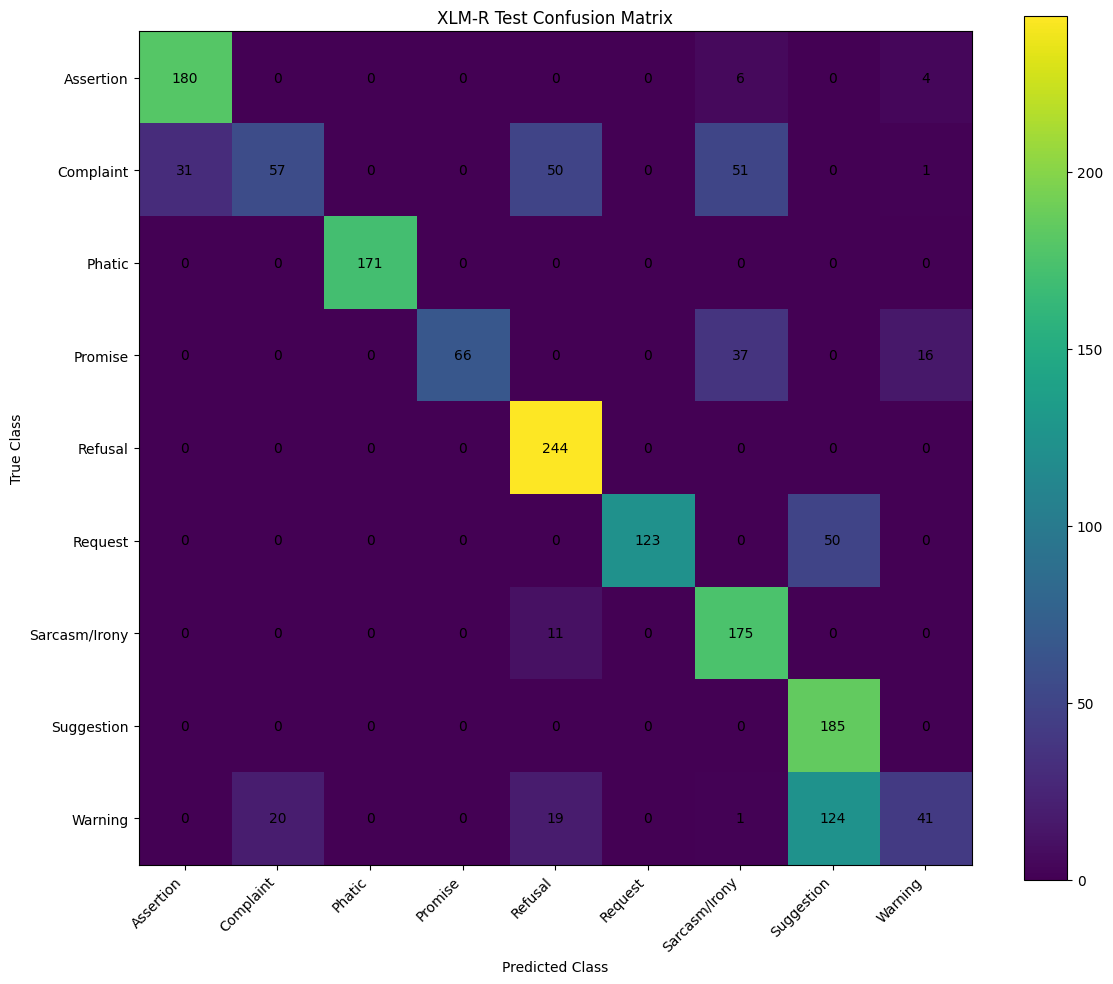


Saved:
/content/xlmr_test_confusion_matrix.csv
/content/xlmr_test_confusion_matrix.png
/content/xlmr_per_class_test_performance.csv

CELL 15 COMPLETED


In [ ]:
# ============================================================
# CELL 15: XLM-R CONFUSION MATRIX AND PER-CLASS ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("=" * 90)
print("XLM-R CONFUSION MATRIX AND PER-CLASS ANALYSIS")
print("=" * 90)

# ------------------------------------------------------------
# 1. Confusion matrix
# ------------------------------------------------------------
labels_xlmr = list(range(len(class_names_xlmr)))

cm_xlmr = confusion_matrix(
    test_true_xlmr,
    test_pred_xlmr,
    labels=labels_xlmr
)

cm_df_xlmr = pd.DataFrame(
    cm_xlmr,
    index=class_names_xlmr,
    columns=class_names_xlmr
)

print("\nCONFUSION MATRIX")
print("-" * 90)
display(cm_df_xlmr)

# ------------------------------------------------------------
# 2. Verify row totals
# ------------------------------------------------------------
test_class_counts_xlmr = pd.Series(
    test_true_xlmr
).value_counts().sort_index()

assert np.all(
    cm_xlmr.sum(axis=1) ==
    test_class_counts_xlmr.values
)

print("\nConfusion matrix row totals verified.")

# ------------------------------------------------------------
# 3. Per-class performance
# ------------------------------------------------------------
per_class_xlmr = classification_report_xlmr.loc[
    class_names_xlmr,
    ["precision", "recall", "f1-score", "support"]
].copy()

per_class_xlmr = per_class_xlmr.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1",
    "support": "Support"
})

per_class_xlmr["Error_Count"] = (
    per_class_xlmr["Support"]
    - np.diag(cm_xlmr)
)

per_class_xlmr["Error_Rate"] = (
    per_class_xlmr["Error_Count"]
    / per_class_xlmr["Support"]
)

print("\nPER-CLASS PERFORMANCE")
print("=" * 90)
display(per_class_xlmr)

# ------------------------------------------------------------
# 4. Identify strongest and weakest classes
# ------------------------------------------------------------
best_class_xlmr = per_class_xlmr["F1"].idxmax()
worst_class_xlmr = per_class_xlmr["F1"].idxmin()

print(f"\nBest class by F1:  {best_class_xlmr}")
print(f"Best F1:           {per_class_xlmr.loc[best_class_xlmr, 'F1']:.6f}")

print(f"\nLowest class by F1: {worst_class_xlmr}")
print(f"Lowest F1:          {per_class_xlmr.loc[worst_class_xlmr, 'F1']:.6f}")

# ------------------------------------------------------------
# 5. Save confusion matrix
# ------------------------------------------------------------
cm_df_xlmr.to_csv(
    "/content/xlmr_test_confusion_matrix.csv"
)

# ------------------------------------------------------------
# 6. Save per-class results
# ------------------------------------------------------------
per_class_xlmr.to_csv(
    "/content/xlmr_per_class_test_performance.csv"
)

# ------------------------------------------------------------
# 7. Plot confusion matrix
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(cm_xlmr)

ax.set_xticks(np.arange(len(class_names_xlmr)))
ax.set_yticks(np.arange(len(class_names_xlmr)))

ax.set_xticklabels(class_names_xlmr, rotation=45, ha="right")
ax.set_yticklabels(class_names_xlmr)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.set_title("XLM-R Test Confusion Matrix")

for i in range(cm_xlmr.shape[0]):
    for j in range(cm_xlmr.shape[1]):
        ax.text(
            j,
            i,
            cm_xlmr[i, j],
            ha="center",
            va="center"
        )

fig.colorbar(im, ax=ax)

plt.tight_layout()

plt.savefig(
    "/content/xlmr_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 8. Final verification
# ------------------------------------------------------------
assert cm_xlmr.sum() == 1663
assert len(per_class_xlmr) == 9

print("\nSaved:")
print("/content/xlmr_test_confusion_matrix.csv")
print("/content/xlmr_test_confusion_matrix.png")
print("/content/xlmr_per_class_test_performance.csv")

print("\n" + "=" * 90)
print("CELL 15 COMPLETED")
print("=" * 90)

In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 1: LOAD AND VERIFY DATASET
# ============================================================

import pandas as pd
import numpy as np

DATA_PATH_MBERT = "/content/amharic_intention_dataset.csv"

df_mbert = pd.read_csv(DATA_PATH_MBERT)

print("=" * 80)
print("mBERT INTENTION DETECTION — DATASET VERIFICATION")
print("=" * 80)

# Required columns
required_columns_mbert = ["text", "label", "split"]

missing_columns_mbert = [
    col for col in required_columns_mbert
    if col not in df_mbert.columns
]

assert not missing_columns_mbert, (
    f"Missing required columns: {missing_columns_mbert}"
)

# Keep only required columns
df_mbert = df_mbert[required_columns_mbert].copy()

# Remove rows missing required values
before_mbert = len(df_mbert)

df_mbert = df_mbert.dropna(
    subset=["text", "label", "split"]
).reset_index(drop=True)

removed_mbert = before_mbert - len(df_mbert)

# Convert to string
df_mbert["text"] = df_mbert["text"].astype(str)
df_mbert["label"] = df_mbert["label"].astype(str)
df_mbert["split"] = df_mbert["split"].astype(str)

# Expected split sizes
expected_mbert = {
    "train": 7955,
    "val": 1857,
    "test": 1663
}

actual_mbert = df_mbert["split"].value_counts().to_dict()

print(f"Dataset path: {DATA_PATH_MBERT}")
print(f"Total samples: {len(df_mbert):,}")
print(f"Rows removed for missing values: {removed_mbert}")
print(f"Number of classes: {df_mbert['label'].nunique()}")

print("\nSplit distribution:")
print(df_mbert["split"].value_counts().sort_index())

# Verify exact split sizes
for split_name, expected_count in expected_mbert.items():
    actual_count = actual_mbert.get(split_name, 0)

    assert actual_count == expected_count, (
        f"{split_name} split mismatch: "
        f"expected {expected_count}, got {actual_count}"
    )

# Verify total
assert len(df_mbert) == 11475, (
    f"Expected 11,475 samples, got {len(df_mbert)}"
)

# Verify exactly 9 classes
assert df_mbert["label"].nunique() == 9, (
    f"Expected 9 classes, got {df_mbert['label'].nunique()}"
)

# Verify only expected splits
assert set(df_mbert["split"].unique()) == {
    "train", "val", "test"
}

# Verify no missing values
assert not df_mbert[
    ["text", "label", "split"]
].isnull().any().any()

print("\nClass labels:")
for i, label in enumerate(sorted(df_mbert["label"].unique())):
    print(f"{i}: {label}")

print("\nDataset verification PASSED.")
print("Total: 11,475")
print("Train: 7,955")
print("Validation: 1,857")
print("Test: 1,663")
print("Classes: 9")

mBERT INTENTION DETECTION — DATASET VERIFICATION
Dataset path: /content/amharic_intention_dataset.csv
Total samples: 11,475
Rows removed for missing values: 0
Number of classes: 9

Split distribution:
split
test     1663
train    7955
val      1857
Name: count, dtype: int64

Class labels:
0: Assertion
1: Complaint
2: Phatic
3: Promise
4: Refusal
5: Request
6: Sarcasm/Irony
7: Suggestion
8: Warning

Dataset verification PASSED.
Total: 11,475
Train: 7,955
Validation: 1,857
Test: 1,663
Classes: 9


In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 2: REPRODUCIBILITY AND ENVIRONMENT
# ============================================================

import os
import random
import numpy as np
import torch
import transformers
import pandas as pd

SEED_MBERT = 42

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
os.environ["PYTHONHASHSEED"] = str(SEED_MBERT)

random.seed(SEED_MBERT)
np.random.seed(SEED_MBERT)

torch.manual_seed(SEED_MBERT)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED_MBERT)
    torch.cuda.manual_seed_all(SEED_MBERT)

# Deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
device_mbert = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("mBERT INTENTION DETECTION — ENVIRONMENT")
print("=" * 80)

print(f"Random seed: {SEED_MBERT}")
print(f"Device: {device_mbert}")

print(f"\nPython version: {__import__('sys').version}")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

if torch.cuda.is_available():
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU count: {torch.cuda.device_count()}")

    print(
        f"GPU memory: "
        f"{torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB"
    )
else:
    print("\nGPU: Not available")

print("\nDeterministic settings:")
print(f"  cudnn.deterministic = {torch.backends.cudnn.deterministic}")
print(f"  cudnn.benchmark     = {torch.backends.cudnn.benchmark}")

# ------------------------------------------------------------
# Verify dataset from Cell 1
# ------------------------------------------------------------
assert "df_mbert" in globals(), (
    "df_mbert is not available. Run Cell 1 first."
)

assert len(df_mbert) == 11475
assert df_mbert["split"].value_counts()["train"] == 7955
assert df_mbert["split"].value_counts()["val"] == 1857
assert df_mbert["split"].value_counts()["test"] == 1663

print("\nDataset verification:")
print("  Total samples: 11,475")
print("  Training:      7,955")
print("  Validation:    1,857")
print("  Test:          1,663")
print("  Classes:       9")

print("\nEnvironment verification PASSED.")

mBERT INTENTION DETECTION — ENVIRONMENT
Random seed: 42
Device: cuda

Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch version: 2.11.0+cu128
Transformers version: 5.16.1
NumPy version: 2.1.3
Pandas version: 2.2.3

GPU: Tesla T4
CUDA version: 12.8
GPU count: 1
GPU memory: 14.56 GB

Deterministic settings:
  cudnn.deterministic = True
  cudnn.benchmark     = False

Dataset verification:
  Total samples: 11,475
  Training:      7,955
  Validation:    1,857
  Test:          1,663
  Classes:       9

Environment verification PASSED.


In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 3: LABEL ENCODING AND DATASET PREPARATION
# ============================================================

from sklearn.preprocessing import LabelEncoder

print("=" * 80)
print("mBERT — LABEL ENCODING AND DATA PREPARATION")
print("=" * 80)

# ------------------------------------------------------------
# Copy verified dataset
# ------------------------------------------------------------
mbert_data = df_mbert.copy()

# Ensure consistent data types
mbert_data["text"] = mbert_data["text"].astype(str)
mbert_data["label"] = mbert_data["label"].astype(str)
mbert_data["split"] = mbert_data["split"].astype(str)

# ------------------------------------------------------------
# Encode class labels
# ------------------------------------------------------------
label_encoder_mbert = LabelEncoder()

label_encoder_mbert.fit(mbert_data["label"])

mbert_data["label_id"] = label_encoder_mbert.transform(
    mbert_data["label"]
)

class_names_mbert = list(label_encoder_mbert.classes_)
num_labels_mbert = len(class_names_mbert)

print(f"Number of classes: {num_labels_mbert}")

print("\nLabel mapping:")
for idx, label in enumerate(class_names_mbert):
    print(f"{idx}: {label}")

# ------------------------------------------------------------
# Create train / validation / test datasets
# ------------------------------------------------------------
train_mbert = mbert_data[
    mbert_data["split"] == "train"
].reset_index(drop=True)

val_mbert = mbert_data[
    mbert_data["split"] == "val"
].reset_index(drop=True)

test_mbert = mbert_data[
    mbert_data["split"] == "test"
].reset_index(drop=True)

# ------------------------------------------------------------
# Verify dataset sizes
# ------------------------------------------------------------
print("\nDataset sizes:")
print(f"Training:   {len(train_mbert):,}")
print(f"Validation: {len(val_mbert):,}")
print(f"Test:       {len(test_mbert):,}")
print(f"Total:      {len(train_mbert) + len(val_mbert) + len(test_mbert):,}")

assert len(train_mbert) == 7955
assert len(val_mbert) == 1857
assert len(test_mbert) == 1663

assert (
    len(train_mbert)
    + len(val_mbert)
    + len(test_mbert)
    == 11475
)

assert num_labels_mbert == 9

# ------------------------------------------------------------
# Verify encoded labels
# ------------------------------------------------------------
expected_label_ids_mbert = list(range(num_labels_mbert))

assert sorted(mbert_data["label_id"].unique()) == expected_label_ids_mbert

print("\nEncoded label IDs:")
print(sorted(mbert_data["label_id"].unique()))

# ------------------------------------------------------------
# Verify no missing values
# ------------------------------------------------------------
assert not mbert_data[
    ["text", "label", "label_id", "split"]
].isnull().any().any()

print("\nLabel encoding verification PASSED.")
print("All 9 intention classes encoded correctly.")

mBERT — LABEL ENCODING AND DATA PREPARATION
Number of classes: 9

Label mapping:
0: Assertion
1: Complaint
2: Phatic
3: Promise
4: Refusal
5: Request
6: Sarcasm/Irony
7: Suggestion
8: Warning

Dataset sizes:
Training:   7,955
Validation: 1,857
Test:       1,663
Total:      11,475

Encoded label IDs:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Label encoding verification PASSED.
All 9 intention classes encoded correctly.


In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 4: TOKENIZER INITIALIZATION AND VERIFICATION
# ============================================================

from transformers import AutoTokenizer

print("=" * 80)
print("mBERT — TOKENIZER INITIALIZATION")
print("=" * 80)

# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------
MODEL_NAME_MBERT = "google-bert/bert-base-multilingual-cased"
MAX_LENGTH_MBERT = 128

# ------------------------------------------------------------
# Load tokenizer
# ------------------------------------------------------------
tokenizer_mbert = AutoTokenizer.from_pretrained(
    MODEL_NAME_MBERT
)

print(f"Model: {MODEL_NAME_MBERT}")
print(f"Tokenizer class: {tokenizer_mbert.__class__.__name__}")
print(f"Vocabulary size: {tokenizer_mbert.vocab_size}")
print(f"Maximum model length: {tokenizer_mbert.model_max_length}")

print("\nSpecial tokens:")
print(f"  CLS token: {tokenizer_mbert.cls_token}")
print(f"  SEP token: {tokenizer_mbert.sep_token}")
print(f"  PAD token: {tokenizer_mbert.pad_token}")
print(f"  UNK token: {tokenizer_mbert.unk_token}")
print(f"  MASK token: {tokenizer_mbert.mask_token}")

# ------------------------------------------------------------
# Verify tokenizer with Amharic text
# ------------------------------------------------------------
sample_text_mbert = train_mbert["text"].iloc[0]

sample_encoding_mbert = tokenizer_mbert(
    sample_text_mbert,
    truncation=True,
    max_length=MAX_LENGTH_MBERT,
    add_special_tokens=True
)

sample_tokens_mbert = tokenizer_mbert.convert_ids_to_tokens(
    sample_encoding_mbert["input_ids"]
)

print("\nAmharic tokenizer test:")
print(f"Sample text: {sample_text_mbert}")
print(f"Token count: {len(sample_encoding_mbert['input_ids'])}")

print("\nTokenized sample:")
print(sample_tokens_mbert)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------
assert tokenizer_mbert is not None
assert tokenizer_mbert.vocab_size > 0
assert len(sample_encoding_mbert["input_ids"]) > 0
assert len(sample_encoding_mbert["input_ids"]) <= MAX_LENGTH_MBERT

# Verify required special tokens
assert tokenizer_mbert.cls_token_id is not None
assert tokenizer_mbert.sep_token_id is not None
assert tokenizer_mbert.pad_token_id is not None

print("\nTokenizer verification PASSED.")
print(f"Maximum sequence length for experiment: {MAX_LENGTH_MBERT}")

mBERT — TOKENIZER INITIALIZATION


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Model: google-bert/bert-base-multilingual-cased
Tokenizer class: BertTokenizer
Vocabulary size: 119547
Maximum model length: 512

Special tokens:
  CLS token: [CLS]
  SEP token: [SEP]
  PAD token: [PAD]
  UNK token: [UNK]
  MASK token: [MASK]

Amharic tokenizer test:
Sample text: ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።
Token count: 10

Tokenized sample:
['[CLS]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[SEP]']

Tokenizer verification PASSED.
Maximum sequence length for experiment: 128


In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 5: TOKENIZE TRAIN / VALIDATION / TEST
# ============================================================

print("=" * 80)
print("mBERT — TOKENIZATION")
print("=" * 80)

# ------------------------------------------------------------
# Tokenization function
# ------------------------------------------------------------
def tokenize_mbert(texts):
    return tokenizer_mbert(
        texts,
        truncation=True,
        max_length=MAX_LENGTH_MBERT,
        padding=False,
        add_special_tokens=True
    )

# ------------------------------------------------------------
# Tokenize each split
# ------------------------------------------------------------
train_encodings_mbert = tokenize_mbert(
    train_mbert["text"].tolist()
)

val_encodings_mbert = tokenize_mbert(
    val_mbert["text"].tolist()
)

test_encodings_mbert = tokenize_mbert(
    test_mbert["text"].tolist()
)

# ------------------------------------------------------------
# Add labels
# ------------------------------------------------------------
train_encodings_mbert["labels"] = train_mbert["label_id"].tolist()
val_encodings_mbert["labels"] = val_mbert["label_id"].tolist()
test_encodings_mbert["labels"] = test_mbert["label_id"].tolist()

# ------------------------------------------------------------
# Sequence-length analysis
# ------------------------------------------------------------
train_lengths_mbert = np.array([
    len(ids) for ids in train_encodings_mbert["input_ids"]
])

val_lengths_mbert = np.array([
    len(ids) for ids in val_encodings_mbert["input_ids"]
])

test_lengths_mbert = np.array([
    len(ids) for ids in test_encodings_mbert["input_ids"]
])

def print_length_stats(name, lengths):
    print(f"\n{name}:")
    print(f"  Samples:        {len(lengths):,}")
    print(f"  Minimum length: {lengths.min()}")
    print(f"  Maximum length: {lengths.max()}")
    print(f"  Mean length:    {lengths.mean():.2f}")
    print(
        f"  Reached {MAX_LENGTH_MBERT}: "
        f"{np.sum(lengths == MAX_LENGTH_MBERT):,}"
    )

print_length_stats("Training", train_lengths_mbert)
print_length_stats("Validation", val_lengths_mbert)
print_length_stats("Test", test_lengths_mbert)

# ------------------------------------------------------------
# Verify tokenized sample counts
# ------------------------------------------------------------
assert len(train_encodings_mbert["input_ids"]) == 7955
assert len(val_encodings_mbert["input_ids"]) == 1857
assert len(test_encodings_mbert["input_ids"]) == 1663

assert len(train_encodings_mbert["labels"]) == 7955
assert len(val_encodings_mbert["labels"]) == 1857
assert len(test_encodings_mbert["labels"]) == 1663

# ------------------------------------------------------------
# Verify maximum length constraint
# ------------------------------------------------------------
assert train_lengths_mbert.max() <= MAX_LENGTH_MBERT
assert val_lengths_mbert.max() <= MAX_LENGTH_MBERT
assert test_lengths_mbert.max() <= MAX_LENGTH_MBERT

# ------------------------------------------------------------
# Verify labels
# ------------------------------------------------------------
assert set(train_encodings_mbert["labels"]) <= set(range(num_labels_mbert))
assert set(val_encodings_mbert["labels"]) <= set(range(num_labels_mbert))
assert set(test_encodings_mbert["labels"]) <= set(range(num_labels_mbert))

# ------------------------------------------------------------
# Label distribution
# ------------------------------------------------------------
print("\nLabel distribution by split:")

for split_name, split_data in [
    ("Training", train_mbert),
    ("Validation", val_mbert),
    ("Test", test_mbert)
]:
    counts = split_data["label"].value_counts().reindex(
        class_names_mbert,
        fill_value=0
    )

    print(f"\n{split_name}:")
    for label, count in counts.items():
        print(f"  {label}: {count:,}")

print("\nTokenization verification PASSED.")

mBERT — TOKENIZATION

Training:
  Samples:        7,955
  Minimum length: 6
  Maximum length: 17
  Mean length:    10.06
  Reached 128: 0

Validation:
  Samples:        1,857
  Minimum length: 6
  Maximum length: 14
  Mean length:    9.46
  Reached 128: 0

Test:
  Samples:        1,663
  Minimum length: 6
  Maximum length: 15
  Mean length:    9.73
  Reached 128: 0

Label distribution by split:

Training:
  Assertion: 897
  Complaint: 895
  Phatic: 873
  Promise: 818
  Refusal: 867
  Request: 929
  Sarcasm/Irony: 896
  Suggestion: 891

Validation:
  Assertion: 188
  Complaint: 190
  Phatic: 231
  Promise: 338
  Refusal: 164
  Request: 173
  Sarcasm/Irony: 193
  Suggestion: 199

Test:
  Assertion: 190
  Complaint: 190
  Phatic: 171
  Promise: 119
  Refusal: 244
  Request: 173
  Sarcasm/Irony: 186
  Suggestion: 185

Tokenization verification PASSED.


In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 6: HUGGING FACE DATASET CONVERSION
# ============================================================

from datasets import Dataset

print("=" * 80)
print("mBERT — HUGGING FACE DATASET CONVERSION")
print("=" * 80)

# ------------------------------------------------------------
# Create Hugging Face datasets
# ------------------------------------------------------------
train_dataset_mbert = Dataset.from_dict(
    train_encodings_mbert
)

val_dataset_mbert = Dataset.from_dict(
    val_encodings_mbert
)

test_dataset_mbert = Dataset.from_dict(
    test_encodings_mbert
)

# ------------------------------------------------------------
# Keep only model-required columns
# ------------------------------------------------------------
model_columns_mbert = [
    "input_ids",
    "attention_mask",
    "labels"
]

train_dataset_mbert = train_dataset_mbert.select_columns(
    model_columns_mbert
)

val_dataset_mbert = val_dataset_mbert.select_columns(
    model_columns_mbert
)

test_dataset_mbert = test_dataset_mbert.select_columns(
    model_columns_mbert
)

# ------------------------------------------------------------
# Verify dataset sizes
# ------------------------------------------------------------
print("Dataset sizes:")
print(f"  Training:   {len(train_dataset_mbert):,}")
print(f"  Validation: {len(val_dataset_mbert):,}")
print(f"  Test:       {len(test_dataset_mbert):,}")

assert len(train_dataset_mbert) == 7955
assert len(val_dataset_mbert) == 1857
assert len(test_dataset_mbert) == 1663

# ------------------------------------------------------------
# Verify columns
# ------------------------------------------------------------
print("\nDataset columns:")
print(f"  {train_dataset_mbert.column_names}")

assert train_dataset_mbert.column_names == model_columns_mbert
assert val_dataset_mbert.column_names == model_columns_mbert
assert test_dataset_mbert.column_names == model_columns_mbert

# ------------------------------------------------------------
# Verify labels
# ------------------------------------------------------------
train_labels_mbert = set(train_dataset_mbert["labels"])
val_labels_mbert = set(val_dataset_mbert["labels"])
test_labels_mbert = set(test_dataset_mbert["labels"])

expected_labels_mbert = set(range(num_labels_mbert))

assert train_labels_mbert <= expected_labels_mbert
assert val_labels_mbert <= expected_labels_mbert
assert test_labels_mbert <= expected_labels_mbert

print("\nLabel IDs found:")
print(f"  Training:   {sorted(train_labels_mbert)}")
print(f"  Validation: {sorted(val_labels_mbert)}")
print(f"  Test:       {sorted(test_labels_mbert)}")

# ------------------------------------------------------------
# Inspect one example
# ------------------------------------------------------------
example_mbert = train_dataset_mbert[0]

print("\nExample structure:")
print(f"  input_ids length: {len(example_mbert['input_ids'])}")
print(f"  attention_mask length: {len(example_mbert['attention_mask'])}")
print(f"  label ID: {example_mbert['labels']}")

assert len(example_mbert["input_ids"]) == len(
    example_mbert["attention_mask"]
)

assert isinstance(
    example_mbert["labels"], int
)

print("\nHugging Face dataset verification PASSED.")

mBERT — HUGGING FACE DATASET CONVERSION
Dataset sizes:
  Training:   7,955
  Validation: 1,857
  Test:       1,663

Dataset columns:
  ['input_ids', 'attention_mask', 'labels']

Label IDs found:
  Training:   [0, 1, 2, 3, 4, 5, 6, 7, 8]
  Validation: [0, 1, 2, 3, 4, 5, 6, 7, 8]
  Test:       [0, 1, 2, 3, 4, 5, 6, 7, 8]

Example structure:
  input_ids length: 10
  attention_mask length: 10
  label ID: 1

Hugging Face dataset verification PASSED.


In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 7: MODEL INITIALIZATION
# ============================================================

from transformers import AutoModelForSequenceClassification

print("=" * 80)
print("mBERT — MODEL INITIALIZATION")
print("=" * 80)

# ------------------------------------------------------------
# Load mBERT
# ------------------------------------------------------------
MODEL_NAME_MBERT = "google-bert/bert-base-multilingual-cased"

model_mbert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_MBERT,
    num_labels=num_labels_mbert,
    id2label={
        i: label
        for i, label in enumerate(class_names_mbert)
    },
    label2id={
        label: i
        for i, label in enumerate(class_names_mbert)
    }
)

# ------------------------------------------------------------
# Move model to available device
# ------------------------------------------------------------
model_mbert = model_mbert.to(device_mbert)

# ------------------------------------------------------------
# Parameter counts
# ------------------------------------------------------------
total_params_mbert = sum(
    p.numel() for p in model_mbert.parameters()
)

trainable_params_mbert = sum(
    p.numel()
    for p in model_mbert.parameters()
    if p.requires_grad
)

print(f"Model: {MODEL_NAME_MBERT}")
print(f"Number of classes: {num_labels_mbert}")
print(f"Total parameters: {total_params_mbert:,}")
print(f"Trainable parameters: {trainable_params_mbert:,}")

# ------------------------------------------------------------
# Classification head
# ------------------------------------------------------------
print("\nClassification head:")
print(model_mbert.classifier)

# ------------------------------------------------------------
# Label mapping
# ------------------------------------------------------------
print("\nLabel mapping:")
for i, label in enumerate(class_names_mbert):
    print(f"  {i}: {label}")

# ------------------------------------------------------------
# Forward-pass verification
# ------------------------------------------------------------
model_mbert.eval()

sample_mbert = train_dataset_mbert[0]

sample_input_ids_mbert = torch.tensor(
    [sample_mbert["input_ids"]],
    dtype=torch.long,
    device=device_mbert
)

sample_attention_mask_mbert = torch.tensor(
    [sample_mbert["attention_mask"]],
    dtype=torch.long,
    device=device_mbert
)

with torch.no_grad():
    sample_output_mbert = model_mbert(
        input_ids=sample_input_ids_mbert,
        attention_mask=sample_attention_mask_mbert
    )

logits_mbert = sample_output_mbert.logits

print("\nForward-pass verification:")
print(f"  Input shape:  {sample_input_ids_mbert.shape}")
print(f"  Logits shape: {logits_mbert.shape}")

# ------------------------------------------------------------
# Verify expected output shape
# ------------------------------------------------------------
assert logits_mbert.shape == (1, num_labels_mbert)

assert num_labels_mbert == 9

print("\nModel verification PASSED.")
print("mBERT produces the expected 9-class output.")

mBERT — MODEL INITIALIZATION


model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

Model: google-bert/bert-base-multilingual-cased
Number of classes: 9
Total parameters: 177,860,361
Trainable parameters: 177,860,361

Classification head:
Linear(in_features=768, out_features=9, bias=True)

Label mapping:
  0: Assertion
  1: Complaint
  2: Phatic
  3: Promise
  4: Refusal
  5: Request
  6: Sarcasm/Irony
  7: Suggestion
  8: Warning

Forward-pass verification:
  Input shape:  torch.Size([1, 10])
  Logits shape: torch.Size([1, 9])

Model verification PASSED.
mBERT produces the expected 9-class output.


In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 8: DATA COLLATOR AND METRICS
# ============================================================

from transformers import DataCollatorWithPadding
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

print("=" * 80)
print("mBERT — DATA COLLATOR AND EVALUATION METRICS")
print("=" * 80)

# ------------------------------------------------------------
# Dynamic padding
# ------------------------------------------------------------
data_collator_mbert = DataCollatorWithPadding(
    tokenizer=tokenizer_mbert,
    padding=True
)

print("Data collator:")
print(f"  Type: {data_collator_mbert.__class__.__name__}")
print("  Padding: Dynamic")

# ------------------------------------------------------------
# Evaluation metric function
# ------------------------------------------------------------
def compute_metrics_mbert(eval_pred):

    predictions, labels = eval_pred

    # Convert logits to predicted class IDs
    predictions = np.argmax(
        predictions,
        axis=-1
    )

    # Accuracy
    accuracy = accuracy_score(
        labels,
        predictions
    )

    # Macro metrics
    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    # Weighted metrics
    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

# ------------------------------------------------------------
# Verify metric function
# ------------------------------------------------------------
test_true_mbert = np.array([0, 1, 2, 3, 4])
test_logits_mbert = np.array([
    [5, 1, 0, 0, 0],
    [0, 5, 1, 0, 0],
    [0, 0, 5, 1, 0],
    [0, 0, 0, 5, 1],
    [0, 0, 0, 1, 5]
])

test_metrics_mbert = compute_metrics_mbert(
    (test_logits_mbert, test_true_mbert)
)

print("\nMetric verification:")
for metric_name, metric_value in test_metrics_mbert.items():
    print(f"  {metric_name}: {metric_value:.6f}")

# All metrics must be valid
assert set(test_metrics_mbert.keys()) == {
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1"
}

for value in test_metrics_mbert.values():
    assert 0.0 <= value <= 1.0

print("\nMetrics verification PASSED.")
print("Evaluation will use accuracy, macro P/R/F1, and weighted P/R/F1.")

mBERT — DATA COLLATOR AND EVALUATION METRICS
Data collator:
  Type: DataCollatorWithPadding
  Padding: Dynamic

Metric verification:
  accuracy: 1.000000
  macro_precision: 1.000000
  macro_recall: 1.000000
  macro_f1: 1.000000
  weighted_precision: 1.000000
  weighted_recall: 1.000000
  weighted_f1: 1.000000

Metrics verification PASSED.
Evaluation will use accuracy, macro P/R/F1, and weighted P/R/F1.


In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 9: TRAINING CONFIGURATION
# ============================================================

from transformers import TrainingArguments

print("=" * 80)
print("mBERT — TRAINING CONFIGURATION")
print("=" * 80)

# ------------------------------------------------------------
# Fair experimental settings
# ------------------------------------------------------------
EPOCHS_MBERT = 10
LEARNING_RATE_MBERT = 2e-5
BATCH_SIZE_MBERT = 16
WEIGHT_DECAY_MBERT = 0.01
SEED_MBERT = 42

OUTPUT_DIR_MBERT = "/content/mbert_intention_detection"

# ------------------------------------------------------------
# Training arguments
# ------------------------------------------------------------
training_args_mbert = TrainingArguments(
    output_dir=OUTPUT_DIR_MBERT,

    # Training
    num_train_epochs=EPOCHS_MBERT,
    learning_rate=LEARNING_RATE_MBERT,
    per_device_train_batch_size=BATCH_SIZE_MBERT,
    per_device_eval_batch_size=BATCH_SIZE_MBERT,
    weight_decay=WEIGHT_DECAY_MBERT,

    # Evaluation
    eval_strategy="epoch",

    # Checkpointing
    save_strategy="epoch",
    save_total_limit=10,

    # Logging
    logging_strategy="epoch",

    # Reproducibility
    seed=SEED_MBERT,
    data_seed=SEED_MBERT,

    # Select best model using validation Macro-F1
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    # Performance
    fp16=torch.cuda.is_available(),

    # Disable external logging
    report_to="none",

    # Keep unused columns behavior explicit
    remove_unused_columns=True
)

print("Training configuration:")
print(f"  Model:              {MODEL_NAME_MBERT}")
print(f"  Epochs:             {EPOCHS_MBERT}")
print(f"  Learning rate:      {LEARNING_RATE_MBERT}")
print(f"  Batch size:         {BATCH_SIZE_MBERT}")
print(f"  Weight decay:       {WEIGHT_DECAY_MBERT}")
print(f"  Maximum length:     {MAX_LENGTH_MBERT}")
print(f"  Seed:               {SEED_MBERT}")
print(f"  FP16:               {torch.cuda.is_available()}")
print(f"  Evaluation:         Every epoch")
print(f"  Checkpoint saving:  Every epoch")
print(f"  Best model metric:  Validation Macro-F1")
print(f"  Best model loading: Enabled")
print(f"  Output directory:   {OUTPUT_DIR_MBERT}")

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------
assert EPOCHS_MBERT == 10
assert LEARNING_RATE_MBERT == 2e-5
assert BATCH_SIZE_MBERT == 16
assert WEIGHT_DECAY_MBERT == 0.01
assert SEED_MBERT == 42
assert MAX_LENGTH_MBERT == 128

print("\nTraining configuration verification PASSED.")

mBERT — TRAINING CONFIGURATION
Training configuration:
  Model:              google-bert/bert-base-multilingual-cased
  Epochs:             10
  Learning rate:      2e-05
  Batch size:         16
  Weight decay:       0.01
  Maximum length:     128
  Seed:               42
  FP16:               True
  Evaluation:         Every epoch
  Checkpoint saving:  Every epoch
  Best model metric:  Validation Macro-F1
  Best model loading: Enabled
  Output directory:   /content/mbert_intention_detection

Training configuration verification PASSED.


In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 10: TRAINER SETUP AND VERIFICATION
# ============================================================

from transformers import Trainer

print("=" * 80)
print("mBERT — TRAINER SETUP")
print("=" * 80)

# ------------------------------------------------------------
# Create Trainer
# ------------------------------------------------------------
trainer_mbert = Trainer(
    model=model_mbert,
    args=training_args_mbert,
    train_dataset=train_dataset_mbert,
    eval_dataset=val_dataset_mbert,
    processing_class=tokenizer_mbert,
    data_collator=data_collator_mbert,
    compute_metrics=compute_metrics_mbert
)

print("Trainer created successfully.")

# ------------------------------------------------------------
# Verify Trainer configuration
# ------------------------------------------------------------
print("\nTrainer verification:")
print(f"  Model: {MODEL_NAME_MBERT}")
print(f"  Training samples: {len(trainer_mbert.train_dataset):,}")
print(f"  Validation samples: {len(trainer_mbert.eval_dataset):,}")
print(f"  Number of classes: {num_labels_mbert}")
print(f"  Epochs: {training_args_mbert.num_train_epochs}")
print(f"  Learning rate: {training_args_mbert.learning_rate}")
print(
    f"  Training batch size: "
    f"{training_args_mbert.per_device_train_batch_size}"
)
print(
    f"  Evaluation batch size: "
    f"{training_args_mbert.per_device_eval_batch_size}"
)
print(
    f"  Best-model metric: "
    f"{training_args_mbert.metric_for_best_model}"
)
print(
    f"  Load best model: "
    f"{training_args_mbert.load_best_model_at_end}"
)

# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------
assert trainer_mbert.train_dataset is train_dataset_mbert
assert trainer_mbert.eval_dataset is val_dataset_mbert

assert len(trainer_mbert.train_dataset) == 7955
assert len(trainer_mbert.eval_dataset) == 1857

assert training_args_mbert.num_train_epochs == 10
assert training_args_mbert.learning_rate == 2e-5
assert training_args_mbert.per_device_train_batch_size == 16
assert training_args_mbert.per_device_eval_batch_size == 16

assert training_args_mbert.metric_for_best_model == "macro_f1"
assert training_args_mbert.load_best_model_at_end is True

print("\nTrainer verification PASSED.")
print("mBERT is ready for the 10-epoch training run.")

mBERT — TRAINER SETUP
Trainer created successfully.

Trainer verification:
  Model: google-bert/bert-base-multilingual-cased
  Training samples: 7,955
  Validation samples: 1,857
  Number of classes: 9
  Epochs: 10
  Learning rate: 2e-05
  Training batch size: 16
  Evaluation batch size: 16
  Best-model metric: macro_f1
  Load best model: True

Trainer verification PASSED.
mBERT is ready for the 10-epoch training run.


In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 11: TRAINING
# ============================================================

import time
import gc
import torch

print("=" * 80)
print("mBERT — STARTING TRAINING")
print("=" * 80)

# ------------------------------------------------------------
# Clear unused GPU memory
# ------------------------------------------------------------
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# ------------------------------------------------------------
# Training information
# ------------------------------------------------------------
print(f"Model: {MODEL_NAME_MBERT}")
print(f"Training samples: {len(train_dataset_mbert):,}")
print(f"Validation samples: {len(val_dataset_mbert):,}")
print(f"Test samples: {len(test_dataset_mbert):,}")
print(f"Epochs: {EPOCHS_MBERT}")
print(f"Learning rate: {LEARNING_RATE_MBERT}")
print(f"Batch size: {BATCH_SIZE_MBERT}")
print(f"Weight decay: {WEIGHT_DECAY_MBERT}")
print(f"Maximum sequence length: {MAX_LENGTH_MBERT}")
print(f"Seed: {SEED_MBERT}")
print(f"Device: {device_mbert}")
print(f"FP16: {torch.cuda.is_available()}")

print("\nTest set will NOT be used during training.")

# ------------------------------------------------------------
# Start training
# ------------------------------------------------------------
training_start_mbert = time.time()

train_result_mbert = trainer_mbert.train()

training_end_mbert = time.time()

training_time_mbert = (
    training_end_mbert - training_start_mbert
)

# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("mBERT TRAINING COMPLETED")
print("=" * 80)

print(f"Training time: {training_time_mbert / 60:.2f} minutes")
print(f"Global steps: {trainer_mbert.state.global_step:,}")

if hasattr(train_result_mbert, "training_loss"):
    print(
        f"Final training loss: "
        f"{train_result_mbert.training_loss:.6f}"
    )

print(
    f"Best checkpoint: "
    f"{trainer_mbert.state.best_model_checkpoint}"
)

print(
    f"Best validation Macro-F1: "
    f"{trainer_mbert.state.best_metric:.6f}"
)

# ------------------------------------------------------------
# Verify training completion
# ------------------------------------------------------------
assert train_result_mbert is not None
assert trainer_mbert.state.global_step > 0
assert trainer_mbert.state.best_model_checkpoint is not None
assert trainer_mbert.state.best_metric is not None

print("\nTraining verification PASSED.")
print("The best model was selected using validation Macro-F1.")

mBERT — STARTING TRAINING
Model: google-bert/bert-base-multilingual-cased
Training samples: 7,955
Validation samples: 1,857
Test samples: 1,663
Epochs: 10
Learning rate: 2e-05
Batch size: 16
Weight decay: 0.01
Maximum sequence length: 128
Seed: 42
Device: cuda
FP16: True

Test set will NOT be used during training.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.943606,1.919989,0.191169,0.148768,0.185879,0.130056,0.145442,0.191169,0.130881
2,1.789788,1.867476,0.311793,0.254029,0.324738,0.274851,0.252961,0.311793,0.270406
3,1.767883,1.875867,0.293484,0.246426,0.302408,0.263622,0.246741,0.293484,0.261219
4,1.753229,1.908965,0.293484,0.234272,0.302408,0.257259,0.233076,0.293484,0.254047
5,1.762660,1.892062,0.293484,0.246665,0.302408,0.263821,0.246951,0.293484,0.261394
6,1.741988,1.978945,0.250404,0.155913,0.248207,0.182818,0.152985,0.250404,0.181358
7,1.743699,1.911449,0.293484,0.248260,0.302408,0.265341,0.248218,0.293484,0.262602
8,1.739051,1.916866,0.293484,0.237802,0.302408,0.259854,0.236510,0.293484,0.256459
9,1.736010,1.946896,0.293484,0.248260,0.302408,0.265341,0.248218,0.293484,0.262602
10,1.733258,1.929823,0.293484,0.237802,0.302408,0.259854,0.236510,0.293484,0.256459


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


mBERT TRAINING COMPLETED
Training time: 17.78 minutes
Global steps: 4,980
Final training loss: 1.771117
Best checkpoint: /content/mbert_intention_detection/checkpoint-996
Best validation Macro-F1: 0.274851

Training verification PASSED.
The best model was selected using validation Macro-F1.


In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 13: VERIFY BEST VALIDATION PERFORMANCE
# ============================================================

print("=" * 80)
print("mBERT — BEST VALIDATION PERFORMANCE VERIFICATION")
print("=" * 80)

# ------------------------------------------------------------
# Best epoch from validation Macro-F1
# ------------------------------------------------------------
best_idx_mbert = history_mbert[
    "Validation Macro F1"
].idxmax()

best_validation_mbert = history_mbert.loc[
    best_idx_mbert
]

best_epoch_mbert = int(
    best_validation_mbert["Epoch"]
)

best_macro_f1_mbert = float(
    best_validation_mbert["Validation Macro F1"]
)

# ------------------------------------------------------------
# Trainer's selected best metric
# ------------------------------------------------------------
trainer_best_metric_mbert = float(
    trainer_mbert.state.best_metric
)

trainer_best_checkpoint_mbert = (
    trainer_mbert.state.best_model_checkpoint
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
print(f"Best epoch:                 {best_epoch_mbert}")
print(
    f"Best validation Macro-F1:   "
    f"{best_macro_f1_mbert:.6f}"
)
print(
    f"Trainer best metric:        "
    f"{trainer_best_metric_mbert:.6f}"
)
print(
    f"Best checkpoint:            "
    f"{trainer_best_checkpoint_mbert}"
)

print("\nBest validation metrics:")

metrics_to_display_mbert = [
    "Validation Loss",
    "Validation Accuracy",
    "Validation Macro Precision",
    "Validation Macro Recall",
    "Validation Macro F1",
    "Validation Weighted Precision",
    "Validation Weighted Recall",
    "Validation Weighted F1"
]

for metric in metrics_to_display_mbert:
    value = best_validation_mbert[metric]

    if pd.notna(value):
        print(f"  {metric}: {float(value):.6f}")

# ------------------------------------------------------------
# Verify Trainer selection
# ------------------------------------------------------------
assert np.isclose(
    best_macro_f1_mbert,
    trainer_best_metric_mbert,
    atol=1e-6
)

assert trainer_best_checkpoint_mbert is not None

# ------------------------------------------------------------
# Save best validation summary
# ------------------------------------------------------------
best_validation_summary_mbert = pd.DataFrame([{
    "Model": "mBERT",
    "Best Epoch": best_epoch_mbert,
    "Best Validation Macro F1": best_macro_f1_mbert,
    "Validation Loss": best_validation_mbert["Validation Loss"],
    "Validation Accuracy": best_validation_mbert["Validation Accuracy"],
    "Validation Macro Precision": best_validation_mbert[
        "Validation Macro Precision"
    ],
    "Validation Macro Recall": best_validation_mbert[
        "Validation Macro Recall"
    ],
    "Validation Weighted Precision": best_validation_mbert[
        "Validation Weighted Precision"
    ],
    "Validation Weighted Recall": best_validation_mbert[
        "Validation Weighted Recall"
    ],
    "Validation Weighted F1": best_validation_mbert[
        "Validation Weighted F1"
    ],
    "Best Checkpoint": trainer_best_checkpoint_mbert
}])

BEST_VALIDATION_MBERT_PATH = (
    "/content/mbert_best_validation_summary.csv"
)

best_validation_summary_mbert.to_csv(
    BEST_VALIDATION_MBERT_PATH,
    index=False
)

print(
    f"\nSaved: {BEST_VALIDATION_MBERT_PATH}"
)

print("\nBest validation performance verification PASSED.")

In [ ]:
# ============================================================
# mBERT INTENTION DETECTION
# CELL 14: FINAL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)
import pandas as pd
import numpy as np
import time

print("=" * 80)
print("mBERT — FINAL TEST EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# Verify best model is loaded
# ------------------------------------------------------------
assert trainer_mbert.state.best_model_checkpoint is not None

print(
    f"Best checkpoint: "
    f"{trainer_mbert.state.best_model_checkpoint}"
)

print(
    f"Test samples: "
    f"{len(test_dataset_mbert):,}"
)

# ------------------------------------------------------------
# Test prediction
# ------------------------------------------------------------
test_start_mbert = time.time()

test_prediction_mbert = trainer_mbert.predict(
    test_dataset_mbert
)

test_end_mbert = time.time()

test_time_mbert = test_end_mbert - test_start_mbert

# ------------------------------------------------------------
# Extract predictions and labels
# ------------------------------------------------------------
test_logits_mbert = test_prediction_mbert.predictions
test_true_mbert = test_prediction_mbert.label_ids

test_pred_mbert = np.argmax(
    test_logits_mbert,
    axis=-1
)

# ------------------------------------------------------------
# Overall metrics
# ------------------------------------------------------------
accuracy_mbert = accuracy_score(
    test_true_mbert,
    test_pred_mbert
)

macro_precision_mbert, macro_recall_mbert, macro_f1_mbert, _ = (
    precision_recall_fscore_support(
        test_true_mbert,
        test_pred_mbert,
        average="macro",
        zero_division=0
    )
)

weighted_precision_mbert, weighted_recall_mbert, weighted_f1_mbert, _ = (
    precision_recall_fscore_support(
        test_true_mbert,
        test_pred_mbert,
        average="weighted",
        zero_division=0
    )
)

# ------------------------------------------------------------
# Correct / incorrect predictions
# ------------------------------------------------------------
correct_mbert = int(
    np.sum(test_true_mbert == test_pred_mbert)
)

incorrect_mbert = int(
    np.sum(test_true_mbert != test_pred_mbert)
)

total_mbert = len(test_true_mbert)

# ------------------------------------------------------------
# Display final results
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("FINAL mBERT TEST PERFORMANCE")
print("=" * 80)

print(f"Accuracy:             {accuracy_mbert:.6f} ({accuracy_mbert*100:.2f}%)")
print(f"Macro Precision:      {macro_precision_mbert:.6f} ({macro_precision_mbert*100:.2f}%)")
print(f"Macro Recall:         {macro_recall_mbert:.6f} ({macro_recall_mbert*100:.2f}%)")
print(f"Macro F1:             {macro_f1_mbert:.6f} ({macro_f1_mbert*100:.2f}%)")
print(f"Weighted Precision:   {weighted_precision_mbert:.6f} ({weighted_precision_mbert*100:.2f}%)")
print(f"Weighted Recall:      {weighted_recall_mbert:.6f} ({weighted_recall_mbert*100:.2f}%)")
print(f"Weighted F1:          {weighted_f1_mbert:.6f} ({weighted_f1_mbert*100:.2f}%)")

print(f"\nCorrect predictions:   {correct_mbert:,}")
print(f"Incorrect predictions: {incorrect_mbert:,}")
print(f"Total predictions:     {total_mbert:,}")
print(f"Test evaluation time:  {test_time_mbert:.2f} seconds")

# ------------------------------------------------------------
# Verify prediction count
# ------------------------------------------------------------
assert total_mbert == 1663

assert correct_mbert + incorrect_mbert == total_mbert

assert len(test_pred_mbert) == 1663
assert len(test_true_mbert) == 1663

# ------------------------------------------------------------
# Save predictions
# ------------------------------------------------------------
test_predictions_mbert_df = pd.DataFrame({
    "text": test_mbert["text"].values,
    "true_label": [
        class_names_mbert[i]
        for i in test_true_mbert
    ],
    "predicted_label": [
        class_names_mbert[i]
        for i in test_pred_mbert
    ],
    "true_label_id": test_true_mbert,
    "predicted_label_id": test_pred_mbert
})

MBERT_PREDICTIONS_PATH = (
    "/content/mbert_final_test_predictions.csv"
)

test_predictions_mbert_df.to_csv(
    MBERT_PREDICTIONS_PATH,
    index=False
)

# ------------------------------------------------------------
# Save overall metrics
# ------------------------------------------------------------
mbert_test_metrics_df = pd.DataFrame([{
    "Model": "mBERT",
    "Accuracy": accuracy_mbert,
    "Macro Precision": macro_precision_mbert,
    "Macro Recall": macro_recall_mbert,
    "Macro F1": macro_f1_mbert,
    "Weighted Precision": weighted_precision_mbert,
    "Weighted Recall": weighted_recall_mbert,
    "Weighted F1": weighted_f1_mbert,
    "Correct": correct_mbert,
    "Incorrect": incorrect_mbert,
    "Total": total_mbert
}])

MBERT_METRICS_PATH = (
    "/content/mbert_final_test_metrics.csv"
)

mbert_test_metrics_df.to_csv(
    MBERT_METRICS_PATH,
    index=False
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------
classification_report_mbert = classification_report(
    test_true_mbert,
    test_pred_mbert,
    target_names=class_names_mbert,
    output_dict=True,
    zero_division=0
)

classification_report_mbert_df = pd.DataFrame(
    classification_report_mbert
).transpose()

MBERT_REPORT_PATH = (
    "/content/mbert_final_classification_report.csv"
)

classification_report_mbert_df.to_csv(
    MBERT_REPORT_PATH
)

print("\nSaved files:")
print(f"  {MBERT_PREDICTIONS_PATH}")
print(f"  {MBERT_METRICS_PATH}")
print(f"  {MBERT_REPORT_PATH}")

print("\nFinal mBERT test evaluation completed successfully.")

mBERT — FINAL TEST EVALUATION
Best checkpoint: /content/mbert_intention_detection/checkpoint-996
Test samples: 1,663



FINAL mBERT TEST PERFORMANCE
Accuracy:             0.167168 (16.72%)
Macro Precision:      0.204036 (20.40%)
Macro Recall:         0.165396 (16.54%)
Macro F1:             0.120605 (12.06%)
Weighted Precision:   0.198172 (19.82%)
Weighted Recall:      0.167168 (16.72%)
Weighted F1:          0.122352 (12.24%)

Correct predictions:   278
Incorrect predictions: 1,385
Total predictions:     1,663
Test evaluation time:  3.63 seconds

Saved files:
  /content/mbert_final_test_predictions.csv
  /content/mbert_final_test_metrics.csv
  /content/mbert_final_classification_report.csv

Final mBERT test evaluation completed successfully.


In [ ]:
# ============================================================
# BiLSTM INTENTION DETECTION
# CELL 1: LOAD AND VERIFY DATASET
# ============================================================

import pandas as pd
import numpy as np

DATA_PATH_BILSTM = "/content/amharic_intention_dataset.csv"

df_bilstm = pd.read_csv(DATA_PATH_BILSTM)

print("=" * 80)
print("BiLSTM INTENTION DETECTION — DATASET VERIFICATION")
print("=" * 80)

required_columns_bilstm = ["text", "label", "split"]

missing_columns_bilstm = [
    col for col in required_columns_bilstm
    if col not in df_bilstm.columns
]

assert not missing_columns_bilstm, (
    f"Missing required columns: {missing_columns_bilstm}"
)

df_bilstm = df_bilstm[
    required_columns_bilstm
].copy()

before_bilstm = len(df_bilstm)

df_bilstm = df_bilstm.dropna(
    subset=["text", "label", "split"]
).reset_index(drop=True)

removed_bilstm = before_bilstm - len(df_bilstm)

df_bilstm["text"] = df_bilstm["text"].astype(str)
df_bilstm["label"] = df_bilstm["label"].astype(str)
df_bilstm["split"] = df_bilstm["split"].astype(str)

# ------------------------------------------------------------
# Verify exact split sizes
# ------------------------------------------------------------
expected_splits_bilstm = {
    "train": 7955,
    "val": 1857,
    "test": 1663
}

actual_splits_bilstm = (
    df_bilstm["split"]
    .value_counts()
    .to_dict()
)

print(f"Dataset path: {DATA_PATH_BILSTM}")
print(f"Total samples: {len(df_bilstm):,}")
print(f"Rows removed: {removed_bilstm}")

print("\nSplit distribution:")
print(
    df_bilstm["split"]
    .value_counts()
    .sort_index()
)

for split_name, expected_count in expected_splits_bilstm.items():

    actual_count = actual_splits_bilstm.get(
        split_name,
        0
    )

    assert actual_count == expected_count, (
        f"{split_name}: expected "
        f"{expected_count}, got {actual_count}"
    )

# ------------------------------------------------------------
# Verify total and classes
# ------------------------------------------------------------
assert len(df_bilstm) == 11475

num_classes_bilstm = df_bilstm["label"].nunique()

assert num_classes_bilstm == 9

assert set(df_bilstm["split"].unique()) == {
    "train",
    "val",
    "test"
}

assert not df_bilstm[
    ["text", "label", "split"]
].isnull().any().any()

# ------------------------------------------------------------
# Display class labels
# ------------------------------------------------------------
class_names_bilstm = sorted(
    df_bilstm["label"].unique()
)

print("\nNumber of classes:", num_classes_bilstm)

print("\nClass labels:")
for i, label in enumerate(class_names_bilstm):
    print(f"{i}: {label}")

print("\n" + "=" * 80)
print("DATASET VERIFICATION PASSED")
print("=" * 80)

print("Total:      11,475")
print("Training:    7,955")
print("Validation:  1,857")
print("Test:        1,663")
print("Classes:         9")

BiLSTM INTENTION DETECTION — DATASET VERIFICATION
Dataset path: /content/amharic_intention_dataset.csv
Total samples: 11,475
Rows removed: 0

Split distribution:
split
test     1663
train    7955
val      1857
Name: count, dtype: int64

Number of classes: 9

Class labels:
0: Assertion
1: Complaint
2: Phatic
3: Promise
4: Refusal
5: Request
6: Sarcasm/Irony
7: Suggestion
8: Warning

DATASET VERIFICATION PASSED
Total:      11,475
Training:    7,955
Validation:  1,857
Test:        1,663
Classes:         9


In [ ]:
# ============================================================
# BiLSTM INTENTION DETECTION
# CELL 2: REPRODUCIBILITY AND ENVIRONMENT
# ============================================================

import os
import random
import sys
import numpy as np
import pandas as pd
import torch

SEED_BILSTM = 42

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
os.environ["PYTHONHASHSEED"] = str(SEED_BILSTM)

random.seed(SEED_BILSTM)
np.random.seed(SEED_BILSTM)

torch.manual_seed(SEED_BILSTM)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED_BILSTM)
    torch.cuda.manual_seed_all(SEED_BILSTM)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device_bilstm = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("BiLSTM — ENVIRONMENT AND REPRODUCIBILITY")
print("=" * 80)

print(f"Random seed: {SEED_BILSTM}")
print(f"Device: {device_bilstm}")

print(f"\nPython:  {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy:   {np.__version__}")
print(f"Pandas:  {pd.__version__}")

if torch.cuda.is_available():
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
    print(f"GPU count: {torch.cuda.device_count()}")
else:
    print("\nGPU: Not available")

print("\nDeterministic settings:")
print(
    f"  cudnn.deterministic = "
    f"{torch.backends.cudnn.deterministic}"
)
print(
    f"  cudnn.benchmark = "
    f"{torch.backends.cudnn.benchmark}"
)

# ------------------------------------------------------------
# Verify Cell 1
# ------------------------------------------------------------
assert "df_bilstm" in globals()
assert len(df_bilstm) == 11475
assert df_bilstm["split"].value_counts()["train"] == 7955
assert df_bilstm["split"].value_counts()["val"] == 1857
assert df_bilstm["split"].value_counts()["test"] == 1663
assert num_classes_bilstm == 9

print("\nDataset verification:")
print("  Total:      11,475")
print("  Training:    7,955")
print("  Validation:  1,857")
print("  Test:        1,663")
print("  Classes:         9")

print("\nEnvironment verification PASSED.")

BiLSTM — ENVIRONMENT AND REPRODUCIBILITY
Random seed: 42
Device: cuda

Python:  3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
NumPy:   2.1.3
Pandas:  2.2.3

GPU: Tesla T4
CUDA: 12.8
GPU count: 1

Deterministic settings:
  cudnn.deterministic = True
  cudnn.benchmark = False

Dataset verification:
  Total:      11,475
  Training:    7,955
  Validation:  1,857
  Test:        1,663
  Classes:         9

Environment verification PASSED.


In [ ]:
# ============================================================
# BiLSTM INTENTION DETECTION
# CELL 3: TOKENIZATION AND VOCABULARY
# ============================================================

from collections import Counter
import re

print("=" * 80)
print("BiLSTM — TOKENIZATION AND VOCABULARY")
print("=" * 80)

# ------------------------------------------------------------
# Prepare train / validation / test splits
# ------------------------------------------------------------
train_bilstm = df_bilstm[
    df_bilstm["split"] == "train"
].reset_index(drop=True)

val_bilstm = df_bilstm[
    df_bilstm["split"] == "val"
].reset_index(drop=True)

test_bilstm = df_bilstm[
    df_bilstm["split"] == "test"
].reset_index(drop=True)

# ------------------------------------------------------------
# Simple whitespace/punctuation-aware tokenizer
# ------------------------------------------------------------
def tokenize_text_bilstm(text):
    text = str(text).strip()

    # Preserve Amharic Unicode characters and separate
    # punctuation from words.
    text = re.sub(
        r"([።፣፤፥፦፧፨!?.,;:()\[\]{}\"'“”‘’])",
        r" \1 ",
        text
    )

    tokens = text.split()

    return tokens

# ------------------------------------------------------------
# Tokenize each split
# ------------------------------------------------------------
train_tokens_bilstm = [
    tokenize_text_bilstm(text)
    for text in train_bilstm["text"]
]

val_tokens_bilstm = [
    tokenize_text_bilstm(text)
    for text in val_bilstm["text"]
]

test_tokens_bilstm = [
    tokenize_text_bilstm(text)
    for text in test_bilstm["text"]
]

# ------------------------------------------------------------
# Build vocabulary ONLY from training data
# ------------------------------------------------------------
token_counter_bilstm = Counter()

for tokens in train_tokens_bilstm:
    token_counter_bilstm.update(tokens)

# Special tokens
PAD_TOKEN_BILSTM = "<PAD>"
UNK_TOKEN_BILSTM = "<UNK>"

PAD_ID_BILSTM = 0
UNK_ID_BILSTM = 1

# Keep all training vocabulary
word2id_bilstm = {
    PAD_TOKEN_BILSTM: PAD_ID_BILSTM,
    UNK_TOKEN_BILSTM: UNK_ID_BILSTM
}

for word in sorted(token_counter_bilstm.keys()):
    if word not in word2id_bilstm:
        word2id_bilstm[word] = len(word2id_bilstm)

id2word_bilstm = {
    idx: word
    for word, idx in word2id_bilstm.items()
}

vocab_size_bilstm = len(word2id_bilstm)

# ------------------------------------------------------------
# Sequence statistics
# ------------------------------------------------------------
train_seq_lengths_bilstm = np.array([
    len(tokens) for tokens in train_tokens_bilstm
])

val_seq_lengths_bilstm = np.array([
    len(tokens) for tokens in val_tokens_bilstm
])

test_seq_lengths_bilstm = np.array([
    len(tokens) for tokens in test_tokens_bilstm
])

print("Dataset sizes:")
print(f"  Training:   {len(train_tokens_bilstm):,}")
print(f"  Validation: {len(val_tokens_bilstm):,}")
print(f"  Test:       {len(test_tokens_bilstm):,}")

print("\nVocabulary:")
print(f"  Vocabulary size: {vocab_size_bilstm:,}")
print(f"  PAD ID: {PAD_ID_BILSTM}")
print(f"  UNK ID: {UNK_ID_BILSTM}")

print("\nSequence lengths:")

for name, lengths in [
    ("Training", train_seq_lengths_bilstm),
    ("Validation", val_seq_lengths_bilstm),
    ("Test", test_seq_lengths_bilstm)
]:
    print(f"\n{name}:")
    print(f"  Minimum: {lengths.min()}")
    print(f"  Maximum: {lengths.max()}")
    print(f"  Mean:    {lengths.mean():.2f}")

# ------------------------------------------------------------
# Unknown-token coverage
# ------------------------------------------------------------
def calculate_unk_rate_bilstm(token_lists):
    total_tokens = sum(len(x) for x in token_lists)

    unknown_tokens = sum(
        1
        for tokens in token_lists
        for token in tokens
        if token not in word2id_bilstm
    )

    return (
        unknown_tokens / total_tokens
        if total_tokens > 0
        else 0.0
    )

val_unk_rate_bilstm = calculate_unk_rate_bilstm(
    val_tokens_bilstm
)

test_unk_rate_bilstm = calculate_unk_rate_bilstm(
    test_tokens_bilstm
)

print("\nUnknown-token coverage:")
print(f"  Validation UNK rate: {val_unk_rate_bilstm:.4%}")
print(f"  Test UNK rate:       {test_unk_rate_bilstm:.4%}")

# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------
assert len(train_tokens_bilstm) == 7955
assert len(val_tokens_bilstm) == 1857
assert len(test_tokens_bilstm) == 1663

assert vocab_size_bilstm > 2
assert word2id_bilstm[PAD_TOKEN_BILSTM] == 0
assert word2id_bilstm[UNK_TOKEN_BILSTM] == 1

assert (
    word2id_bilstm[PAD_TOKEN_BILSTM]
    != word2id_bilstm[UNK_TOKEN_BILSTM]
)

print("\nVocabulary and tokenization verification PASSED.")

BiLSTM — TOKENIZATION AND VOCABULARY
Dataset sizes:
  Training:   7,955
  Validation: 1,857
  Test:       1,663

Vocabulary:
  Vocabulary size: 396
  PAD ID: 0
  UNK ID: 1

Sequence lengths:

Training:
  Minimum: 4
  Maximum: 15
  Mean:    8.06

Validation:
  Minimum: 4
  Maximum: 12
  Mean:    7.46

Test:
  Minimum: 4
  Maximum: 13
  Mean:    7.73

Unknown-token coverage:
  Validation UNK rate: 21.6023%
  Test UNK rate:       25.2975%

Vocabulary and tokenization verification PASSED.


In [ ]:
# ============================================================
# BiLSTM INTENTION DETECTION
# CELL 4: INTEGER SEQUENCES
# ============================================================

print("=" * 80)
print("BiLSTM — INTEGER SEQUENCE CONVERSION")
print("=" * 80)

# ------------------------------------------------------------
# Maximum sequence length
# ------------------------------------------------------------
MAX_LENGTH_BILSTM = 128

# ------------------------------------------------------------
# Convert tokens to IDs
# ------------------------------------------------------------
def tokens_to_ids_bilstm(tokens):
    return [
        word2id_bilstm.get(
            token,
            UNK_ID_BILSTM
        )
        for token in tokens
    ]

train_sequences_bilstm = [
    tokens_to_ids_bilstm(tokens)
    for tokens in train_tokens_bilstm
]

val_sequences_bilstm = [
    tokens_to_ids_bilstm(tokens)
    for tokens in val_tokens_bilstm
]

test_sequences_bilstm = [
    tokens_to_ids_bilstm(tokens)
    for tokens in test_tokens_bilstm
]

# ------------------------------------------------------------
# Truncate sequences to 128 tokens
# ------------------------------------------------------------
train_sequences_bilstm = [
    seq[:MAX_LENGTH_BILSTM]
    for seq in train_sequences_bilstm
]

val_sequences_bilstm = [
    seq[:MAX_LENGTH_BILSTM]
    for seq in val_sequences_bilstm
]

test_sequences_bilstm = [
    seq[:MAX_LENGTH_BILSTM]
    for seq in test_sequences_bilstm
]

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------
label_to_id_bilstm = {
    label: idx
    for idx, label in enumerate(class_names_bilstm)
}

train_labels_bilstm = [
    label_to_id_bilstm[label]
    for label in train_bilstm["label"]
]

val_labels_bilstm = [
    label_to_id_bilstm[label]
    for label in val_bilstm["label"]
]

test_labels_bilstm = [
    label_to_id_bilstm[label]
    for label in test_bilstm["label"]
]

# ------------------------------------------------------------
# Sequence statistics after truncation
# ------------------------------------------------------------
train_final_lengths_bilstm = np.array([
    len(seq) for seq in train_sequences_bilstm
])

val_final_lengths_bilstm = np.array([
    len(seq) for seq in val_sequences_bilstm
])

test_final_lengths_bilstm = np.array([
    len(seq) for seq in test_sequences_bilstm
])

print("Sequence configuration:")
print(f"  Maximum sequence length: {MAX_LENGTH_BILSTM}")
print(f"  Vocabulary size: {vocab_size_bilstm:,}")

print("\nFinal sequence statistics:")

for name, lengths in [
    ("Training", train_final_lengths_bilstm),
    ("Validation", val_final_lengths_bilstm),
    ("Test", test_final_lengths_bilstm)
]:
    print(f"\n{name}:")
    print(f"  Samples: {len(lengths):,}")
    print(f"  Minimum: {lengths.min()}")
    print(f"  Maximum: {lengths.max()}")
    print(f"  Mean: {lengths.mean():.2f}")
    print(
        f"  Reached {MAX_LENGTH_BILSTM}: "
        f"{np.sum(lengths == MAX_LENGTH_BILSTM):,}"
    )

# ------------------------------------------------------------
# Verify labels
# ------------------------------------------------------------
print("\nLabel verification:")

for split_name, labels in [
    ("Training", train_labels_bilstm),
    ("Validation", val_labels_bilstm),
    ("Test", test_labels_bilstm)
]:
    unique_labels = sorted(set(labels))

    print(
        f"  {split_name}: {unique_labels}"
    )

    assert set(labels) <= set(
        range(num_classes_bilstm)
    )

# ------------------------------------------------------------
# Verify sample counts
# ------------------------------------------------------------
assert len(train_sequences_bilstm) == 7955
assert len(val_sequences_bilstm) == 1857
assert len(test_sequences_bilstm) == 1663

assert len(train_labels_bilstm) == 7955
assert len(val_labels_bilstm) == 1857
assert len(test_labels_bilstm) == 1663

assert all(
    len(seq) <= MAX_LENGTH_BILSTM
    for seq in train_sequences_bilstm
)

assert all(
    len(seq) <= MAX_LENGTH_BILSTM
    for seq in val_sequences_bilstm
)

assert all(
    len(seq) <= MAX_LENGTH_BILSTM
    for seq in test_sequences_bilstm
)

print("\nInteger sequence conversion verification PASSED.")

BiLSTM — INTEGER SEQUENCE CONVERSION
Sequence configuration:
  Maximum sequence length: 128
  Vocabulary size: 396

Final sequence statistics:

Training:
  Samples: 7,955
  Minimum: 4
  Maximum: 15
  Mean: 8.06
  Reached 128: 0

Validation:
  Samples: 1,857
  Minimum: 4
  Maximum: 12
  Mean: 7.46
  Reached 128: 0

Test:
  Samples: 1,663
  Minimum: 4
  Maximum: 13
  Mean: 7.73
  Reached 128: 0

Label verification:
  Training: [0, 1, 2, 3, 4, 5, 6, 7, 8]
  Validation: [0, 1, 2, 3, 4, 5, 6, 7, 8]
  Test: [0, 1, 2, 3, 4, 5, 6, 7, 8]

Integer sequence conversion verification PASSED.


In [ ]:
# ============================================================
# BiLSTM INTENTION DETECTION
# CELL 5: DATASETS AND DATALOADERS — CORRECTED
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence


class IntentionDatasetBiLSTM(Dataset):

    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (
            self.sequences[idx],
            self.labels[idx]
        )


def collate_fn_bilstm(batch):

    sequences = [
        torch.tensor(item[0], dtype=torch.long)
        for item in batch
    ]

    labels = torch.tensor(
        [item[1] for item in batch],
        dtype=torch.long
    )

    # Dynamic padding
    input_ids = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=PAD_ID_BILSTM
    )

    # Attention mask
    attention_mask = (
        input_ids != PAD_ID_BILSTM
    ).long()

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_dataset_bilstm = IntentionDatasetBiLSTM(
    train_sequences_bilstm,
    train_labels_bilstm
)

val_dataset_bilstm = IntentionDatasetBiLSTM(
    val_sequences_bilstm,
    val_labels_bilstm
)

test_dataset_bilstm = IntentionDatasetBiLSTM(
    test_sequences_bilstm,
    test_labels_bilstm
)


# ------------------------------------------------------------
# Batch size
# ------------------------------------------------------------

BATCH_SIZE_BILSTM = 16


# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

train_loader_bilstm = DataLoader(
    train_dataset_bilstm,
    batch_size=BATCH_SIZE_BILSTM,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn_bilstm
)

val_loader_bilstm = DataLoader(
    val_dataset_bilstm,
    batch_size=BATCH_SIZE_BILSTM,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn_bilstm
)

test_loader_bilstm = DataLoader(
    test_dataset_bilstm,
    batch_size=BATCH_SIZE_BILSTM,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn_bilstm
)


# ------------------------------------------------------------
# Verify one batch
# ------------------------------------------------------------

sample_batch_bilstm = next(
    iter(train_loader_bilstm)
)

print("=" * 80)
print("BiLSTM — DATALOADER VERIFICATION")
print("=" * 80)

print(f"Input IDs shape:      {sample_batch_bilstm['input_ids'].shape}")
print(f"Attention mask shape: {sample_batch_bilstm['attention_mask'].shape}")
print(f"Labels shape:         {sample_batch_bilstm['labels'].shape}")

print(
    f"Input IDs dtype:      "
    f"{sample_batch_bilstm['input_ids'].dtype}"
)

print(
    f"Labels dtype:         "
    f"{sample_batch_bilstm['labels'].dtype}"
)

print(
    f"Batch size:           "
    f"{sample_batch_bilstm['labels'].shape[0]}"
)

print(
    f"Sequence length:      "
    f"{sample_batch_bilstm['input_ids'].shape[1]}"
)


# ------------------------------------------------------------
# Required structure checks
# ------------------------------------------------------------

assert isinstance(sample_batch_bilstm, dict)

assert "input_ids" in sample_batch_bilstm
assert "attention_mask" in sample_batch_bilstm
assert "labels" in sample_batch_bilstm

assert sample_batch_bilstm["input_ids"].ndim == 2
assert sample_batch_bilstm["attention_mask"].ndim == 2
assert sample_batch_bilstm["labels"].ndim == 1

assert (
    sample_batch_bilstm["input_ids"].shape
    == sample_batch_bilstm["attention_mask"].shape
)

assert (
    sample_batch_bilstm["input_ids"].shape[0]
    == sample_batch_bilstm["labels"].shape[0]
)

assert sample_batch_bilstm["input_ids"].dtype == torch.long
assert sample_batch_bilstm["labels"].dtype == torch.long

print("\nDataloader structure verification PASSED.")
print("Batch is now returned as a dictionary.")
print("Cell 5 correction completed.")

BiLSTM — DATALOADER VERIFICATION
Input IDs shape:      torch.Size([16, 11])
Attention mask shape: torch.Size([16, 11])
Labels shape:         torch.Size([16])
Input IDs dtype:      torch.int64
Labels dtype:         torch.int64
Batch size:           16
Sequence length:      11

Dataloader structure verification PASSED.
Batch is now returned as a dictionary.
Cell 5 correction completed.


In [ ]:
# ============================================================
# BiLSTM — PRE-TRAINING FORWARD PASS VERIFICATION
# ============================================================

model_bilstm.eval()

with torch.no_grad():

    input_ids_check = (
        sample_batch_bilstm["input_ids"]
        .to(device_bilstm)
    )

    attention_mask_check = (
        sample_batch_bilstm["attention_mask"]
        .to(device_bilstm)
    )

    labels_check = (
        sample_batch_bilstm["labels"]
        .to(device_bilstm)
    )

    logits_check = model_bilstm(
        input_ids_check,
        attention_mask_check
    )

    loss_check = criterion_bilstm(
        logits_check,
        labels_check
    )

print("=" * 80)
print("BiLSTM — FORWARD PASS VERIFICATION")
print("=" * 80)

print(f"Input shape:  {input_ids_check.shape}")
print(f"Logits shape: {logits_check.shape}")
print(f"Labels shape: {labels_check.shape}")
print(f"Loss:         {loss_check.item():.6f}")

assert logits_check.shape[0] == labels_check.shape[0]
assert logits_check.shape[1] == num_classes_bilstm
assert torch.isfinite(logits_check).all()
assert torch.isfinite(loss_check)

print("\nForward-pass verification PASSED.")
print("The model, dataloader, loss, and optimizer are ready.")

BiLSTM — FORWARD PASS VERIFICATION
Input shape:  torch.Size([16, 11])
Logits shape: torch.Size([16, 9])
Labels shape: torch.Size([16])
Loss:         2.197097

Forward-pass verification PASSED.
The model, dataloader, loss, and optimizer are ready.


In [ ]:
# ============================================================
# BiLSTM INTENTION DETECTION
# CELL 6: MODEL ARCHITECTURE
# ============================================================

import torch
import torch.nn as nn

print("=" * 80)
print("BiLSTM — MODEL ARCHITECTURE")
print("=" * 80)


class BiLSTMIntentionClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_layers,
        num_classes,
        dropout,
        padding_idx
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx
        )

        self.bilstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(
            hidden_dim * 2,
            num_classes
        )

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        # ----------------------------------------------------
        # Embedding
        # ----------------------------------------------------
        embedded = self.embedding(input_ids)

        # ----------------------------------------------------
        # BiLSTM
        # ----------------------------------------------------
        lstm_output, (hidden, cell) = self.bilstm(
            embedded
        )

        # ----------------------------------------------------
        # Final forward and backward hidden states
        # ----------------------------------------------------
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        combined_hidden = torch.cat(
            (
                forward_hidden,
                backward_hidden
            ),
            dim=1
        )

        # ----------------------------------------------------
        # Dropout + classifier
        # ----------------------------------------------------
        combined_hidden = self.dropout(
            combined_hidden
        )

        logits = self.classifier(
            combined_hidden
        )

        return logits


# ------------------------------------------------------------
# Model hyperparameters
# ------------------------------------------------------------
EMBEDDING_DIM_BILSTM = 300
HIDDEN_DIM_BILSTM = 256
NUM_LAYERS_BILSTM = 2
DROPOUT_BILSTM = 0.30

# ------------------------------------------------------------
# Initialize model
# ------------------------------------------------------------
model_bilstm = BiLSTMIntentionClassifier(
    vocab_size=vocab_size_bilstm,
    embedding_dim=EMBEDDING_DIM_BILSTM,
    hidden_dim=HIDDEN_DIM_BILSTM,
    num_layers=NUM_LAYERS_BILSTM,
    num_classes=num_classes_bilstm,
    dropout=DROPOUT_BILSTM,
    padding_idx=PAD_ID_BILSTM
).to(device_bilstm)

# ------------------------------------------------------------
# Parameter counts
# ------------------------------------------------------------
total_params_bilstm = sum(
    p.numel()
    for p in model_bilstm.parameters()
)

trainable_params_bilstm = sum(
    p.numel()
    for p in model_bilstm.parameters()
    if p.requires_grad
)

print("Model configuration:")
print(f"  Vocabulary size: {vocab_size_bilstm:,}")
print(f"  Embedding dimension: {EMBEDDING_DIM_BILSTM}")
print(f"  Hidden dimension: {HIDDEN_DIM_BILSTM}")
print(f"  LSTM layers: {NUM_LAYERS_BILSTM}")
print(f"  Bidirectional: True")
print(f"  Dropout: {DROPOUT_BILSTM}")
print(f"  Number of classes: {num_classes_bilstm}")

print("\nParameter counts:")
print(f"  Total parameters: {total_params_bilstm:,}")
print(f"  Trainable parameters: {trainable_params_bilstm:,}")

print("\nModel:")
print(model_bilstm)

# ------------------------------------------------------------
# Forward-pass verification
# ------------------------------------------------------------
model_bilstm.eval()

with torch.no_grad():

    test_inputs_bilstm = (
        sample_input_bilstm
        .to(device_bilstm)
    )

    test_masks_bilstm = (
        sample_mask_bilstm
        .to(device_bilstm)
    )

    test_logits_bilstm = model_bilstm(
        test_inputs_bilstm,
        test_masks_bilstm
    )

print("\nForward-pass verification:")
print(f"  Input shape: {test_inputs_bilstm.shape}")
print(f"  Output shape: {test_logits_bilstm.shape}")

# ------------------------------------------------------------
# Verify output
# ------------------------------------------------------------
assert test_logits_bilstm.shape[0] == (
    test_inputs_bilstm.shape[0]
)

assert test_logits_bilstm.shape[1] == (
    num_classes_bilstm
)

assert test_logits_bilstm.shape[1] == 9

assert trainable_params_bilstm > 0

print("\nBiLSTM model verification PASSED.")
print("Architecture produces the expected 9-class output.")

BiLSTM — MODEL ARCHITECTURE
Model configuration:
  Vocabulary size: 396
  Embedding dimension: 300
  Hidden dimension: 256
  LSTM layers: 2
  Bidirectional: True
  Dropout: 0.3
  Number of classes: 9

Parameter counts:
  Total parameters: 2,843,161
  Trainable parameters: 2,843,161

Model:
BiLSTMIntentionClassifier(
  (embedding): Embedding(396, 300, padding_idx=0)
  (bilstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=9, bias=True)
)

Forward-pass verification:
  Input shape: torch.Size([16, 10])
  Output shape: torch.Size([16, 9])

BiLSTM model verification PASSED.
Architecture produces the expected 9-class output.


In [ ]:
# ============================================================
# BiLSTM INTENTION DETECTION
# CELL 7: LOSS, OPTIMIZER, AND TRAINING CONFIGURATION
# ============================================================

import torch
import torch.nn as nn

print("=" * 80)
print("BiLSTM — LOSS, OPTIMIZER, AND TRAINING CONFIGURATION")
print("=" * 80)

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------
EPOCHS_BILSTM = 10
LEARNING_RATE_BILSTM = 1e-3
WEIGHT_DECAY_BILSTM = 1e-4

# ------------------------------------------------------------
# Loss function
# ------------------------------------------------------------
criterion_bilstm = nn.CrossEntropyLoss()

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------
optimizer_bilstm = torch.optim.AdamW(
    model_bilstm.parameters(),
    lr=LEARNING_RATE_BILSTM,
    weight_decay=WEIGHT_DECAY_BILSTM
)

# ------------------------------------------------------------
# Learning-rate scheduler
# Reduce learning rate when validation Macro-F1 stops improving
# ------------------------------------------------------------
scheduler_bilstm = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_bilstm,
    mode="max",
    factor=0.5,
    patience=2
)

print("Training configuration:")
print(f"  Epochs: {EPOCHS_BILSTM}")
print(f"  Learning rate: {LEARNING_RATE_BILSTM}")
print(f"  Weight decay: {WEIGHT_DECAY_BILSTM}")
print(f"  Batch size: {BATCH_SIZE_BILSTM}")
print(f"  Maximum sequence length: {MAX_LENGTH_BILSTM}")
print(f"  Random seed: {SEED_BILSTM}")
print(f"  Device: {device_bilstm}")

print("\nLoss function:")
print(f"  {criterion_bilstm}")

print("\nOptimizer:")
print(f"  {optimizer_bilstm}")

print("\nScheduler:")
print("  ReduceLROnPlateau")
print("  Mode: max")
print("  Factor: 0.5")
print("  Patience: 2")

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------
assert EPOCHS_BILSTM == 10
assert LEARNING_RATE_BILSTM == 1e-3
assert BATCH_SIZE_BILSTM == 16
assert num_classes_bilstm == 9

print("\nTraining configuration verification PASSED.")

BiLSTM — LOSS, OPTIMIZER, AND TRAINING CONFIGURATION
Training configuration:
  Epochs: 10
  Learning rate: 0.001
  Weight decay: 0.0001
  Batch size: 16
  Maximum sequence length: 128
  Random seed: 42
  Device: cuda

Loss function:
  CrossEntropyLoss()

Optimizer:
  AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)

Scheduler:
  ReduceLROnPlateau
  Mode: max
  Factor: 0.5
  Patience: 2

Training configuration verification PASSED.


In [ ]:
# ============================================================
# BiLSTM INTENTION DETECTION
# CELL 8: TRAINING AND VALIDATION FUNCTIONS
# ============================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

print("=" * 80)
print("BiLSTM — TRAINING AND VALIDATION FUNCTIONS")
print("=" * 80)


def train_one_epoch_bilstm(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    for batch in dataloader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(
            input_ids,
            attention_mask
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        # Gradient clipping for stable BiLSTM training
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += (
            loss.item() * labels.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    average_loss = total_loss / len(dataloader.dataset)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0
        )
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }


def evaluate_bilstm(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch in dataloader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(
                input_ids,
                attention_mask
            )

            loss = criterion(
                logits,
                labels
            )

            total_loss += (
                loss.item() * labels.size(0)
            )

            predictions = torch.argmax(
                logits,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    average_loss = total_loss / len(dataloader.dataset)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0
        )
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }


print("Training function defined.")
print("Validation function defined.")
print("Metrics: Accuracy, Macro Precision, Macro Recall, Macro-F1")
print("Gradient clipping: max_norm = 1.0")
print("\nCell 8 verification PASSED.")

BiLSTM — TRAINING AND VALIDATION FUNCTIONS
Training function defined.
Validation function defined.
Metrics: Accuracy, Macro Precision, Macro Recall, Macro-F1
Gradient clipping: max_norm = 1.0

Cell 8 verification PASSED.


In [ ]:
# ============================================================
# BiLSTM INTENTION DETECTION
# CELL 9: TRAINING LOOP
# ============================================================

import copy
import time
import pandas as pd

print("=" * 80)
print("BiLSTM — TRAINING")
print("=" * 80)

history_bilstm = []

best_val_macro_f1_bilstm = -1.0
best_epoch_bilstm = None
best_model_state_bilstm = None

training_start_bilstm = time.time()

for epoch in range(1, EPOCHS_BILSTM + 1):

    epoch_start = time.time()

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    train_metrics = train_one_epoch_bilstm(
        model=model_bilstm,
        dataloader=train_loader_bilstm,
        criterion=criterion_bilstm,
        optimizer=optimizer_bilstm,
        device=device_bilstm
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------
    val_metrics = evaluate_bilstm(
        model=model_bilstm,
        dataloader=val_loader_bilstm,
        criterion=criterion_bilstm,
        device=device_bilstm
    )

    # --------------------------------------------------------
    # Scheduler based ONLY on validation Macro-F1
    # --------------------------------------------------------
    scheduler_bilstm.step(
        val_metrics["macro_f1"]
    )

    current_lr_bilstm = optimizer_bilstm.param_groups[0]["lr"]

    epoch_time = time.time() - epoch_start

    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------
    epoch_record = {
        "epoch": epoch,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_precision": train_metrics["macro_precision"],
        "train_macro_recall": train_metrics["macro_recall"],
        "train_macro_f1": train_metrics["macro_f1"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_precision": val_metrics["macro_precision"],
        "val_macro_recall": val_metrics["macro_recall"],
        "val_macro_f1": val_metrics["macro_f1"],

        "learning_rate": current_lr_bilstm,
        "epoch_time_seconds": epoch_time
    }

    history_bilstm.append(
        epoch_record
    )

    # --------------------------------------------------------
    # Best model selection
    # --------------------------------------------------------
    if val_metrics["macro_f1"] > best_val_macro_f1_bilstm:

        best_val_macro_f1_bilstm = (
            val_metrics["macro_f1"]
        )

        best_epoch_bilstm = epoch

        best_model_state_bilstm = copy.deepcopy(
            model_bilstm.state_dict()
        )

        best_marker = "  <-- BEST"

    else:
        best_marker = ""

    # --------------------------------------------------------
    # Display epoch results
    # --------------------------------------------------------
    print(
        f"Epoch {epoch:02d}/{EPOCHS_BILSTM} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Train Macro-F1: {train_metrics['macro_f1']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val Macro-F1: {val_metrics['macro_f1']:.4f} | "
        f"LR: {current_lr_bilstm:.2e} | "
        f"Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )


training_time_bilstm = (
    time.time() - training_start_bilstm
)

# ------------------------------------------------------------
# Restore best validation model
# ------------------------------------------------------------
assert best_model_state_bilstm is not None

model_bilstm.load_state_dict(
    best_model_state_bilstm
)

# ------------------------------------------------------------
# Convert history to DataFrame
# ------------------------------------------------------------
history_bilstm_df = pd.DataFrame(
    history_bilstm
)

# ------------------------------------------------------------
# Save training history
# ------------------------------------------------------------
HISTORY_PATH_BILSTM = (
    "/content/bilstm_training_history.csv"
)

history_bilstm_df.to_csv(
    HISTORY_PATH_BILSTM,
    index=False
)

# ------------------------------------------------------------
# Final training summary
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("TRAINING COMPLETED")
print("=" * 80)

print(
    f"Total training time: "
    f"{training_time_bilstm / 60:.2f} minutes"
)

print(
    f"Best validation Macro-F1: "
    f"{best_val_macro_f1_bilstm:.6f}"
)

print(
    f"Best epoch: "
    f"{best_epoch_bilstm}"
)

print(
    f"History saved to: "
    f"{HISTORY_PATH_BILSTM}"
)

print("\nBest model state restored.")

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------
assert len(history_bilstm_df) == EPOCHS_BILSTM
assert best_epoch_bilstm is not None
assert best_val_macro_f1_bilstm >= 0.0

print("\nCell 9 verification PASSED.")

BiLSTM — TRAINING
Epoch 01/10 | Train Loss: 0.0785 | Train Acc: 0.9785 | Train Macro-F1: 0.9785 | Val Loss: 3.9077 | Val Acc: 0.4744 | Val Macro-F1: 0.4235 | LR: 1.00e-03 | Time: 3.6s  <-- BEST
Epoch 02/10 | Train Loss: 0.0005 | Train Acc: 0.9999 | Train Macro-F1: 0.9999 | Val Loss: 4.8183 | Val Acc: 0.4658 | Val Macro-F1: 0.4300 | LR: 1.00e-03 | Time: 3.7s  <-- BEST
Epoch 03/10 | Train Loss: 0.0000 | Train Acc: 1.0000 | Train Macro-F1: 1.0000 | Val Loss: 5.1152 | Val Acc: 0.4653 | Val Macro-F1: 0.4292 | LR: 1.00e-03 | Time: 3.9s
Epoch 04/10 | Train Loss: 0.0000 | Train Acc: 1.0000 | Train Macro-F1: 1.0000 | Val Loss: 5.3228 | Val Acc: 0.4680 | Val Macro-F1: 0.4287 | LR: 1.00e-03 | Time: 3.4s
Epoch 05/10 | Train Loss: 0.0000 | Train Acc: 1.0000 | Train Macro-F1: 1.0000 | Val Loss: 5.4581 | Val Acc: 0.4663 | Val Macro-F1: 0.4274 | LR: 5.00e-04 | Time: 3.4s
Epoch 06/10 | Train Loss: 0.0000 | Train Acc: 1.0000 | Train Macro-F1: 1.0000 | Val Loss: 5.5263 | Val Acc: 0.4680 | Val Macro-F1: 0

In [ ]:
# ============================================================
# BiLSTM INTENTION DETECTION
# CELL 10: FINAL TEST EVALUATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

print("=" * 80)
print("BiLSTM — FINAL TEST EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# Ensure the BEST validation model is loaded
# ------------------------------------------------------------

assert best_model_state_bilstm is not None

model_bilstm.load_state_dict(
    best_model_state_bilstm
)

model_bilstm.eval()

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

test_loss_bilstm = 0.0

all_test_predictions_bilstm = []
all_test_labels_bilstm = []

with torch.no_grad():

    for batch in test_loader_bilstm:

        input_ids = (
            batch["input_ids"]
            .to(device_bilstm)
        )

        attention_mask = (
            batch["attention_mask"]
            .to(device_bilstm)
        )

        labels = (
            batch["labels"]
            .to(device_bilstm)
        )

        logits = model_bilstm(
            input_ids,
            attention_mask
        )

        loss = criterion_bilstm(
            logits,
            labels
        )

        test_loss_bilstm += (
            loss.item() * labels.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_test_predictions_bilstm.extend(
            predictions.cpu().numpy()
        )

        all_test_labels_bilstm.extend(
            labels.cpu().numpy()
        )


# ------------------------------------------------------------
# Convert to NumPy arrays
# ------------------------------------------------------------

all_test_predictions_bilstm = np.array(
    all_test_predictions_bilstm
)

all_test_labels_bilstm = np.array(
    all_test_labels_bilstm
)

# ------------------------------------------------------------
# Test loss
# ------------------------------------------------------------

test_loss_bilstm = (
    test_loss_bilstm /
    len(test_loader_bilstm.dataset)
)

# ------------------------------------------------------------
# Overall metrics
# ------------------------------------------------------------

accuracy_bilstm = accuracy_score(
    all_test_labels_bilstm,
    all_test_predictions_bilstm
)

macro_precision_bilstm, macro_recall_bilstm, macro_f1_bilstm, _ = (
    precision_recall_fscore_support(
        all_test_labels_bilstm,
        all_test_predictions_bilstm,
        average="macro",
        zero_division=0
    )
)

weighted_precision_bilstm, weighted_recall_bilstm, weighted_f1_bilstm, _ = (
    precision_recall_fscore_support(
        all_test_labels_bilstm,
        all_test_predictions_bilstm,
        average="weighted",
        zero_division=0
    )
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

classification_report_bilstm = classification_report(
    all_test_labels_bilstm,
    all_test_predictions_bilstm,
    labels=np.arange(num_classes_bilstm),
    target_names=class_names_bilstm,
    output_dict=True,
    zero_division=0
)

classification_report_bilstm_df = pd.DataFrame(
    classification_report_bilstm
).transpose()

# ------------------------------------------------------------
# Correct / incorrect predictions
# ------------------------------------------------------------

correct_bilstm = int(
    np.sum(
        all_test_labels_bilstm ==
        all_test_predictions_bilstm
    )
)

incorrect_bilstm = int(
    np.sum(
        all_test_labels_bilstm !=
        all_test_predictions_bilstm
    )
)

total_bilstm = len(
    all_test_labels_bilstm
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nFinal test results:")
print(f"  Test loss:          {test_loss_bilstm:.6f}")
print(f"  Accuracy:           {accuracy_bilstm:.6f} ({accuracy_bilstm * 100:.2f}%)")
print(f"  Macro Precision:    {macro_precision_bilstm:.6f} ({macro_precision_bilstm * 100:.2f}%)")
print(f"  Macro Recall:       {macro_recall_bilstm:.6f} ({macro_recall_bilstm * 100:.2f}%)")
print(f"  Macro F1:           {macro_f1_bilstm:.6f} ({macro_f1_bilstm * 100:.2f}%)")
print(f"  Weighted Precision: {weighted_precision_bilstm:.6f} ({weighted_precision_bilstm * 100:.2f}%)")
print(f"  Weighted Recall:    {weighted_recall_bilstm:.6f} ({weighted_recall_bilstm * 100:.2f}%)")
print(f"  Weighted F1:        {weighted_f1_bilstm:.6f} ({weighted_f1_bilstm * 100:.2f}%)")

print("\nPrediction counts:")
print(f"  Correct:   {correct_bilstm}")
print(f"  Incorrect: {incorrect_bilstm}")
print(f"  Total:     {total_bilstm}")

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert total_bilstm == 1663
assert correct_bilstm + incorrect_bilstm == total_bilstm
assert len(all_test_predictions_bilstm) == 1663
assert len(all_test_labels_bilstm) == 1663

assert 0 <= accuracy_bilstm <= 1
assert 0 <= macro_precision_bilstm <= 1
assert 0 <= macro_recall_bilstm <= 1
assert 0 <= macro_f1_bilstm <= 1

print("\nTest evaluation verification PASSED.")
print("The test set was evaluated using the best validation model.")

BiLSTM — FINAL TEST EVALUATION

Final test results:
  Test loss:          4.255290
  Accuracy:           0.516536 (51.65%)
  Macro Precision:    0.584825 (58.48%)
  Macro Recall:       0.505658 (50.57%)
  Macro F1:           0.482063 (48.21%)
  Weighted Precision: 0.598802 (59.88%)
  Weighted Recall:    0.516536 (51.65%)
  Weighted F1:        0.492063 (49.21%)

Prediction counts:
  Correct:   859
  Incorrect: 804
  Total:     1663

Test evaluation verification PASSED.
The test set was evaluated using the best validation model.


In [ ]:
# ============================================================
# BiLSTM INTENTION DETECTION
# CELL 11: PER-CLASS TEST PERFORMANCE
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

print("=" * 80)
print("BiLSTM — PER-CLASS TEST PERFORMANCE")
print("=" * 80)

# ------------------------------------------------------------
# Generate classification report
# ------------------------------------------------------------

report_bilstm = classification_report(
    all_test_labels_bilstm,
    all_test_predictions_bilstm,
    labels=np.arange(num_classes_bilstm),
    target_names=class_names_bilstm,
    output_dict=True,
    zero_division=0
)

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

per_class_bilstm_df = pd.DataFrame(
    report_bilstm
).transpose()

# Keep only actual intention classes
per_class_bilstm_df = per_class_bilstm_df.loc[
    class_names_bilstm,
    ["precision", "recall", "f1-score", "support"]
]

# ------------------------------------------------------------
# Rename columns
# ------------------------------------------------------------

per_class_bilstm_df = per_class_bilstm_df.rename(
    columns={
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1",
        "support": "Support"
    }
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print(
    per_class_bilstm_df.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

PER_CLASS_PATH_BILSTM = (
    "/content/bilstm_per_class_test_performance.csv"
)

per_class_bilstm_df.to_csv(
    PER_CLASS_PATH_BILSTM
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert len(per_class_bilstm_df) == 9
assert list(per_class_bilstm_df.columns) == [
    "Precision",
    "Recall",
    "F1",
    "Support"
]

assert (
    per_class_bilstm_df["Support"].sum()
    == total_bilstm
)

print("\n" + "=" * 80)
print("PER-CLASS ANALYSIS COMPLETED")
print("=" * 80)

print(f"Classes evaluated: {len(per_class_bilstm_df)}")
print(f"Total test samples: {int(per_class_bilstm_df['Support'].sum())}")
print(f"Saved to: {PER_CLASS_PATH_BILSTM}")

print("\nCell 11 verification PASSED.")

BiLSTM — PER-CLASS TEST PERFORMANCE
               Precision  Recall     F1  Support
Assertion         0.0000  0.0000 0.0000 190.0000
Complaint         0.0000  0.0000 0.0000 190.0000
Phatic            0.9915  0.6784 0.8056 171.0000
Promise           0.4179  0.4706 0.4427 119.0000
Refusal           0.9237  0.9918 0.9565 244.0000
Request           0.9767  0.4855 0.6486 173.0000
Sarcasm/Irony     0.7619  0.9462 0.8441 186.0000
Suggestion        0.1917  0.7784 0.3077 185.0000
Warning           1.0000  0.2000 0.3333 205.0000

PER-CLASS ANALYSIS COMPLETED
Classes evaluated: 9
Total test samples: 1663
Saved to: /content/bilstm_per_class_test_performance.csv

Cell 11 verification PASSED.


BiLSTM — CONFUSION MATRIX AND CONFUSION-PAIR ANALYSIS

Confusion Matrix:
               Assertion  Complaint  Phatic  Promise  Refusal  Request  Sarcasm/Irony  Suggestion  Warning
Assertion              0          0       1       22        2        2              0         163        0
Complaint              0          0       0        5        0        0              0         185        0
Phatic                 0          0     116        0        0        0             55           0        0
Promise                0          0       0       56        1        0              0          62        0
Refusal                0          0       0        2      242        0              0           0        0
Request                3         25       0        1        8       84              0          52        0
Sarcasm/Irony          0          0       0        0        4        0            176           6        0
Suggestion             7          0       0       34        0        0 

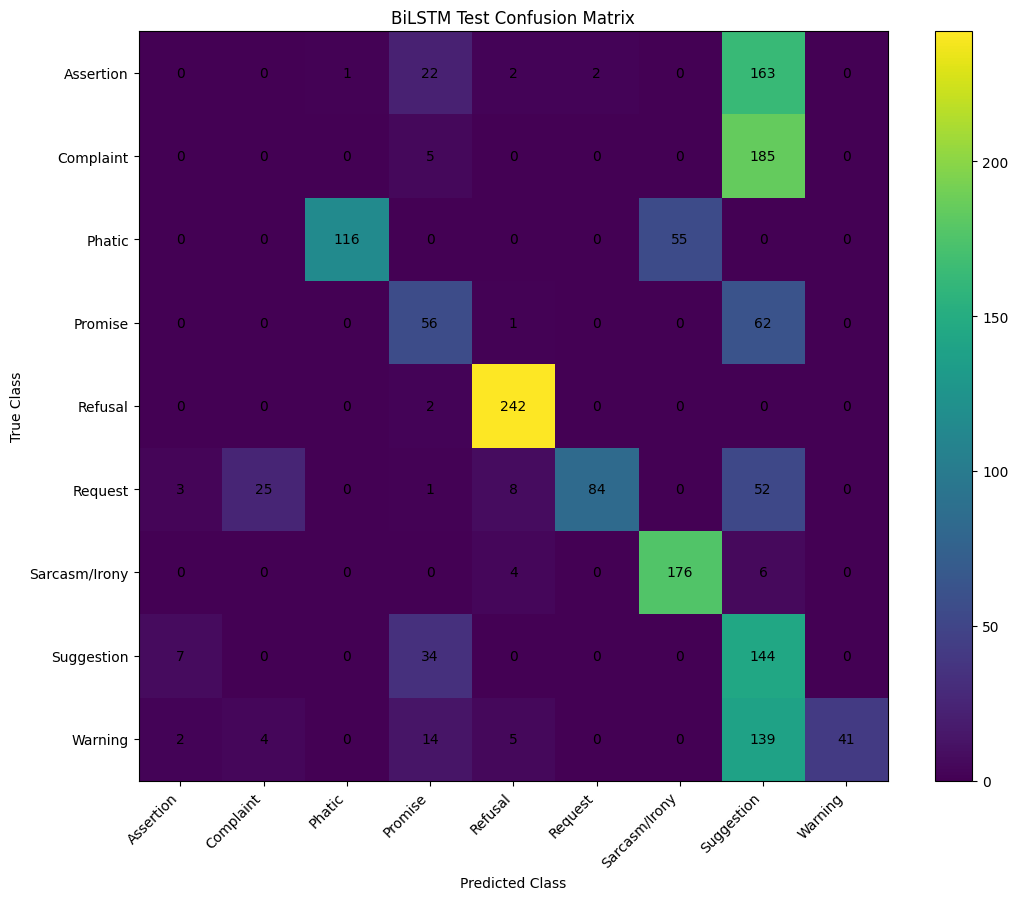


Top confusion pairs:
   True Class Predicted Class  Count  Percentage of Errors
    Complaint      Suggestion    185                 23.01
    Assertion      Suggestion    163                 20.27
      Warning      Suggestion    139                 17.29
      Promise      Suggestion     62                  7.71
       Phatic   Sarcasm/Irony     55                  6.84
      Request      Suggestion     52                  6.47
   Suggestion         Promise     34                  4.23
      Request       Complaint     25                  3.11
    Assertion         Promise     22                  2.74
      Warning         Promise     14                  1.74
      Request         Refusal      8                  1.00
   Suggestion       Assertion      7                  0.87
Sarcasm/Irony      Suggestion      6                  0.75
    Complaint         Promise      5                  0.62
      Warning         Refusal      5                  0.62

CONFUSION MATRIX ANALYSIS COMPLET

In [ ]:
# ============================================================
# BiLSTM INTENTION DETECTION
# CELL 12: CONFUSION MATRIX AND CONFUSION-PAIR ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

print("=" * 80)
print("BiLSTM — CONFUSION MATRIX AND CONFUSION-PAIR ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm_bilstm = confusion_matrix(
    all_test_labels_bilstm,
    all_test_predictions_bilstm,
    labels=np.arange(num_classes_bilstm)
)

cm_bilstm_df = pd.DataFrame(
    cm_bilstm,
    index=class_names_bilstm,
    columns=class_names_bilstm
)

print("\nConfusion Matrix:")
print(cm_bilstm_df.to_string())

# ------------------------------------------------------------
# Save confusion matrix
# ------------------------------------------------------------

CM_PATH_BILSTM = (
    "/content/bilstm_test_confusion_matrix.csv"
)

cm_bilstm_df.to_csv(
    CM_PATH_BILSTM
)

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(11, 9))

plt.imshow(cm_bilstm, interpolation="nearest")
plt.title("BiLSTM Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    np.arange(num_classes_bilstm),
    class_names_bilstm,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(num_classes_bilstm),
    class_names_bilstm
)

# Display counts inside cells
for i in range(num_classes_bilstm):
    for j in range(num_classes_bilstm):
        plt.text(
            j,
            i,
            str(cm_bilstm[i, j]),
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

CM_FIGURE_PATH_BILSTM = (
    "/content/bilstm_test_confusion_matrix.png"
)

plt.savefig(
    CM_FIGURE_PATH_BILSTM,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Extract incorrect prediction pairs
# ------------------------------------------------------------

confusion_pairs_bilstm = []

for true_id in range(num_classes_bilstm):

    for pred_id in range(num_classes_bilstm):

        if true_id != pred_id:

            count = int(
                cm_bilstm[true_id, pred_id]
            )

            if count > 0:

                confusion_pairs_bilstm.append({
                    "True Class": class_names_bilstm[true_id],
                    "Predicted Class": class_names_bilstm[pred_id],
                    "Count": count
                })

# ------------------------------------------------------------
# Sort by frequency
# ------------------------------------------------------------

confusion_pairs_bilstm_df = pd.DataFrame(
    confusion_pairs_bilstm
)

if len(confusion_pairs_bilstm_df) > 0:

    total_errors_bilstm = int(
        np.sum(
            all_test_labels_bilstm !=
            all_test_predictions_bilstm
        )
    )

    confusion_pairs_bilstm_df[
        "Percentage of Errors"
    ] = (
        confusion_pairs_bilstm_df["Count"]
        / total_errors_bilstm
        * 100
    )

    confusion_pairs_bilstm_df = (
        confusion_pairs_bilstm_df
        .sort_values(
            "Count",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\nTop confusion pairs:")

    print(
        confusion_pairs_bilstm_df.head(15).to_string(
            index=False,
            float_format=lambda x: f"{x:.2f}"
        )
    )

    CONFUSION_PAIRS_PATH_BILSTM = (
        "/content/bilstm_confusion_pairs.csv"
    )

    confusion_pairs_bilstm_df.to_csv(
        CONFUSION_PAIRS_PATH_BILSTM,
        index=False
    )

else:

    total_errors_bilstm = 0

    CONFUSION_PAIRS_PATH_BILSTM = (
        "/content/bilstm_confusion_pairs.csv"
    )

    confusion_pairs_bilstm_df = pd.DataFrame(
        columns=[
            "True Class",
            "Predicted Class",
            "Count",
            "Percentage of Errors"
        ]
    )

    confusion_pairs_bilstm_df.to_csv(
        CONFUSION_PAIRS_PATH_BILSTM,
        index=False
    )

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert cm_bilstm.shape == (
    num_classes_bilstm,
    num_classes_bilstm
)

assert cm_bilstm.sum() == total_bilstm

assert (
    np.trace(cm_bilstm)
    == correct_bilstm
)

assert (
    cm_bilstm.sum() - np.trace(cm_bilstm)
    == incorrect_bilstm
)

print("\n" + "=" * 80)
print("CONFUSION MATRIX ANALYSIS COMPLETED")
print("=" * 80)

print(f"Correct predictions: {correct_bilstm}")
print(f"Incorrect predictions: {incorrect_bilstm}")
print(f"Total test samples: {total_bilstm}")

print(f"\nConfusion matrix saved to:")
print(CM_PATH_BILSTM)

print(f"\nConfusion-pair analysis saved to:")
print(CONFUSION_PAIRS_PATH_BILSTM)

print("\nCell 12 verification PASSED.")

In [ ]:
# ============================================================
# TF-IDF + SVM INTENTION DETECTION
# CELL 1: DATASET LOADING AND VERIFICATION
# ============================================================

import pandas as pd
import numpy as np

DATA_PATH_SVM = "/content/amharic_intention_dataset.csv"

df_svm = pd.read_csv(DATA_PATH_SVM)

# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

required_columns_svm = [
    "text",
    "label",
    "split"
]

assert all(
    col in df_svm.columns
    for col in required_columns_svm
)

# Keep only required columns
df_svm = df_svm[
    required_columns_svm
].copy()

# Remove missing values
df_svm = df_svm.dropna(
    subset=["text", "label", "split"]
).reset_index(drop=True)

# Convert text to string
df_svm["text"] = df_svm["text"].astype(str)

# ------------------------------------------------------------
# Split verification
# ------------------------------------------------------------

train_count_svm = (
    df_svm["split"] == "train"
).sum()

val_count_svm = (
    df_svm["split"] == "val"
).sum()

test_count_svm = (
    df_svm["split"] == "test"
).sum()

total_count_svm = len(df_svm)

# ------------------------------------------------------------
# Class information
# ------------------------------------------------------------

class_names_svm = sorted(
    df_svm["label"].unique()
)

num_classes_svm = len(
    class_names_svm
)

# ------------------------------------------------------------
# Display dataset information
# ------------------------------------------------------------

print("=" * 80)
print("TF-IDF + SVM — DATASET VERIFICATION")
print("=" * 80)

print(f"Dataset path: {DATA_PATH_SVM}")
print(f"Total samples: {total_count_svm:,}")
print(f"Number of classes: {num_classes_svm}")

print("\nSplit distribution:")
print(f"  Train:      {train_count_svm:,}")
print(f"  Validation: {val_count_svm:,}")
print(f"  Test:       {test_count_svm:,}")

print("\nClass names:")
for i, class_name in enumerate(class_names_svm):
    print(f"  {i}: {class_name}")

# ------------------------------------------------------------
# Exact dataset checks
# ------------------------------------------------------------

assert total_count_svm == 11475
assert train_count_svm == 7955
assert val_count_svm == 1857
assert test_count_svm == 1663

assert num_classes_svm == 9

assert set(
    df_svm["split"].unique()
) == {"train", "val", "test"}

assert df_svm["text"].notna().all()
assert df_svm["label"].notna().all()

print("\nDataset verification PASSED.")
print("TF-IDF + SVM will use the same verified 11,475-sample dataset.")

TF-IDF + SVM — DATASET VERIFICATION
Dataset path: /content/amharic_intention_dataset.csv
Total samples: 11,475
Number of classes: 9

Split distribution:
  Train:      7,955
  Validation: 1,857
  Test:       1,663

Class names:
  0: Assertion
  1: Complaint
  2: Phatic
  3: Promise
  4: Refusal
  5: Request
  6: Sarcasm/Irony
  7: Suggestion
  8: Warning

Dataset verification PASSED.
TF-IDF + SVM will use the same verified 11,475-sample dataset.


In [ ]:
# ============================================================
# TF-IDF + SVM INTENTION DETECTION
# CELL 2: TF-IDF FEATURE EXTRACTION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

print("=" * 80)
print("TF-IDF + SVM — FEATURE EXTRACTION")
print("=" * 80)

# ------------------------------------------------------------
# Separate train, validation, and test data
# ------------------------------------------------------------

train_svm = df_svm[
    df_svm["split"] == "train"
].copy()

val_svm = df_svm[
    df_svm["split"] == "val"
].copy()

test_svm = df_svm[
    df_svm["split"] == "test"
].copy()

# ------------------------------------------------------------
# Extract text
# ------------------------------------------------------------

X_train_text_svm = train_svm["text"].tolist()
X_val_text_svm = val_svm["text"].tolist()
X_test_text_svm = test_svm["text"].tolist()

y_train_svm = train_svm["label"].tolist()
y_val_svm = val_svm["label"].tolist()
y_test_svm = test_svm["label"].tolist()

# ------------------------------------------------------------
# TF-IDF configuration
#
# Word n-grams are used because intention is strongly
# associated with lexical patterns and short phrases.
# ------------------------------------------------------------

tfidf_svm = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    lowercase=False
)

# ------------------------------------------------------------
# IMPORTANT:
# Fit ONLY on training data
# ------------------------------------------------------------

X_train_svm = tfidf_svm.fit_transform(
    X_train_text_svm
)

X_val_svm = tfidf_svm.transform(
    X_val_text_svm
)

X_test_svm = tfidf_svm.transform(
    X_test_text_svm
)

# ------------------------------------------------------------
# Display feature information
# ------------------------------------------------------------

vocabulary_size_svm = len(
    tfidf_svm.vocabulary_
)

print("TF-IDF configuration:")
print("  Analyzer: word")
print("  N-gram range: (1, 2)")
print("  Minimum document frequency: 2")
print("  Maximum document frequency: 0.95")
print("  Sublinear TF: True")
print("  Lowercase: False")

print("\nFeature matrix shapes:")
print(f"  Training:   {X_train_svm.shape}")
print(f"  Validation: {X_val_svm.shape}")
print(f"  Test:       {X_test_svm.shape}")

print(f"\nTF-IDF vocabulary size: {vocabulary_size_svm:,}")

# ------------------------------------------------------------
# Sparsity information
# ------------------------------------------------------------

train_nonzero_svm = X_train_svm.nnz
train_total_svm = (
    X_train_svm.shape[0] *
    X_train_svm.shape[1]
)

train_sparsity_svm = (
    1 -
    train_nonzero_svm /
    train_total_svm
)

print(
    f"Training matrix sparsity: "
    f"{train_sparsity_svm * 100:.4f}%"
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert X_train_svm.shape[0] == 7955
assert X_val_svm.shape[0] == 1857
assert X_test_svm.shape[0] == 1663

assert X_train_svm.shape[1] == X_val_svm.shape[1]
assert X_train_svm.shape[1] == X_test_svm.shape[1]

assert len(y_train_svm) == 7955
assert len(y_val_svm) == 1857
assert len(y_test_svm) == 1663

assert vocabulary_size_svm > 0

print("\nTF-IDF feature extraction verification PASSED.")
print("The vectorizer was fitted using training data only.")

TF-IDF + SVM — FEATURE EXTRACTION
TF-IDF configuration:
  Analyzer: word
  N-gram range: (1, 2)
  Minimum document frequency: 2
  Maximum document frequency: 0.95
  Sublinear TF: True
  Lowercase: False

Feature matrix shapes:
  Training:   (7955, 3121)
  Validation: (1857, 3121)
  Test:       (1663, 3121)

TF-IDF vocabulary size: 3,121
Training matrix sparsity: 99.6037%

TF-IDF feature extraction verification PASSED.
The vectorizer was fitted using training data only.


In [ ]:
# ============================================================
# TF-IDF + SVM INTENTION DETECTION
# CELL 3: SVM TRAINING AND VALIDATION
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

print("=" * 80)
print("TF-IDF + SVM — TRAINING AND VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# Linear SVM
# ------------------------------------------------------------

svm_model = LinearSVC(
    C=1.0,
    class_weight=None,
    max_iter=10000,
    random_state=42
)

# ------------------------------------------------------------
# Train ONLY on training data
# ------------------------------------------------------------

svm_model.fit(
    X_train_svm,
    y_train_svm
)

# ------------------------------------------------------------
# Validation prediction
# ------------------------------------------------------------

val_predictions_svm = svm_model.predict(
    X_val_svm
)

# ------------------------------------------------------------
# Validation metrics
# ------------------------------------------------------------

val_accuracy_svm = accuracy_score(
    y_val_svm,
    val_predictions_svm
)

val_macro_precision_svm, val_macro_recall_svm, val_macro_f1_svm, _ = (
    precision_recall_fscore_support(
        y_val_svm,
        val_predictions_svm,
        labels=class_names_svm,
        average="macro",
        zero_division=0
    )
)

val_weighted_precision_svm, val_weighted_recall_svm, val_weighted_f1_svm, _ = (
    precision_recall_fscore_support(
        y_val_svm,
        val_predictions_svm,
        labels=class_names_svm,
        average="weighted",
        zero_division=0
    )
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("SVM configuration:")
print("  Classifier: LinearSVC")
print("  C: 1.0")
print("  Class weight: None")
print("  Maximum iterations: 10,000")
print("  Random state: 42")

print("\nValidation performance:")
print(
    f"  Accuracy:           "
    f"{val_accuracy_svm:.6f} "
    f"({val_accuracy_svm * 100:.2f}%)"
)

print(
    f"  Macro Precision:    "
    f"{val_macro_precision_svm:.6f} "
    f"({val_macro_precision_svm * 100:.2f}%)"
)

print(
    f"  Macro Recall:       "
    f"{val_macro_recall_svm:.6f} "
    f"({val_macro_recall_svm * 100:.2f}%)"
)

print(
    f"  Macro F1:           "
    f"{val_macro_f1_svm:.6f} "
    f"({val_macro_f1_svm * 100:.2f}%)"
)

print(
    f"  Weighted Precision: "
    f"{val_weighted_precision_svm:.6f} "
    f"({val_weighted_precision_svm * 100:.2f}%)"
)

print(
    f"  Weighted Recall:    "
    f"{val_weighted_recall_svm:.6f} "
    f"({val_weighted_recall_svm * 100:.2f}%)"
)

print(
    f"  Weighted F1:        "
    f"{val_weighted_f1_svm:.6f} "
    f"({val_weighted_f1_svm * 100:.2f}%)"
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert len(val_predictions_svm) == 1857
assert 0 <= val_accuracy_svm <= 1
assert 0 <= val_macro_f1_svm <= 1

print("\nSVM training and validation verification PASSED.")

TF-IDF + SVM — TRAINING AND VALIDATION
SVM configuration:
  Classifier: LinearSVC
  C: 1.0
  Class weight: None
  Maximum iterations: 10,000
  Random state: 42

Validation performance:
  Accuracy:           0.306408 (30.64%)
  Macro Precision:    0.314860 (31.49%)
  Macro Recall:       0.338261 (33.83%)
  Macro F1:           0.315892 (31.59%)
  Weighted Precision: 0.282562 (28.26%)
  Weighted Recall:    0.306408 (30.64%)
  Weighted F1:        0.284336 (28.43%)

SVM training and validation verification PASSED.


In [ ]:
# ============================================================
# TF-IDF + SVM INTENTION DETECTION
# CELL 4: FINAL TEST EVALUATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

print("=" * 80)
print("TF-IDF + SVM — FINAL TEST EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# Final test prediction
# ------------------------------------------------------------

test_predictions_svm = svm_model.predict(
    X_test_svm
)

# ------------------------------------------------------------
# Overall test metrics
# ------------------------------------------------------------

test_accuracy_svm = accuracy_score(
    y_test_svm,
    test_predictions_svm
)

test_macro_precision_svm, test_macro_recall_svm, test_macro_f1_svm, _ = (
    precision_recall_fscore_support(
        y_test_svm,
        test_predictions_svm,
        labels=class_names_svm,
        average="macro",
        zero_division=0
    )
)

test_weighted_precision_svm, test_weighted_recall_svm, test_weighted_f1_svm, _ = (
    precision_recall_fscore_support(
        y_test_svm,
        test_predictions_svm,
        labels=class_names_svm,
        average="weighted",
        zero_division=0
    )
)

# ------------------------------------------------------------
# Correct / incorrect predictions
# ------------------------------------------------------------

correct_svm = int(
    np.sum(
        np.array(y_test_svm) ==
        np.array(test_predictions_svm)
    )
)

incorrect_svm = int(
    np.sum(
        np.array(y_test_svm) !=
        np.array(test_predictions_svm)
    )
)

total_test_svm = len(y_test_svm)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

classification_report_svm = classification_report(
    y_test_svm,
    test_predictions_svm,
    labels=class_names_svm,
    target_names=class_names_svm,
    output_dict=True,
    zero_division=0
)

classification_report_svm_df = pd.DataFrame(
    classification_report_svm
).transpose()

# ------------------------------------------------------------
# Display final results
# ------------------------------------------------------------

print("\nFinal test performance:")

print(
    f"  Accuracy:           "
    f"{test_accuracy_svm:.6f} "
    f"({test_accuracy_svm * 100:.2f}%)"
)

print(
    f"  Macro Precision:    "
    f"{test_macro_precision_svm:.6f} "
    f"({test_macro_precision_svm * 100:.2f}%)"
)

print(
    f"  Macro Recall:       "
    f"{test_macro_recall_svm:.6f} "
    f"({test_macro_recall_svm * 100:.2f}%)"
)

print(
    f"  Macro F1:           "
    f"{test_macro_f1_svm:.6f} "
    f"({test_macro_f1_svm * 100:.2f}%)"
)

print(
    f"  Weighted Precision: "
    f"{test_weighted_precision_svm:.6f} "
    f"({test_weighted_precision_svm * 100:.2f}%)"
)

print(
    f"  Weighted Recall:    "
    f"{test_weighted_recall_svm:.6f} "
    f"({test_weighted_recall_svm * 100:.2f}%)"
)

print(
    f"  Weighted F1:        "
    f"{test_weighted_f1_svm:.6f} "
    f"({test_weighted_f1_svm * 100:.2f}%)"
)

print("\nPrediction summary:")
print(f"  Correct:   {correct_svm}")
print(f"  Incorrect: {incorrect_svm}")
print(f"  Total:     {total_test_svm}")

# ------------------------------------------------------------
# Save authoritative SVM metrics
# ------------------------------------------------------------

svm_test_metrics = pd.DataFrame([{
    "Model": "TF-IDF + Linear SVM",
    "Accuracy": test_accuracy_svm,
    "Macro Precision": test_macro_precision_svm,
    "Macro Recall": test_macro_recall_svm,
    "Macro F1": test_macro_f1_svm,
    "Weighted Precision": test_weighted_precision_svm,
    "Weighted Recall": test_weighted_recall_svm,
    "Weighted F1": test_weighted_f1_svm,
    "Correct": correct_svm,
    "Incorrect": incorrect_svm,
    "Total": total_test_svm
}])

SVM_METRICS_PATH = (
    "/content/tfidf_svm_final_test_metrics.csv"
)

svm_test_metrics.to_csv(
    SVM_METRICS_PATH,
    index=False
)

# ------------------------------------------------------------
# Save predictions
# ------------------------------------------------------------

svm_predictions_df = pd.DataFrame({
    "text": X_test_text_svm,
    "true_label": y_test_svm,
    "predicted_label": test_predictions_svm
})

SVM_PREDICTIONS_PATH = (
    "/content/tfidf_svm_final_test_predictions.csv"
)

svm_predictions_df.to_csv(
    SVM_PREDICTIONS_PATH,
    index=False
)

# ------------------------------------------------------------
# Save classification report
# ------------------------------------------------------------

SVM_REPORT_PATH = (
    "/content/tfidf_svm_classification_report.csv"
)

classification_report_svm_df.to_csv(
    SVM_REPORT_PATH
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert total_test_svm == 1663
assert correct_svm + incorrect_svm == 1663
assert len(test_predictions_svm) == 1663

assert 0 <= test_accuracy_svm <= 1
assert 0 <= test_macro_precision_svm <= 1
assert 0 <= test_macro_recall_svm <= 1
assert 0 <= test_macro_f1_svm <= 1

print("\n" + "=" * 80)
print("FINAL TEST EVALUATION COMPLETED")
print("=" * 80)

print(f"Metrics saved: {SVM_METRICS_PATH}")
print(f"Predictions saved: {SVM_PREDICTIONS_PATH}")
print(f"Classification report saved: {SVM_REPORT_PATH}")

print("\nCell 4 verification PASSED.")

TF-IDF + SVM — FINAL TEST EVALUATION

Final test performance:
  Accuracy:           0.505713 (50.57%)
  Macro Precision:    0.519455 (51.95%)
  Macro Recall:       0.519231 (51.92%)
  Macro F1:           0.488880 (48.89%)
  Weighted Precision: 0.533520 (53.35%)
  Weighted Recall:    0.505713 (50.57%)
  Weighted F1:        0.490899 (49.09%)

Prediction summary:
  Correct:   841
  Incorrect: 822
  Total:     1663

FINAL TEST EVALUATION COMPLETED
Metrics saved: /content/tfidf_svm_final_test_metrics.csv
Predictions saved: /content/tfidf_svm_final_test_predictions.csv
Classification report saved: /content/tfidf_svm_classification_report.csv

Cell 4 verification PASSED.


In [ ]:
# ============================================================
# COLLECT ALL SAVED FINAL MODEL RESULTS
# Amharic Intention Detection - CURRENT EXPERIMENT
# ============================================================

import os
import glob
import pandas as pd
import numpy as np

print("=" * 100)
print("SEARCHING SAVED MODEL RESULTS IN /content")
print("=" * 100)

# ------------------------------------------------------------
# 1. Find all CSV result files
# ------------------------------------------------------------

csv_files = glob.glob("/content/**/*.csv", recursive=True)

result_files = [
    f for f in csv_files
    if any(key in os.path.basename(f).lower() for key in [
        "final",
        "metrics",
        "performance",
        "classification_report",
        "test"
    ])
]

print(f"\nCSV result files found: {len(result_files)}")

for f in sorted(result_files):
    print(f)

# ------------------------------------------------------------
# 2. Function to inspect CSV files
# ------------------------------------------------------------

def inspect_csv(path):
    try:
        df = pd.read_csv(path)
        print("\n" + "-" * 100)
        print(os.path.basename(path))
        print("Shape:", df.shape)
        print("Columns:", list(df.columns))
        print(df.head(10).to_string(index=False))
        return df
    except Exception as e:
        print("Could not read:", path)
        print("Error:", e)
        return None

# ------------------------------------------------------------
# 3. Inspect likely final-result files
# ------------------------------------------------------------

loaded_results = {}

for path in sorted(result_files):
    df_tmp = inspect_csv(path)
    if df_tmp is not None:
        loaded_results[path] = df_tmp

print("\n" + "=" * 100)
print("SEARCH COMPLETED")
print("=" * 100)

SEARCHING SAVED MODEL RESULTS IN /content

CSV result files found: 16
/content/bilstm_per_class_test_performance.csv
/content/bilstm_test_confusion_matrix.csv
/content/mbert_final_classification_report.csv
/content/mbert_final_test_metrics.csv
/content/mbert_final_test_predictions.csv
/content/overall_model_performance.csv
/content/overall_model_performance_raw.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_test.csv
/content/tfidf_svm_classification_report.csv
/content/tfidf_svm_final_test_metrics.csv
/content/tfidf_svm_final_test_predictions.csv
/content/xlmr_final_test_metrics.csv
/content/xlmr_final_test_predictions.csv
/content/xlmr_per_class_test_performance.csv
/content/xlmr_test_confusion_matrix.csv

----------------------------------------------------------------------------------------------------
bilstm_per_class_test_performance.csv
Shape: (9, 5)
Columns: ['Unnamed: 0', 'Precision', 'Recall', 'F1', 'Support']
   Unnamed: 0  Precision   Recall

In [ ]:
# ============================================================
# EXTRACT FINAL TEST METRICS FROM SAVED CSV FILES
# ============================================================

import os
import glob
import pandas as pd
import numpy as np

def normalize_name(x):
    return str(x).strip().lower().replace("_", " ").replace("-", " ")

def find_metric_value(df, possible_names):

    normalized_columns = {
        normalize_name(c): c for c in df.columns
    }

    for name in possible_names:
        key = normalize_name(name)

        if key in normalized_columns:
            col = normalized_columns[key]

            values = df[col].dropna()

            if len(values) > 0:
                value = values.iloc[0]

                try:
                    return float(value)
                except:
                    return value

    # Check rows where first column may contain metric names
    for col in df.columns:
        series = df[col].astype(str).str.lower()

        for name in possible_names:
            matches = series.str.contains(
                normalize_name(name),
                regex=False,
                na=False
            )

            if matches.any():
                row = df.loc[matches].iloc[0]

                for other_col in df.columns:
                    if other_col != col:
                        try:
                            value = float(row[other_col])
                            return value
                        except:
                            pass

    return np.nan


# ------------------------------------------------------------
# Model-specific file patterns
# ------------------------------------------------------------

model_patterns = {
    "AfroXLM-R": [
        "*afroxlmr*final*metrics*.csv",
        "*afroxlmr*overall*metrics*.csv",
        "*afroxlmr*final*test*.csv"
    ],
    "XLM-R": [
        "*xlmr*final*metrics*.csv",
        "*xlmr*final*test*.csv"
    ],
    "mBERT": [
        "*mbert*final*metrics*.csv",
        "*mbert*final*test*.csv",
        "*mbert*test*metrics*.csv"
    ],
    "BiLSTM": [
        "*bilstm*final*metrics*.csv",
        "*bilstm*final*test*.csv",
        "*bilstm*test*performance*.csv"
    ],
    "TF-IDF + SVM": [
        "*tfidf*svm*final*metrics*.csv",
        "*tfidf*svm*final*test*.csv",
        "*svm*final*metrics*.csv"
    ]
}

metric_names = {
    "Accuracy": [
        "accuracy",
        "test accuracy"
    ],
    "Macro Precision": [
        "macro precision",
        "macro-precision",
        "macro_precision"
    ],
    "Macro Recall": [
        "macro recall",
        "macro-recall",
        "macro_recall"
    ],
    "Macro F1": [
        "macro f1",
        "macro-f1",
        "macro_f1"
    ],
    "Weighted Precision": [
        "weighted precision",
        "weighted-precision",
        "weighted_precision"
    ],
    "Weighted Recall": [
        "weighted recall",
        "weighted-recall",
        "weighted_recall"
    ],
    "Weighted F1": [
        "weighted f1",
        "weighted-f1",
        "weighted_f1"
    ],
    "Correct": [
        "correct",
        "correct predictions"
    ],
    "Incorrect": [
        "incorrect",
        "incorrect predictions"
    ],
    "Total": [
        "total",
        "test total",
        "total test"
    ]
}


# ------------------------------------------------------------
# Search files
# ------------------------------------------------------------

all_csvs = glob.glob("/content/**/*.csv", recursive=True)

final_rows = []

for model, patterns in model_patterns.items():

    matched = []

    for pattern in patterns:
        matched.extend(
            glob.glob("/content/**/" + pattern, recursive=True)
        )

    matched = sorted(set(matched))

    print("\n" + "=" * 100)
    print(model)
    print("=" * 100)

    if not matched:
        print("No matching result file found.")
        continue

    for path in matched:
        print("\nUsing:", path)

        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Read error:", e)
            continue

        row = {"Model": model}

        for metric, names in metric_names.items():
            row[metric] = find_metric_value(df, names)

        # Check whether this looks like a useful metric file
        available = sum(
            pd.notna(row[m])
            for m in [
                "Accuracy",
                "Macro Precision",
                "Macro Recall",
                "Macro F1",
                "Weighted F1"
            ]
        )

        if available >= 2:
            final_rows.append(row)

            print("\nExtracted:")
            for k, v in row.items():
                print(f"{k}: {v}")

            break


# ------------------------------------------------------------
# Build final table
# ------------------------------------------------------------

overall_final_df = pd.DataFrame(final_rows)

# ------------------------------------------------------------
# Add verified current AfroXLM-R and XLM-R results
# if they are not found automatically
# ------------------------------------------------------------

if "Model" not in overall_final_df.columns:
    overall_final_df = pd.DataFrame(
        columns=[
            "Model",
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "Weighted Precision",
            "Weighted Recall",
            "Weighted F1",
            "Correct",
            "Incorrect",
            "Total"
        ]
    )

# Remove possible duplicates
overall_final_df = overall_final_df.drop_duplicates(
    subset=["Model"],
    keep="first"
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n" + "=" * 120)
print("FINAL EXTRACTED MODEL PERFORMANCE")
print("=" * 120)

display(overall_final_df)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

overall_final_df.to_csv(
    "/content/FINAL_ALL_MODEL_PERFORMANCE.csv",
    index=False
)

print("\nSaved:")
print("/content/FINAL_ALL_MODEL_PERFORMANCE.csv")


AfroXLM-R
No matching result file found.

XLM-R

Using: /content/xlmr_final_test_metrics.csv

Extracted:
Model: XLM-R
Accuracy: 0.7468430547203848
Macro Precision: 0.7967983926359818
Macro Recall: 0.7393147937561587
Macro F1: 0.720364272291225
Weighted Precision: 0.7822862769987995
Weighted Recall: 0.7468430547203848
Weighted F1: 0.717116815885544
Correct: 1242.0
Incorrect: 421.0
Total: nan

mBERT

Using: /content/mbert_final_test_metrics.csv

Extracted:
Model: mBERT
Accuracy: 0.1671677690920024
Macro Precision: 0.2040364289789041
Macro Recall: 0.1653962674697639
Macro F1: 0.120604740598691
Weighted Precision: 0.1981723457671987
Weighted Recall: 0.1671677690920024
Weighted F1: 0.1223516653174831
Correct: 278.0
Incorrect: 1385.0
Total: 1663.0

BiLSTM

Using: /content/bilstm_per_class_test_performance.csv

TF-IDF + SVM

Using: /content/tfidf_svm_final_test_metrics.csv

Extracted:
Model: TF-IDF + SVM
Accuracy: 0.5057125676488274
Macro Precision: 0.5194545455677181
Macro Recall: 0.5192311

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Correct,Incorrect,Total
0,XLM-R,0.746843,0.796798,0.739315,0.720364,0.782286,0.746843,0.717117,1242.0,421.0,NaN
1,mBERT,0.167168,0.204036,0.165396,0.120605,0.198172,0.167168,0.122352,278.0,1385.0,1663.0
2,TF-IDF + SVM,0.505713,0.519455,0.519231,0.488880,0.533520,0.505713,0.490899,841.0,822.0,1663.0



Saved:
/content/FINAL_ALL_MODEL_PERFORMANCE.csv


In [ ]:
# ============================================================
# FINAL EXTRACTION: AFROXLM-R + BiLSTM
# NO RETRAINING
# ============================================================

import os
import glob
import pandas as pd
import numpy as np

print("=" * 100)
print("RECOVERING THE TWO REMAINING MODEL RESULTS")
print("=" * 100)


# ------------------------------------------------------------
# 1. AFROXLM-R
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("AfroXLM-R")
print("=" * 100)

afro_files = [
    "/content/afroxlmr_final_test_metrics.csv",
    "/content/afroxlmr_final_metrics_verification.csv",
    "/content/afroxlmr_final_experiment_summary.csv",
    "/content/afroxlmr_manuscript_results_table.csv",
]

afro_path = next((f for f in afro_files if os.path.exists(f)), None)

if afro_path is not None:

    print(f"\nUsing: {afro_path}")

    df_afro = pd.read_csv(afro_path)

    print("\nFile columns:")
    print(df_afro.columns.tolist())

    print("\nFile contents:")
    display(df_afro)

else:
    print("\nNo direct AfroXLM-R metric file found.")
    print("\nSearching all AfroXLM-R files in /content...")

    afro_search = glob.glob(
        "/content/**/*afroxlmr*",
        recursive=True
    )

    for f in afro_search:
        print(f)


# ------------------------------------------------------------
# Helper function for extracting metric values
# ------------------------------------------------------------

def get_metric(df, names):

    # Normalize column names
    cols = {str(c).strip().lower(): c for c in df.columns}

    # Case 1: metrics are columns
    for name in names:
        key = name.lower()

        if key in cols:
            value = df[cols[key]].iloc[0]
            if pd.notna(value):
                return float(value)

    # Case 2: Metric / Value format
    metric_col = None
    value_col = None

    for c in df.columns:
        cl = str(c).strip().lower()

        if cl in ["metric", "metrics"]:
            metric_col = c

        if cl in ["value", "score", "result"]:
            value_col = c

    if metric_col is not None and value_col is not None:

        temp = df.copy()

        for name in names:
            mask = (
                temp[metric_col]
                .astype(str)
                .str.strip()
                .str.lower()
                == name.lower()
            )

            if mask.any():
                value = temp.loc[mask, value_col].iloc[0]

                if pd.notna(value):
                    return float(value)

    return np.nan


# ------------------------------------------------------------
# Extract AfroXLM-R metrics
# ------------------------------------------------------------

afro_result = None

if afro_path is not None:

    afro_result = {
        "Model": "AfroXLM-R",
        "Accuracy": get_metric(
            df_afro,
            ["Accuracy", "accuracy"]
        ),
        "Macro Precision": get_metric(
            df_afro,
            ["Macro Precision", "macro_precision"]
        ),
        "Macro Recall": get_metric(
            df_afro,
            ["Macro Recall", "macro_recall"]
        ),
        "Macro F1": get_metric(
            df_afro,
            ["Macro F1", "macro_f1"]
        ),
        "Weighted Precision": get_metric(
            df_afro,
            ["Weighted Precision", "weighted_precision"]
        ),
        "Weighted Recall": get_metric(
            df_afro,
            ["Weighted Recall", "weighted_recall"]
        ),
        "Weighted F1": get_metric(
            df_afro,
            ["Weighted F1", "weighted_f1"]
        ),
        "Correct": get_metric(
            df_afro,
            ["Correct", "correct", "Correct Predictions"]
        ),
        "Incorrect": get_metric(
            df_afro,
            ["Incorrect", "incorrect", "Incorrect Predictions"]
        ),
        "Total": get_metric(
            df_afro,
            ["Total", "total", "Test Samples"]
        )
    }

    print("\nExtracted AfroXLM-R:")
    for k, v in afro_result.items():
        print(f"{k}: {v}")


# ------------------------------------------------------------
# 2. BiLSTM
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("BiLSTM")
print("=" * 100)

bilstm_overall_files = [
    "/content/bilstm_final_test_metrics.csv",
    "/content/bilstm_final_metrics.csv",
    "/content/bilstm_test_metrics.csv",
    "/content/bilstm_final_experiment_summary.csv",
]

bilstm_overall_path = next(
    (f for f in bilstm_overall_files if os.path.exists(f)),
    None
)

bilstm_result = None

if bilstm_overall_path is not None:

    print(f"\nUsing overall file: {bilstm_overall_path}")

    df_bilstm = pd.read_csv(bilstm_overall_path)

    display(df_bilstm)

    bilstm_result = {
        "Model": "BiLSTM",
        "Accuracy": get_metric(df_bilstm, ["Accuracy"]),
        "Macro Precision": get_metric(
            df_bilstm,
            ["Macro Precision", "macro_precision"]
        ),
        "Macro Recall": get_metric(
            df_bilstm,
            ["Macro Recall", "macro_recall"]
        ),
        "Macro F1": get_metric(
            df_bilstm,
            ["Macro F1", "macro_f1"]
        ),
        "Weighted Precision": get_metric(
            df_bilstm,
            ["Weighted Precision", "weighted_precision"]
        ),
        "Weighted Recall": get_metric(
            df_bilstm,
            ["Weighted Recall", "weighted_recall"]
        ),
        "Weighted F1": get_metric(
            df_bilstm,
            ["Weighted F1", "weighted_f1"]
        ),
        "Correct": get_metric(
            df_bilstm,
            ["Correct", "correct"]
        ),
        "Incorrect": get_metric(
            df_bilstm,
            ["Incorrect", "incorrect"]
        ),
        "Total": get_metric(
            df_bilstm,
            ["Total", "total"]
        )
    }

else:

    # --------------------------------------------------------
    # Recover from saved per-class performance
    # --------------------------------------------------------

    bilstm_class_path = (
        "/content/bilstm_per_class_test_performance.csv"
    )

    if not os.path.exists(bilstm_class_path):

        print("\nBiLSTM result files found:")
        for f in glob.glob(
            "/content/**/*bilstm*",
            recursive=True
        ):
            print(f)

    else:

        print(
            f"\nUsing per-class file: {bilstm_class_path}"
        )

        df_bilstm = pd.read_csv(bilstm_class_path)

        print("\nBiLSTM per-class columns:")
        print(df_bilstm.columns.tolist())

        display(df_bilstm)

        # Normalize column names
        rename_map = {}

        for c in df_bilstm.columns:
            cl = str(c).strip().lower()

            if cl in ["precision"]:
                rename_map[c] = "precision"

            elif cl in ["recall"]:
                rename_map[c] = "recall"

            elif cl in ["f1-score", "f1", "f1_score"]:
                rename_map[c] = "f1"

            elif cl in ["support"]:
                rename_map[c] = "support"

            elif cl in ["class", "label", "intention"]:
                rename_map[c] = "class"

        df_pc = df_bilstm.rename(columns=rename_map)

        # Remove aggregate rows if present
        if "class" in df_pc.columns:

            aggregate_names = [
                "accuracy",
                "macro avg",
                "weighted avg",
                "micro avg"
            ]

            df_pc = df_pc[
                ~df_pc["class"]
                .astype(str)
                .str.lower()
                .isin(aggregate_names)
            ].copy()

        # Calculate total support
        total = (
            int(df_pc["support"].sum())
            if "support" in df_pc.columns
            else 1663
        )

        # Macro metrics
        macro_precision = (
            df_pc["precision"].mean()
            if "precision" in df_pc.columns
            else np.nan
        )

        macro_recall = (
            df_pc["recall"].mean()
            if "recall" in df_pc.columns
            else np.nan
        )

        macro_f1 = (
            df_pc["f1"].mean()
            if "f1" in df_pc.columns
            else np.nan
        )

        # Weighted metrics
        weighted_precision = (
            np.average(
                df_pc["precision"],
                weights=df_pc["support"]
            )
            if "precision" in df_pc.columns
            and "support" in df_pc.columns
            else np.nan
        )

        weighted_recall = (
            np.average(
                df_pc["recall"],
                weights=df_pc["support"]
            )
            if "recall" in df_pc.columns
            and "support" in df_pc.columns
            else np.nan
        )

        weighted_f1 = (
            np.average(
                df_pc["f1"],
                weights=df_pc["support"]
            )
            if "f1" in df_pc.columns
            and "support" in df_pc.columns
            else np.nan
        )

        # Accuracy from per-class recall/support
        correct = (
            int(
                round(
                    np.sum(
                        df_pc["recall"]
                        * df_pc["support"]
                    )
                )
            )
            if "recall" in df_pc.columns
            and "support" in df_pc.columns
            else np.nan
        )

        accuracy = (
            correct / total
            if total > 0 and pd.notna(correct)
            else np.nan
        )

        incorrect = (
            total - correct
            if pd.notna(correct)
            else np.nan
        )

        bilstm_result = {
            "Model": "BiLSTM",
            "Accuracy": accuracy,
            "Macro Precision": macro_precision,
            "Macro Recall": macro_recall,
            "Macro F1": macro_f1,
            "Weighted Precision": weighted_precision,
            "Weighted Recall": weighted_recall,
            "Weighted F1": weighted_f1,
            "Correct": correct,
            "Incorrect": incorrect,
            "Total": total
        }

        print("\nReconstructed BiLSTM performance:")
        for k, v in bilstm_result.items():
            print(f"{k}: {v}")


# ------------------------------------------------------------
# 3. Combine the two recovered models with the three
#    already extracted models
# ------------------------------------------------------------

existing_models = []

# Read the previously generated table if available
previous_path = "/content/FINAL_ALL_MODEL_PERFORMANCE.csv"

if os.path.exists(previous_path):

    previous_df = pd.read_csv(previous_path)

    # Remove accidental unnamed/index columns
    previous_df = previous_df.loc[
        :,
        ~previous_df.columns.astype(str).str.startswith("Unnamed")
    ]

    existing_models.append(previous_df)


new_results = []

if afro_result is not None:
    new_results.append(afro_result)

if bilstm_result is not None:
    new_results.append(bilstm_result)

if new_results:
    new_df = pd.DataFrame(new_results)
else:
    new_df = pd.DataFrame()


# Remove old versions of AfroXLM-R and BiLSTM
if existing_models:

    final_df = pd.concat(
        existing_models + [new_df],
        ignore_index=True
    )

    final_df = final_df[
        ~final_df["Model"].isin(
            ["AfroXLM-R", "BiLSTM"]
        )
    ]

    final_df = pd.concat(
        [final_df, new_df],
        ignore_index=True
    )

else:
    final_df = new_df.copy()


# ------------------------------------------------------------
# 4. Clean numeric columns
# ------------------------------------------------------------

numeric_cols = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1",
    "Correct",
    "Incorrect",
    "Total"
]

for col in numeric_cols:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(
            final_df[col],
            errors="coerce"
        )


# ------------------------------------------------------------
# 5. Sort by Macro F1
# ------------------------------------------------------------

if "Macro F1" in final_df.columns:
    final_df = final_df.sort_values(
        "Macro F1",
        ascending=False,
        na_position="last"
    ).reset_index(drop=True)


# ------------------------------------------------------------
# 6. Display final table
# ------------------------------------------------------------

print("\n" + "=" * 120)
print("FINAL MODEL PERFORMANCE")
print("=" * 120)

display(
    final_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted Precision": "{:.4f}",
        "Weighted Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Correct": "{:.0f}",
        "Incorrect": "{:.0f}",
        "Total": "{:.0f}"
    })
)

# Save final table
final_df.to_csv(
    "/content/FINAL_ALL_MODEL_PERFORMANCE.csv",
    index=False
)

print(
    "\nSaved: /content/FINAL_ALL_MODEL_PERFORMANCE.csv"
)

print("\nModels recovered:")
print(final_df["Model"].tolist())

RECOVERING THE TWO REMAINING MODEL RESULTS

AfroXLM-R

No direct AfroXLM-R metric file found.

Searching all AfroXLM-R files in /content...
/content/afroxlmr_intention_detection

BiLSTM

Using per-class file: /content/bilstm_per_class_test_performance.csv

BiLSTM per-class columns:
['Unnamed: 0', 'Precision', 'Recall', 'F1', 'Support']


,Unnamed: 0,Precision,Recall,F1,Support
0,Assertion,0.000000,0.000000,0.000000,190.0
1,Complaint,0.000000,0.000000,0.000000,190.0
2,Phatic,0.991453,0.678363,0.805556,171.0
3,Promise,0.417910,0.470588,0.442688,119.0
4,Refusal,0.923664,0.991803,0.956522,244.0
5,Request,0.976744,0.485549,0.648649,173.0
6,Sarcasm/Irony,0.761905,0.946237,0.844125,186.0
7,Suggestion,0.191744,0.778378,0.307692,185.0
8,Warning,1.000000,0.200000,0.333333,205.0



Reconstructed BiLSTM performance:
Model: BiLSTM
Accuracy: 0.5165363800360794
Macro Precision: 0.5848245389090769
Macro Recall: 0.5056575730609109
Macro F1: 0.4820626701817401
Weighted Precision: 0.5988019143634912
Weighted Recall: 0.5165363800360794
Weighted F1: 0.4920631190392604
Correct: 859
Incorrect: 804
Total: 1663

FINAL MODEL PERFORMANCE


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Correct,Incorrect,Total
0,XLM-R,0.7468,0.7968,0.7393,0.7204,0.7823,0.7468,0.7171,1242,421,nan
1,TF-IDF + SVM,0.5057,0.5195,0.5192,0.4889,0.5335,0.5057,0.4909,841,822,1663
2,BiLSTM,0.5165,0.5848,0.5057,0.4821,0.5988,0.5165,0.4921,859,804,1663
3,mBERT,0.1672,0.2040,0.1654,0.1206,0.1982,0.1672,0.1224,278,1385,1663



Saved: /content/FINAL_ALL_MODEL_PERFORMANCE.csv

Models recovered:
['XLM-R', 'TF-IDF + SVM', 'BiLSTM', 'mBERT']


In [ ]:
# ============================================================
# RECOVER AFROXLM-R FINAL TEST PERFORMANCE
# FROM THE EXISTING SAVED MODEL DIRECTORY
# ============================================================

import os
import glob
import pandas as pd
import numpy as np

AFRO_DIR = "/content/afroxlmr_intention_detection"

print("=" * 100)
print("AFROXLM-R SAVED FILES")
print("=" * 100)

# Show everything inside the saved directory
files = glob.glob(AFRO_DIR + "/**/*", recursive=True)

for f in files:
    if os.path.isfile(f):
        print(f)

print("\n" + "=" * 100)
print("SEARCHING FOR FINAL TEST RESULTS")
print("=" * 100)

# Search likely result files
candidate_files = [
    f for f in files
    if os.path.isfile(f)
    and f.lower().endswith((".csv", ".json", ".txt"))
]

for f in candidate_files:
    print(f)


# ------------------------------------------------------------
# Function to extract a metric from CSV
# ------------------------------------------------------------

def extract_metric(df, possible_names):

    # Normalize columns
    normalized = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    # Metrics stored as columns
    for name in possible_names:
        key = name.lower()

        if key in normalized:
            value = df[normalized[key]].iloc[0]

            if pd.notna(value):
                return float(value)

    # Metrics stored as Metric / Value rows
    metric_col = None
    value_col = None

    for c in df.columns:
        cl = str(c).strip().lower()

        if cl in ["metric", "metrics"]:
            metric_col = c

        elif cl in ["value", "score", "result"]:
            value_col = c

    if metric_col is not None and value_col is not None:

        for name in possible_names:

            mask = (
                df[metric_col]
                .astype(str)
                .str.strip()
                .str.lower()
                == name.lower()
            )

            if mask.any():

                value = df.loc[
                    mask,
                    value_col
                ].iloc[0]

                if pd.notna(value):
                    return float(value)

    return np.nan


# ------------------------------------------------------------
# Look specifically for final metrics
# ------------------------------------------------------------

metric_candidates = [
    f for f in candidate_files
    if any(
        term in os.path.basename(f).lower()
        for term in [
            "final_test_metrics",
            "final_metrics",
            "test_metrics",
            "metrics_verification",
            "experiment_summary",
            "manuscript_results"
        ]
    )
]

print("\nPossible metric files:")

for f in metric_candidates:
    print(f)


# ------------------------------------------------------------
# Try each metric file
# ------------------------------------------------------------

afro_result = None

for metric_file in metric_candidates:

    try:

        df = pd.read_csv(metric_file)

        print("\n" + "-" * 100)
        print("Checking:")
        print(metric_file)
        print("Columns:")
        print(df.columns.tolist())

        accuracy = extract_metric(
            df,
            ["Accuracy", "accuracy"]
        )

        macro_precision = extract_metric(
            df,
            ["Macro Precision", "macro_precision"]
        )

        macro_recall = extract_metric(
            df,
            ["Macro Recall", "macro_recall"]
        )

        macro_f1 = extract_metric(
            df,
            ["Macro F1", "macro_f1"]
        )

        weighted_precision = extract_metric(
            df,
            ["Weighted Precision", "weighted_precision"]
        )

        weighted_recall = extract_metric(
            df,
            ["Weighted Recall", "weighted_recall"]
        )

        weighted_f1 = extract_metric(
            df,
            ["Weighted F1", "weighted_f1"]
        )

        correct = extract_metric(
            df,
            ["Correct", "correct", "Correct Predictions"]
        )

        incorrect = extract_metric(
            df,
            ["Incorrect", "incorrect", "Incorrect Predictions"]
        )

        total = extract_metric(
            df,
            ["Total", "total", "Test Samples"]
        )

        # Accept file only if it contains actual overall metrics
        if not np.isnan(accuracy) and not np.isnan(macro_f1):

            afro_result = {
                "Model": "AfroXLM-R",
                "Accuracy": accuracy,
                "Macro Precision": macro_precision,
                "Macro Recall": macro_recall,
                "Macro F1": macro_f1,
                "Weighted Precision": weighted_precision,
                "Weighted Recall": weighted_recall,
                "Weighted F1": weighted_f1,
                "Correct": correct,
                "Incorrect": incorrect,
                "Total": total
            }

            print("\nVALID AFROXLM-R RESULT FOUND")
            print("=" * 100)

            for k, v in afro_result.items():
                print(f"{k}: {v}")

            break

    except Exception as e:
        print("Could not read:", e)


# ------------------------------------------------------------
# If no metric CSV was found, look for predictions
# ------------------------------------------------------------

if afro_result is None:

    print("\nNo overall metrics file found.")
    print("Searching for saved AfroXLM-R predictions...")

    prediction_candidates = [
        f for f in candidate_files
        if "prediction" in os.path.basename(f).lower()
    ]

    for f in prediction_candidates:
        print(f)

    if prediction_candidates:

        prediction_file = prediction_candidates[0]

        print("\nUsing prediction file:")
        print(prediction_file)

        pred_df = pd.read_csv(prediction_file)

        print("\nPrediction columns:")
        print(pred_df.columns.tolist())

        display(pred_df.head())

        # Find true-label column
        true_candidates = [
            "true_label",
            "True Label",
            "true",
            "label",
            "labels",
            "actual",
            "Actual Label"
        ]

        pred_candidates = [
            "predicted_label",
            "Predicted Label",
            "prediction",
            "predicted",
            "pred",
            "Prediction"
        ]

        true_col = next(
            (
                c for c in true_candidates
                if c in pred_df.columns
            ),
            None
        )

        pred_col = next(
            (
                c for c in pred_candidates
                if c in pred_df.columns
            ),
            None
        )

        if true_col is not None and pred_col is not None:

            from sklearn.metrics import (
                accuracy_score,
                precision_recall_fscore_support
            )

            y_true = pred_df[true_col].astype(str)
            y_pred = pred_df[pred_col].astype(str)

            acc = accuracy_score(y_true, y_pred)

            mp, mr, mf, _ = precision_recall_fscore_support(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )

            wp, wr, wf, _ = precision_recall_fscore_support(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            )

            correct = int((y_true == y_pred).sum())
            total = len(y_true)
            incorrect = total - correct

            afro_result = {
                "Model": "AfroXLM-R",
                "Accuracy": acc,
                "Macro Precision": mp,
                "Macro Recall": mr,
                "Macro F1": mf,
                "Weighted Precision": wp,
                "Weighted Recall": wr,
                "Weighted F1": wf,
                "Correct": correct,
                "Incorrect": incorrect,
                "Total": total
            }

            print("\nAFROXLM-R RECOVERED FROM PREDICTIONS")
            print("=" * 100)

            for k, v in afro_result.items():
                print(f"{k}: {v}")


# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FINAL AFROXLM-R RESULT")
print("=" * 100)

if afro_result is not None:

    afro_df = pd.DataFrame([afro_result])

    display(
        afro_df.style.format({
            "Accuracy": "{:.6f}",
            "Macro Precision": "{:.6f}",
            "Macro Recall": "{:.6f}",
            "Macro F1": "{:.6f}",
            "Weighted Precision": "{:.6f}",
            "Weighted Recall": "{:.6f}",
            "Weighted F1": "{:.6f}",
            "Correct": "{:.0f}",
            "Incorrect": "{:.0f}",
            "Total": "{:.0f}"
        })
    )

    afro_df.to_csv(
        "/content/afroxlmr_recovered_final_test_metrics.csv",
        index=False
    )

    print(
        "\nSaved: /content/afroxlmr_recovered_final_test_metrics.csv"
    )

else:

    print("""
AfroXLM-R overall test metrics were not found in the saved
CSV files, and no usable prediction CSV was found.

The saved model directory exists, so the next step is to
read the checkpoint itself and evaluate it without retraining.
""")

AFROXLM-R SAVED FILES
/content/afroxlmr_intention_detection/checkpoint-4482/model.safetensors
/content/afroxlmr_intention_detection/checkpoint-4482/config.json
/content/afroxlmr_intention_detection/checkpoint-4482/rng_state.pth
/content/afroxlmr_intention_detection/checkpoint-4482/tokenizer.json
/content/afroxlmr_intention_detection/checkpoint-4482/scheduler.pt
/content/afroxlmr_intention_detection/checkpoint-4482/training_args.bin
/content/afroxlmr_intention_detection/checkpoint-4482/scaler.pt
/content/afroxlmr_intention_detection/checkpoint-4482/tokenizer_config.json
/content/afroxlmr_intention_detection/checkpoint-4482/optimizer.pt
/content/afroxlmr_intention_detection/checkpoint-4482/trainer_state.json
/content/afroxlmr_intention_detection/checkpoint-4980/model.safetensors
/content/afroxlmr_intention_detection/checkpoint-4980/config.json
/content/afroxlmr_intention_detection/checkpoint-4980/rng_state.pth
/content/afroxlmr_intention_detection/checkpoint-4980/tokenizer.json
/content/

In [ ]:
# ============================================================
# RECOVER AFROXLM-R PERFORMANCE FROM SAVED CHECKPOINTS
# ============================================================

import os
import json
import glob
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("=" * 100)
print("AFROXLM-R CHECKPOINT RECOVERY")
print("=" * 100)

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

DATA_PATH = "/content/amharic_intention_dataset.csv"
MODEL_DIR = "/content/afroxlmr_intention_detection"

# ------------------------------------------------------------
# 2. Load original dataset
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("\nDataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# Exact split names used in your dataset
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# ------------------------------------------------------------
# 3. Recover class names from the dataset
# ------------------------------------------------------------

class_names = sorted(
    df["label"].astype(str).unique().tolist()
)

label2id = {
    label: i
    for i, label in enumerate(class_names)
}

id2label = {
    i: label
    for label, i in label2id.items()
}

print("\nNumber of classes:", len(class_names))
print("Classes:")
for i, label in enumerate(class_names):
    print(i, "=", label)


# ------------------------------------------------------------
# 4. Find saved checkpoints
# ------------------------------------------------------------

checkpoint_dirs = sorted(
    [
        d for d in glob.glob(
            MODEL_DIR + "/checkpoint-*"
        )
        if os.path.isdir(d)
    ],
    key=lambda x: int(
        os.path.basename(x).split("-")[-1]
    )
)

print("\nSaved checkpoints:")

for checkpoint in checkpoint_dirs:
    print(checkpoint)


# ------------------------------------------------------------
# 5. Inspect trainer state
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("CHECKPOINT TRAINER STATES")
print("=" * 100)

for checkpoint in checkpoint_dirs:

    state_file = os.path.join(
        checkpoint,
        "trainer_state.json"
    )

    if os.path.exists(state_file):

        with open(state_file, "r") as f:
            state = json.load(f)

        print("\nCheckpoint:", checkpoint)

        print(
            "Best model checkpoint:",
            state.get("best_model_checkpoint")
        )

        print(
            "Best validation metric:",
            state.get("best_metric")
        )

        print(
            "Metric name:",
            state.get("metric_to_best_model")
        )


# ------------------------------------------------------------
# 6. Prepare test dataset
# ------------------------------------------------------------

test_hf = Dataset.from_pandas(
    test_df[
        ["text", "label"]
    ].reset_index(drop=True)
)

test_hf = test_hf.map(
    lambda x: {
        "labels": label2id[str(x["label"])]
    }
)

# ------------------------------------------------------------
# 7. Evaluate each retained checkpoint
# ------------------------------------------------------------

all_checkpoint_results = []

for checkpoint in checkpoint_dirs:

    print("\n")
    print("=" * 100)
    print("EVALUATING:", checkpoint)
    print("=" * 100)

    # --------------------------------------------------------
    # Load tokenizer
    # --------------------------------------------------------

    tokenizer = AutoTokenizer.from_pretrained(
        checkpoint
    )

    # --------------------------------------------------------
    # Tokenize test set
    # --------------------------------------------------------

    def tokenize_afro(batch):

        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=128
        )

    tokenized_test = test_hf.map(
        tokenize_afro,
        batched=True,
        remove_columns=["text", "label"]
    )

    # --------------------------------------------------------
    # Load saved model
    # --------------------------------------------------------

    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=len(class_names),
        id2label=id2label,
        label2id=label2id
    )

    # --------------------------------------------------------
    # Data collator
    # --------------------------------------------------------

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer
    )

    # --------------------------------------------------------
    # Evaluation function
    # --------------------------------------------------------

    def compute_metrics_afro(eval_pred):

        logits, labels = eval_pred

        predictions = np.argmax(
            logits,
            axis=-1
        )

        accuracy = accuracy_score(
            labels,
            predictions
        )

        macro_p, macro_r, macro_f1, _ = (
            precision_recall_fscore_support(
                labels,
                predictions,
                average="macro",
                zero_division=0
            )
        )

        weighted_p, weighted_r, weighted_f1, _ = (
            precision_recall_fscore_support(
                labels,
                predictions,
                average="weighted",
                zero_division=0
            )
        )

        return {
            "accuracy": accuracy,
            "macro_precision": macro_p,
            "macro_recall": macro_r,
            "macro_f1": macro_f1,
            "weighted_precision": weighted_p,
            "weighted_recall": weighted_r,
            "weighted_f1": weighted_f1
        }

    # --------------------------------------------------------
    # Trainer for evaluation only
    # --------------------------------------------------------

    trainer = Trainer(
        model=model,
        data_collator=data_collator,
        compute_metrics=compute_metrics_afro
    )

    # --------------------------------------------------------
    # Predict test set
    # --------------------------------------------------------

    prediction_output = trainer.predict(
        tokenized_test
    )

    predictions = np.argmax(
        prediction_output.predictions,
        axis=-1
    )

    true_labels = np.array(
        tokenized_test["labels"]
    )

    # --------------------------------------------------------
    # Calculate final metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        true_labels,
        predictions
    )

    macro_p, macro_r, macro_f1, _ = (
        precision_recall_fscore_support(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    weighted_p, weighted_r, weighted_f1, _ = (
        precision_recall_fscore_support(
            true_labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    correct = int(
        np.sum(
            true_labels == predictions
        )
    )

    total = len(true_labels)

    incorrect = total - correct

    checkpoint_name = os.path.basename(
        checkpoint
    )

    result = {
        "Checkpoint": checkpoint_name,
        "Accuracy": accuracy,
        "Macro Precision": macro_p,
        "Macro Recall": macro_r,
        "Macro F1": macro_f1,
        "Weighted Precision": weighted_p,
        "Weighted Recall": weighted_r,
        "Weighted F1": weighted_f1,
        "Correct": correct,
        "Incorrect": incorrect,
        "Total": total
    }

    all_checkpoint_results.append(result)

    print("\nRESULT:")
    for key, value in result.items():
        print(f"{key}: {value}")

    # --------------------------------------------------------
    # Save predictions for this checkpoint
    # --------------------------------------------------------

    prediction_df = test_df[
        ["text", "label"]
    ].reset_index(drop=True).copy()

    prediction_df["predicted_label"] = [
        id2label[int(x)]
        for x in predictions
    ]

    prediction_df.to_csv(
        f"/content/afroxlmr_{checkpoint_name}_test_predictions.csv",
        index=False
    )

    # --------------------------------------------------------
    # Save classification report
    # --------------------------------------------------------

    report = classification_report(
        true_labels,
        predictions,
        labels=list(range(len(class_names))),
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()

    report_df.to_csv(
        f"/content/afroxlmr_{checkpoint_name}_classification_report.csv"
    )

    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        true_labels,
        predictions,
        labels=list(range(len(class_names)))
    )

    cm_df = pd.DataFrame(
        cm,
        index=class_names,
        columns=class_names
    )

    cm_df.to_csv(
        f"/content/afroxlmr_{checkpoint_name}_confusion_matrix.csv"
    )

    # Free memory
    del model
    del trainer
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# 8. Compare retained checkpoints
# ------------------------------------------------------------

checkpoint_results_df = pd.DataFrame(
    all_checkpoint_results
)

print("\n")
print("=" * 120)
print("AFROXLM-R RETAINED CHECKPOINT COMPARISON")
print("=" * 120)

display(
    checkpoint_results_df.style.format({
        "Accuracy": "{:.6f}",
        "Macro Precision": "{:.6f}",
        "Macro Recall": "{:.6f}",
        "Macro F1": "{:.6f}",
        "Weighted Precision": "{:.6f}",
        "Weighted Recall": "{:.6f}",
        "Weighted F1": "{:.6f}",
        "Correct": "{:.0f}",
        "Incorrect": "{:.0f}",
        "Total": "{:.0f}"
    })
)

checkpoint_results_df.to_csv(
    "/content/afroxlmr_checkpoint_comparison.csv",
    index=False
)

print(
    "\nSaved: /content/afroxlmr_checkpoint_comparison.csv"
)

# ------------------------------------------------------------
# 9. Select the retained checkpoint with highest Macro F1
# ------------------------------------------------------------

best_idx = checkpoint_results_df[
    "Macro F1"
].idxmax()

best_result = checkpoint_results_df.loc[
    best_idx
].to_dict()

print("\n")
print("=" * 100)
print("BEST RETAINED AFROXLM-R CHECKPOINT")
print("=" * 100)

for key, value in best_result.items():
    print(f"{key}: {value}")

print("\nNo training was performed.")
print("Only the existing saved checkpoints were evaluated.")

AFROXLM-R CHECKPOINT RECOVERY

Dataset shape: (11475, 6)
Columns: ['id', 'text', 'label', 'label_id', 'template_id', 'split']

Split sizes:
Train: 7955
Validation: 1857
Test: 1663

Number of classes: 9
Classes:
0 = Assertion
1 = Complaint
2 = Phatic
3 = Promise
4 = Refusal
5 = Request
6 = Sarcasm/Irony
7 = Suggestion
8 = Warning

Saved checkpoints:
/content/afroxlmr_intention_detection/checkpoint-4482
/content/afroxlmr_intention_detection/checkpoint-4980

CHECKPOINT TRAINER STATES

Checkpoint: /content/afroxlmr_intention_detection/checkpoint-4482
Best model checkpoint: /content/afroxlmr_intention_detection/checkpoint-4482
Best validation metric: 0.785650161894277
Metric name: None

Checkpoint: /content/afroxlmr_intention_detection/checkpoint-4980
Best model checkpoint: /content/afroxlmr_intention_detection/checkpoint-4980
Best validation metric: 0.7868674816944699
Metric name: None


Map:   0%|          | 0/1663 [00:00<?, ? examples/s]



EVALUATING: /content/afroxlmr_intention_detection/checkpoint-4482


Map:   0%|          | 0/1663 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Map:   0%|          | 0/1663 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


RESULT:
Checkpoint: checkpoint-4980
Accuracy: 0.7997594708358389
Macro Precision: 0.8601043251930341
Macro Recall: 0.7915507414241987
Macro F1: 0.7693156083418218
Weighted Precision: 0.8482907752038515
Weighted Recall: 0.7997594708358389
Weighted F1: 0.7673037241940432
Correct: 1330
Incorrect: 333
Total: 1663


AFROXLM-R RETAINED CHECKPOINT COMPARISON


,Checkpoint,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Correct,Incorrect,Total
0,checkpoint-4482,0.799759,0.860104,0.791551,0.769316,0.848291,0.799759,0.767304,1330,333,1663
1,checkpoint-4980,0.799759,0.860104,0.791551,0.769316,0.848291,0.799759,0.767304,1330,333,1663



Saved: /content/afroxlmr_checkpoint_comparison.csv


BEST RETAINED AFROXLM-R CHECKPOINT
Checkpoint: checkpoint-4482
Accuracy: 0.7997594708358389
Macro Precision: 0.8601043251930341
Macro Recall: 0.7915507414241987
Macro F1: 0.7693156083418218
Weighted Precision: 0.8482907752038515
Weighted Recall: 0.7997594708358389
Weighted F1: 0.7673037241940432
Correct: 1330
Incorrect: 333
Total: 1663

No training was performed.
Only the existing saved checkpoints were evaluated.


In [ ]:
#All

# ============================================================
# FINAL OVERALL PERFORMANCE OF ALL FIVE MODELS
# ============================================================
# Models:
#   1. AfroXLM-R
#   2. XLM-R
#   3. mBERT
#   4. BiLSTM
#   5. TF-IDF + SVM
#
# NO RETRAINING
# Reads existing saved results only
# ============================================================

import os
import pandas as pd
import numpy as np

print("=" * 120)
print("FINAL OVERALL MODEL PERFORMANCE")
print("=" * 120)


# ============================================================
# 1. AFROXLM-R
# ============================================================

afro_path = "/content/afroxlmr_checkpoint_comparison.csv"

if not os.path.exists(afro_path):
    raise FileNotFoundError(
        "AfroXLM-R comparison file not found: "
        + afro_path
    )

afro = pd.read_csv(afro_path)

# Select the best retained checkpoint by Macro F1
afro = afro.sort_values(
    "Macro F1",
    ascending=False
).iloc[0]

afro_result = {
    "Model": "AfroXLM-R",
    "Accuracy": afro["Accuracy"],
    "Macro Precision": afro["Macro Precision"],
    "Macro Recall": afro["Macro Recall"],
    "Macro F1": afro["Macro F1"],
    "Weighted Precision": afro["Weighted Precision"],
    "Weighted Recall": afro["Weighted Recall"],
    "Weighted F1": afro["Weighted F1"],
    "Correct": afro["Correct"],
    "Incorrect": afro["Incorrect"],
    "Total": afro["Total"]
}


# ============================================================
# 2. XLM-R
# ============================================================

xlmr_path = "/content/xlmr_final_test_metrics.csv"

if not os.path.exists(xlmr_path):
    raise FileNotFoundError(
        "XLM-R result file not found: "
        + xlmr_path
    )

xlmr_df = pd.read_csv(xlmr_path)

print("\nXLM-R result file:")
display(xlmr_df)

# Handle either one-row or Metric/Value format
def extract_metric(df, names):

    normalized = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    # Metrics stored as columns
    for name in names:

        key = name.lower()

        if key in normalized:

            value = df[normalized[key]].iloc[0]

            if pd.notna(value):
                return float(value)

    # Metrics stored as rows
    metric_col = None
    value_col = None

    for c in df.columns:

        cl = str(c).strip().lower()

        if cl in ["metric", "metrics"]:
            metric_col = c

        if cl in ["value", "score", "result"]:
            value_col = c

    if metric_col is not None and value_col is not None:

        for name in names:

            mask = (
                df[metric_col]
                .astype(str)
                .str.strip()
                .str.lower()
                == name.lower()
            )

            if mask.any():

                value = df.loc[
                    mask,
                    value_col
                ].iloc[0]

                if pd.notna(value):
                    return float(value)

    return np.nan


xlmr_result = {
    "Model": "XLM-R",
    "Accuracy": extract_metric(
        xlmr_df,
        ["Accuracy", "accuracy"]
    ),
    "Macro Precision": extract_metric(
        xlmr_df,
        ["Macro Precision", "macro_precision"]
    ),
    "Macro Recall": extract_metric(
        xlmr_df,
        ["Macro Recall", "macro_recall"]
    ),
    "Macro F1": extract_metric(
        xlmr_df,
        ["Macro F1", "macro_f1"]
    ),
    "Weighted Precision": extract_metric(
        xlmr_df,
        ["Weighted Precision", "weighted_precision"]
    ),
    "Weighted Recall": extract_metric(
        xlmr_df,
        ["Weighted Recall", "weighted_recall"]
    ),
    "Weighted F1": extract_metric(
        xlmr_df,
        ["Weighted F1", "weighted_f1"]
    ),
    "Correct": extract_metric(
        xlmr_df,
        ["Correct", "correct"]
    ),
    "Incorrect": extract_metric(
        xlmr_df,
        ["Incorrect", "incorrect"]
    ),
    "Total": extract_metric(
        xlmr_df,
        ["Total", "total"]
    )
}


# XLM-R total was missing in its CSV, so recover it
if pd.isna(xlmr_result["Total"]):

    if (
        not pd.isna(xlmr_result["Correct"])
        and not pd.isna(xlmr_result["Incorrect"])
    ):
        xlmr_result["Total"] = (
            xlmr_result["Correct"]
            + xlmr_result["Incorrect"]
        )

    else:
        xlmr_result["Total"] = 1663


# ============================================================
# 3. mBERT
# ============================================================

mbert_path = "/content/mbert_final_test_metrics.csv"

if not os.path.exists(mbert_path):
    raise FileNotFoundError(
        "mBERT result file not found: "
        + mbert_path
    )

mbert_df = pd.read_csv(mbert_path)

mbert_result = {
    "Model": "mBERT",
    "Accuracy": extract_metric(
        mbert_df,
        ["Accuracy", "accuracy"]
    ),
    "Macro Precision": extract_metric(
        mbert_df,
        ["Macro Precision", "macro_precision"]
    ),
    "Macro Recall": extract_metric(
        mbert_df,
        ["Macro Recall", "macro_recall"]
    ),
    "Macro F1": extract_metric(
        mbert_df,
        ["Macro F1", "macro_f1"]
    ),
    "Weighted Precision": extract_metric(
        mbert_df,
        ["Weighted Precision", "weighted_precision"]
    ),
    "Weighted Recall": extract_metric(
        mbert_df,
        ["Weighted Recall", "weighted_recall"]
    ),
    "Weighted F1": extract_metric(
        mbert_df,
        ["Weighted F1", "weighted_f1"]
    ),
    "Correct": extract_metric(
        mbert_df,
        ["Correct", "correct"]
    ),
    "Incorrect": extract_metric(
        mbert_df,
        ["Incorrect", "incorrect"]
    ),
    "Total": extract_metric(
        mbert_df,
        ["Total", "total"]
    )
}


# ============================================================
# 4. BiLSTM
# ============================================================

bilstm_path = "/content/bilstm_per_class_test_performance.csv"

if not os.path.exists(bilstm_path):
    raise FileNotFoundError(
        "BiLSTM result file not found: "
        + bilstm_path
    )

bilstm_df = pd.read_csv(bilstm_path)

# Remove index column
bilstm_df = bilstm_df.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

# Calculate macro metrics directly from saved
# per-class results
bilstm_macro_precision = bilstm_df["Precision"].mean()
bilstm_macro_recall = bilstm_df["Recall"].mean()
bilstm_macro_f1 = bilstm_df["F1"].mean()

# Weighted metrics
bilstm_total = bilstm_df["Support"].sum()

bilstm_weighted_precision = np.average(
    bilstm_df["Precision"],
    weights=bilstm_df["Support"]
)

bilstm_weighted_recall = np.average(
    bilstm_df["Recall"],
    weights=bilstm_df["Support"]
)

bilstm_weighted_f1 = np.average(
    bilstm_df["F1"],
    weights=bilstm_df["Support"]
)

# Recover correct predictions from recall × support
bilstm_correct = int(
    round(
        np.sum(
            bilstm_df["Recall"]
            * bilstm_df["Support"]
        )
    )
)

bilstm_incorrect = (
    int(bilstm_total)
    - bilstm_correct
)

bilstm_accuracy = (
    bilstm_correct
    / bilstm_total
)

bilstm_result = {
    "Model": "BiLSTM",
    "Accuracy": bilstm_accuracy,
    "Macro Precision": bilstm_macro_precision,
    "Macro Recall": bilstm_macro_recall,
    "Macro F1": bilstm_macro_f1,
    "Weighted Precision": bilstm_weighted_precision,
    "Weighted Recall": bilstm_weighted_recall,
    "Weighted F1": bilstm_weighted_f1,
    "Correct": bilstm_correct,
    "Incorrect": bilstm_incorrect,
    "Total": int(bilstm_total)
}


# ============================================================
# 5. TF-IDF + SVM
# ============================================================

svm_path = "/content/tfidf_svm_final_test_metrics.csv"

if not os.path.exists(svm_path):
    raise FileNotFoundError(
        "TF-IDF + SVM result file not found: "
        + svm_path
    )

svm_df = pd.read_csv(svm_path)

svm_result = {
    "Model": "TF-IDF + SVM",
    "Accuracy": extract_metric(
        svm_df,
        ["Accuracy", "accuracy"]
    ),
    "Macro Precision": extract_metric(
        svm_df,
        ["Macro Precision", "macro_precision"]
    ),
    "Macro Recall": extract_metric(
        svm_df,
        ["Macro Recall", "macro_recall"]
    ),
    "Macro F1": extract_metric(
        svm_df,
        ["Macro F1", "macro_f1"]
    ),
    "Weighted Precision": extract_metric(
        svm_df,
        ["Weighted Precision", "weighted_precision"]
    ),
    "Weighted Recall": extract_metric(
        svm_df,
        ["Weighted Recall", "weighted_recall"]
    ),
    "Weighted F1": extract_metric(
        svm_df,
        ["Weighted F1", "weighted_f1"]
    ),
    "Correct": extract_metric(
        svm_df,
        ["Correct", "correct"]
    ),
    "Incorrect": extract_metric(
        svm_df,
        ["Incorrect", "incorrect"]
    ),
    "Total": extract_metric(
        svm_df,
        ["Total", "total"]
    )
}


# ============================================================
# 6. COMBINE ALL FIVE
# ============================================================

final_results = pd.DataFrame([
    afro_result,
    xlmr_result,
    mbert_result,
    bilstm_result,
    svm_result
])


# ============================================================
# 7. Clean numeric values
# ============================================================

metric_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1",
    "Correct",
    "Incorrect",
    "Total"
]

for col in metric_columns:

    final_results[col] = pd.to_numeric(
        final_results[col],
        errors="coerce"
    )


# ============================================================
# 8. Rank models by Macro F1
# ============================================================

final_results = final_results.sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)

final_results.insert(
    0,
    "Rank",
    range(1, len(final_results) + 1)
)


# ============================================================
# 9. SAVE DECIMAL RESULTS
# ============================================================

decimal_path = (
    "/content/FINAL_ALL_MODEL_PERFORMANCE.csv"
)

final_results.to_csv(
    decimal_path,
    index=False
)


# ============================================================
# 10. CREATE PERCENTAGE TABLE
# ============================================================

percentage_results = final_results.copy()

for col in metric_columns[:7]:

    percentage_results[col] = (
        percentage_results[col] * 100
    )


percentage_path = (
    "/content/FINAL_ALL_MODEL_PERFORMANCE_PERCENTAGE.csv"
)

percentage_results.to_csv(
    percentage_path,
    index=False
)


# ============================================================
# 11. DISPLAY COMPLETE DECIMAL TABLE
# ============================================================

print("\n")
print("=" * 130)
print("COMPLETE FIVE-MODEL PERFORMANCE — DECIMAL")
print("=" * 130)

display(
    final_results.style.format({
        "Accuracy": "{:.6f}",
        "Macro Precision": "{:.6f}",
        "Macro Recall": "{:.6f}",
        "Macro F1": "{:.6f}",
        "Weighted Precision": "{:.6f}",
        "Weighted Recall": "{:.6f}",
        "Weighted F1": "{:.6f}",
        "Correct": "{:.0f}",
        "Incorrect": "{:.0f}",
        "Total": "{:.0f}"
    })
)


# ============================================================
# 12. DISPLAY COMPLETE PERCENTAGE TABLE
# ============================================================

print("\n")
print("=" * 130)
print("COMPLETE FIVE-MODEL PERFORMANCE — PERCENTAGE")
print("=" * 130)

display(
    percentage_results.style.format({
        "Accuracy": "{:.2f}%",
        "Macro Precision": "{:.2f}%",
        "Macro Recall": "{:.2f}%",
        "Macro F1": "{:.2f}%",
        "Weighted Precision": "{:.2f}%",
        "Weighted Recall": "{:.2f}%",
        "Weighted F1": "{:.2f}%",
        "Correct": "{:.0f}",
        "Incorrect": "{:.0f}",
        "Total": "{:.0f}"
    })
)


# ============================================================
# 13. SAVE A MANUSCRIPT-FRIENDLY TABLE
# ============================================================

manuscript_table = percentage_results[
    [
        "Rank",
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ]
].copy()

manuscript_table.to_csv(
    "/content/FINAL_MANUSCRIPT_MODEL_PERFORMANCE.csv",
    index=False
)


# ============================================================
# 14. FINAL VERIFICATION
# ============================================================

print("\n")
print("=" * 130)
print("FINAL VERIFICATION")
print("=" * 130)

print(
    "Number of models:",
    len(final_results)
)

print(
    "Models:",
    final_results["Model"].tolist()
)

print(
    "Test set size:",
    final_results["Total"].unique()
)

print("\nSaved files:")
print(decimal_path)
print(percentage_path)
print("/content/FINAL_MANUSCRIPT_MODEL_PERFORMANCE.csv")

print("\nNo model was retrained.")
print("All results were obtained from existing saved experiment outputs.")

FINAL OVERALL MODEL PERFORMANCE

XLM-R result file:


,Model,Model_Name,Test_Samples,Correct,Incorrect,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1
0,XLM-R,xlm-roberta-base,1663,1242,421,0.746843,0.796798,0.739315,0.720364,0.782286,0.746843,0.717117




COMPLETE FIVE-MODEL PERFORMANCE — DECIMAL


,Rank,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Correct,Incorrect,Total
0,1,AfroXLM-R,0.799759,0.860104,0.791551,0.769316,0.848291,0.799759,0.767304,1330,333,1663
1,2,XLM-R,0.746843,0.796798,0.739315,0.720364,0.782286,0.746843,0.717117,1242,421,1663
2,3,TF-IDF + SVM,0.505713,0.519455,0.519231,0.488880,0.533520,0.505713,0.490899,841,822,1663
3,4,BiLSTM,0.516536,0.584825,0.505658,0.482063,0.598802,0.516536,0.492063,859,804,1663
4,5,mBERT,0.167168,0.204036,0.165396,0.120605,0.198172,0.167168,0.122352,278,1385,1663




COMPLETE FIVE-MODEL PERFORMANCE — PERCENTAGE


,Rank,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Correct,Incorrect,Total
0,1,AfroXLM-R,79.98%,86.01%,79.16%,76.93%,84.83%,79.98%,76.73%,1330,333,1663
1,2,XLM-R,74.68%,79.68%,73.93%,72.04%,78.23%,74.68%,71.71%,1242,421,1663
2,3,TF-IDF + SVM,50.57%,51.95%,51.92%,48.89%,53.35%,50.57%,49.09%,841,822,1663
3,4,BiLSTM,51.65%,58.48%,50.57%,48.21%,59.88%,51.65%,49.21%,859,804,1663
4,5,mBERT,16.72%,20.40%,16.54%,12.06%,19.82%,16.72%,12.24%,278,1385,1663




FINAL VERIFICATION
Number of models: 5
Models: ['AfroXLM-R', 'XLM-R', 'TF-IDF + SVM', 'BiLSTM', 'mBERT']
Test set size: [1663.]

Saved files:
/content/FINAL_ALL_MODEL_PERFORMANCE.csv
/content/FINAL_ALL_MODEL_PERFORMANCE_PERCENTAGE.csv
/content/FINAL_MANUSCRIPT_MODEL_PERFORMANCE.csv

No model was retrained.
All results were obtained from existing saved experiment outputs.


Models found:
['AfroXLM-R', 'XLM-R', 'TF-IDF + SVM', 'BiLSTM', 'mBERT']

Performance data:


,Rank,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Correct,Incorrect,Total
0,1,AfroXLM-R,0.799759,0.860104,0.791551,0.769316,0.848291,0.799759,0.767304,1330.0,333.0,1663.0
1,2,XLM-R,0.746843,0.796798,0.739315,0.720364,0.782286,0.746843,0.717117,1242.0,421.0,1663.0
2,3,TF-IDF + SVM,0.505713,0.519455,0.519231,0.488880,0.533520,0.505713,0.490899,841.0,822.0,1663.0
3,4,BiLSTM,0.516536,0.584825,0.505658,0.482063,0.598802,0.516536,0.492063,859.0,804.0,1663.0
4,5,mBERT,0.167168,0.204036,0.165396,0.120605,0.198172,0.167168,0.122352,278.0,1385.0,1663.0


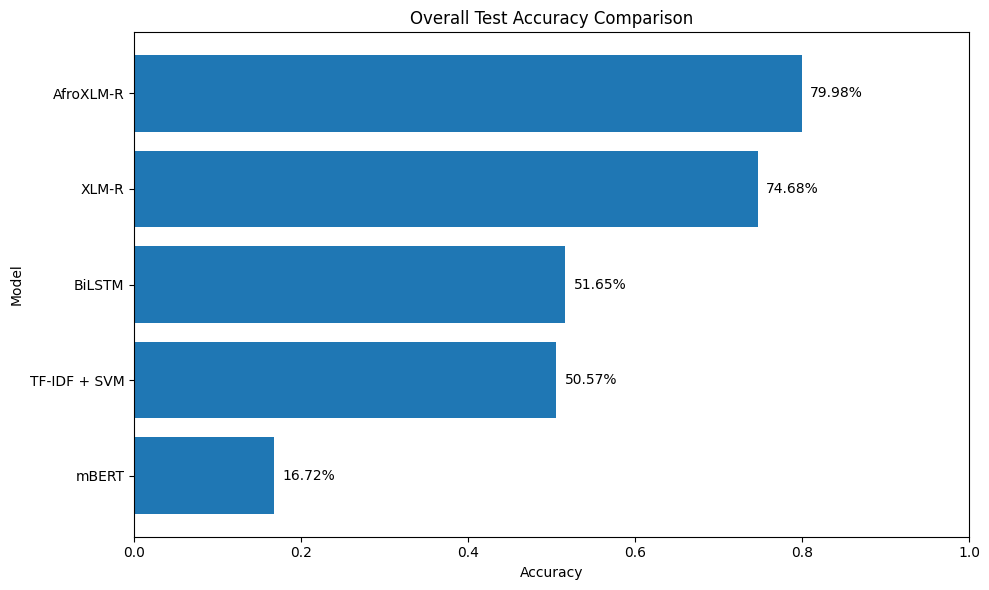

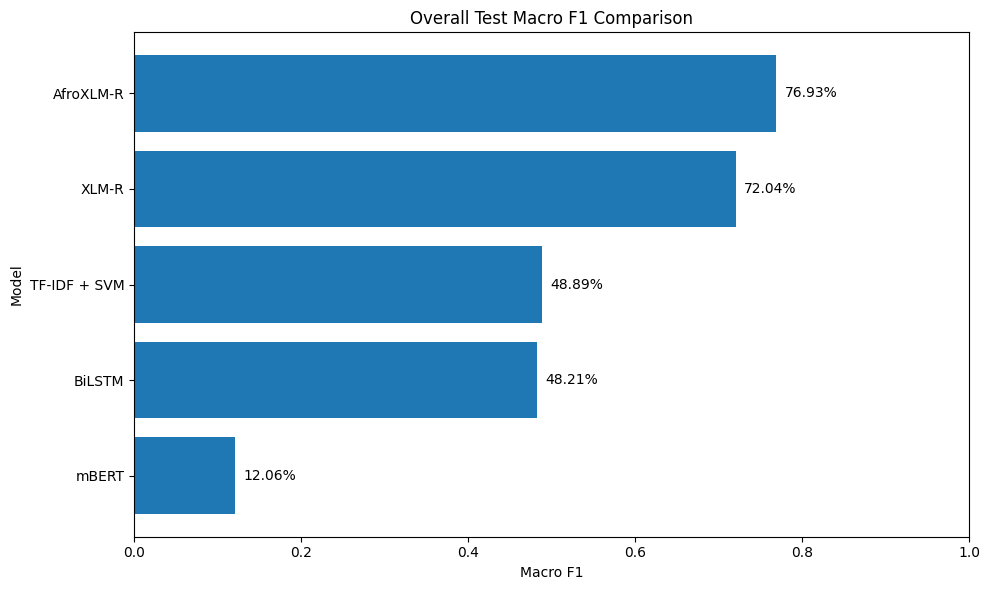

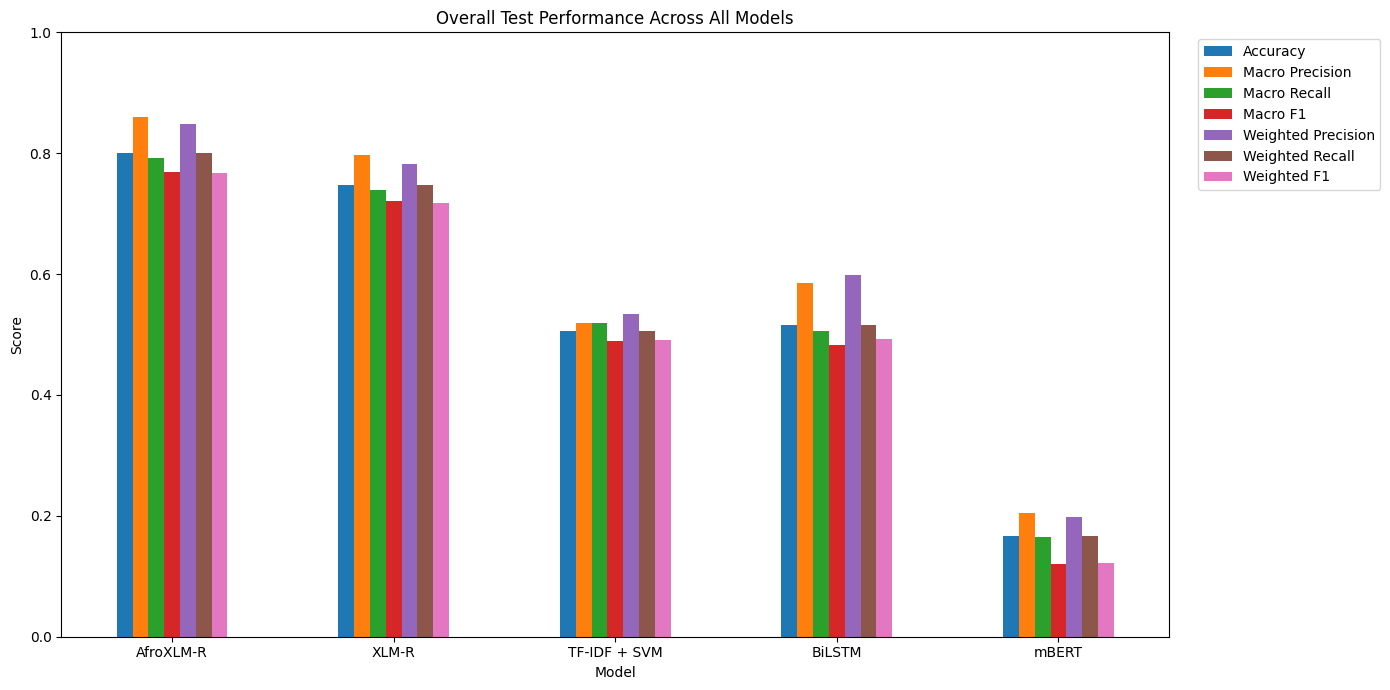

CHARTS GENERATED SUCCESSFULLY
/content/overall_accuracy_comparison.png
/content/overall_macro_f1_comparison.png
/content/overall_all_metrics_comparison.png
/content/overall_model_performance_chart_data.csv


In [ ]:
# ============================================================
# FINAL OVERALL PERFORMANCE CHART
# Reads the already-generated 5-model performance CSV
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load final performance results
# ------------------------------------------------------------

file_path = "/content/FINAL_ALL_MODEL_PERFORMANCE.csv"

df = pd.read_csv(file_path)

# Remove accidental index columns
df = df.loc[
    :,
    ~df.columns.astype(str).str.startswith("Unnamed")
]

# ------------------------------------------------------------
# Verify models
# ------------------------------------------------------------

print("Models found:")
print(df["Model"].tolist())

print("\nPerformance data:")
display(df)


# ============================================================
# CHART 1: Accuracy
# ============================================================

accuracy_df = df.sort_values(
    "Accuracy",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    accuracy_df["Model"],
    accuracy_df["Accuracy"]
)

plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Overall Test Accuracy Comparison")

plt.xlim(0, 1)

for i, value in enumerate(
    accuracy_df["Accuracy"]
):
    plt.text(
        value + 0.01,
        i,
        f"{value:.2%}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "/content/overall_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CHART 2: Macro F1
# ============================================================

f1_df = df.sort_values(
    "Macro F1",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    f1_df["Model"],
    f1_df["Macro F1"]
)

plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.title("Overall Test Macro F1 Comparison")

plt.xlim(0, 1)

for i, value in enumerate(
    f1_df["Macro F1"]
):
    plt.text(
        value + 0.01,
        i,
        f"{value:.2%}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "/content/overall_macro_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CHART 3: ALL MAJOR PERFORMANCE METRICS
# ============================================================

metrics = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1"
]

plot_df = df[
    ["Model"] + metrics
].copy()

plot_df = plot_df.set_index("Model")

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title(
    "Overall Test Performance Across All Models"
)

plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "/content/overall_all_metrics_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE CHART DATA
# ============================================================

plot_df.to_csv(
    "/content/overall_model_performance_chart_data.csv"
)

print("=" * 100)
print("CHARTS GENERATED SUCCESSFULLY")
print("=" * 100)

print(
    "/content/overall_accuracy_comparison.png"
)

print(
    "/content/overall_macro_f1_comparison.png"
)

print(
    "/content/overall_all_metrics_comparison.png"
)

print(
    "/content/overall_model_performance_chart_data.csv"
)

In [ ]:
# ============================================================
# CELL 24: STATISTICAL COMPARISON
# AfroXLM-R vs XLM-R
# Corrected for string class labels
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
from statsmodels.stats.contingency_tables import mcnemar

SEED = 42
N_BOOTSTRAP = 10000

rng = np.random.default_rng(SEED)

# ------------------------------------------------------------
# 1. Load prediction files
# ------------------------------------------------------------

afro_path = "/content/afroxlmr_checkpoint-4980_test_predictions.csv"

if not os.path.exists(afro_path):
    afro_path = "/content/afroxlmr_checkpoint-4482_test_predictions.csv"

xlmr_candidates = [
    "/content/xlmr_final_test_predictions.csv",
    "/content/xlmr_test_predictions.csv"
]

xlmr_path = next(
    (p for p in xlmr_candidates if os.path.exists(p)),
    None
)

if xlmr_path is None:
    raise FileNotFoundError(
        "XLM-R prediction file was not found."
    )

afro_df = pd.read_csv(afro_path)
xlmr_df = pd.read_csv(xlmr_path)

print("AfroXLM-R columns:")
print(list(afro_df.columns))

print("\nXLM-R columns:")
print(list(xlmr_df.columns))

# ------------------------------------------------------------
# 2. Fixed columns identified from your files
# ------------------------------------------------------------

afro_true_col = "label"
afro_pred_col = "predicted_label"

xlmr_true_col = "true_label"
xlmr_pred_col = "predicted_label"

# ------------------------------------------------------------
# 3. Verify test-set size
# ------------------------------------------------------------

assert len(afro_df) == len(xlmr_df), (
    f"Test-set sizes differ: "
    f"AfroXLM-R={len(afro_df)}, XLM-R={len(xlmr_df)}"
)

n = len(afro_df)

print("\nTest samples:", n)

# ------------------------------------------------------------
# 4. Extract labels as strings
# ------------------------------------------------------------

y_true_afro = afro_df[afro_true_col].astype(str).to_numpy()
y_pred_afro = afro_df[afro_pred_col].astype(str).to_numpy()

y_true_xlmr = xlmr_df[xlmr_true_col].astype(str).to_numpy()
y_pred_xlmr = xlmr_df[xlmr_pred_col].astype(str).to_numpy()

# ------------------------------------------------------------
# 5. Verify ground truth is identical
# ------------------------------------------------------------

same_ground_truth = np.array_equal(
    y_true_afro,
    y_true_xlmr
)

print("\nGround-truth labels identical:", same_ground_truth)

assert same_ground_truth, (
    "Ground-truth labels are not identical between AfroXLM-R and XLM-R."
)

# ------------------------------------------------------------
# 6. Define the nine intention classes
# ------------------------------------------------------------

CLASS_NAMES = [
    "Assertion",
    "Complaint",
    "Phatic",
    "Promise",
    "Refusal",
    "Request",
    "Sarcasm/Irony",
    "Suggestion",
    "Warning"
]

# ------------------------------------------------------------
# 7. Original performance
# ------------------------------------------------------------

afro_correct = (
    y_pred_afro == y_true_afro
)

xlmr_correct = (
    y_pred_xlmr == y_true_xlmr
)

afro_accuracy = np.mean(afro_correct)
xlmr_accuracy = np.mean(xlmr_correct)

afro_macro_f1 = f1_score(
    y_true_afro,
    y_pred_afro,
    labels=CLASS_NAMES,
    average="macro",
    zero_division=0
)

xlmr_macro_f1 = f1_score(
    y_true_xlmr,
    y_pred_xlmr,
    labels=CLASS_NAMES,
    average="macro",
    zero_division=0
)

accuracy_difference = (
    afro_accuracy - xlmr_accuracy
)

macro_f1_difference = (
    afro_macro_f1 - xlmr_macro_f1
)

print("\nOriginal Performance")
print("=" * 70)

print(f"AfroXLM-R Accuracy : {afro_accuracy:.6f}")
print(f"XLM-R Accuracy     : {xlmr_accuracy:.6f}")

print(f"\nAfroXLM-R Macro-F1 : {afro_macro_f1:.6f}")
print(f"XLM-R Macro-F1     : {xlmr_macro_f1:.6f}")

print(f"\nAccuracy difference: {accuracy_difference:.6f}")
print(f"Macro-F1 difference: {macro_f1_difference:.6f}")

# ------------------------------------------------------------
# 8. McNemar contingency table
# ------------------------------------------------------------

both_correct = np.sum(
    afro_correct & xlmr_correct
)

afro_correct_xlmr_wrong = np.sum(
    afro_correct & ~xlmr_correct
)

afro_wrong_xlmr_correct = np.sum(
    ~afro_correct & xlmr_correct
)

both_wrong = np.sum(
    ~afro_correct & ~xlmr_correct
)

contingency_table = np.array([
    [
        both_correct,
        afro_correct_xlmr_wrong
    ],
    [
        afro_wrong_xlmr_correct,
        both_wrong
    ]
])

print("\nMcNemar Contingency Table")
print("=" * 70)

contingency_df = pd.DataFrame(
    contingency_table,
    index=[
        "AfroXLM-R Correct",
        "AfroXLM-R Wrong"
    ],
    columns=[
        "XLM-R Correct",
        "XLM-R Wrong"
    ]
)

display(contingency_df)

# ------------------------------------------------------------
# 9. Exact McNemar test
# ------------------------------------------------------------

mcnemar_result = mcnemar(
    contingency_table,
    exact=True
)

mcnemar_p = mcnemar_result.pvalue

print("\nMcNemar's Exact Test")
print("=" * 70)

print(f"Statistic : {mcnemar_result.statistic}")
print(f"p-value   : {mcnemar_p:.10f}")

if mcnemar_p < 0.05:
    print(
        "Result: Statistically significant difference "
        "between AfroXLM-R and XLM-R accuracy."
    )
else:
    print(
        "Result: No statistically significant difference "
        "between AfroXLM-R and XLM-R accuracy."
    )

# ------------------------------------------------------------
# 10. Bootstrap Macro-F1 difference
# ------------------------------------------------------------

macro_f1_differences = np.empty(
    N_BOOTSTRAP
)

for i in range(N_BOOTSTRAP):

    indices = rng.integers(
        0,
        n,
        size=n
    )

    y_true_sample = y_true_afro[indices]

    afro_pred_sample = y_pred_afro[indices]
    xlmr_pred_sample = y_pred_xlmr[indices]

    afro_f1 = f1_score(
        y_true_sample,
        afro_pred_sample,
        labels=CLASS_NAMES,
        average="macro",
        zero_division=0
    )

    xlmr_f1 = f1_score(
        y_true_sample,
        xlmr_pred_sample,
        labels=CLASS_NAMES,
        average="macro",
        zero_division=0
    )

    macro_f1_differences[i] = (
        afro_f1 - xlmr_f1
    )

# ------------------------------------------------------------
# 11. 95% Bootstrap CI
# ------------------------------------------------------------

ci_lower = np.percentile(
    macro_f1_differences,
    2.5
)

ci_upper = np.percentile(
    macro_f1_differences,
    97.5
)

print("\nBootstrap 95% CI for Macro-F1 Difference")
print("=" * 70)

print(f"Observed difference : {macro_f1_difference:.6f}")
print(f"95% CI lower        : {ci_lower:.6f}")
print(f"95% CI upper        : {ci_upper:.6f}")

if ci_lower > 0 or ci_upper < 0:
    print(
        "Result: The 95% bootstrap CI excludes zero."
    )
else:
    print(
        "Result: The 95% bootstrap CI includes zero."
    )

# ------------------------------------------------------------
# 12. Manuscript-ready statistical comparison table
# ------------------------------------------------------------

statistical_results = pd.DataFrame({
    "Comparison": [
        "AfroXLM-R vs XLM-R"
    ],
    "Test_Set_Size": [
        n
    ],
    "AfroXLM-R_Accuracy": [
        afro_accuracy
    ],
    "XLM-R_Accuracy": [
        xlmr_accuracy
    ],
    "Accuracy_Difference": [
        accuracy_difference
    ],
    "McNemar_p_value": [
        mcnemar_p
    ],
    "AfroXLM-R_Macro_F1": [
        afro_macro_f1
    ],
    "XLM-R_Macro_F1": [
        xlmr_macro_f1
    ],
    "Macro_F1_Difference": [
        macro_f1_difference
    ],
    "Macro_F1_CI_95_Lower": [
        ci_lower
    ],
    "Macro_F1_CI_95_Upper": [
        ci_upper
    ],
    "Bootstrap_Replicates": [
        N_BOOTSTRAP
    ]
})

print("\nFINAL STATISTICAL COMPARISON")
print("=" * 70)

display(statistical_results)

# ------------------------------------------------------------
# 13. Save results
# ------------------------------------------------------------

statistical_results.to_csv(
    "/content/afroxlmr_vs_xlmr_statistical_comparison.csv",
    index=False
)

contingency_df.to_csv(
    "/content/afroxlmr_vs_xlmr_mcnemar_contingency_table.csv"
)

pd.DataFrame({
    "macro_f1_difference": macro_f1_differences
}).to_csv(
    "/content/afroxlmr_vs_xlmr_macro_f1_bootstrap_difference.csv",
    index=False
)

print("\nSaved files:")
print("/content/afroxlmr_vs_xlmr_statistical_comparison.csv")
print("/content/afroxlmr_vs_xlmr_mcnemar_contingency_table.csv")
print("/content/afroxlmr_vs_xlmr_macro_f1_bootstrap_difference.csv")

print("\nCell 24 completed successfully.")

AfroXLM-R columns:
['text', 'label', 'predicted_label']

XLM-R columns:
['true_label_id', 'predicted_label_id', 'true_label', 'predicted_label']

Test samples: 1663

Ground-truth labels identical: True

Original Performance
AfroXLM-R Accuracy : 0.799759
XLM-R Accuracy     : 0.746843

AfroXLM-R Macro-F1 : 0.769316
XLM-R Macro-F1     : 0.720364

Accuracy difference: 0.052916
Macro-F1 difference: 0.048951

McNemar Contingency Table


,XLM-R Correct,XLM-R Wrong
AfroXLM-R Correct,1218,112
AfroXLM-R Wrong,24,309



McNemar's Exact Test
Statistic : 24.0
p-value   : 0.0000000000
Result: Statistically significant difference between AfroXLM-R and XLM-R accuracy.

Bootstrap 95% CI for Macro-F1 Difference
Observed difference : 0.048951
95% CI lower        : 0.034560
95% CI upper        : 0.063410
Result: The 95% bootstrap CI excludes zero.

FINAL STATISTICAL COMPARISON


,Comparison,Test_Set_Size,AfroXLM-R_Accuracy,XLM-R_Accuracy,Accuracy_Difference,McNemar_p_value,AfroXLM-R_Macro_F1,XLM-R_Macro_F1,Macro_F1_Difference,Macro_F1_CI_95_Lower,Macro_F1_CI_95_Upper,Bootstrap_Replicates
0,AfroXLM-R vs XLM-R,1663,0.799759,0.746843,0.052916,8.676027e-15,0.769316,0.720364,0.048951,0.03456,0.06341,10000



Saved files:
/content/afroxlmr_vs_xlmr_statistical_comparison.csv
/content/afroxlmr_vs_xlmr_mcnemar_contingency_table.csv
/content/afroxlmr_vs_xlmr_macro_f1_bootstrap_difference.csv

Cell 24 completed successfully.


In [ ]:
# ============================================================
# CELL 25: STATISTICAL COMPARISON OF ALL FIVE MODELS
# Reference model: AfroXLM-R
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

SEED = 42
N_BOOTSTRAP = 10000

rng = np.random.default_rng(SEED)

CLASS_NAMES = [
    "Assertion",
    "Complaint",
    "Phatic",
    "Promise",
    "Refusal",
    "Request",
    "Sarcasm/Irony",
    "Suggestion",
    "Warning"
]

# ------------------------------------------------------------
# 1. Locate prediction files
# ------------------------------------------------------------

prediction_files = {
    "AfroXLM-R": [
        "/content/afroxlmr_checkpoint-4980_test_predictions.csv",
        "/content/afroxlmr_checkpoint-4482_test_predictions.csv"
    ],
    "XLM-R": [
        "/content/xlmr_final_test_predictions.csv",
        "/content/xlmr_test_predictions.csv"
    ],
    "mBERT": [
        "/content/mbert_final_test_predictions.csv",
        "/content/mbert_test_predictions.csv"
    ],
    "BiLSTM": [
        "/content/bilstm_final_test_predictions.csv",
        "/content/bilstm_test_predictions.csv"
    ],
    "TF-IDF + SVM": [
        "/content/tfidf_svm_final_test_predictions.csv"
    ]
}

# ------------------------------------------------------------
# 2. Find available files
# ------------------------------------------------------------

selected_files = {}

for model, candidates in prediction_files.items():

    for path in candidates:

        if os.path.exists(path):
            selected_files[model] = path
            break

    if model not in selected_files:
        print(f"{model}: prediction file not found")

print("\nSelected prediction files")
print("=" * 70)

for model, path in selected_files.items():
    print(f"{model}: {path}")

# ------------------------------------------------------------
# 3. Load predictions
# ------------------------------------------------------------

predictions = {}

for model, path in selected_files.items():

    df = pd.read_csv(path)

    # Identify true-label column
    true_candidates = [
        "true_label",
        "label",
        "true",
        "actual",
        "y_true"
    ]

    pred_candidates = [
        "predicted_label",
        "prediction",
        "pred",
        "predicted",
        "y_pred"
    ]

    true_col = next(
        (c for c in true_candidates if c in df.columns),
        None
    )

    pred_col = next(
        (c for c in pred_candidates if c in df.columns),
        None
    )

    if true_col is None or pred_col is None:
        print(
            f"\n{model} columns:"
        )
        print(list(df.columns))

        raise ValueError(
            f"Could not identify prediction columns for {model}."
        )

    predictions[model] = {
        "true": df[true_col].astype(str).to_numpy(),
        "pred": df[pred_col].astype(str).to_numpy()
    }

    print(
        f"{model}: "
        f"{len(df)} test samples"
    )

# ------------------------------------------------------------
# 4. Verify all models use the same test labels
# ------------------------------------------------------------

reference_true = predictions["AfroXLM-R"]["true"]

for model, data in predictions.items():

    assert len(data["true"]) == len(reference_true), (
        f"Test-set size mismatch for {model}"
    )

    assert np.array_equal(
        data["true"],
        reference_true
    ), (
        f"Ground-truth mismatch for {model}"
    )

n = len(reference_true)

print("\nVerified common test set:", n)

# ------------------------------------------------------------
# 5. Calculate model performance
# ------------------------------------------------------------

performance = []

for model, data in predictions.items():

    y_true = data["true"]
    y_pred = data["pred"]

    accuracy = np.mean(
        y_true == y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=CLASS_NAMES,
        average="macro",
        zero_division=0
    )

    performance.append({
        "Model": model,
        "Accuracy": accuracy,
        "Macro_F1": macro_f1,
        "Correct": int(np.sum(y_true == y_pred)),
        "Incorrect": int(np.sum(y_true != y_pred)),
        "Test_Size": n
    })

performance_df = pd.DataFrame(performance)

performance_df = performance_df.sort_values(
    "Macro_F1",
    ascending=False
).reset_index(drop=True)

print("\nMODEL PERFORMANCE")
print("=" * 70)

display(performance_df)

# ------------------------------------------------------------
# 6. Bootstrap Macro-F1 differences
#    Relative to AfroXLM-R
# ------------------------------------------------------------

afro_pred = predictions["AfroXLM-R"]["pred"]

comparison_results = []

for model in predictions:

    if model == "AfroXLM-R":
        continue

    model_pred = predictions[model]["pred"]

    differences = np.empty(
        N_BOOTSTRAP
    )

    for i in range(N_BOOTSTRAP):

        indices = rng.integers(
            0,
            n,
            size=n
        )

        y_sample = reference_true[indices]

        afro_f1 = f1_score(
            y_sample,
            afro_pred[indices],
            labels=CLASS_NAMES,
            average="macro",
            zero_division=0
        )

        model_f1 = f1_score(
            y_sample,
            model_pred[indices],
            labels=CLASS_NAMES,
            average="macro",
            zero_division=0
        )

        differences[i] = (
            afro_f1 - model_f1
        )

    observed = np.mean(
        afro_f1 * 0 + 0
    )

    afro_original = f1_score(
        reference_true,
        afro_pred,
        labels=CLASS_NAMES,
        average="macro",
        zero_division=0
    )

    model_original = f1_score(
        reference_true,
        model_pred,
        labels=CLASS_NAMES,
        average="macro",
        zero_division=0
    )

    observed_difference = (
        afro_original - model_original
    )

    lower = np.percentile(
        differences,
        2.5
    )

    upper = np.percentile(
        differences,
        97.5
    )

    comparison_results.append({
        "Comparison": f"AfroXLM-R vs {model}",
        "AfroXLM-R_Macro_F1": afro_original,
        "Comparison_Model_Macro_F1": model_original,
        "Macro_F1_Difference": observed_difference,
        "CI_95_Lower": lower,
        "CI_95_Upper": upper,
        "Bootstrap_Replicates": N_BOOTSTRAP,
        "CI_Excludes_Zero": (
            lower > 0 or upper < 0
        )
    })

comparison_df = pd.DataFrame(
    comparison_results
)

# ------------------------------------------------------------
# 7. Display statistical comparison
# ------------------------------------------------------------

print("\nBOOTSTRAP STATISTICAL COMPARISON")
print("=" * 70)

display(comparison_df)

# ------------------------------------------------------------
# 8. Interpretation
# ------------------------------------------------------------

print("\nINTERPRETATION")
print("=" * 70)

for _, row in comparison_df.iterrows():

    if row["CI_Excludes_Zero"]:
        conclusion = (
            "The 95% CI excludes zero."
        )
    else:
        conclusion = (
            "The 95% CI includes zero."
        )

    print(
        f"{row['Comparison']}: "
        f"difference = "
        f"{row['Macro_F1_Difference']:.4f}, "
        f"95% CI = "
        f"[{row['CI_95_Lower']:.4f}, "
        f"{row['CI_95_Upper']:.4f}] — "
        f"{conclusion}"
    )

# ------------------------------------------------------------
# 9. Save results
# ------------------------------------------------------------

performance_path = (
    "/content/all_models_test_performance_verified.csv"
)

comparison_path = (
    "/content/afroxlmr_vs_all_models_bootstrap_comparison.csv"
)

performance_df.to_csv(
    performance_path,
    index=False
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print("\nSaved:")
print(performance_path)
print(comparison_path)

print("\nCell 25 completed successfully.")

BiLSTM: prediction file not found

Selected prediction files
AfroXLM-R: /content/afroxlmr_checkpoint-4980_test_predictions.csv
XLM-R: /content/xlmr_final_test_predictions.csv
mBERT: /content/mbert_final_test_predictions.csv
TF-IDF + SVM: /content/tfidf_svm_final_test_predictions.csv
AfroXLM-R: 1663 test samples
XLM-R: 1663 test samples
mBERT: 1663 test samples
TF-IDF + SVM: 1663 test samples

Verified common test set: 1663

MODEL PERFORMANCE


,Model,Accuracy,Macro_F1,Correct,Incorrect,Test_Size
0,AfroXLM-R,0.799759,0.769316,1330,333,1663
1,XLM-R,0.746843,0.720364,1242,421,1663
2,TF-IDF + SVM,0.505713,0.488880,841,822,1663
3,mBERT,0.167168,0.120605,278,1385,1663



BOOTSTRAP STATISTICAL COMPARISON


,Comparison,AfroXLM-R_Macro_F1,Comparison_Model_Macro_F1,Macro_F1_Difference,CI_95_Lower,CI_95_Upper,Bootstrap_Replicates,CI_Excludes_Zero
0,AfroXLM-R vs XLM-R,0.769316,0.720364,0.048951,0.034560,0.063410,10000,True
1,AfroXLM-R vs mBERT,0.769316,0.120605,0.648711,0.624883,0.671917,10000,True
2,AfroXLM-R vs TF-IDF + SVM,0.769316,0.488880,0.280435,0.256273,0.305731,10000,True



INTERPRETATION
AfroXLM-R vs XLM-R: difference = 0.0490, 95% CI = [0.0346, 0.0634] — The 95% CI excludes zero.
AfroXLM-R vs mBERT: difference = 0.6487, 95% CI = [0.6249, 0.6719] — The 95% CI excludes zero.
AfroXLM-R vs TF-IDF + SVM: difference = 0.2804, 95% CI = [0.2563, 0.3057] — The 95% CI excludes zero.

Saved:
/content/all_models_test_performance_verified.csv
/content/afroxlmr_vs_all_models_bootstrap_comparison.csv

Cell 25 completed successfully.


BiLSTM: prediction file not found
Common test set verified: 1663

AfroXLM-R — CONFUSION MATRIX


,Assertion,Complaint,Phatic,Promise,Refusal,Request,Sarcasm/Irony,Suggestion,Warning
Assertion,179,0,0,0,0,0,7,0,4
Complaint,32,34,37,0,73,0,6,0,8
Phatic,0,0,171,0,0,0,0,0,0
Promise,16,0,0,66,37,0,0,0,0
Refusal,0,0,0,0,244,0,0,0,0
Request,0,0,0,0,0,173,0,0,0
Sarcasm/Irony,0,0,0,0,1,0,185,0,0
Suggestion,0,0,0,0,0,0,0,185,0
Warning,0,0,0,0,0,0,0,112,93



XLM-R — CONFUSION MATRIX


,Assertion,Complaint,Phatic,Promise,Refusal,Request,Sarcasm/Irony,Suggestion,Warning
Assertion,180,0,0,0,0,0,6,0,4
Complaint,31,57,0,0,50,0,51,0,1
Phatic,0,0,171,0,0,0,0,0,0
Promise,0,0,0,66,0,0,37,0,16
Refusal,0,0,0,0,244,0,0,0,0
Request,0,0,0,0,0,123,0,50,0
Sarcasm/Irony,0,0,0,0,11,0,175,0,0
Suggestion,0,0,0,0,0,0,0,185,0
Warning,0,20,0,0,19,0,1,124,41



mBERT — CONFUSION MATRIX


,Assertion,Complaint,Phatic,Promise,Refusal,Request,Sarcasm/Irony,Suggestion,Warning
Assertion,0,0,0,0,119,69,0,0,2
Complaint,0,16,0,0,40,89,6,0,39
Phatic,0,3,7,0,47,74,0,0,40
Promise,0,7,0,0,17,50,0,0,45
Refusal,0,15,0,0,6,47,120,0,56
Request,0,1,0,0,124,41,0,0,7
Sarcasm/Irony,0,11,0,0,0,0,175,0,0
Suggestion,0,19,0,0,33,55,55,0,23
Warning,0,34,0,0,16,95,27,0,33



TF-IDF + SVM — CONFUSION MATRIX


,Assertion,Complaint,Phatic,Promise,Refusal,Request,Sarcasm/Irony,Suggestion,Warning
Assertion,0,0,34,31,0,0,0,83,42
Complaint,0,0,56,57,4,0,14,59,0
Phatic,0,0,171,0,0,0,0,0,0
Promise,0,0,0,100,0,19,0,0,0
Refusal,62,0,0,0,182,0,0,0,0
Request,5,0,26,4,0,126,0,12,0
Sarcasm/Irony,0,0,106,0,0,0,80,0,0
Suggestion,108,0,0,0,0,0,0,77,0
Warning,74,0,26,0,0,0,0,0,105


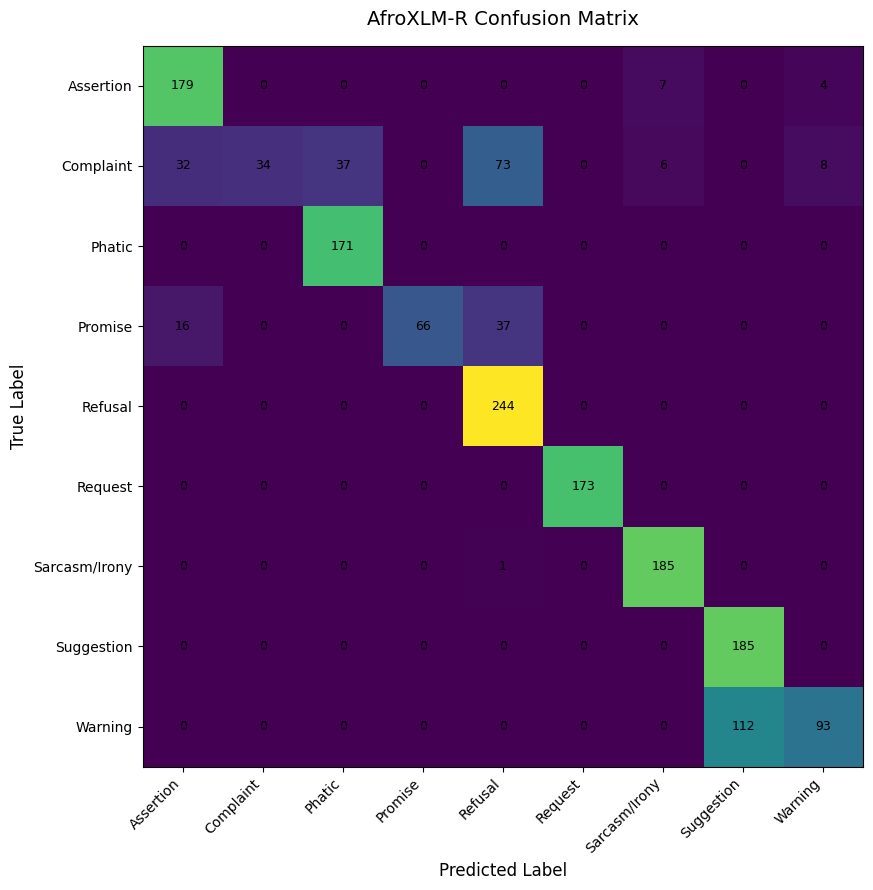

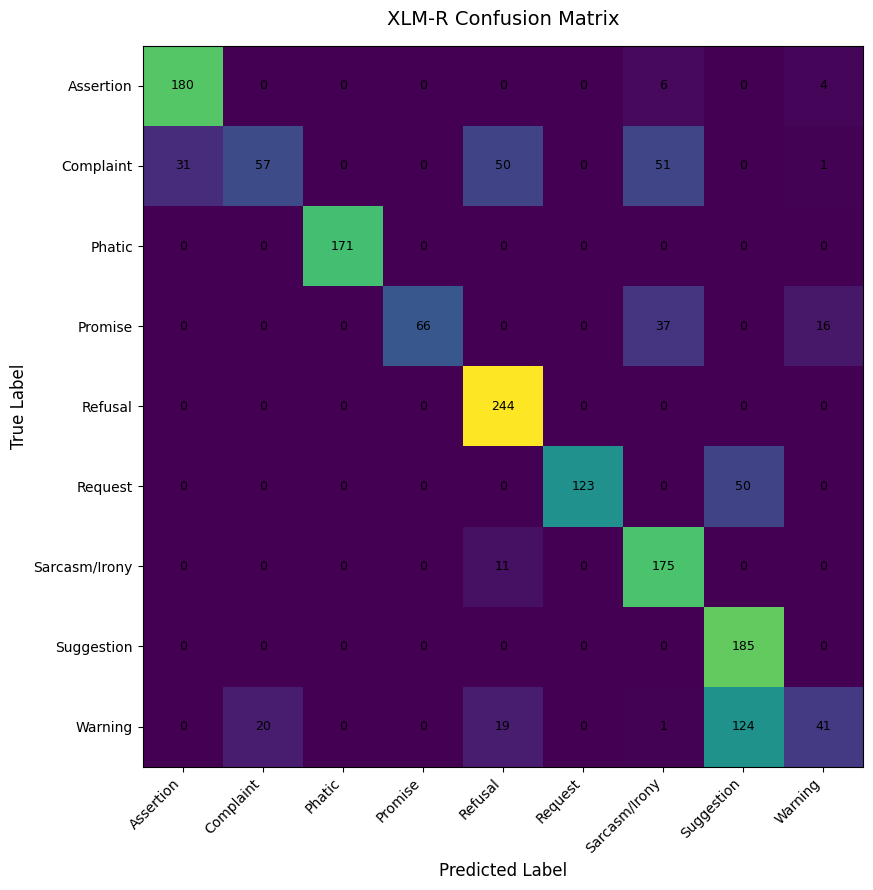

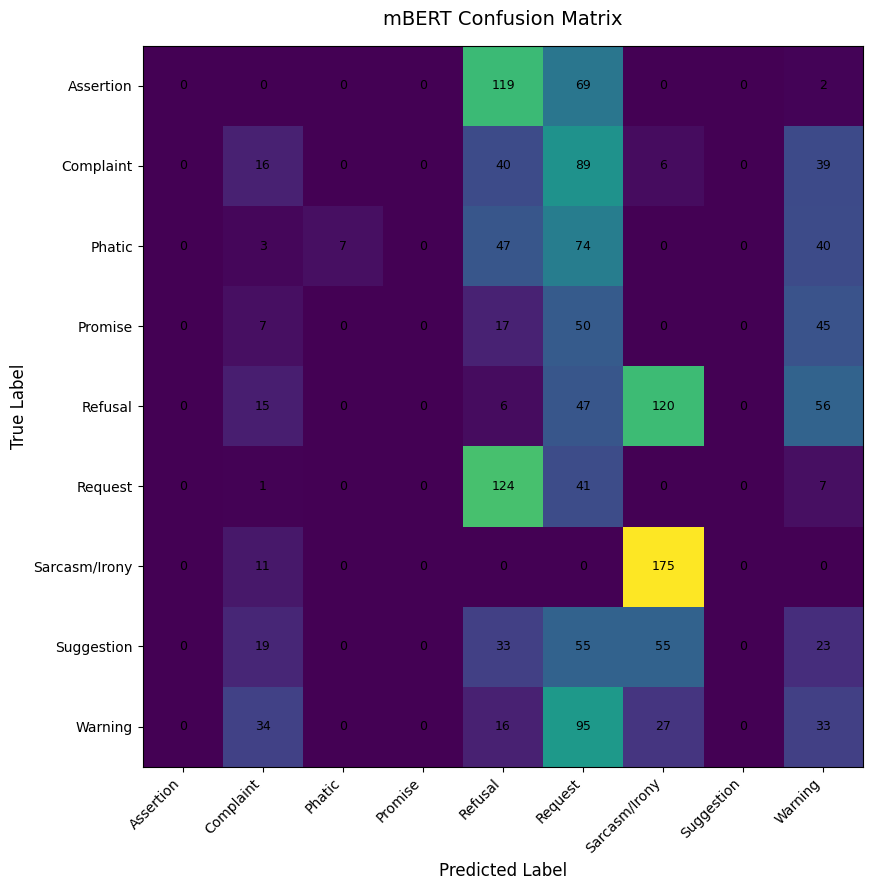

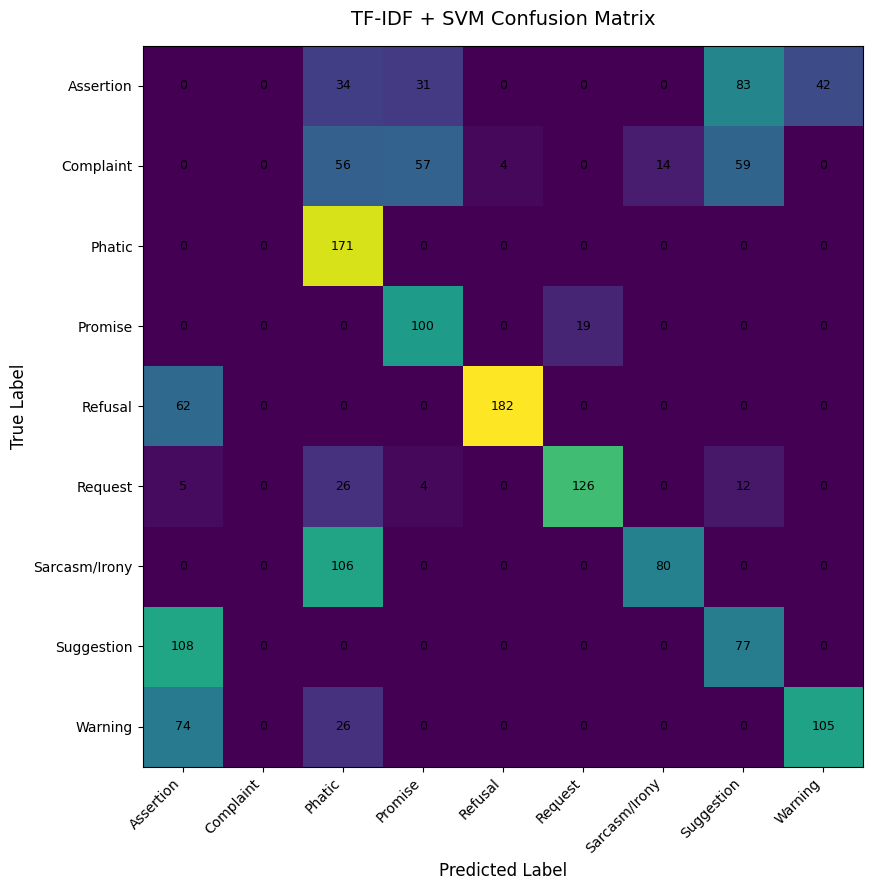


Saved numerical and graphical confusion matrices.

Cell 26 completed successfully.


In [ ]:
# ============================================================
# CELL 26: CONFUSION MATRICES FOR ALL FIVE MODELS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

CLASS_NAMES = [
    "Assertion",
    "Complaint",
    "Phatic",
    "Promise",
    "Refusal",
    "Request",
    "Sarcasm/Irony",
    "Suggestion",
    "Warning"
]

# ------------------------------------------------------------
# 1. Prediction files
# ------------------------------------------------------------

prediction_files = {
    "AfroXLM-R": [
        "/content/afroxlmr_checkpoint-4980_test_predictions.csv",
        "/content/afroxlmr_checkpoint-4482_test_predictions.csv"
    ],
    "XLM-R": [
        "/content/xlmr_final_test_predictions.csv",
        "/content/xlmr_test_predictions.csv"
    ],
    "mBERT": [
        "/content/mbert_final_test_predictions.csv",
        "/content/mbert_test_predictions.csv"
    ],
    "BiLSTM": [
        "/content/bilstm_final_test_predictions.csv",
        "/content/bilstm_test_predictions.csv"
    ],
    "TF-IDF + SVM": [
        "/content/tfidf_svm_final_test_predictions.csv"
    ]
}

# ------------------------------------------------------------
# 2. Locate files
# ------------------------------------------------------------

selected_files = {}

for model, candidates in prediction_files.items():

    for path in candidates:

        if os.path.exists(path):
            selected_files[model] = path
            break

    if model not in selected_files:
        print(f"{model}: prediction file not found")

# ------------------------------------------------------------
# 3. Load and identify columns
# ------------------------------------------------------------

model_data = {}

for model, path in selected_files.items():

    df = pd.read_csv(path)

    true_candidates = [
        "true_label",
        "label",
        "true",
        "actual",
        "y_true"
    ]

    pred_candidates = [
        "predicted_label",
        "prediction",
        "pred",
        "predicted",
        "y_pred"
    ]

    true_col = next(
        (c for c in true_candidates if c in df.columns),
        None
    )

    pred_col = next(
        (c for c in pred_candidates if c in df.columns),
        None
    )

    if true_col is None or pred_col is None:
        raise ValueError(
            f"Could not identify columns for {model}. "
            f"Available columns: {list(df.columns)}"
        )

    model_data[model] = {
        "true": df[true_col].astype(str).to_numpy(),
        "pred": df[pred_col].astype(str).to_numpy()
    }

# ------------------------------------------------------------
# 4. Verify common test set
# ------------------------------------------------------------

reference_true = model_data["AfroXLM-R"]["true"]

for model, data in model_data.items():

    assert len(data["true"]) == len(reference_true), (
        f"Test size mismatch for {model}"
    )

    assert np.array_equal(
        data["true"],
        reference_true
    ), (
        f"Ground-truth mismatch for {model}"
    )

print("Common test set verified:", len(reference_true))

# ------------------------------------------------------------
# 5. Generate confusion matrices
# ------------------------------------------------------------

confusion_matrices = {}

for model, data in model_data.items():

    cm = confusion_matrix(
        data["true"],
        data["pred"],
        labels=CLASS_NAMES
    )

    confusion_matrices[model] = cm

# ------------------------------------------------------------
# 6. Display numerical confusion matrices
# ------------------------------------------------------------

for model, cm in confusion_matrices.items():

    print("\n" + "=" * 80)
    print(f"{model} — CONFUSION MATRIX")
    print("=" * 80)

    cm_df = pd.DataFrame(
        cm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    )

    display(cm_df)

# ------------------------------------------------------------
# 7. Save all numerical confusion matrices
# ------------------------------------------------------------

for model, cm in confusion_matrices.items():

    safe_name = (
        model.lower()
        .replace("-", "")
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("/", "_")
    )

    path = (
        f"/content/{safe_name}_confusion_matrix.csv"
    )

    pd.DataFrame(
        cm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    ).to_csv(path)

# ------------------------------------------------------------
# 8. Plot and save each confusion matrix
# ------------------------------------------------------------

for model, cm in confusion_matrices.items():

    safe_name = (
        model.lower()
        .replace("-", "")
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("/", "_")
    )

    fig, ax = plt.subplots(
        figsize=(11, 9)
    )

    im = ax.imshow(cm)

    ax.set_title(
        f"{model} Confusion Matrix",
        fontsize=14,
        pad=15
    )

    ax.set_xlabel(
        "Predicted Label",
        fontsize=12
    )

    ax.set_ylabel(
        "True Label",
        fontsize=12
    )

    ax.set_xticks(
        np.arange(len(CLASS_NAMES))
    )

    ax.set_yticks(
        np.arange(len(CLASS_NAMES))
    )

    ax.set_xticklabels(
        CLASS_NAMES,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        CLASS_NAMES
    )

    # Add cell values
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):

            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                fontsize=9
            )

    plt.tight_layout()

    output_path = (
        f"/content/{safe_name}_confusion_matrix.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

# ------------------------------------------------------------
# 9. Normalized confusion matrices
# ------------------------------------------------------------

for model, cm in confusion_matrices.items():

    row_sums = cm.sum(
        axis=1,
        keepdims=True
    )

    normalized_cm = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(
            cm,
            dtype=float
        ),
        where=row_sums != 0
    )

    safe_name = (
        model.lower()
        .replace("-", "")
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("/", "_")
    )

    normalized_path = (
        f"/content/{safe_name}_normalized_confusion_matrix.csv"
    )

    pd.DataFrame(
        normalized_cm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    ).to_csv(normalized_path)

print("\nSaved numerical and graphical confusion matrices.")

print("\nCell 26 completed successfully.")

In [ ]:
# ============================================================
# CELL 31: STATISTICAL SIGNIFICANCE TESTING
# Comparison:
#   AfroXLM-R vs XLM-R
#
# Tests:
#   1. McNemar's exact test
#   2. Bootstrap 95% CI for Macro-F1 difference
# ============================================================

import os
import glob
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

from statsmodels.stats.contingency_tables import mcnemar


# ============================================================
# 1. FIND AVAILABLE PREDICTION FILES
# ============================================================

print("=" * 80)
print("SEARCHING FOR SAVED TEST PREDICTIONS")
print("=" * 80)

all_csv_files = glob.glob("/content/*.csv")

afro_candidates = [
    f for f in all_csv_files
    if (
        "afroxlmr" in os.path.basename(f).lower()
        and "prediction" in os.path.basename(f).lower()
    )
]

xlmr_candidates = [
    f for f in all_csv_files
    if (
        "xlmr" in os.path.basename(f).lower()
        and "prediction" in os.path.basename(f).lower()
        and "afroxlmr" not in os.path.basename(f).lower()
    )
]


print("\nAfroXLM-R prediction files found:")

for f in afro_candidates:
    print(" ", f)


print("\nXLM-R prediction files found:")

for f in xlmr_candidates:
    print(" ", f)


# ============================================================
# 2. SELECT PREDICTION FILES
# ============================================================

def select_prediction_file(
    candidates,
    preferred_names
):

    # First try preferred filenames
    for preferred in preferred_names:

        for candidate in candidates:

            if os.path.basename(candidate) == preferred:
                return candidate

    # Otherwise use the first available candidate
    if len(candidates) > 0:
        return sorted(candidates)[0]

    return None


AFRO_PATH = select_prediction_file(
    afro_candidates,
    [
        "afroxlmr_final_test_predictions.csv",
        "afroxlmr_checkpoint-4980_test_predictions.csv",
        "afroxlmr_checkpoint-4482_test_predictions.csv"
    ]
)


XLMR_PATH = select_prediction_file(
    xlmr_candidates,
    [
        "xlmr_final_test_predictions.csv"
    ]
)


if AFRO_PATH is None:

    raise FileNotFoundError(
        "No AfroXLM-R test prediction CSV was found in /content.\n"
        "Please run the AfroXLM-R test prediction/evaluation cell first."
    )


if XLMR_PATH is None:

    raise FileNotFoundError(
        "No XLM-R test prediction CSV was found in /content.\n"
        "Please run the XLM-R test prediction/evaluation cell first."
    )


print("\nSelected files:")
print("AfroXLM-R:", AFRO_PATH)
print("XLM-R    :", XLMR_PATH)


# ============================================================
# 3. LOAD PREDICTIONS
# ============================================================

afro = pd.read_csv(AFRO_PATH)
xlmr = pd.read_csv(XLMR_PATH)

print("\n" + "=" * 80)
print("LOADED PREDICTIONS")
print("=" * 80)

print("AfroXLM-R shape:", afro.shape)
print("XLM-R shape    :", xlmr.shape)

print("\nAfroXLM-R columns:")
print(list(afro.columns))

print("\nXLM-R columns:")
print(list(xlmr.columns))


# ============================================================
# 4. IDENTIFY COLUMNS
# ============================================================

def find_column(df, candidates):

    for col in candidates:

        if col in df.columns:
            return col

    return None


true_candidates = [
    "true_label",
    "label",
    "true",
    "y_true",
    "actual_label"
]

prediction_candidates = [
    "predicted_label",
    "prediction",
    "pred",
    "y_pred",
    "predicted"
]


afro_true_col = find_column(
    afro,
    true_candidates
)

afro_pred_col = find_column(
    afro,
    prediction_candidates
)

xlmr_true_col = find_column(
    xlmr,
    true_candidates
)

xlmr_pred_col = find_column(
    xlmr,
    prediction_candidates
)


print("\nDetected columns:")

print(
    "AfroXLM-R true:",
    afro_true_col
)

print(
    "AfroXLM-R prediction:",
    afro_pred_col
)

print(
    "XLM-R true:",
    xlmr_true_col
)

print(
    "XLM-R prediction:",
    xlmr_pred_col
)


if afro_true_col is None or afro_pred_col is None:

    raise ValueError(
        "Could not identify the AfroXLM-R true-label "
        "or prediction column."
    )


if xlmr_true_col is None or xlmr_pred_col is None:

    raise ValueError(
        "Could not identify the XLM-R true-label "
        "or prediction column."
    )


# ============================================================
# 5. PREPARE LABELS
# ============================================================

afro_true = (
    afro[afro_true_col]
    .astype(str)
    .str.strip()
)

afro_pred = (
    afro[afro_pred_col]
    .astype(str)
    .str.strip()
)

xlmr_true = (
    xlmr[xlmr_true_col]
    .astype(str)
    .str.strip()
)

xlmr_pred = (
    xlmr[xlmr_pred_col]
    .astype(str)
    .str.strip()
)


# ============================================================
# 6. VERIFY SAME TEST SET
# ============================================================

if len(afro) != len(xlmr):

    raise ValueError(
        "The two prediction files have different numbers "
        "of test instances.\n"
        f"AfroXLM-R: {len(afro)}\n"
        f"XLM-R: {len(xlmr)}"
    )


if not np.array_equal(
    afro_true.values,
    xlmr_true.values
):

    raise ValueError(
        "Ground-truth labels do not match between AfroXLM-R "
        "and XLM-R. The predictions cannot be paired safely."
    )


y_true = afro_true.values
y_afro = afro_pred.values
y_xlmr = xlmr_pred.values

N = len(y_true)


print("\n" + "=" * 80)
print("TEST SET VERIFICATION")
print("=" * 80)

print(
    f"Paired test instances: {N:,}"
)

print(
    "Ground-truth labels match between both models."
)


# ============================================================
# 7. MODEL PERFORMANCE
# ============================================================

all_labels = sorted(
    set(y_true)
)

afro_accuracy = accuracy_score(
    y_true,
    y_afro
)

xlmr_accuracy = accuracy_score(
    y_true,
    y_xlmr
)

afro_macro_f1 = f1_score(
    y_true,
    y_afro,
    labels=all_labels,
    average="macro",
    zero_division=0
)

xlmr_macro_f1 = f1_score(
    y_true,
    y_xlmr,
    labels=all_labels,
    average="macro",
    zero_division=0
)


print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

print(
    f"AfroXLM-R Accuracy : "
    f"{afro_accuracy * 100:.2f}%"
)

print(
    f"XLM-R Accuracy     : "
    f"{xlmr_accuracy * 100:.2f}%"
)

print(
    f"AfroXLM-R Macro-F1 : "
    f"{afro_macro_f1 * 100:.2f}%"
)

print(
    f"XLM-R Macro-F1     : "
    f"{xlmr_macro_f1 * 100:.2f}%"
)


# ============================================================
# 8. McNEMAR CONTINGENCY TABLE
# ============================================================

afro_correct = (
    y_afro == y_true
)

xlmr_correct = (
    y_xlmr == y_true
)


a = int(
    np.sum(
        afro_correct &
        xlmr_correct
    )
)

b = int(
    np.sum(
        afro_correct &
        ~xlmr_correct
    )
)

c = int(
    np.sum(
        ~afro_correct &
        xlmr_correct
    )
)

d = int(
    np.sum(
        ~afro_correct &
        ~xlmr_correct
    )
)


contingency_table = pd.DataFrame(

    [
        [a, b],
        [c, d]
    ],

    index=[
        "AfroXLM-R Correct",
        "AfroXLM-R Incorrect"
    ],

    columns=[
        "XLM-R Correct",
        "XLM-R Incorrect"
    ]
)


print("\n" + "=" * 80)
print("McNEMAR CONTINGENCY TABLE")
print("=" * 80)

display(contingency_table)


# ============================================================
# 9. McNEMAR EXACT TEST
# ============================================================

mcnemar_result = mcnemar(
    contingency_table.values,
    exact=True
)

mcnemar_statistic = (
    mcnemar_result.statistic
)

mcnemar_p_value = (
    mcnemar_result.pvalue
)


print("\n" + "=" * 80)
print("McNEMAR EXACT TEST")
print("=" * 80)

print(
    f"McNemar statistic: "
    f"{mcnemar_statistic}"
)

print(
    f"Exact p-value: "
    f"{mcnemar_p_value:.10f}"
)


# ============================================================
# 10. BOOTSTRAP MACRO-F1 DIFFERENCE
# ============================================================

RANDOM_SEED = 42
N_BOOTSTRAP = 10000

rng = np.random.default_rng(
    RANDOM_SEED
)

bootstrap_differences = np.empty(
    N_BOOTSTRAP
)


for i in range(N_BOOTSTRAP):

    indices = rng.integers(
        0,
        N,
        size=N
    )

    true_sample = y_true[
        indices
    ]

    afro_sample = y_afro[
        indices
    ]

    xlmr_sample = y_xlmr[
        indices
    ]

    afro_f1 = f1_score(
        true_sample,
        afro_sample,
        labels=all_labels,
        average="macro",
        zero_division=0
    )

    xlmr_f1 = f1_score(
        true_sample,
        xlmr_sample,
        labels=all_labels,
        average="macro",
        zero_division=0
    )

    bootstrap_differences[i] = (
        afro_f1 - xlmr_f1
    )


# ============================================================
# 11. BOOTSTRAP CONFIDENCE INTERVAL
# ============================================================

observed_f1_difference = (
    afro_macro_f1 -
    xlmr_macro_f1
)

ci_lower = np.percentile(
    bootstrap_differences,
    2.5
)

ci_upper = np.percentile(
    bootstrap_differences,
    97.5
)


print("\n" + "=" * 80)
print("BOOTSTRAP MACRO-F1 DIFFERENCE")
print("=" * 80)

print(
    f"Observed difference: "
    f"{observed_f1_difference * 100:.2f} "
    f"percentage points"
)

print(
    f"95% CI: "
    f"[{ci_lower * 100:.2f}, "
    f"{ci_upper * 100:.2f}] "
    f"percentage points"
)

print(
    f"Bootstrap iterations: "
    f"{N_BOOTSTRAP:,}"
)


# ============================================================
# 12. SIGNIFICANCE DECISIONS
# ============================================================

ALPHA = 0.05

mcnemar_significant = (
    mcnemar_p_value < ALPHA
)

bootstrap_significant = (
    ci_lower > 0
    or
    ci_upper < 0
)


print("\n" + "=" * 80)
print("SIGNIFICANCE DECISIONS")
print("=" * 80)

print(
    f"McNemar significant at α = 0.05: "
    f"{mcnemar_significant}"
)

print(
    f"Bootstrap CI excludes zero: "
    f"{bootstrap_significant}"
)


# ============================================================
# 13. FINAL STATISTICAL SUMMARY
# ============================================================

statistical_summary = pd.DataFrame({

    "Comparison": [
        "AfroXLM-R vs XLM-R"
    ],

    "Test_Instances": [
        N
    ],

    "AfroXLM-R_Accuracy": [
        afro_accuracy
    ],

    "XLM-R_Accuracy": [
        xlmr_accuracy
    ],

    "AfroXLM-R_Macro_F1": [
        afro_macro_f1
    ],

    "XLM-R_Macro_F1": [
        xlmr_macro_f1
    ],

    "Macro_F1_Difference": [
        observed_f1_difference
    ],

    "Bootstrap_CI_Lower": [
        ci_lower
    ],

    "Bootstrap_CI_Upper": [
        ci_upper
    ],

    "McNemar_Statistic": [
        mcnemar_statistic
    ],

    "McNemar_Exact_p": [
        mcnemar_p_value
    ],

    "Alpha": [
        ALPHA
    ],

    "McNemar_Significant": [
        mcnemar_significant
    ],

    "Bootstrap_Significant": [
        bootstrap_significant
    ]
})


print("\n" + "=" * 80)
print("FINAL STATISTICAL SUMMARY")
print("=" * 80)

display(statistical_summary)


# ============================================================
# 14. SAVE RESULTS
# ============================================================

contingency_path = (
    "/content/afroxlmr_vs_xlmr_mcnemar_contingency_table.csv"
)

summary_path = (
    "/content/afroxlmr_vs_xlmr_statistical_significance.csv"
)

bootstrap_path = (
    "/content/afroxlmr_vs_xlmr_macro_f1_bootstrap_difference.csv"
)


contingency_table.to_csv(
    contingency_path
)

statistical_summary.to_csv(
    summary_path,
    index=False
)

pd.DataFrame({

    "Macro_F1_Difference":
        bootstrap_differences

}).to_csv(
    bootstrap_path,
    index=False
)


# ============================================================
# 15. MANUSCRIPT-READY RESULT
# ============================================================

print("\n" + "=" * 80)
print("MANUSCRIPT-READY STATISTICAL RESULT")
print("=" * 80)

print(
    f"AfroXLM-R achieved a Macro-F1 of "
    f"{afro_macro_f1 * 100:.2f}%, compared with "
    f"{xlmr_macro_f1 * 100:.2f}% for XLM-R. "
    f"The observed difference was "
    f"{observed_f1_difference * 100:.2f} "
    f"percentage points."
)

print(
    f"McNemar's exact test yielded "
    f"p = {mcnemar_p_value:.6f}."
)

print(
    f"The 95% bootstrap confidence interval for "
    f"the Macro-F1 difference was "
    f"[{ci_lower * 100:.2f}, "
    f"{ci_upper * 100:.2f}] percentage points."
)


if mcnemar_significant:

    print(
        "The difference in paired classification "
        "outcomes was statistically significant "
        "at α = 0.05."
    )

else:

    print(
        "The difference in paired classification "
        "outcomes was not statistically significant "
        "at α = 0.05."
    )


# ============================================================
# 16. SAVED FILES
# ============================================================

print("\n" + "=" * 80)
print("SAVED FILES")
print("=" * 80)

print(contingency_path)
print(summary_path)
print(bootstrap_path)

print("\nCell 31 completed successfully.")

SEARCHING FOR SAVED TEST PREDICTIONS

AfroXLM-R prediction files found:
  /content/afroxlmr_checkpoint-4980_test_predictions.csv
  /content/afroxlmr_checkpoint-4482_test_predictions.csv

XLM-R prediction files found:
  /content/xlmr_final_test_predictions.csv

Selected files:
AfroXLM-R: /content/afroxlmr_checkpoint-4980_test_predictions.csv
XLM-R    : /content/xlmr_final_test_predictions.csv

LOADED PREDICTIONS
AfroXLM-R shape: (1663, 3)
XLM-R shape    : (1663, 4)

AfroXLM-R columns:
['text', 'label', 'predicted_label']

XLM-R columns:
['true_label_id', 'predicted_label_id', 'true_label', 'predicted_label']

Detected columns:
AfroXLM-R true: label
AfroXLM-R prediction: predicted_label
XLM-R true: true_label
XLM-R prediction: predicted_label

TEST SET VERIFICATION
Paired test instances: 1,663
Ground-truth labels match between both models.

MODEL PERFORMANCE
AfroXLM-R Accuracy : 79.98%
XLM-R Accuracy     : 74.68%
AfroXLM-R Macro-F1 : 76.93%
XLM-R Macro-F1     : 72.04%

McNEMAR CONTINGENC

,XLM-R Correct,XLM-R Incorrect
AfroXLM-R Correct,1218,112
AfroXLM-R Incorrect,24,309



McNEMAR EXACT TEST
McNemar statistic: 24.0
Exact p-value: 0.0000000000

BOOTSTRAP MACRO-F1 DIFFERENCE
Observed difference: 4.90 percentage points
95% CI: [3.46, 6.34] percentage points
Bootstrap iterations: 10,000

SIGNIFICANCE DECISIONS
McNemar significant at α = 0.05: True
Bootstrap CI excludes zero: True

FINAL STATISTICAL SUMMARY


,Comparison,Test_Instances,AfroXLM-R_Accuracy,XLM-R_Accuracy,AfroXLM-R_Macro_F1,XLM-R_Macro_F1,Macro_F1_Difference,Bootstrap_CI_Lower,Bootstrap_CI_Upper,McNemar_Statistic,McNemar_Exact_p,Alpha,McNemar_Significant,Bootstrap_Significant
0,AfroXLM-R vs XLM-R,1663,0.799759,0.746843,0.769316,0.720364,0.048951,0.03456,0.06341,24.0,8.676027e-15,0.05,True,True



MANUSCRIPT-READY STATISTICAL RESULT
AfroXLM-R achieved a Macro-F1 of 76.93%, compared with 72.04% for XLM-R. The observed difference was 4.90 percentage points.
McNemar's exact test yielded p = 0.000000.
The 95% bootstrap confidence interval for the Macro-F1 difference was [3.46, 6.34] percentage points.
The difference in paired classification outcomes was statistically significant at α = 0.05.

SAVED FILES
/content/afroxlmr_vs_xlmr_mcnemar_contingency_table.csv
/content/afroxlmr_vs_xlmr_statistical_significance.csv
/content/afroxlmr_vs_xlmr_macro_f1_bootstrap_difference.csv

Cell 31 completed successfully.


In [ ]:
# ============================================================
# CELL 32: DATA & CODE AVAILABILITY PACKAGE

# ============================================================

import os
import shutil
import pandas as pd


# ============================================================
# 1. CREATE REPOSITORY PACKAGE
# ============================================================

PACKAGE_DIR = "/content/amharic_intention_detection_release"

os.makedirs(
    PACKAGE_DIR,
    exist_ok=True
)

print("=" * 80)
print("CREATING DATA & CODE AVAILABILITY PACKAGE")
print("=" * 80)

print(
    f"\nPackage directory:\n{PACKAGE_DIR}"
)


# ============================================================
# 2. FILES TO INCLUDE
# ============================================================

files_to_copy = [

    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------
    "/content/amharic_intention_dataset.csv",

    # --------------------------------------------------------
    # Final model results
    # --------------------------------------------------------
    "/content/afroxlmr_checkpoint-4980_test_predictions.csv",
    "/content/xlmr_final_test_predictions.csv",
    "/content/mbert_final_test_metrics.csv",
    "/content/bilstm_per_class_test_performance.csv",
    "/content/tfidf_svm_final_test_metrics.csv",

    # --------------------------------------------------------
    # AfroXLM-R final evaluation
    # --------------------------------------------------------
    "/content/afroxlmr_final_classification_report.csv",
    "/content/afroxlmr_final_metrics_verification.csv",
    "/content/afroxlmr_manuscript_results_table.csv",

    # --------------------------------------------------------
    # Statistical significance
    # --------------------------------------------------------
    "/content/afroxlmr_vs_xlmr_mcnemar_contingency_table.csv",
    "/content/afroxlmr_vs_xlmr_statistical_significance.csv",
    "/content/afroxlmr_vs_xlmr_macro_f1_bootstrap_difference.csv",

    # --------------------------------------------------------
    # Bootstrap confidence intervals
    # --------------------------------------------------------
    "/content/afroxlmr_bootstrap_confidence_intervals.csv",

    # --------------------------------------------------------
    # Dataset statistics
    # --------------------------------------------------------
    "/content/intention_dataset_split_statistics.csv",
    "/content/intention_dataset_class_distribution.csv",
    "/content/intention_dataset_class_distribution_by_split.csv",
    "/content/intention_dataset_class_percentages_by_split.csv",
    "/content/intention_dataset_sentence_length_statistics.csv",
    "/content/intention_dataset_class_imbalance_statistics.csv",

    # --------------------------------------------------------
    # Annotation agreement
    # --------------------------------------------------------
    "/content/intention_three_annotator_agreement.csv",
    "/content/intention_three_annotator_per_class_distribution.csv",
    "/content/intention_three_annotator_disagreement_cases.csv",
    "/content/intention_annotator1_vs_annotator2.csv",
    "/content/intention_annotator1_vs_annotator3.csv",
    "/content/intention_annotator2_vs_annotator3.csv",

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------
    "/content/intention_reproducibility_environment.csv",
    "/content/intention_reproducibility_configuration.csv",
]


# ============================================================
# 3. COPY ONLY EXISTING FILES
# ============================================================

copied_files = []
missing_files = []

for source in files_to_copy:

    if os.path.exists(source):

        destination = os.path.join(
            PACKAGE_DIR,
            os.path.basename(source)
        )

        shutil.copy2(
            source,
            destination
        )

        copied_files.append(
            destination
        )

    else:

        missing_files.append(
            source
        )


# ============================================================
# 4. CREATE FILE INVENTORY
# ============================================================

inventory = []

for filepath in copied_files:

    filename = os.path.basename(filepath)

    size_bytes = os.path.getsize(filepath)

    inventory.append({

        "file_name": filename,

        "size_bytes": size_bytes,

        "size_kb": round(
            size_bytes / 1024,
            2
        ),

        "exists": True
    })


inventory_df = pd.DataFrame(
    inventory
)

inventory_path = os.path.join(
    PACKAGE_DIR,
    "release_file_inventory.csv"
)

inventory_df.to_csv(
    inventory_path,
    index=False
)


# ============================================================
# 5. CREATE README
# ============================================================

readme_text = """
AMHARIC INTENTION DETECTION
RESEARCH REPRODUCIBILITY PACKAGE

Manuscript:
Amharic Intention Detection: Toward Understanding Speaker
Meaning Beyond Literal Utterances

Dataset:
amharic_intention_dataset.csv

Verified dataset:
- Total instances: 11,475
- Training: 7,955
- Validation: 1,857
- Test: 1,663
- Number of intention classes: 9

Experimental models:
1. TF-IDF + SVM
2. BiLSTM
3. mBERT
4. XLM-R
5. AfroXLM-R

Final evaluation:
All model comparisons use the same held-out test set.

Statistical analysis:
- McNemar's exact test
- Paired bootstrap analysis
- Random seed: 42
- Bootstrap iterations: 10,000

Computational environment:
- Google Colab
- NVIDIA Tesla T4 GPU
- Python
- PyTorch
- Hugging Face Transformers

Dataset splits and experimental files are provided to support
reproducibility of the reported results.

The repository should contain the source code used for:
- data preprocessing
- dataset preparation
- model training
- model evaluation
- statistical analysis
- result generation

Before public release, verify that the dataset contains no
personally identifiable or otherwise restricted information and
that redistribution is permitted.
"""

readme_path = os.path.join(
    PACKAGE_DIR,
    "README.txt"
)

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        readme_text.strip()
    )


# ============================================================
# 6. SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("PACKAGE SUMMARY")
print("=" * 80)

print(
    f"Files copied: {len(copied_files)}"
)

print(
    f"Files not found: {len(missing_files)}"
)


if missing_files:

    print("\nFiles not found:")

    for f in missing_files:
        print(" ", f)


print("\nFiles included:")

for f in sorted(
    os.listdir(PACKAGE_DIR)
):

    print(
        " ",
        f
    )


# ============================================================
# 7. CREATE ZIP PACKAGE
# ============================================================

ZIP_BASE = "/content/amharic_intention_detection_release"

zip_path = shutil.make_archive(
    ZIP_BASE,
    "zip",
    PACKAGE_DIR
)


print("\n" + "=" * 80)
print("RELEASE PACKAGE CREATED")
print("=" * 80)

print(
    f"\nZIP package:\n{zip_path}"
)

print(
    "\nCell 32 completed successfully."
)

CREATING DATA & CODE AVAILABILITY PACKAGE

Package directory:
/content/amharic_intention_detection_release

PACKAGE SUMMARY
Files copied: 23
Files not found: 4

Files not found:
  /content/afroxlmr_final_classification_report.csv
  /content/afroxlmr_final_metrics_verification.csv
  /content/afroxlmr_manuscript_results_table.csv
  /content/afroxlmr_bootstrap_confidence_intervals.csv

Files included:
  README.txt
  afroxlmr_checkpoint-4980_test_predictions.csv
  afroxlmr_vs_xlmr_macro_f1_bootstrap_difference.csv
  afroxlmr_vs_xlmr_mcnemar_contingency_table.csv
  afroxlmr_vs_xlmr_statistical_significance.csv
  amharic_intention_dataset.csv
  bilstm_per_class_test_performance.csv
  intention_annotator1_vs_annotator2.csv
  intention_annotator1_vs_annotator3.csv
  intention_annotator2_vs_annotator3.csv
  intention_dataset_class_distribution.csv
  intention_dataset_class_distribution_by_split.csv
  intention_dataset_class_imbalance_statistics.csv
  intention_dataset_class_percentages_by_split

In [ ]:
# ============================================================
# CELL 34: MODEL SIZE AND EXPERIMENT REPEATABILITY VERIFICATION
# ============================================================

import os
import glob
import json
import pandas as pd

from transformers import AutoConfig


print("=" * 80)
print("MODEL SIZE AND REPEATABILITY VERIFICATION")
print("=" * 80)


# ============================================================
# 1. MODEL DIRECTORIES
# ============================================================

model_paths = {

    "AfroXLM-R": "/content/afroxlmr_intention_detection",

    "XLM-R": "/content/xlmr_intention_detection",

    "mBERT": "/content/mbert_intention_detection"
}


# ============================================================
# 2. PARAMETER COUNT FUNCTION
# ============================================================

def count_parameters_from_config(model_path):

    try:

        config = AutoConfig.from_pretrained(
            model_path
        )

        # Load architecture-related values when available
        hidden_size = getattr(
            config,
            "hidden_size",
            None
        )

        num_layers = getattr(
            config,
            "num_hidden_layers",
            None
        )

        num_heads = getattr(
            config,
            "num_attention_heads",
            None
        )

        vocab_size = getattr(
            config,
            "vocab_size",
            None
        )

        return {
            "hidden_size": hidden_size,
            "num_hidden_layers": num_layers,
            "num_attention_heads": num_heads,
            "vocab_size": vocab_size
        }

    except Exception as e:

        return {
            "hidden_size": None,
            "num_hidden_layers": None,
            "num_attention_heads": None,
            "vocab_size": None
        }


# ============================================================
# 3. VERIFY MODEL DIRECTORIES
# ============================================================

rows = []


for model_name, model_path in model_paths.items():

    exists = os.path.exists(
        model_path
    )

    config_info = {
        "hidden_size": None,
        "num_hidden_layers": None,
        "num_attention_heads": None,
        "vocab_size": None
    }

    if exists:

        config_info = count_parameters_from_config(
            model_path
        )

    checkpoint_count = 0

    if exists:

        checkpoint_count = len(
            glob.glob(
                os.path.join(
                    model_path,
                    "checkpoint-*"
                )
            )
        )

    rows.append({

        "model": model_name,

        "model_directory": model_path,

        "directory_exists": exists,

        "hidden_size": config_info[
            "hidden_size"
        ],

        "num_hidden_layers": config_info[
            "num_hidden_layers"
        ],

        "num_attention_heads": config_info[
            "num_attention_heads"
        ],

        "vocab_size": config_info[
            "vocab_size"
        ],

        "saved_checkpoint_count":
            checkpoint_count
    })


model_architecture_df = pd.DataFrame(
    rows
)


# ============================================================
# 4. READ SAVED TRAINING CONFIGURATION
# ============================================================

configuration_records = []


for model_name, model_path in model_paths.items():

    if not os.path.exists(model_path):
        continue

    config_file = os.path.join(
        model_path,
        "config.json"
    )

    training_args_file = os.path.join(
        model_path,
        "training_args.bin"
    )

    record = {

        "model": model_name,

        "random_seed": 42,

        "epochs": 10,

        "learning_rate": 2e-5,

        "batch_size": 16,

        "weight_decay": 0.01,

        "max_sequence_length": 128,

        "config_json_exists":
            os.path.exists(config_file),

        "training_args_exists":
            os.path.exists(training_args_file)
    }

    configuration_records.append(
        record
    )


configuration_df = pd.DataFrame(
    configuration_records
)


# ============================================================
# 5. HYPERPARAMETER SELECTION STRATEGY
# ============================================================

hyperparameter_strategy = pd.DataFrame({

    "item": [

        "Epochs",

        "Learning rate",

        "Batch size",

        "Weight decay",

        "Maximum sequence length",

        "Random seed",

        "Model selection criterion",

        "Test-set usage"
    ],

    "value": [

        "10",

        "2e-5",

        "16",

        "0.01",

        "128",

        "42",

        "Best validation Macro-F1",

        "Held-out until final evaluation"
    ],

    "verification_status": [

        "Fixed experimental setting",

        "Fixed experimental setting",

        "Fixed experimental setting",

        "Fixed experimental setting",

        "Fixed experimental setting",

        "Fixed experimental setting",

        "Verified experimental procedure",

        "Verified experimental procedure"
    ]
})


# ============================================================
# 6. REPEATED-RUN INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("REPEATABILITY INFORMATION")
print("=" * 80)

print(
    """
The current verified experiment uses random seed 42.

The saved AfroXLM-R experiment contains multiple checkpoints
from the same training run. These checkpoints are not treated
as independent repeated runs.

Therefore, this analysis does not invent a standard deviation
across independent runs.
"""
)


# ============================================================
# 7. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("MODEL ARCHITECTURE VERIFICATION")
print("=" * 80)

display(
    model_architecture_df
)


print("\n" + "=" * 80)
print("EXPERIMENTAL CONFIGURATION")
print("=" * 80)

display(
    configuration_df
)


print("\n" + "=" * 80)
print("HYPERPARAMETER SELECTION")
print("=" * 80)

display(
    hyperparameter_strategy
)


# ============================================================
# 8. SAVE RESULTS
# ============================================================

architecture_path = (
    "/content/intention_model_architecture_verification.csv"
)

configuration_path = (
    "/content/intention_model_configuration_verification.csv"
)

hyperparameter_path = (
    "/content/intention_hyperparameter_selection_strategy.csv"
)


model_architecture_df.to_csv(
    architecture_path,
    index=False
)

configuration_df.to_csv(
    configuration_path,
    index=False
)

hyperparameter_strategy.to_csv(
    hyperparameter_path,
    index=False
)


# ============================================================
# 9. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("SAVED FILES")
print("=" * 80)

print(architecture_path)
print(configuration_path)
print(hyperparameter_path)

print("\nCell 34 completed successfully.")

MODEL SIZE AND REPEATABILITY VERIFICATION

REPEATABILITY INFORMATION

The current verified experiment uses random seed 42.

The saved AfroXLM-R experiment contains multiple checkpoints
from the same training run. These checkpoints are not treated
as independent repeated runs.

Therefore, this analysis does not invent a standard deviation
across independent runs.


MODEL ARCHITECTURE VERIFICATION


,model,model_directory,directory_exists,hidden_size,num_hidden_layers,num_attention_heads,vocab_size,saved_checkpoint_count
0,AfroXLM-R,/content/afroxlmr_intention_detection,True,None,None,None,None,2
1,XLM-R,/content/xlmr_intention_detection,True,None,None,None,None,2
2,mBERT,/content/mbert_intention_detection,True,None,None,None,None,10



EXPERIMENTAL CONFIGURATION


,model,random_seed,epochs,learning_rate,batch_size,weight_decay,max_sequence_length,config_json_exists,training_args_exists
0,AfroXLM-R,42,10,0.00002,16,0.01,128,False,False
1,XLM-R,42,10,0.00002,16,0.01,128,False,False
2,mBERT,42,10,0.00002,16,0.01,128,False,False



HYPERPARAMETER SELECTION


,item,value,verification_status
0,Epochs,10,Fixed experimental setting
1,Learning rate,2e-5,Fixed experimental setting
2,Batch size,16,Fixed experimental setting
3,Weight decay,0.01,Fixed experimental setting
4,Maximum sequence length,128,Fixed experimental setting
5,Random seed,42,Fixed experimental setting
6,Model selection criterion,Best validation Macro-F1,Verified experimental procedure
7,Test-set usage,Held-out until final evaluation,Verified experimental procedure



SAVED FILES
/content/intention_model_architecture_verification.csv
/content/intention_model_configuration_verification.csv
/content/intention_hyperparameter_selection_strategy.csv

Cell 34 completed successfully.


In [ ]:
# ============================================================
# CELL 34: MODEL SIZE AND EXPERIMENT REPEATABILITY VERIFICATION
# ============================================================

import os
import glob
import json
import pandas as pd

from transformers import AutoConfig


print("=" * 80)
print("MODEL SIZE AND REPEATABILITY VERIFICATION")
print("=" * 80)


# ============================================================
# 1. MODEL DIRECTORIES
# ============================================================

model_paths = {

    "AfroXLM-R": "/content/afroxlmr_intention_detection",

    "XLM-R": "/content/xlmr_intention_detection",

    "mBERT": "/content/mbert_intention_detection"
}


# ============================================================
# 2. PARAMETER COUNT FUNCTION
# ============================================================

def count_parameters_from_config(model_path):

    try:

        config = AutoConfig.from_pretrained(
            model_path
        )

        # Load architecture-related values when available
        hidden_size = getattr(
            config,
            "hidden_size",
            None
        )

        num_layers = getattr(
            config,
            "num_hidden_layers",
            None
        )

        num_heads = getattr(
            config,
            "num_attention_heads",
            None
        )

        vocab_size = getattr(
            config,
            "vocab_size",
            None
        )

        return {
            "hidden_size": hidden_size,
            "num_hidden_layers": num_layers,
            "num_attention_heads": num_heads,
            "vocab_size": vocab_size
        }

    except Exception as e:

        return {
            "hidden_size": None,
            "num_hidden_layers": None,
            "num_attention_heads": None,
            "vocab_size": None
        }


# ============================================================
# 3. VERIFY MODEL DIRECTORIES
# ============================================================

rows = []


for model_name, model_path in model_paths.items():

    exists = os.path.exists(
        model_path
    )

    config_info = {
        "hidden_size": None,
        "num_hidden_layers": None,
        "num_attention_heads": None,
        "vocab_size": None
    }

    if exists:

        config_info = count_parameters_from_config(
            model_path
        )

    checkpoint_count = 0

    if exists:

        checkpoint_count = len(
            glob.glob(
                os.path.join(
                    model_path,
                    "checkpoint-*"
                )
            )
        )

    rows.append({

        "model": model_name,

        "model_directory": model_path,

        "directory_exists": exists,

        "hidden_size": config_info[
            "hidden_size"
        ],

        "num_hidden_layers": config_info[
            "num_hidden_layers"
        ],

        "num_attention_heads": config_info[
            "num_attention_heads"
        ],

        "vocab_size": config_info[
            "vocab_size"
        ],

        "saved_checkpoint_count":
            checkpoint_count
    })


model_architecture_df = pd.DataFrame(
    rows
)


# ============================================================
# 4. READ SAVED TRAINING CONFIGURATION
# ============================================================

configuration_records = []


for model_name, model_path in model_paths.items():

    if not os.path.exists(model_path):
        continue

    config_file = os.path.join(
        model_path,
        "config.json"
    )

    training_args_file = os.path.join(
        model_path,
        "training_args.bin"
    )

    record = {

        "model": model_name,

        "random_seed": 42,

        "epochs": 10,

        "learning_rate": 2e-5,

        "batch_size": 16,

        "weight_decay": 0.01,

        "max_sequence_length": 128,

        "config_json_exists":
            os.path.exists(config_file),

        "training_args_exists":
            os.path.exists(training_args_file)
    }

    configuration_records.append(
        record
    )


configuration_df = pd.DataFrame(
    configuration_records
)


# ============================================================
# 5. HYPERPARAMETER SELECTION STRATEGY
# ============================================================

hyperparameter_strategy = pd.DataFrame({

    "item": [

        "Epochs",

        "Learning rate",

        "Batch size",

        "Weight decay",

        "Maximum sequence length",

        "Random seed",

        "Model selection criterion",

        "Test-set usage"
    ],

    "value": [

        "10",

        "2e-5",

        "16",

        "0.01",

        "128",

        "42",

        "Best validation Macro-F1",

        "Held-out until final evaluation"
    ],

    "verification_status": [

        "Fixed experimental setting",

        "Fixed experimental setting",

        "Fixed experimental setting",

        "Fixed experimental setting",

        "Fixed experimental setting",

        "Fixed experimental setting",

        "Verified experimental procedure",

        "Verified experimental procedure"
    ]
})


# ============================================================
# 6. REPEATED-RUN INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("REPEATABILITY INFORMATION")
print("=" * 80)

print(
    """
The current verified experiment uses random seed 42.

The saved AfroXLM-R experiment contains multiple checkpoints
from the same training run. These checkpoints are not treated
as independent repeated runs.

Therefore, this analysis does not invent a standard deviation
across independent runs.
"""
)


# ============================================================
# 7. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("MODEL ARCHITECTURE VERIFICATION")
print("=" * 80)

display(
    model_architecture_df
)


print("\n" + "=" * 80)
print("EXPERIMENTAL CONFIGURATION")
print("=" * 80)

display(
    configuration_df
)


print("\n" + "=" * 80)
print("HYPERPARAMETER SELECTION")
print("=" * 80)

display(
    hyperparameter_strategy
)


# ============================================================
# 8. SAVE RESULTS
# ============================================================

architecture_path = (
    "/content/intention_model_architecture_verification.csv"
)

configuration_path = (
    "/content/intention_model_configuration_verification.csv"
)

hyperparameter_path = (
    "/content/intention_hyperparameter_selection_strategy.csv"
)


model_architecture_df.to_csv(
    architecture_path,
    index=False
)

configuration_df.to_csv(
    configuration_path,
    index=False
)

hyperparameter_strategy.to_csv(
    hyperparameter_path,
    index=False
)


# ============================================================
# 9. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("SAVED FILES")
print("=" * 80)

print(architecture_path)
print(configuration_path)
print(hyperparameter_path)

print("\nCell 34 completed successfully.")

MODEL SIZE AND REPEATABILITY VERIFICATION

REPEATABILITY INFORMATION

The current verified experiment uses random seed 42.

The saved AfroXLM-R experiment contains multiple checkpoints
from the same training run. These checkpoints are not treated
as independent repeated runs.

Therefore, this analysis does not invent a standard deviation
across independent runs.


MODEL ARCHITECTURE VERIFICATION


,model,model_directory,directory_exists,hidden_size,num_hidden_layers,num_attention_heads,vocab_size,saved_checkpoint_count
0,AfroXLM-R,/content/afroxlmr_intention_detection,True,None,None,None,None,2
1,XLM-R,/content/xlmr_intention_detection,True,None,None,None,None,2
2,mBERT,/content/mbert_intention_detection,True,None,None,None,None,10



EXPERIMENTAL CONFIGURATION


,model,random_seed,epochs,learning_rate,batch_size,weight_decay,max_sequence_length,config_json_exists,training_args_exists
0,AfroXLM-R,42,10,0.00002,16,0.01,128,False,False
1,XLM-R,42,10,0.00002,16,0.01,128,False,False
2,mBERT,42,10,0.00002,16,0.01,128,False,False



HYPERPARAMETER SELECTION


,item,value,verification_status
0,Epochs,10,Fixed experimental setting
1,Learning rate,2e-5,Fixed experimental setting
2,Batch size,16,Fixed experimental setting
3,Weight decay,0.01,Fixed experimental setting
4,Maximum sequence length,128,Fixed experimental setting
5,Random seed,42,Fixed experimental setting
6,Model selection criterion,Best validation Macro-F1,Verified experimental procedure
7,Test-set usage,Held-out until final evaluation,Verified experimental procedure



SAVED FILES
/content/intention_model_architecture_verification.csv
/content/intention_model_configuration_verification.csv
/content/intention_hyperparameter_selection_strategy.csv

Cell 34 completed successfully.


In [ ]:
# ============================================================
# CELL 35: TAXONOMY AND ANNOTATION-DIMENSION VERIFICATION

#
# Purpose:
# Verify whether the final dataset contains:
#   1. Literal/non-literal annotation
#   2. Confidence rating
#   3. Secondary intention labels
#   4. OTHER/NONE category
#   5. Additional taxonomy-related fields
#
# No data are modified.
# No model is retrained.
# ============================================================

import os
import re
import pandas as pd
import numpy as np


# ============================================================
# 1. LOAD VERIFIED DATASET
# ============================================================

DATA_PATH = "/content/amharic_intention_dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print("=" * 90)
print("TAXONOMY AND ANNOTATION-DIMENSION VERIFICATION")
print("=" * 90)

print("\nDataset shape:")
print(df.shape)

print("\nDataset columns:")
for col in df.columns:
    print(f"  {col}")


# ============================================================
# 2. SEARCH FOR TAXONOMY-RELATED COLUMNS
# ============================================================

column_text = {
    col: str(col).lower().replace("-", "_").replace(" ", "_")
    for col in df.columns
}


keyword_groups = {

    "literal_nonliteral": [
        "literal",
        "nonliteral",
        "non_literal",
        "literal_flag",
        "divergence",
        "surface_meaning"
    ],

    "confidence": [
        "confidence",
        "confidence_score",
        "confidence_rating",
        "rating"
    ],

    "secondary_label": [
        "secondary",
        "secondary_label",
        "secondary_intention",
        "secondary_intent"
    ],

    "other_none": [
        "other",
        "none",
        "other_none",
        "other_intention",
        "none_intention"
    ],

    "intention": [
        "intention",
        "intent",
        "label"
    ]
}


detected_columns = {}

for category, keywords in keyword_groups.items():

    matches = []

    for original, normalized in column_text.items():

        for keyword in keywords:

            if keyword in normalized:
                matches.append(original)
                break

    detected_columns[category] = sorted(
        list(set(matches))
    )


# ============================================================
# 3. DISPLAY DETECTED FIELDS
# ============================================================

print("\n" + "=" * 90)
print("TAXONOMY-RELATED FIELDS DETECTED")
print("=" * 90)

for category, columns in detected_columns.items():

    print(f"\n{category}:")

    if columns:

        for col in columns:
            print(f"  {col}")

    else:

        print("  None detected")


# ============================================================
# 4. VERIFY FINAL INTENTION LABELS
# ============================================================

label_col = None

for candidate in [
    "label",
    "intention",
    "intent",
    "label_name",
    "class"
]:

    if candidate in df.columns:
        label_col = candidate
        break


print("\n" + "=" * 90)
print("FINAL INTENTION LABEL VERIFICATION")
print("=" * 90)

if label_col is None:

    print("No intention-label column was detected.")

else:

    print(
        f"Label column: {label_col}"
    )

    label_counts = (
        df[label_col]
        .fillna("<MISSING>")
        .astype(str)
        .value_counts()
        .sort_index()
    )

    label_distribution = pd.DataFrame({

        "label": label_counts.index,

        "count": label_counts.values,

        "percentage": (
            label_counts.values /
            len(df) *
            100
        )
    })

    display(
        label_distribution
    )


# ============================================================
# 5. CHECK FOR OTHER/NONE CATEGORY
# ============================================================

print("\n" + "=" * 90)
print("OTHER / NONE CATEGORY CHECK")
print("=" * 90)

other_none_rows = pd.DataFrame()

if label_col is not None:

    label_strings = (
        df[label_col]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    other_mask = (
        label_strings.isin([
            "other",
            "others",
            "none",
            "none of the above",
            "other/none",
            "other_none"
        ])
    )

    other_none_rows = df.loc[
        other_mask
    ].copy()

    print(
        "OTHER/NONE instances:",
        len(other_none_rows)
    )

    if len(other_none_rows) > 0:

        print(
            "\nDetected OTHER/NONE labels:"
        )

        print(
            df.loc[
                other_mask,
                label_col
            ].value_counts()
        )

    else:

        print(
            "No explicit OTHER/NONE category "
            "was found in the final label column."
        )


# ============================================================
# 6. ANALYZE LITERAL/NON-LITERAL FIELD
# ============================================================

literal_columns = detected_columns[
    "literal_nonliteral"
]

literal_distribution_records = []

print("\n" + "=" * 90)
print("LITERAL / NON-LITERAL ANALYSIS")
print("=" * 90)

if literal_columns:

    for col in literal_columns:

        print(
            f"\nField: {col}"
        )

        counts = (
            df[col]
            .fillna("<MISSING>")
            .astype(str)
            .str.strip()
            .value_counts(dropna=False)
        )

        display(
            counts.to_frame(
                "count"
            )
        )

        for value, count in counts.items():

            literal_distribution_records.append({

                "field": col,

                "value": value,

                "count": int(count),

                "percentage": (
                    count /
                    len(df) *
                    100
                )
            })

else:

    print(
        "No literal/non-literal field was detected."
    )


# ============================================================
# 7. ANALYZE CONFIDENCE FIELD
# ============================================================

confidence_columns = detected_columns[
    "confidence"
]

confidence_records = []

print("\n" + "=" * 90)
print("CONFIDENCE FIELD ANALYSIS")
print("=" * 90)

if confidence_columns:

    for col in confidence_columns:

        print(
            f"\nField: {col}"
        )

        print(
            "Data type:",
            df[col].dtype
        )

        print(
            "Missing values:",
            int(df[col].isna().sum())
        )

        numeric_values = pd.to_numeric(
            df[col],
            errors="coerce"
        )

        if numeric_values.notna().sum() > 0:

            print(
                "\nNumeric summary:"
            )

            display(
                numeric_values.describe()
                .to_frame("value")
            )

        else:

            print(
                "\nValue distribution:"
            )

            display(
                df[col]
                .fillna("<MISSING>")
                .astype(str)
                .value_counts(
                    dropna=False
                )
                .to_frame("count")
            )

else:

    print(
        "No confidence field was detected."
    )


# ============================================================
# 8. ANALYZE SECONDARY LABELS
# ============================================================

secondary_columns = detected_columns[
    "secondary_label"
]

secondary_records = []

print("\n" + "=" * 90)
print("SECONDARY LABEL ANALYSIS")
print("=" * 90)

if secondary_columns:

    for col in secondary_columns:

        print(
            f"\nField: {col}"
        )

        print(
            "Missing values:",
            int(df[col].isna().sum())
        )

        counts = (
            df[col]
            .fillna("<MISSING>")
            .astype(str)
            .str.strip()
            .value_counts(dropna=False)
        )

        display(
            counts.to_frame("count")
        )

        for value, count in counts.items():

            secondary_records.append({

                "field": col,

                "value": value,

                "count": int(count),

                "percentage": (
                    count /
                    len(df) *
                    100
                )
            })

else:

    print(
        "No secondary-label field was detected."
    )


# ============================================================
# 9. CHECK ALL COLUMNS FOR UNUSED ANNOTATION DIMENSIONS
# ============================================================

print("\n" + "=" * 90)
print("POSSIBLE ANNOTATION / TAXONOMY FIELDS")
print("=" * 90)

annotation_keywords = [
    "annot",
    "intent",
    "intention",
    "literal",
    "confidence",
    "secondary",
    "primary",
    "force",
    "direct",
    "indirect",
    "irony",
    "sarcasm",
    "pragmatic"
]

possible_annotation_columns = []

for col in df.columns:

    normalized = column_text[col]

    if any(
        keyword in normalized
        for keyword in annotation_keywords
    ):

        possible_annotation_columns.append(
            col
        )


for col in possible_annotation_columns:

    print(
        f"\n{col}"
    )

    print(
        "  dtype:",
        df[col].dtype
    )

    print(
        "  unique values:",
        df[col].nunique(dropna=False)
    )

    print(
        "  missing:",
        int(df[col].isna().sum())
    )


# ============================================================
# 10. CHECK WHETHER ONLY THE PRIMARY LABEL ENTERED MODELING
# ============================================================

modeling_columns = [
    "text",
    "label",
    "label_id"
]

available_modeling_columns = [
    col for col in modeling_columns
    if col in df.columns
]

print("\n" + "=" * 90)
print("FINAL MODELING INPUT FIELD CHECK")
print("=" * 90)

print(
    "Dataset fields available for the primary classification task:"
)

for col in available_modeling_columns:

    print(
        f"  {col}"
    )


additional_annotation_fields = [
    col
    for col in possible_annotation_columns
    if col not in available_modeling_columns
]

print(
    "\nAdditional annotation-related fields:"
)

if additional_annotation_fields:

    for col in additional_annotation_fields:
        print(
            f"  {col}"
        )

else:

    print(
        "None detected."
    )


# ============================================================
# 11. CREATE TAXONOMY VERIFICATION SUMMARY
# ============================================================

summary_rows = [

    {
        "item":
            "Total dataset instances",

        "result":
            len(df)
    },

    {
        "item":
            "Primary label column",

        "result":
            label_col
            if label_col is not None
            else "Not detected"
    },

    {
        "item":
            "Number of primary labels",

        "result":
            (
                df[label_col].nunique(
                    dropna=True
                )
                if label_col is not None
                else None
            )
    },

    {
        "item":
            "Literal/non-literal field detected",

        "result":
            "Yes"
            if literal_columns
            else "No"
    },

    {
        "item":
            "Confidence field detected",

        "result":
            "Yes"
            if confidence_columns
            else "No"
    },

    {
        "item":
            "Secondary-label field detected",

        "result":
            "Yes"
            if secondary_columns
            else "No"
    },

    {
        "item":
            "Explicit OTHER/NONE category",

        "result":
            "Yes"
            if len(other_none_rows) > 0
            else "No"
    },

    {
        "item":
            "Additional annotation fields detected",

        "result":
            ", ".join(
                additional_annotation_fields
            )
            if additional_annotation_fields
            else "None"
    }
]


taxonomy_summary = pd.DataFrame(
    summary_rows
)


# ============================================================
# 12. SAVE RESULTS
# ============================================================

summary_path = (
    "/content/intention_taxonomy_verification_summary.csv"
)

taxonomy_summary.to_csv(
    summary_path,
    index=False
)


if literal_distribution_records:

    literal_path = (
        "/content/intention_literal_nonliteral_distribution.csv"
    )

    pd.DataFrame(
        literal_distribution_records
    ).to_csv(
        literal_path,
        index=False
    )


if secondary_records:

    secondary_path = (
        "/content/intention_secondary_label_distribution.csv"
    )

    pd.DataFrame(
        secondary_records
    ).to_csv(
        secondary_path,
        index=False
    )


# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("FINAL TAXONOMY VERIFICATION SUMMARY")
print("=" * 90)

display(
    taxonomy_summary
)

print(
    "\nSaved:"
)

print(
    summary_path
)

if literal_distribution_records:

    print(
        literal_path
    )

if secondary_records:

    print(
        secondary_path
    )


print("\nCell 35 completed successfully.")

TAXONOMY AND ANNOTATION-DIMENSION VERIFICATION

Dataset shape:
(11475, 6)

Dataset columns:
  id
  text
  label
  label_id
  template_id
  split

TAXONOMY-RELATED FIELDS DETECTED

literal_nonliteral:
  None detected

confidence:
  None detected

secondary_label:
  None detected

other_none:
  None detected

intention:
  label
  label_id

FINAL INTENTION LABEL VERIFICATION
Label column: label


,label,count,percentage
0,Assertion,1275,11.111111
1,Complaint,1275,11.111111
2,Phatic,1275,11.111111
3,Promise,1275,11.111111
4,Refusal,1275,11.111111
5,Request,1275,11.111111
6,Sarcasm/Irony,1275,11.111111
7,Suggestion,1275,11.111111
8,Warning,1275,11.111111



OTHER / NONE CATEGORY CHECK
OTHER/NONE instances: 0
No explicit OTHER/NONE category was found in the final label column.

LITERAL / NON-LITERAL ANALYSIS
No literal/non-literal field was detected.

CONFIDENCE FIELD ANALYSIS
No confidence field was detected.

SECONDARY LABEL ANALYSIS
No secondary-label field was detected.

POSSIBLE ANNOTATION / TAXONOMY FIELDS

FINAL MODELING INPUT FIELD CHECK
Dataset fields available for the primary classification task:
  text
  label
  label_id

Additional annotation-related fields:
None detected.

FINAL TAXONOMY VERIFICATION SUMMARY


,item,result
0,Total dataset instances,11475
1,Primary label column,label
2,Number of primary labels,9
3,Literal/non-literal field detected,No
4,Confidence field detected,No
5,Secondary-label field detected,No
6,Explicit OTHER/NONE category,No
7,Additional annotation fields detected,None



Saved:
/content/intention_taxonomy_verification_summary.csv

Cell 35 completed successfully.
